In [3]:
#!pip install tensorflow==2.3.1
!pip install tensorflow_quantum
#!pip install cirq

In [ ]:
!pip uninstall tensorflow
!pip install tensorflow

In [1]:
import tensorflow as tf 
import tensorflow_quantum as tfq 
import cirq 
import sympy 
import numpy as np 
import seaborn as sns
%matplotlib inline 
import matplotlib.pyplot as plt
from cirq.contrib.svg import SVGCircuit

11501568/11490434 [==============================] - 0s 0us/step
N total train:  60000
N total test:  10000
filtered N train: 12049
filtered N test: 1968


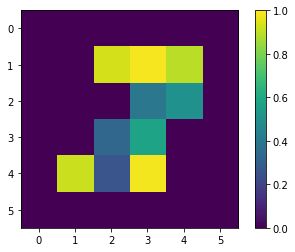

In [2]:
import collections 

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train[..., np.newaxis]/255.0, x_test[..., np.newaxis]/255.0

print("N total train: ", len(x_train))
print("N total test: ", len(x_test))

def filter_36(x,y):
  keep = (y==3)|(y==6)
  x, y = x[keep], y[keep]
  y = y == 3
  return x,y 

x_train_, y_train_ = filter_36(x_train, y_train)
x_test_, y_test_ = filter_36(x_test, y_test)

print('filtered N train:' , len(x_train_))
print('filtered N test:', len(x_test_))

x_train_small = tf.image.resize(x_train_, (6,6)).numpy()
x_test_small = tf.image.resize(x_test_, (6,6)).numpy()

def convert_label(y):
  if y==True:
    return 1.0
  else: 
    return -1.0  #changed from -1.0

y_train_ = [convert_label(y) for y in y_train_]
y_test_ = [convert_label(y) for y in y_test_]

plt.imshow(x_train_small[0,:,:,0], vmin = 0, vmax = 1 )
plt.colorbar()

X_train = x_train_small[:]
X_test = x_test_small[:]
Y_train = y_train_[:]
Y_test = y_test_[:]

In [3]:
def one_qubit_unitary(bit, symbols):
  """Rotation of bloch sphere about X, Y and Z axis, that depends on values in symbols"""
  return cirq.Circuit(
      cirq.X(bit)**symbols[0],
      cirq.Y(bit)**symbols[1],
      cirq.Z(bit)**symbols[2])
  
def conv_filter_4(bits, symbols):
  circuit=cirq.Circuit()
  
  circuit += one_qubit_unitary(bits[0], symbols[0:3])
  circuit += one_qubit_unitary(bits[1], symbols[3:6])
  circuit += one_qubit_unitary(bits[2], symbols[6:9])
  circuit += one_qubit_unitary(bits[3], symbols[9:12])
  
  
  for first, second in zip(bits[0::2], bits[1::2]):
    circuit += [cirq.ZZ(first, second)**symbols[12]]
    circuit += [cirq.YY(first, second)**symbols[13]]
    circuit += [cirq.XX(first, second)**symbols[14]]
  
  circuit += one_qubit_unitary(bits[0], symbols[15:18])
  circuit += one_qubit_unitary(bits[1], symbols[18:21])
  circuit += one_qubit_unitary(bits[2], symbols[21:24])
  circuit += one_qubit_unitary(bits[3], symbols[24:])
  """
  count = 0
  for first, second in zip(bits[0::2], bits[1::2]):
    circuit += [cirq.ZZ(first, second)**symbols[count]]
    circuit += [cirq.YY(first, second)**symbols[count+1]]
    circuit += [cirq.XX(first, second)**symbols[count+2]]
    count+=3
  """
  circuit += cirq.CNOT(control = bits[0], target = bits[1])
  circuit += cirq.CNOT(control = bits[2], target = bits[3])
  circuit += cirq.CNOT(control = bits[1], target = bits[3])
  

  return circuit 

findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


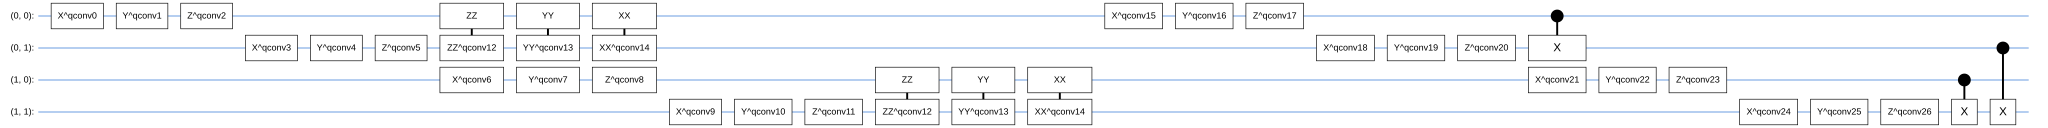

In [4]:
qubits = cirq.GridQubit.rect(2,2)
symbols = sympy.symbols('qconv0:100')
SVGCircuit(conv_filter_4(qubits, symbols))

In [5]:
def conv_circuit(bits, symbols):
  circuit = cirq.Circuit()
  n = int(np.sqrt(len(bits)))
  patch = np.array(bits).reshape((n,n))
  count = 0 

  #sliding 
  for j in range(0,n,2):
    for k in range(0,n,2):
      circuit+= conv_filter_4([patch[j,k], patch[j,k+1], patch[j+1, k], patch[j+1, k+1]], symbols[count:count+27])
      count+=27 
  return circuit 

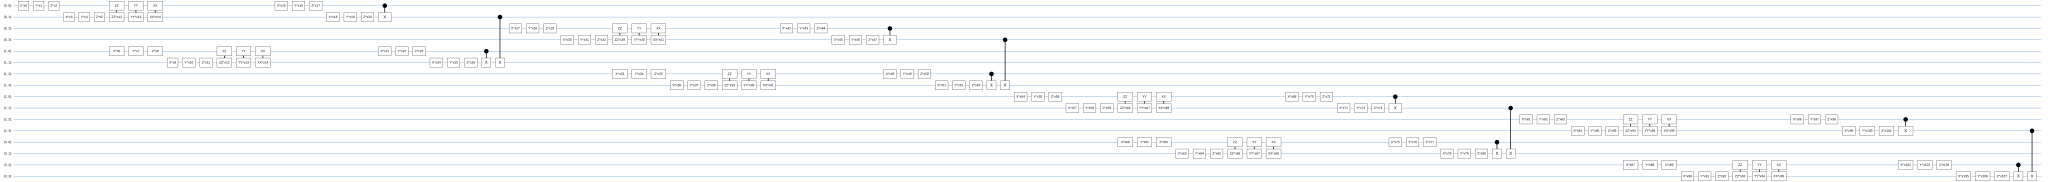

In [6]:
SVGCircuit(conv_circuit(cirq.GridQubit.rect(4,4), sympy.symbols('x0:200')))


In [7]:
def create_model(qubits):

  model_circuit = cirq.Circuit()
  symbols = sympy.symbols('qconv0:200')
  model_circuit += conv_circuit(qubits,symbols[:108])
  index = [5,7,13,15]
  model_circuit += conv_circuit([qubits[i] for i in index], symbols[108:])
  return model_circuit 

qubits16 = cirq.GridQubit.rect(4,4)
readout_operators= cirq.Z(qubits16[-1])

model = tf.keras.Sequential([tf.keras.layers.Input(shape=(), dtype = tf.string),
                             tfq.layers.PQC(create_model(qubits16), readout_operators)])
#encode images to quantum states

In [8]:
#encode images to quantum states

def encode_circuit(values):
  im4 = values[1:5,1:5]
  phi = np.ndarray.flatten(im4)
  encode_circuit = cirq.Circuit()
  qubits = cirq.GridQubit.rect(4,4)

  for i in range(16):
    encode_circuit.append(cirq.ry(np.pi*phi[i])(qubits[i]))
  return encode_circuit 

In [9]:
x_train_16 = tfq.convert_to_tensor([encode_circuit(x) for x in X_train])
x_test_16 = tfq.convert_to_tensor([encode_circuit(x) for x in X_test])


In [10]:
@tf.function 

def hinge_accuracy(y_true, y_pred):
  y_true = tf.squeeze(y_true)>0.0
  y_pred = tf.squeeze(y_pred)>0.0
  result = tf.cast(y_true == y_pred, tf.float32)
  return tf.reduce_mean(result)

In [11]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
                   loss=tf.losses.Hinge(),
                   metrics=[hinge_accuracy])

In [12]:
history = model.fit(x=x_train_16,
                         y=np.asarray(Y_train),
                         batch_size=16,
                         epochs=5,
                         verbose=1,
                         validation_data=(x_test_16, np.asarray(Y_test)))


Epoch 1/5
754/754 [==============================] - 1568s 2s/step - loss: 0.7600 - hinge_accuracy: 0.6742 - val_loss: 0.7436 - val_hinge_accuracy: 0.6529
Epoch 2/5
754/754 [==============================] - 974s 1s/step - loss: 0.6207 - hinge_accuracy: 0.7299 - val_loss: 0.7027 - val_hinge_accuracy: 0.6855
Epoch 3/5
754/754 [==============================] - 975s 1s/step - loss: 0.6125 - hinge_accuracy: 0.7464 - val_loss: 0.7042 - val_hinge_accuracy: 0.6946
Epoch 4/5
754/754 [==============================] - 970s 1s/step - loss: 0.6114 - hinge_accuracy: 0.7477 - val_loss: 0.6969 - val_hinge_accuracy: 0.6977
Epoch 5/5
754/754 [==============================] - 963s 1s/step - loss: 0.6109 - hinge_accuracy: 0.7476 - val_loss: 0.6993 - val_hinge_accuracy: 0.6946


In [14]:
#preds=model.predict_classes(x_test_16)
preds = (model.predict(x_test_16) > 0.5).astype("int32")

-1.0
Prediction: [1]


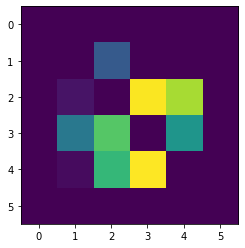

1.0
Prediction: [0]


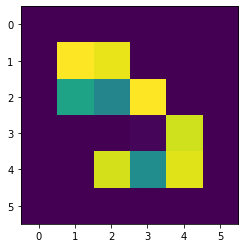

-1.0
Prediction: [0]


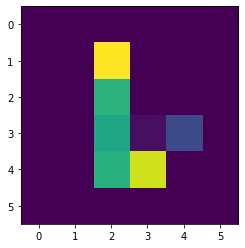

-1.0
Prediction: [0]


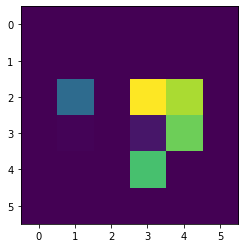

1.0
Prediction: [1]


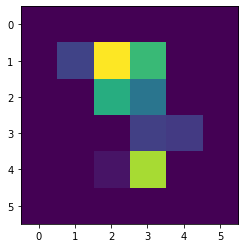

1.0
Prediction: [1]


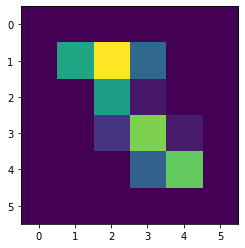

1.0
Prediction: [0]


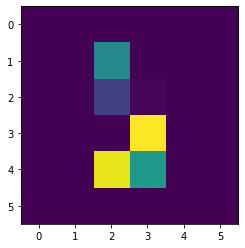

-1.0
Prediction: [0]


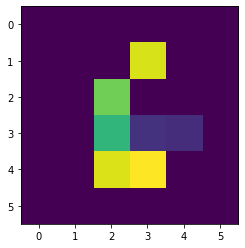

1.0
Prediction: [0]


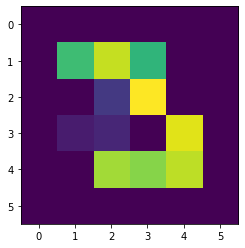

-1.0
Prediction: [1]


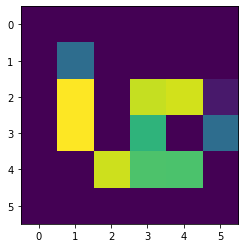

1.0
Prediction: [1]


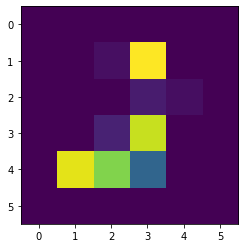

-1.0
Prediction: [1]


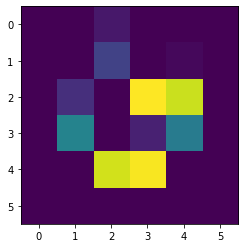

1.0
Prediction: [0]


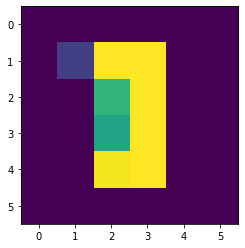

1.0
Prediction: [1]


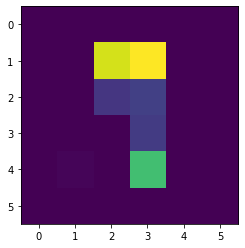

-1.0
Prediction: [0]


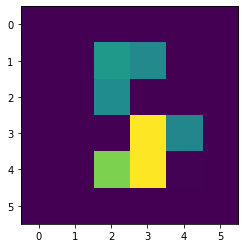

1.0
Prediction: [1]


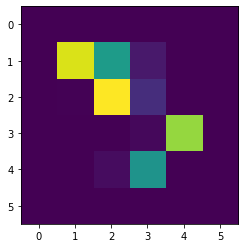

-1.0
Prediction: [0]


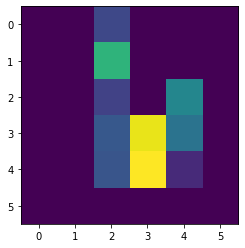

1.0
Prediction: [0]


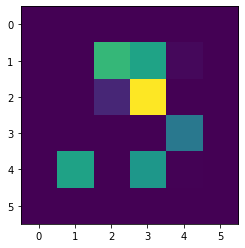

-1.0
Prediction: [0]


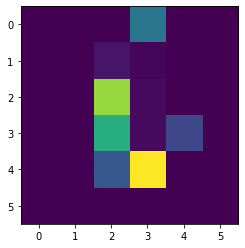

1.0
Prediction: [0]


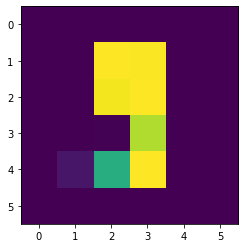

-1.0
Prediction: [0]


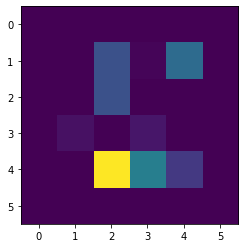

-1.0
Prediction: [0]


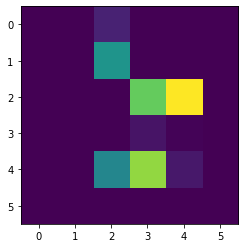

1.0
Prediction: [1]


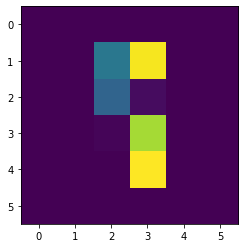

-1.0
Prediction: [0]


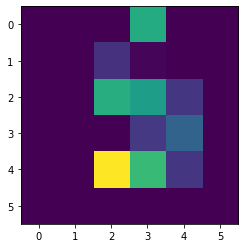

-1.0
Prediction: [0]


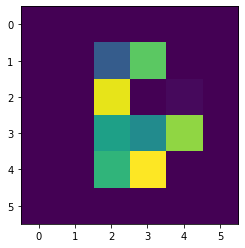

-1.0
Prediction: [0]


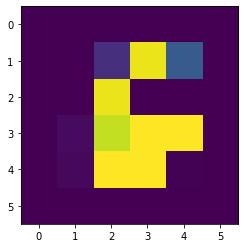

-1.0
Prediction: [0]


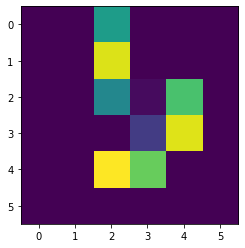

-1.0
Prediction: [0]


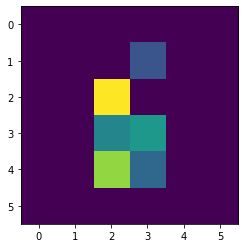

1.0
Prediction: [1]


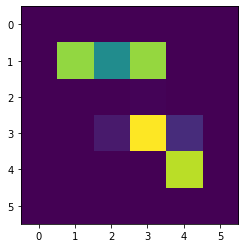

-1.0
Prediction: [1]


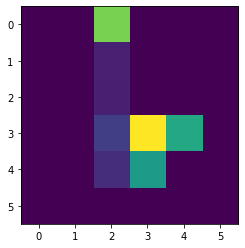

1.0
Prediction: [0]


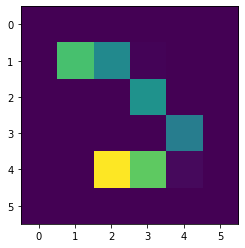

-1.0
Prediction: [0]


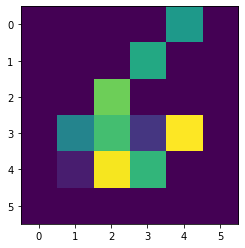

-1.0
Prediction: [0]


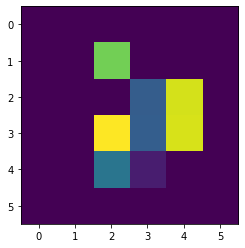

1.0
Prediction: [1]


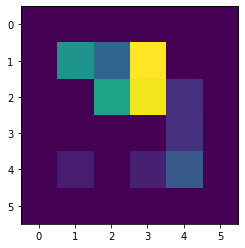

1.0
Prediction: [0]


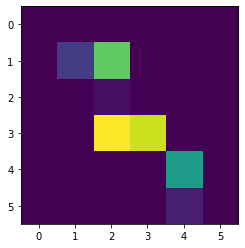

-1.0
Prediction: [0]


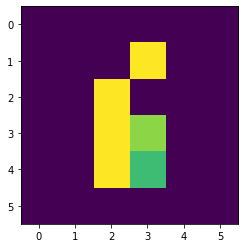

1.0
Prediction: [1]


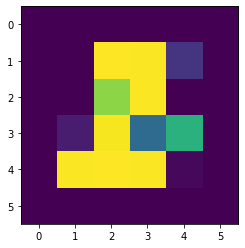

-1.0
Prediction: [1]


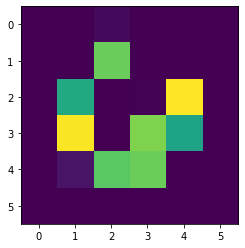

1.0
Prediction: [1]


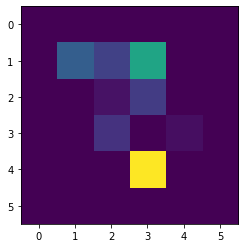

1.0
Prediction: [1]


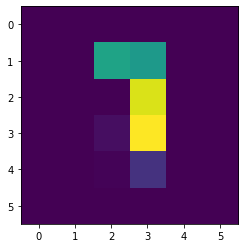

1.0
Prediction: [0]


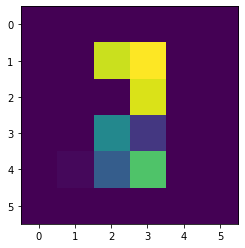

-1.0
Prediction: [0]


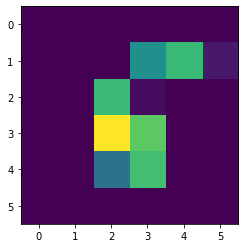

1.0
Prediction: [0]


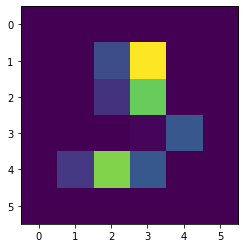

1.0
Prediction: [1]


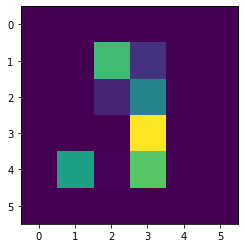

1.0
Prediction: [0]


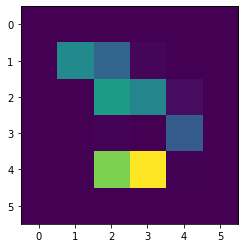

-1.0
Prediction: [1]


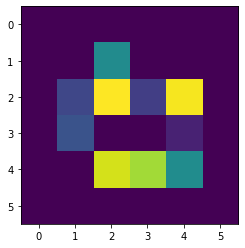

1.0
Prediction: [1]


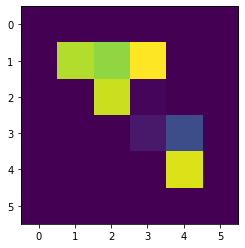

-1.0
Prediction: [0]


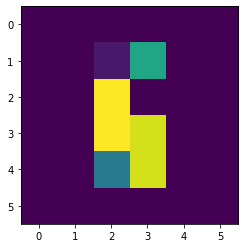

1.0
Prediction: [1]


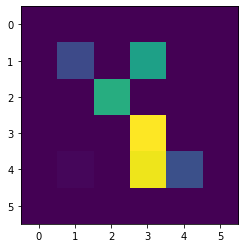

1.0
Prediction: [1]


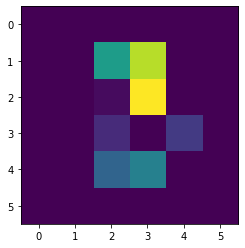

1.0
Prediction: [1]


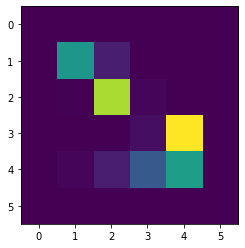

-1.0
Prediction: [0]


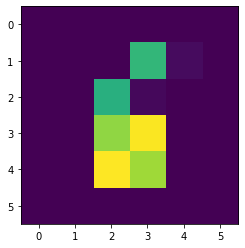

1.0
Prediction: [1]


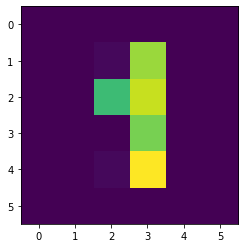

1.0
Prediction: [0]


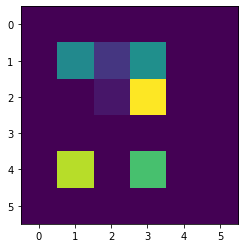

1.0
Prediction: [0]


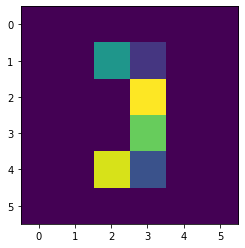

-1.0
Prediction: [0]


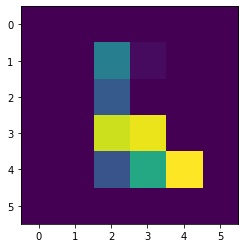

-1.0
Prediction: [1]


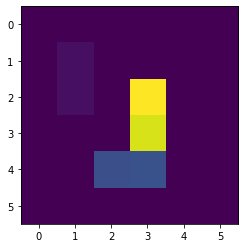

1.0
Prediction: [0]


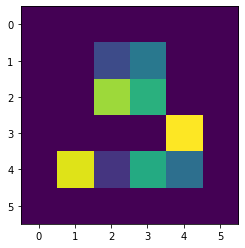

1.0
Prediction: [1]


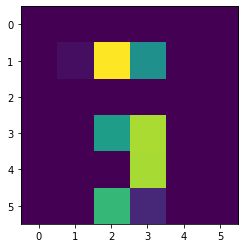

-1.0
Prediction: [0]


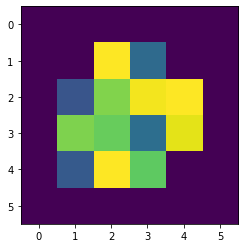

-1.0
Prediction: [0]


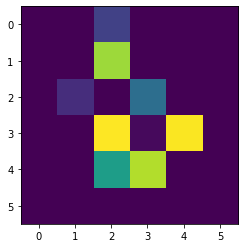

-1.0
Prediction: [0]


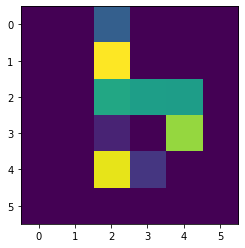

-1.0
Prediction: [0]


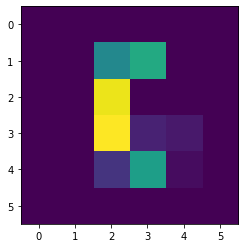

1.0
Prediction: [1]


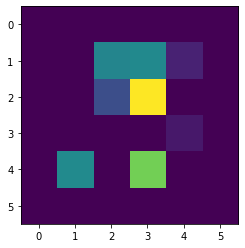

1.0
Prediction: [1]


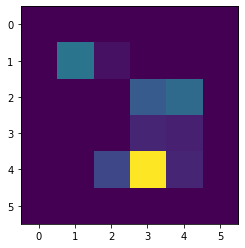

1.0
Prediction: [0]


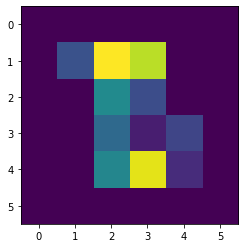

-1.0
Prediction: [0]


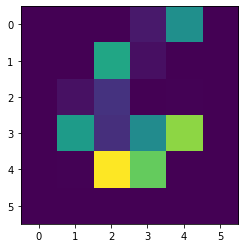

-1.0
Prediction: [0]


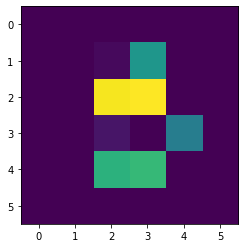

-1.0
Prediction: [0]


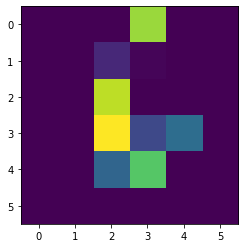

1.0
Prediction: [0]


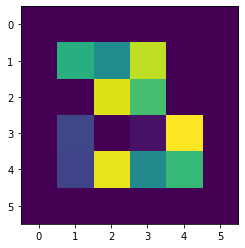

1.0
Prediction: [0]


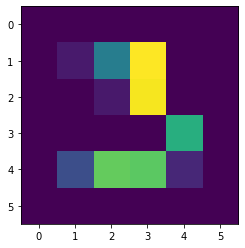

1.0
Prediction: [0]


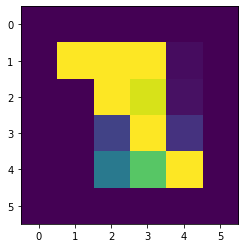

-1.0
Prediction: [0]


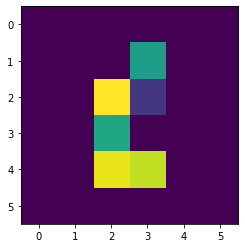

1.0
Prediction: [1]


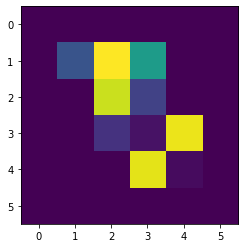

-1.0
Prediction: [0]


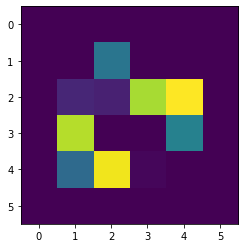

-1.0
Prediction: [0]


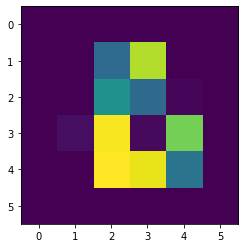

1.0
Prediction: [1]


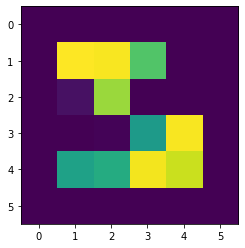

1.0
Prediction: [0]


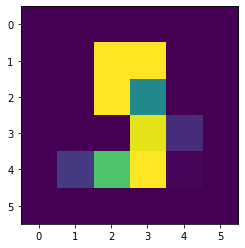

1.0
Prediction: [0]


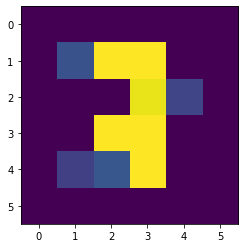

1.0
Prediction: [1]


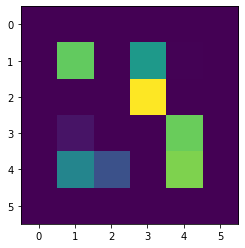

-1.0
Prediction: [0]


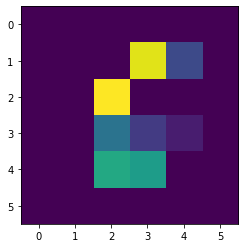

-1.0
Prediction: [0]


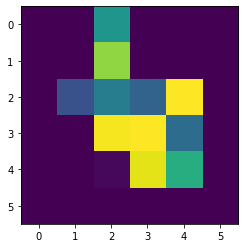

-1.0
Prediction: [0]


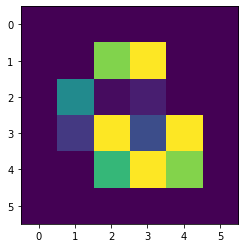

-1.0
Prediction: [0]


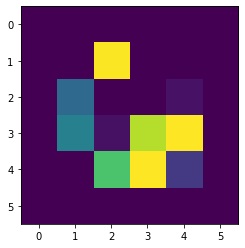

1.0
Prediction: [1]


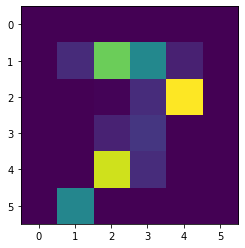

-1.0
Prediction: [0]


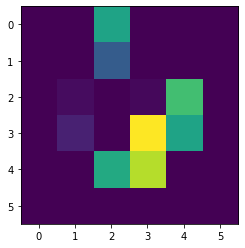

1.0
Prediction: [1]


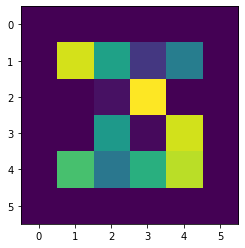

-1.0
Prediction: [0]


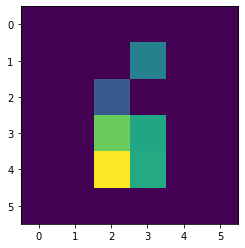

1.0
Prediction: [0]


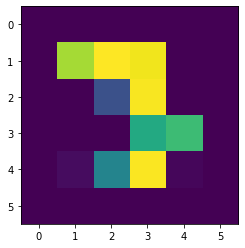

1.0
Prediction: [0]


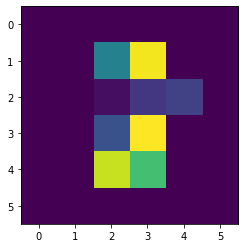

1.0
Prediction: [0]


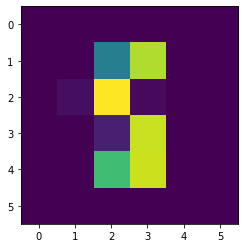

-1.0
Prediction: [0]


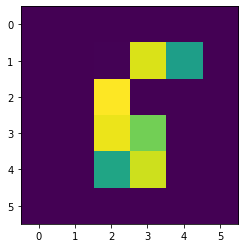

-1.0
Prediction: [0]


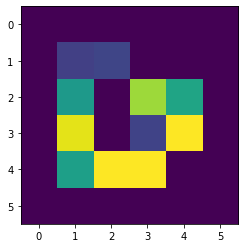

1.0
Prediction: [0]


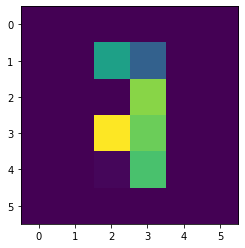

-1.0
Prediction: [1]


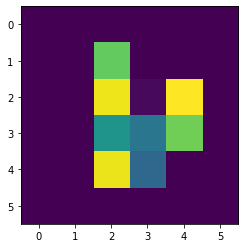

1.0
Prediction: [1]


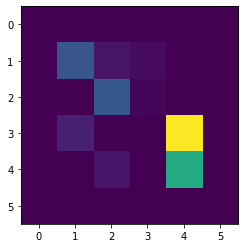

1.0
Prediction: [1]


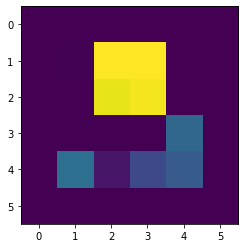

1.0
Prediction: [0]


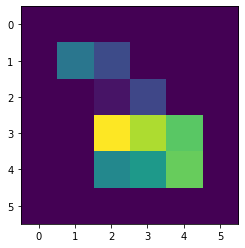

1.0
Prediction: [0]


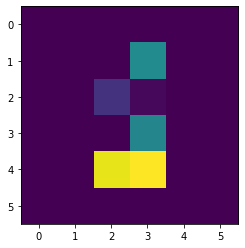

-1.0
Prediction: [0]


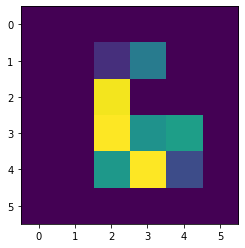

1.0
Prediction: [1]


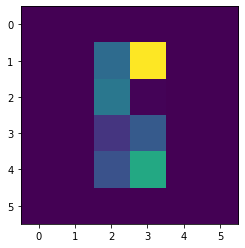

-1.0
Prediction: [0]


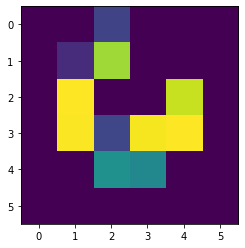

-1.0
Prediction: [0]


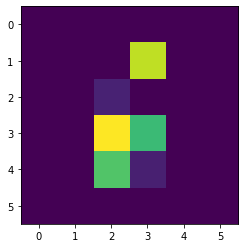

-1.0
Prediction: [0]


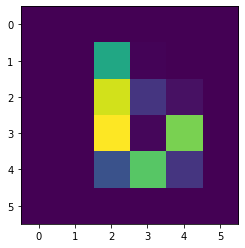

1.0
Prediction: [1]


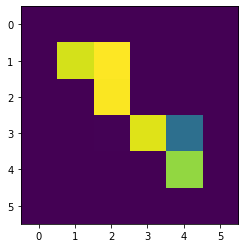

1.0
Prediction: [0]


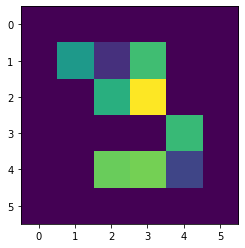

1.0
Prediction: [0]


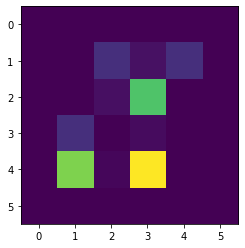

1.0
Prediction: [0]


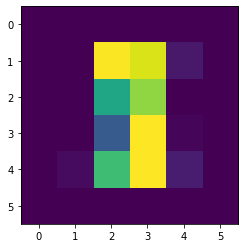

1.0
Prediction: [1]


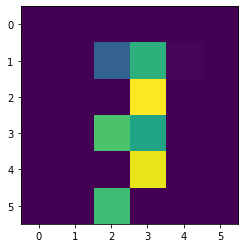

1.0
Prediction: [0]


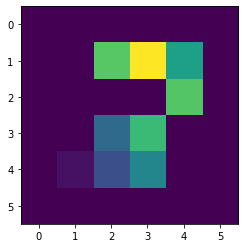

-1.0
Prediction: [0]


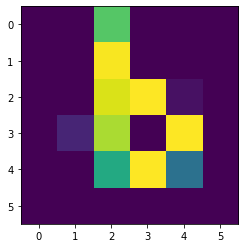

1.0
Prediction: [1]


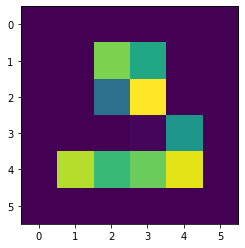

-1.0
Prediction: [0]


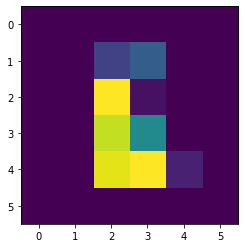

1.0
Prediction: [1]


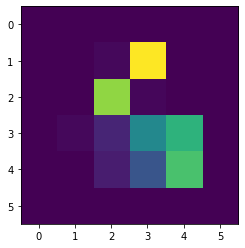

-1.0
Prediction: [0]


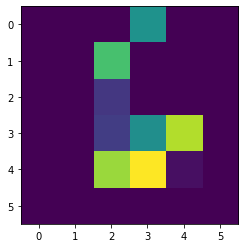

-1.0
Prediction: [1]


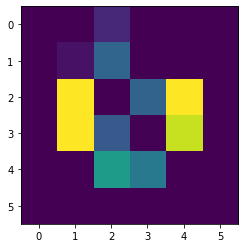

-1.0
Prediction: [0]


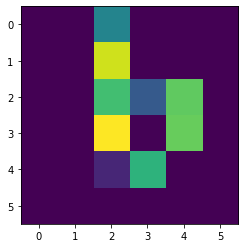

1.0
Prediction: [1]


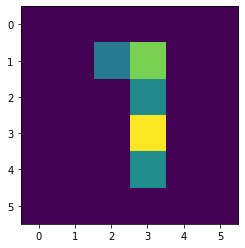

-1.0
Prediction: [0]


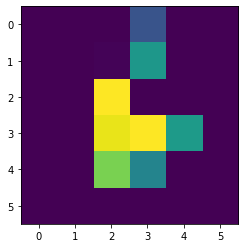

-1.0
Prediction: [1]


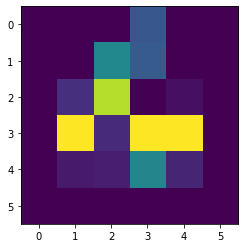

1.0
Prediction: [1]


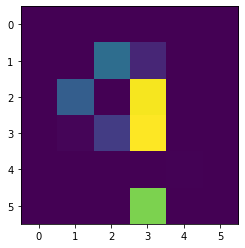

1.0
Prediction: [0]


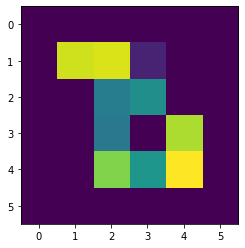

1.0
Prediction: [1]


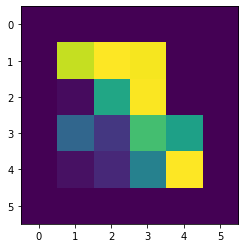

-1.0
Prediction: [0]


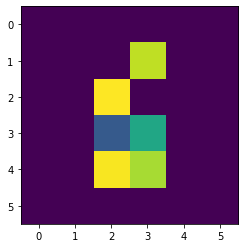

1.0
Prediction: [0]


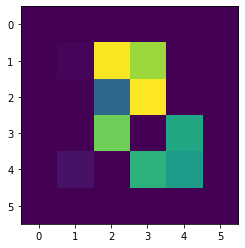

-1.0
Prediction: [1]


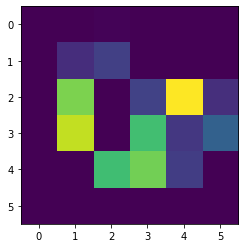

1.0
Prediction: [1]


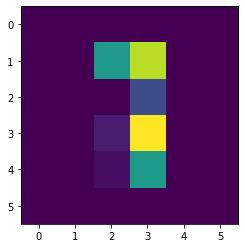

1.0
Prediction: [0]


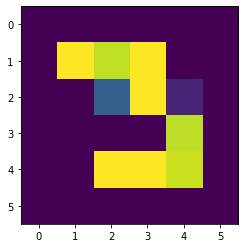

-1.0
Prediction: [0]


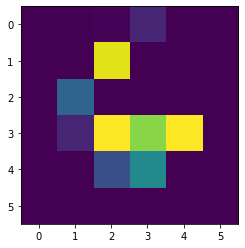

1.0
Prediction: [1]


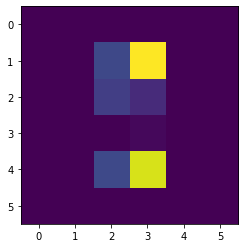

1.0
Prediction: [0]


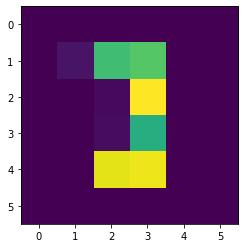

1.0
Prediction: [1]


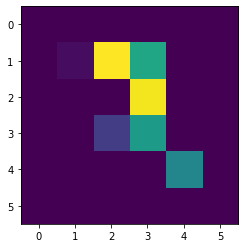

-1.0
Prediction: [0]


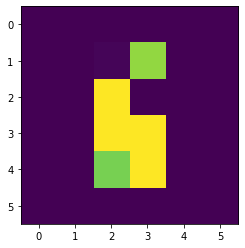

1.0
Prediction: [1]


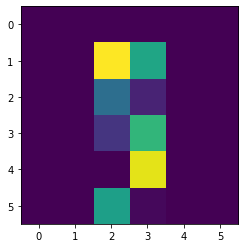

-1.0
Prediction: [0]


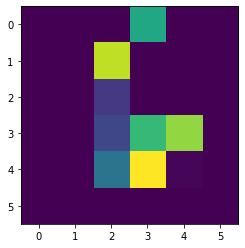

1.0
Prediction: [0]


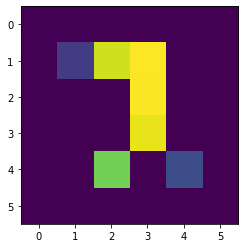

-1.0
Prediction: [0]


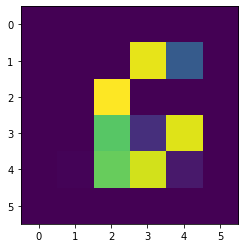

-1.0
Prediction: [0]


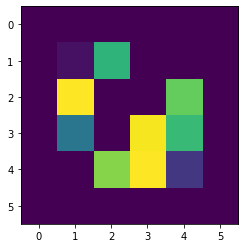

1.0
Prediction: [0]


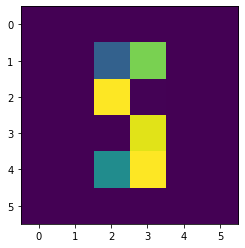

-1.0
Prediction: [0]


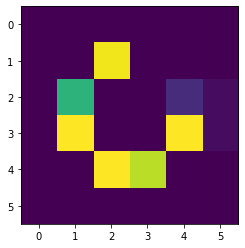

-1.0
Prediction: [0]


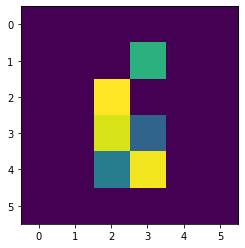

1.0
Prediction: [0]


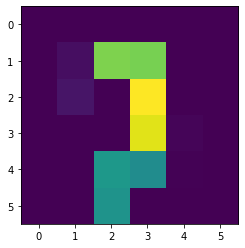

1.0
Prediction: [0]


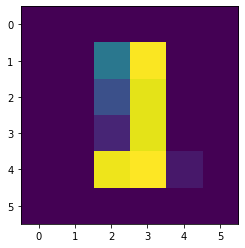

-1.0
Prediction: [0]


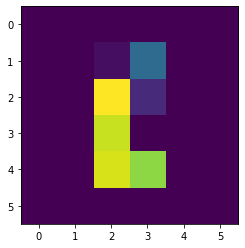

1.0
Prediction: [0]


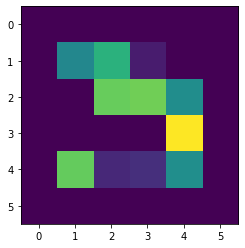

1.0
Prediction: [1]


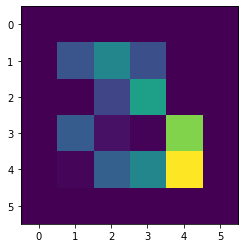

-1.0
Prediction: [0]


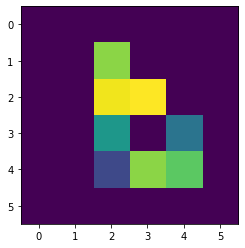

1.0
Prediction: [0]


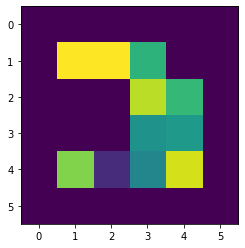

1.0
Prediction: [0]


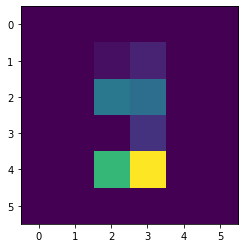

1.0
Prediction: [0]


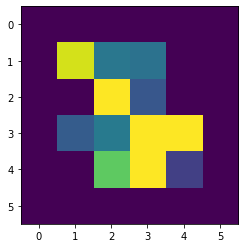

1.0
Prediction: [1]


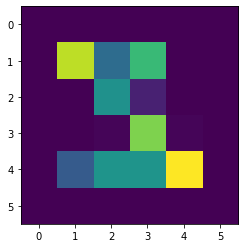

1.0
Prediction: [0]


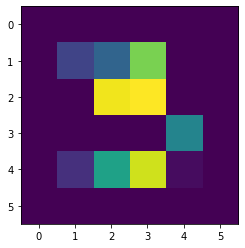

1.0
Prediction: [0]


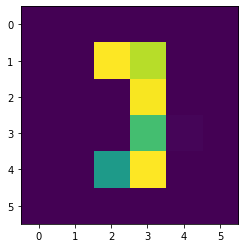

-1.0
Prediction: [0]


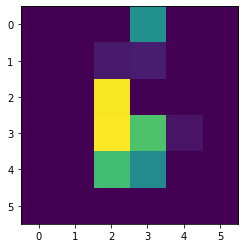

1.0
Prediction: [0]


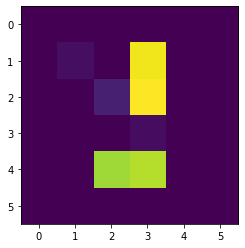

-1.0
Prediction: [0]


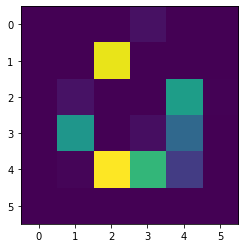

1.0
Prediction: [1]


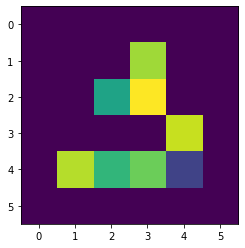

-1.0
Prediction: [0]


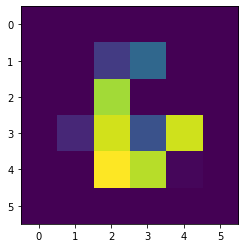

-1.0
Prediction: [0]


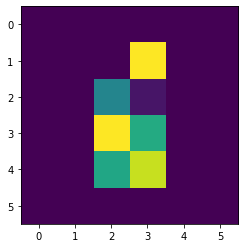

1.0
Prediction: [0]


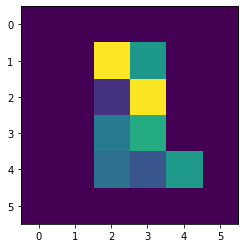

1.0
Prediction: [1]


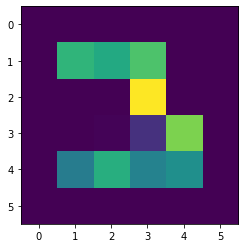

1.0
Prediction: [0]


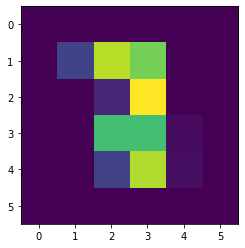

-1.0
Prediction: [0]


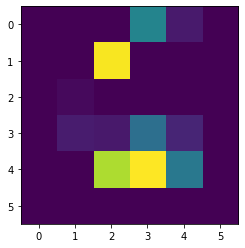

-1.0
Prediction: [0]


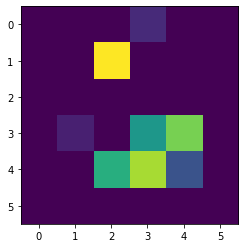

1.0
Prediction: [0]


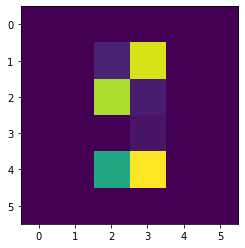

-1.0
Prediction: [0]


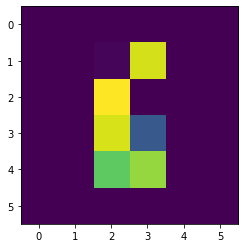

1.0
Prediction: [1]


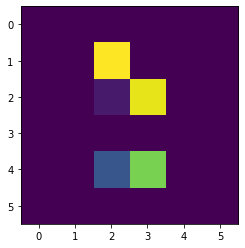

-1.0
Prediction: [0]


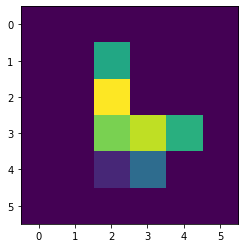

-1.0
Prediction: [0]


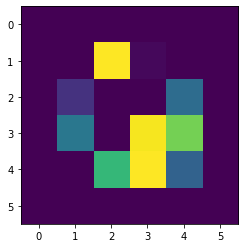

1.0
Prediction: [1]


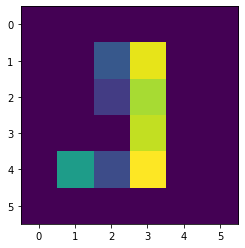

1.0
Prediction: [0]


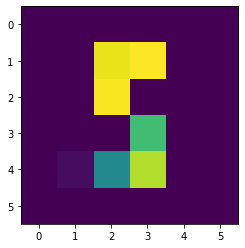

1.0
Prediction: [0]


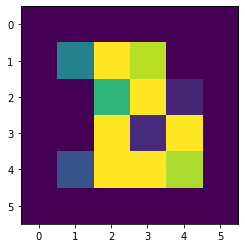

-1.0
Prediction: [0]


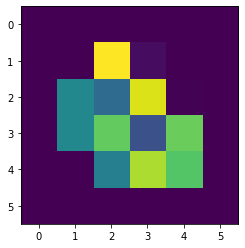

1.0
Prediction: [1]


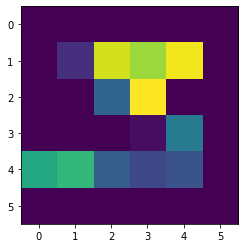

1.0
Prediction: [0]


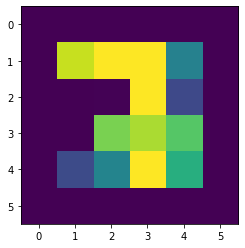

1.0
Prediction: [1]


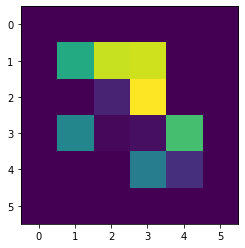

1.0
Prediction: [0]


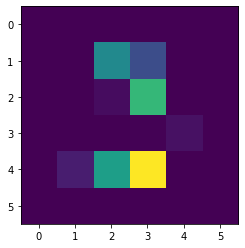

1.0
Prediction: [0]


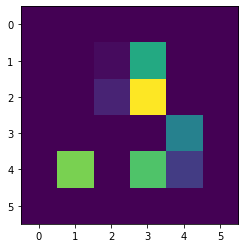

-1.0
Prediction: [0]


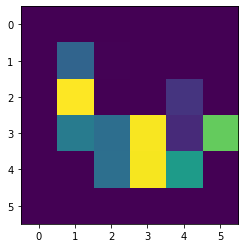

1.0
Prediction: [0]


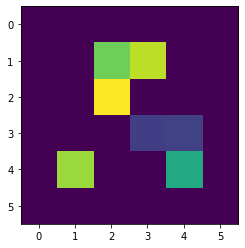

-1.0
Prediction: [0]


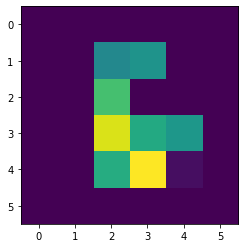

-1.0
Prediction: [0]


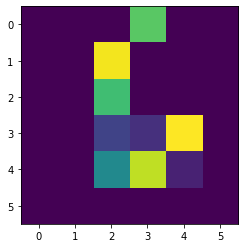

-1.0
Prediction: [0]


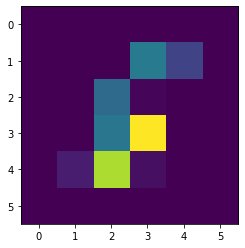

1.0
Prediction: [1]


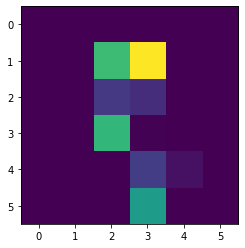

-1.0
Prediction: [0]


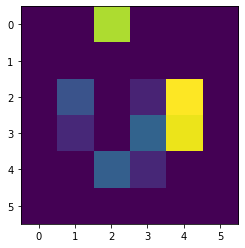

1.0
Prediction: [0]


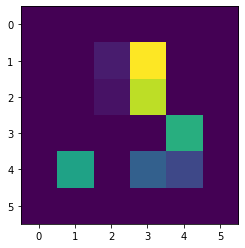

1.0
Prediction: [0]


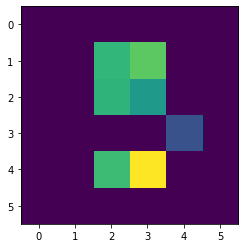

-1.0
Prediction: [0]


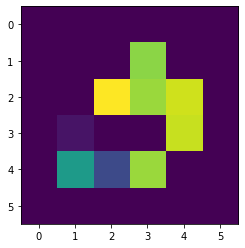

-1.0
Prediction: [1]


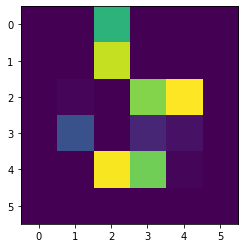

1.0
Prediction: [1]


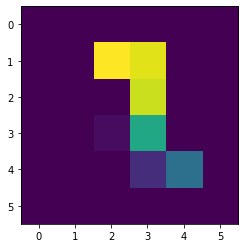

1.0
Prediction: [1]


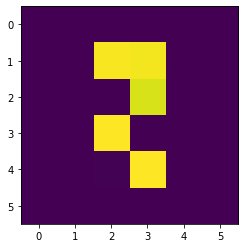

-1.0
Prediction: [0]


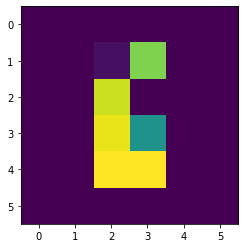

-1.0
Prediction: [0]


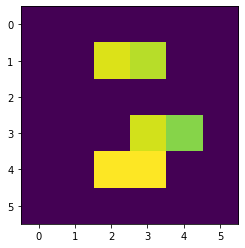

1.0
Prediction: [1]


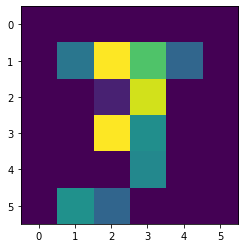

-1.0
Prediction: [1]


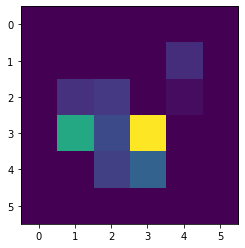

-1.0
Prediction: [1]


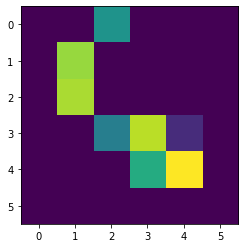

1.0
Prediction: [0]


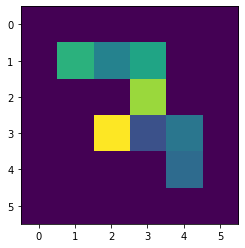

1.0
Prediction: [0]


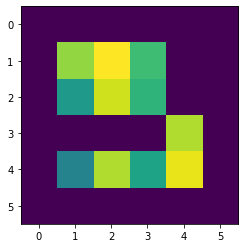

-1.0
Prediction: [0]


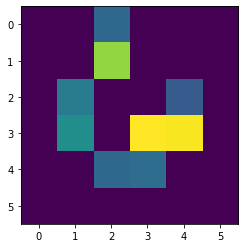

1.0
Prediction: [0]


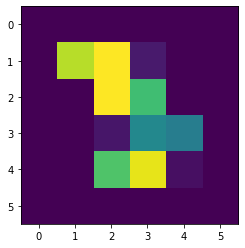

-1.0
Prediction: [0]


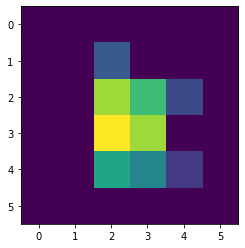

1.0
Prediction: [1]


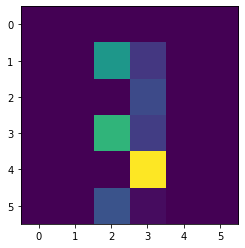

1.0
Prediction: [1]


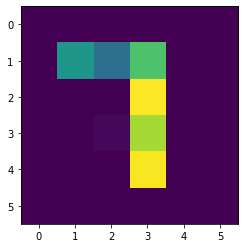

1.0
Prediction: [1]


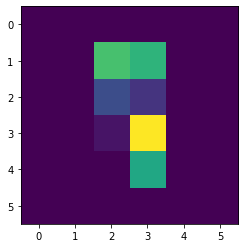

1.0
Prediction: [0]


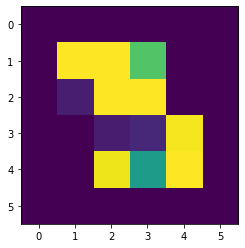

1.0
Prediction: [1]


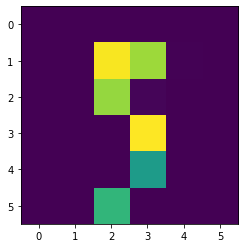

-1.0
Prediction: [1]


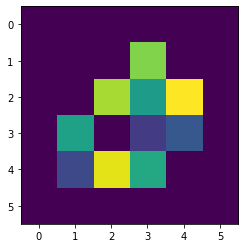

-1.0
Prediction: [0]


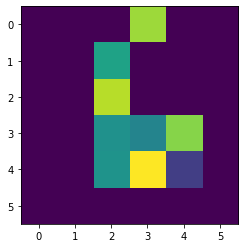

1.0
Prediction: [0]


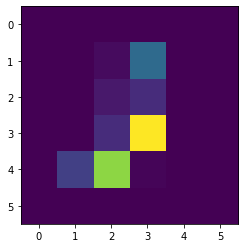

1.0
Prediction: [0]


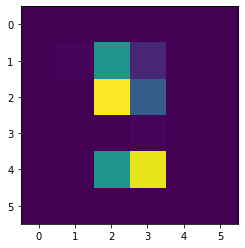

1.0
Prediction: [1]


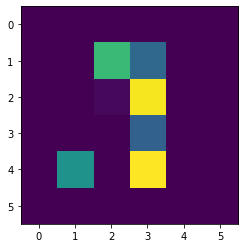

-1.0
Prediction: [0]


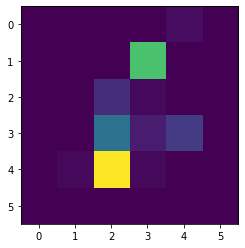

-1.0
Prediction: [0]


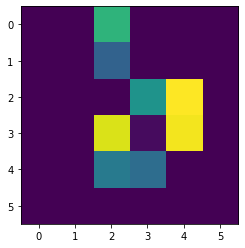

-1.0
Prediction: [0]


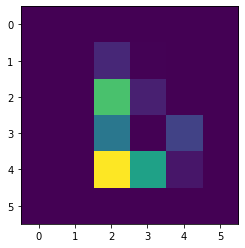

1.0
Prediction: [1]


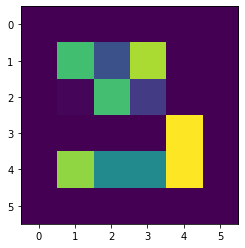

1.0
Prediction: [0]


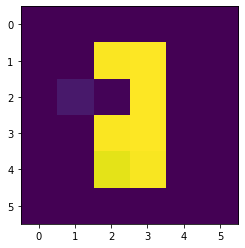

-1.0
Prediction: [0]


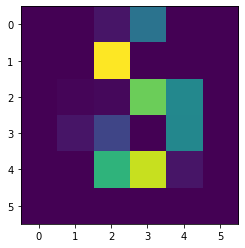

1.0
Prediction: [1]


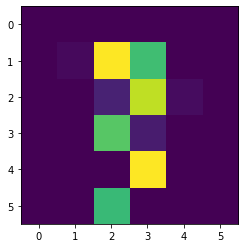

1.0
Prediction: [1]


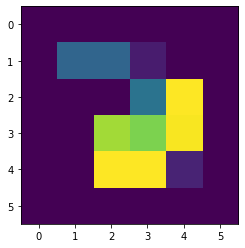

1.0
Prediction: [1]


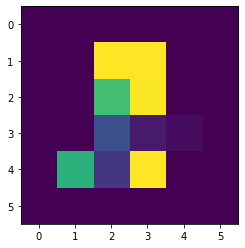

1.0
Prediction: [1]


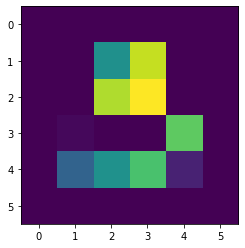

-1.0
Prediction: [0]


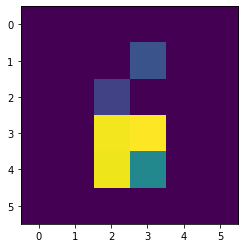

-1.0
Prediction: [0]


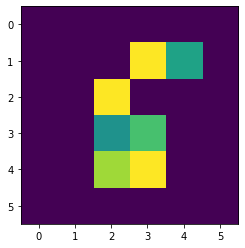

-1.0
Prediction: [0]


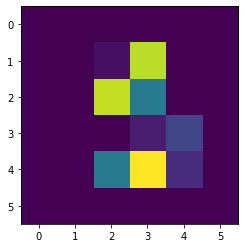

-1.0
Prediction: [1]


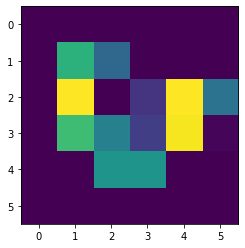

1.0
Prediction: [1]


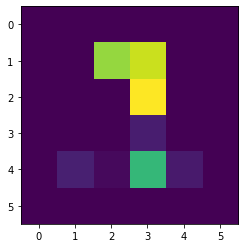

1.0
Prediction: [1]


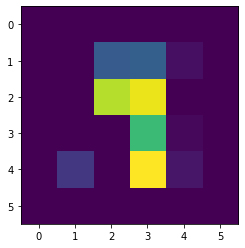

-1.0
Prediction: [0]


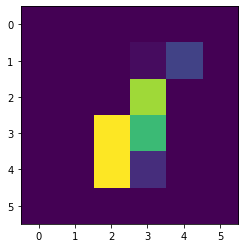

-1.0
Prediction: [0]


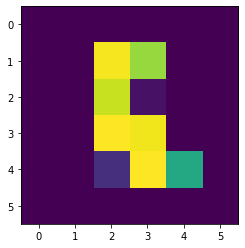

-1.0
Prediction: [0]


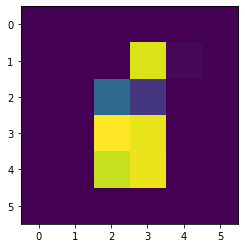

-1.0
Prediction: [0]


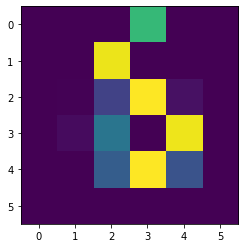

1.0
Prediction: [1]


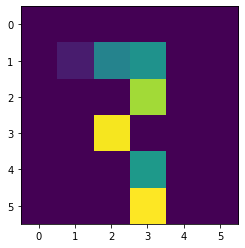

1.0
Prediction: [1]


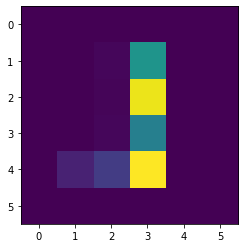

1.0
Prediction: [1]


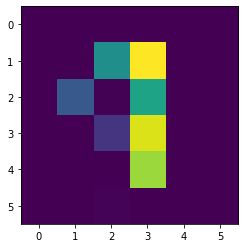

-1.0
Prediction: [0]


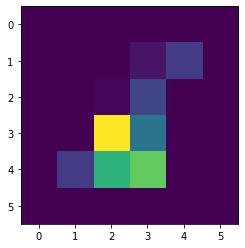

-1.0
Prediction: [0]


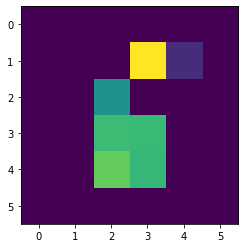

1.0
Prediction: [1]


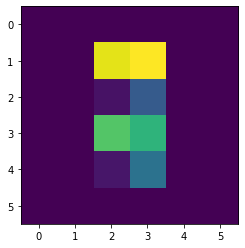

1.0
Prediction: [1]


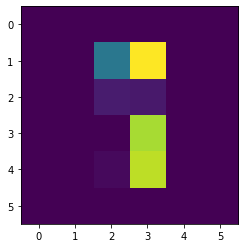

-1.0
Prediction: [0]


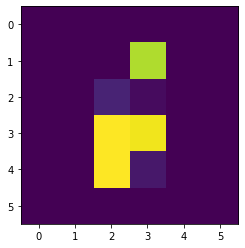

1.0
Prediction: [0]


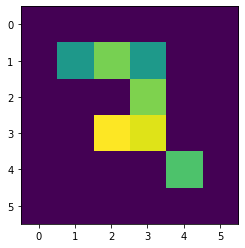

-1.0
Prediction: [0]


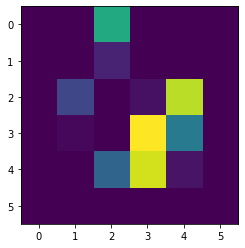

1.0
Prediction: [1]


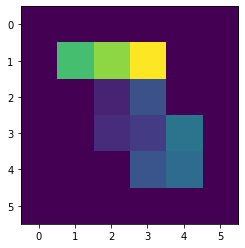

1.0
Prediction: [1]


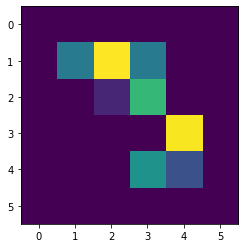

1.0
Prediction: [0]


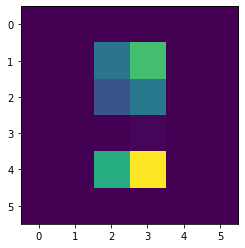

1.0
Prediction: [0]


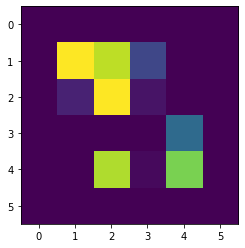

-1.0
Prediction: [0]


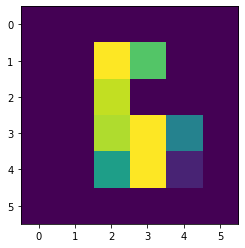

-1.0
Prediction: [0]


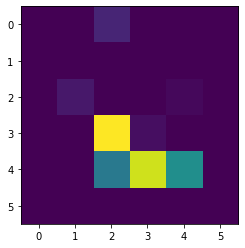

-1.0
Prediction: [0]


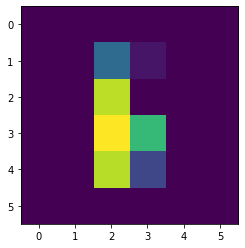

1.0
Prediction: [1]


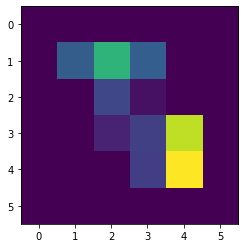

-1.0
Prediction: [1]


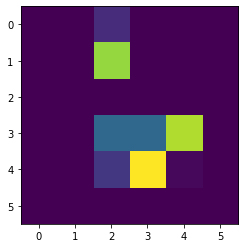

1.0
Prediction: [1]


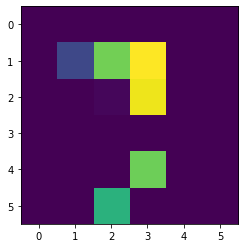

1.0
Prediction: [0]


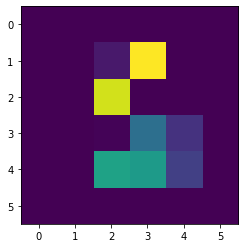

1.0
Prediction: [1]


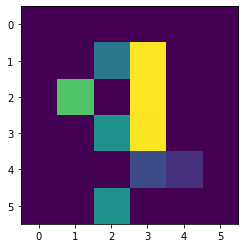

-1.0
Prediction: [0]


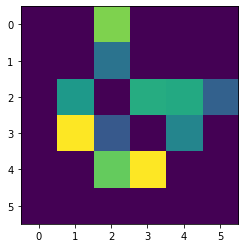

-1.0
Prediction: [0]


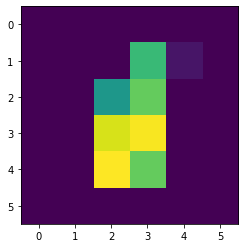

1.0
Prediction: [1]


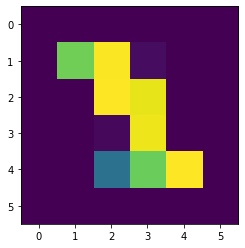

-1.0
Prediction: [0]


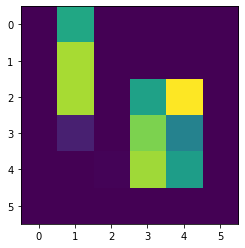

1.0
Prediction: [0]


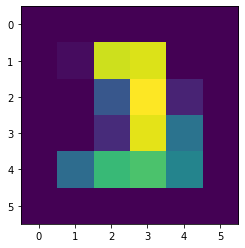

-1.0
Prediction: [0]


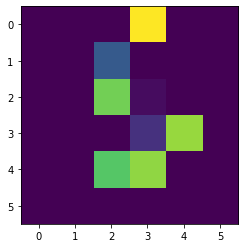

-1.0
Prediction: [0]


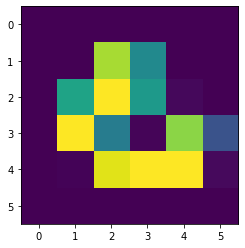

1.0
Prediction: [0]


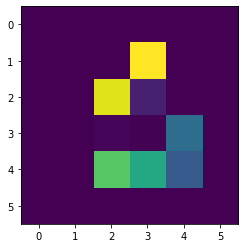

1.0
Prediction: [1]


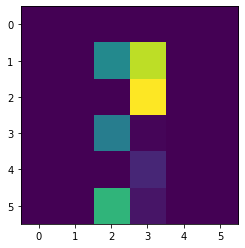

-1.0
Prediction: [0]


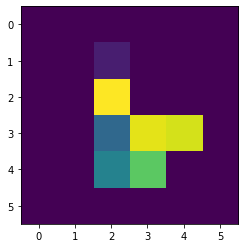

-1.0
Prediction: [0]


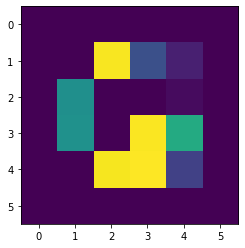

-1.0
Prediction: [0]


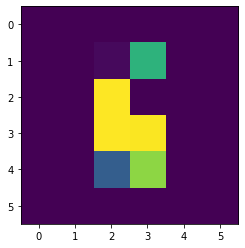

-1.0
Prediction: [0]


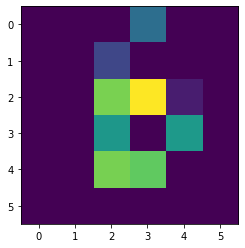

1.0
Prediction: [1]


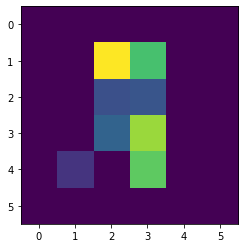

-1.0
Prediction: [0]


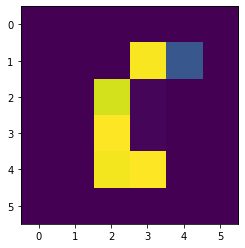

1.0
Prediction: [1]


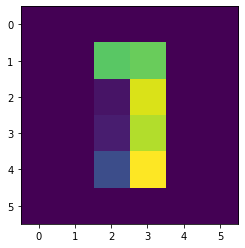

-1.0
Prediction: [1]


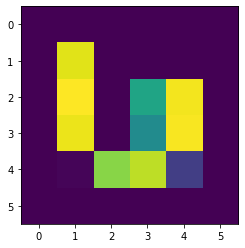

-1.0
Prediction: [1]


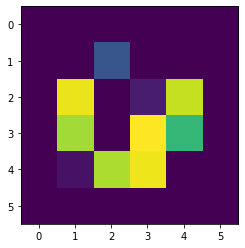

-1.0
Prediction: [1]


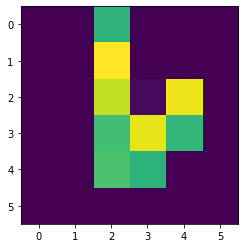

-1.0
Prediction: [0]


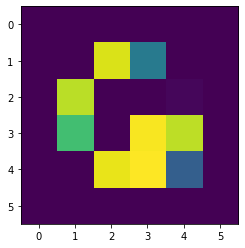

1.0
Prediction: [0]


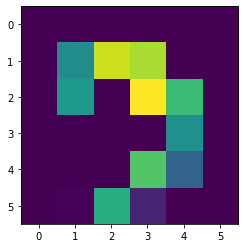

1.0
Prediction: [0]


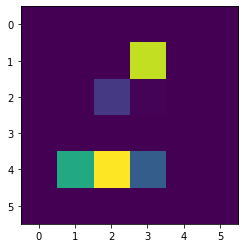

1.0
Prediction: [1]


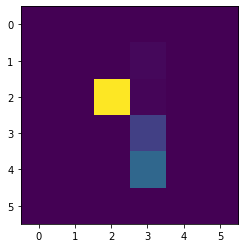

-1.0
Prediction: [0]


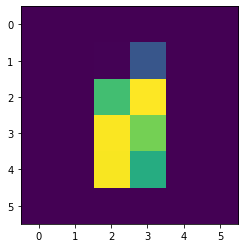

-1.0
Prediction: [0]


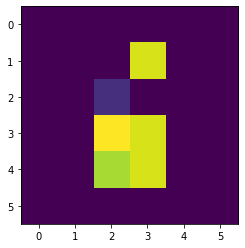

1.0
Prediction: [1]


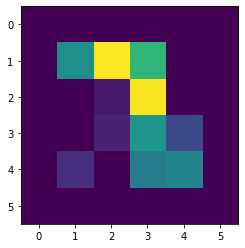

1.0
Prediction: [0]


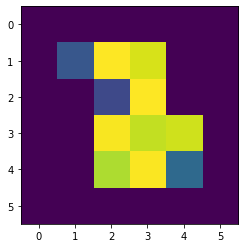

-1.0
Prediction: [0]


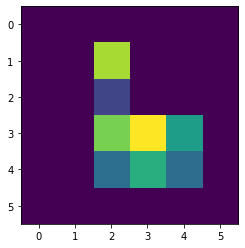

1.0
Prediction: [1]


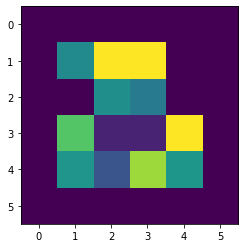

1.0
Prediction: [0]


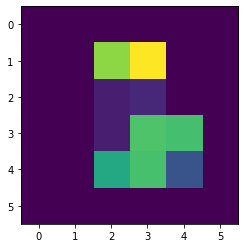

-1.0
Prediction: [0]


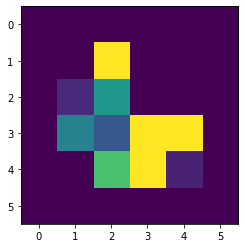

1.0
Prediction: [0]


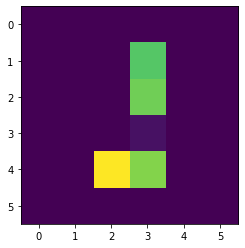

1.0
Prediction: [1]


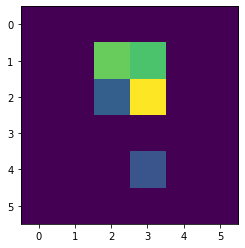

1.0
Prediction: [1]


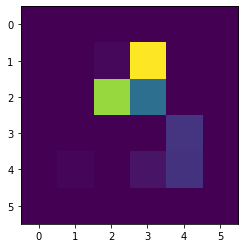

1.0
Prediction: [1]


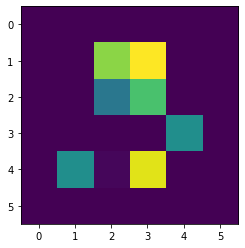

1.0
Prediction: [1]


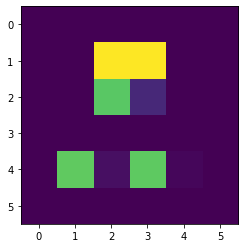

-1.0
Prediction: [0]


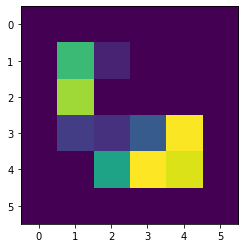

-1.0
Prediction: [0]


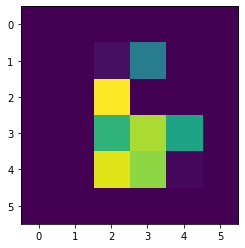

1.0
Prediction: [0]


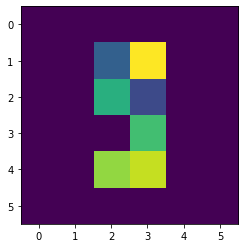

-1.0
Prediction: [0]


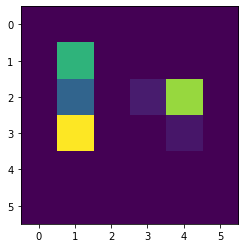

-1.0
Prediction: [0]


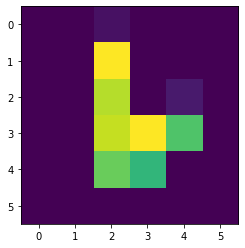

-1.0
Prediction: [0]


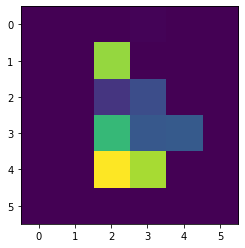

-1.0
Prediction: [0]


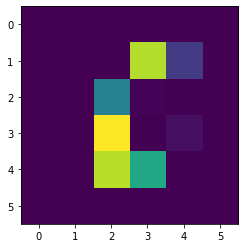

1.0
Prediction: [1]


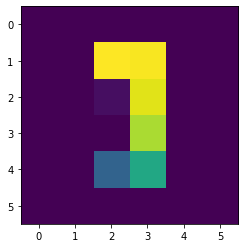

-1.0
Prediction: [0]


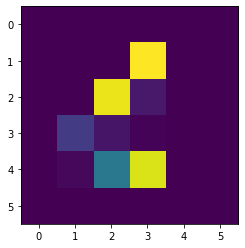

1.0
Prediction: [1]


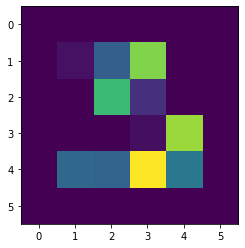

1.0
Prediction: [0]


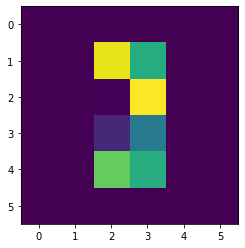

-1.0
Prediction: [0]


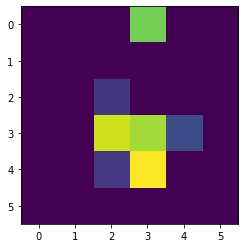

1.0
Prediction: [1]


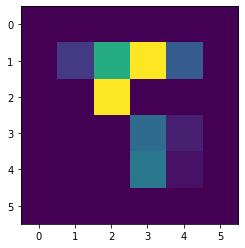

1.0
Prediction: [0]


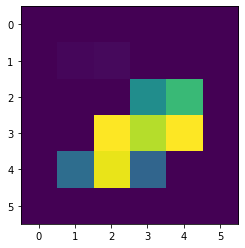

-1.0
Prediction: [0]


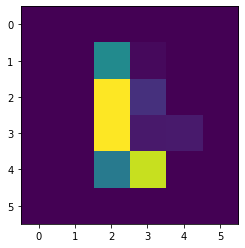

1.0
Prediction: [1]


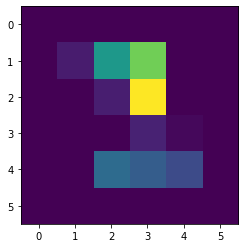

1.0
Prediction: [1]


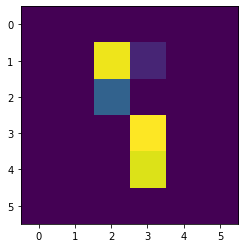

1.0
Prediction: [1]


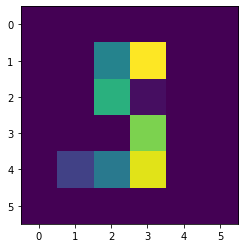

1.0
Prediction: [0]


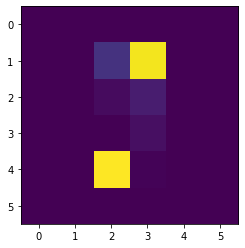

1.0
Prediction: [1]


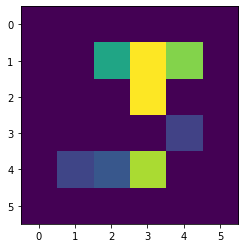

1.0
Prediction: [1]


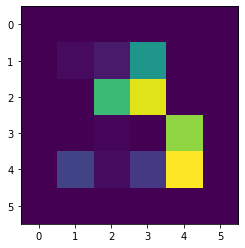

-1.0
Prediction: [0]


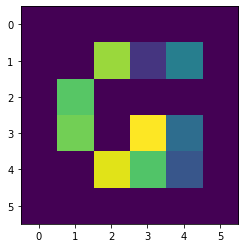

1.0
Prediction: [1]


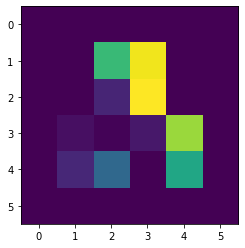

-1.0
Prediction: [0]


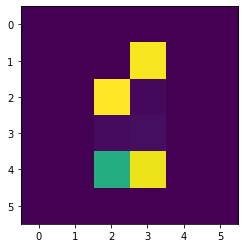

1.0
Prediction: [1]


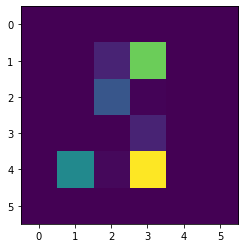

-1.0
Prediction: [0]


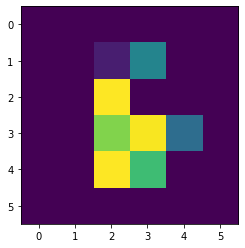

1.0
Prediction: [0]


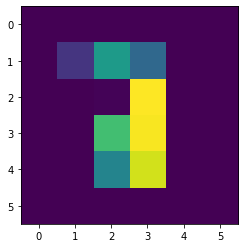

-1.0
Prediction: [0]


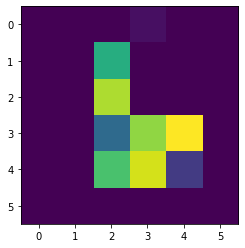

-1.0
Prediction: [0]


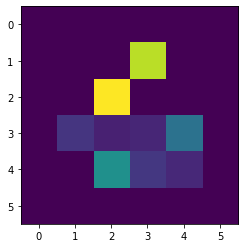

1.0
Prediction: [0]


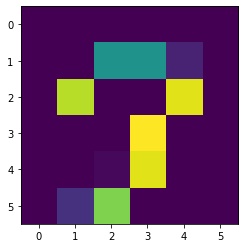

1.0
Prediction: [1]


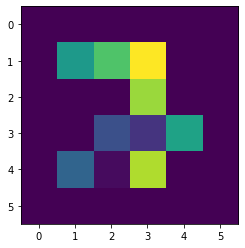

-1.0
Prediction: [0]


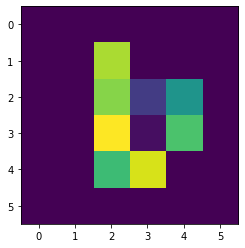

-1.0
Prediction: [0]


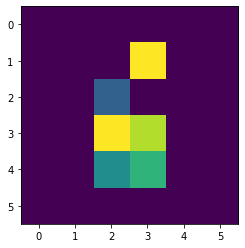

1.0
Prediction: [1]


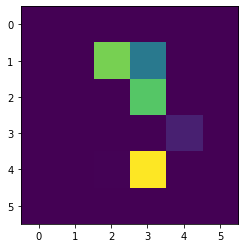

-1.0
Prediction: [0]


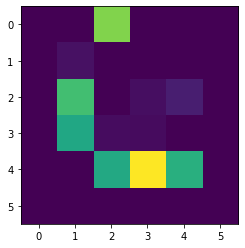

-1.0
Prediction: [1]


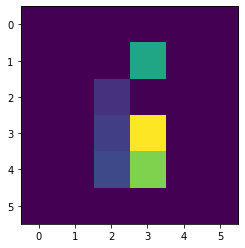

1.0
Prediction: [1]


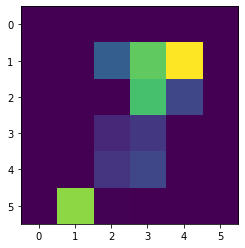

1.0
Prediction: [0]


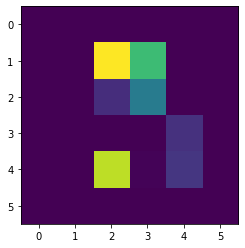

1.0
Prediction: [1]


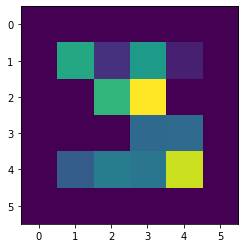

-1.0
Prediction: [1]


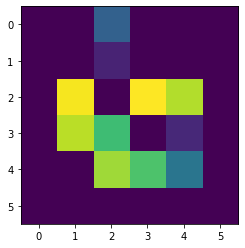

1.0
Prediction: [1]


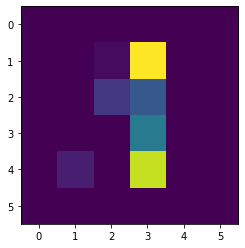

1.0
Prediction: [1]


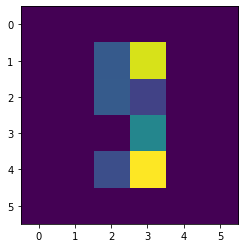

-1.0
Prediction: [0]


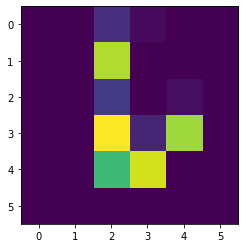

1.0
Prediction: [0]


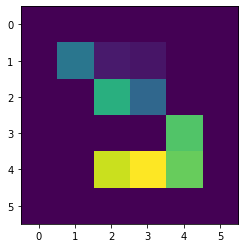

1.0
Prediction: [1]


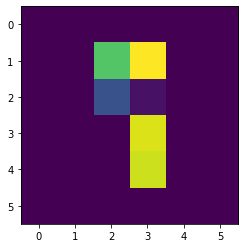

1.0
Prediction: [1]


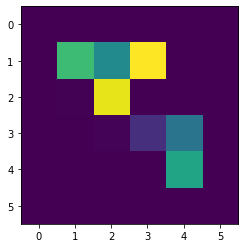

1.0
Prediction: [0]


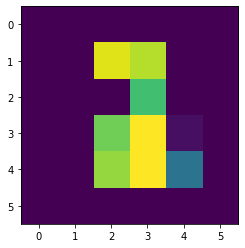

1.0
Prediction: [0]


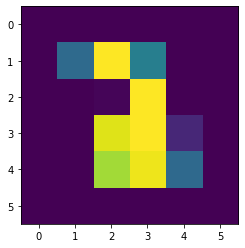

1.0
Prediction: [0]


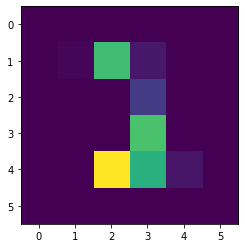

1.0
Prediction: [1]


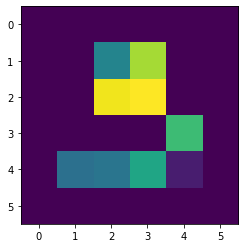

1.0
Prediction: [1]


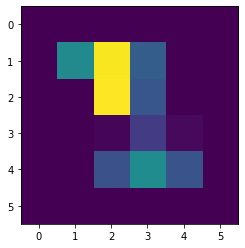

-1.0
Prediction: [1]


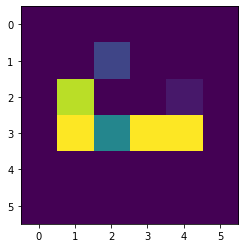

1.0
Prediction: [1]


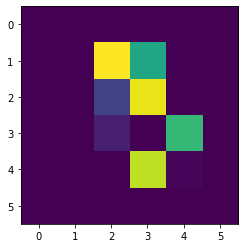

1.0
Prediction: [0]


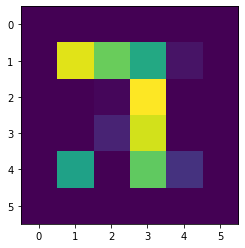

-1.0
Prediction: [0]


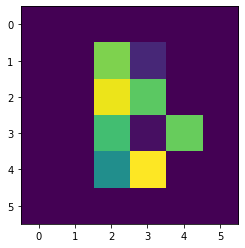

-1.0
Prediction: [0]


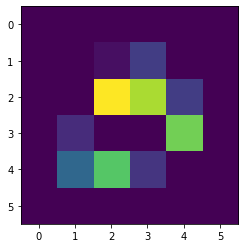

-1.0
Prediction: [0]


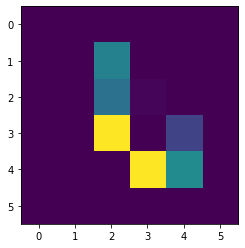

1.0
Prediction: [0]


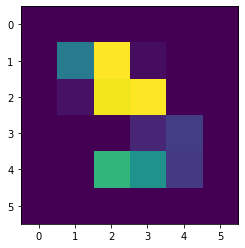

-1.0
Prediction: [0]


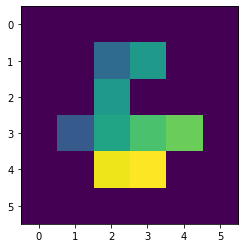

1.0
Prediction: [0]


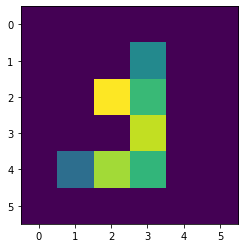

1.0
Prediction: [1]


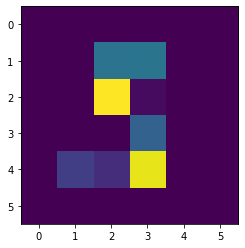

1.0
Prediction: [1]


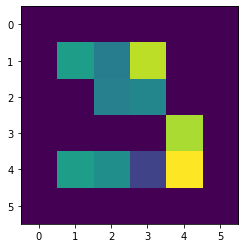

1.0
Prediction: [1]


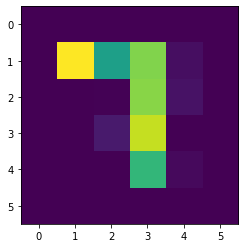

-1.0
Prediction: [0]


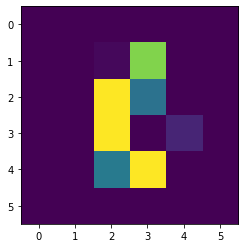

-1.0
Prediction: [1]


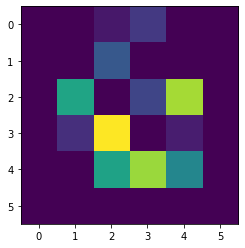

1.0
Prediction: [0]


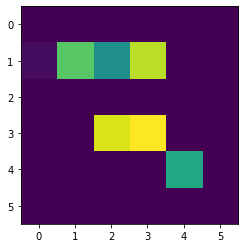

-1.0
Prediction: [0]


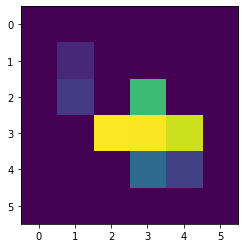

-1.0
Prediction: [0]


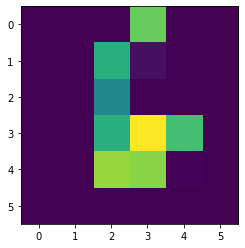

-1.0
Prediction: [1]


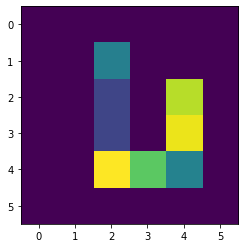

-1.0
Prediction: [0]


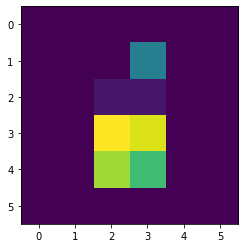

-1.0
Prediction: [0]


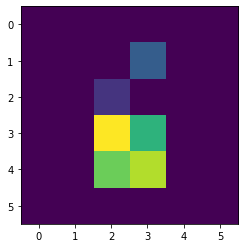

1.0
Prediction: [1]


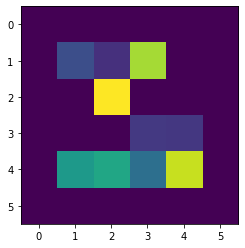

-1.0
Prediction: [0]


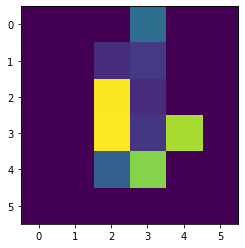

-1.0
Prediction: [0]


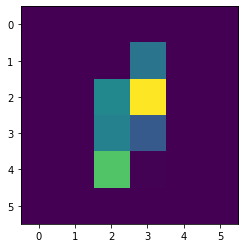

1.0
Prediction: [0]


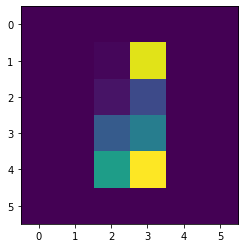

-1.0
Prediction: [0]


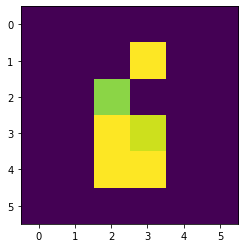

-1.0
Prediction: [1]


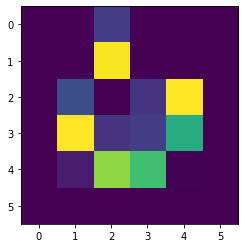

1.0
Prediction: [1]


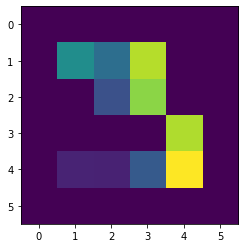

1.0
Prediction: [1]


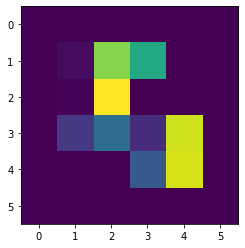

1.0
Prediction: [1]


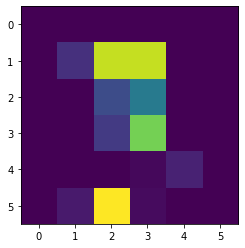

-1.0
Prediction: [0]


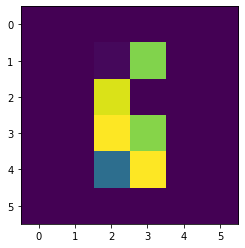

-1.0
Prediction: [0]


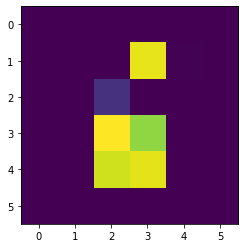

-1.0
Prediction: [0]


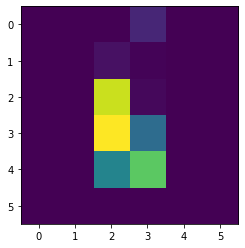

1.0
Prediction: [1]


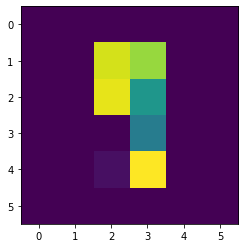

1.0
Prediction: [0]


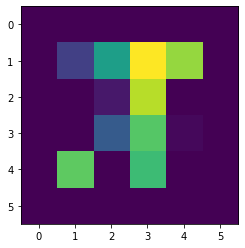

-1.0
Prediction: [0]


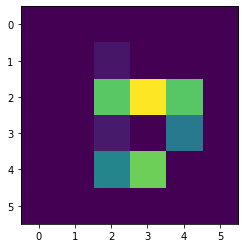

-1.0
Prediction: [0]


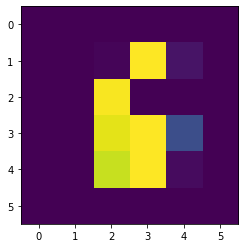

-1.0
Prediction: [0]


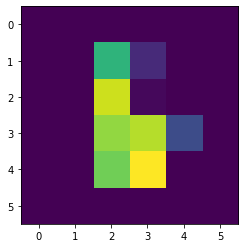

1.0
Prediction: [1]


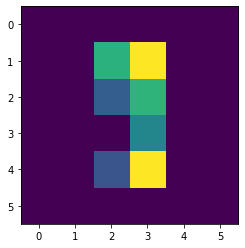

-1.0
Prediction: [0]


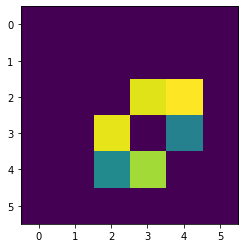

-1.0
Prediction: [1]


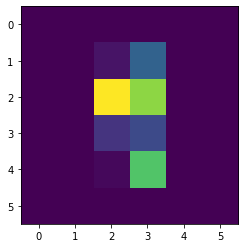

-1.0
Prediction: [0]


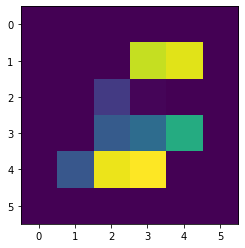

1.0
Prediction: [0]


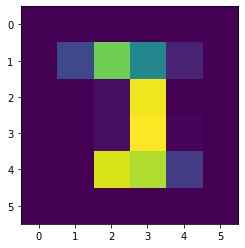

-1.0
Prediction: [0]


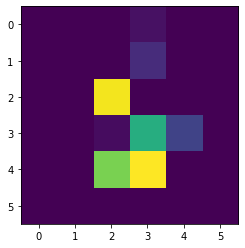

-1.0
Prediction: [0]


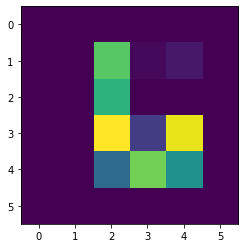

1.0
Prediction: [1]


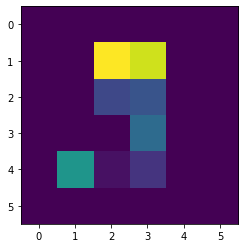

-1.0
Prediction: [0]


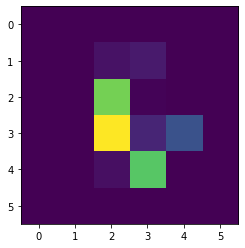

-1.0
Prediction: [0]


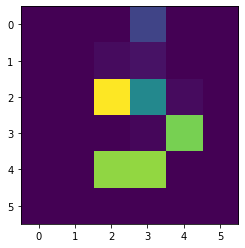

-1.0
Prediction: [0]


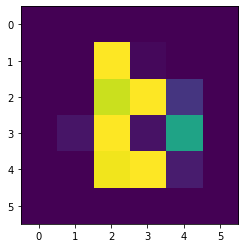

1.0
Prediction: [1]


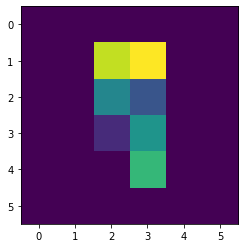

1.0
Prediction: [1]


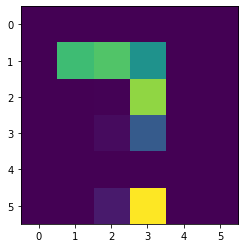

1.0
Prediction: [1]


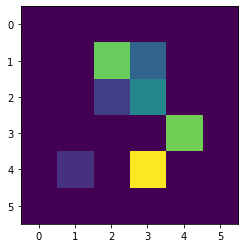

1.0
Prediction: [0]


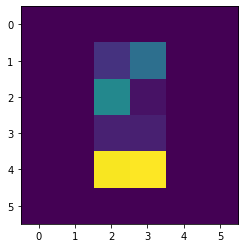

-1.0
Prediction: [0]


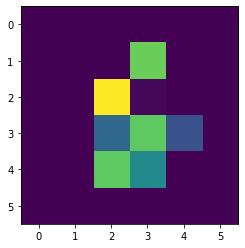

1.0
Prediction: [1]


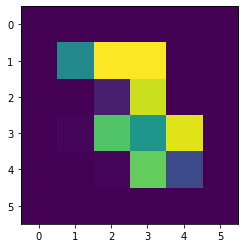

1.0
Prediction: [1]


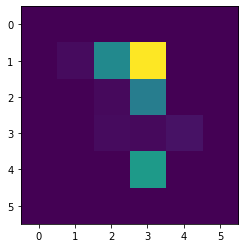

-1.0
Prediction: [1]


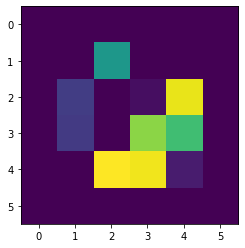

1.0
Prediction: [1]


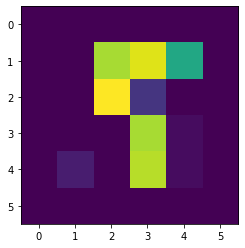

-1.0
Prediction: [0]


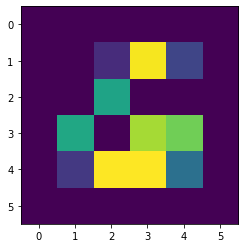

-1.0
Prediction: [0]


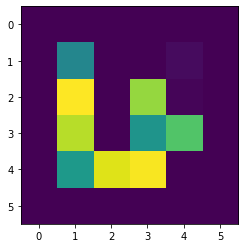

-1.0
Prediction: [0]


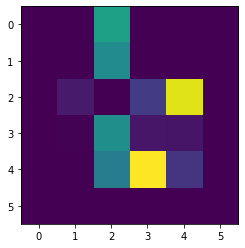

-1.0
Prediction: [0]


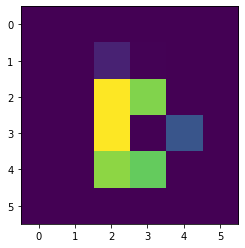

1.0
Prediction: [1]


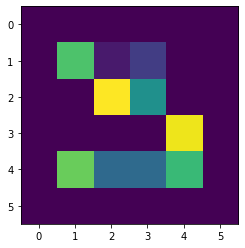

1.0
Prediction: [1]


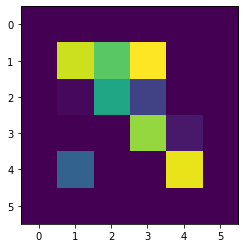

1.0
Prediction: [0]


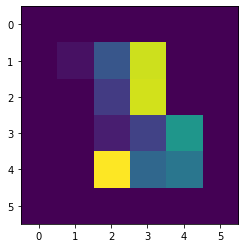

1.0
Prediction: [1]


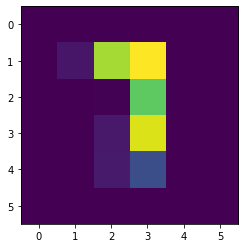

-1.0
Prediction: [0]


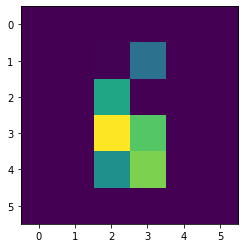

1.0
Prediction: [0]


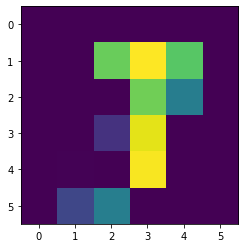

1.0
Prediction: [0]


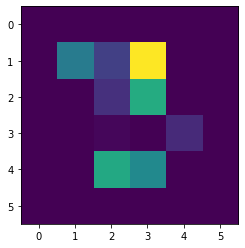

1.0
Prediction: [1]


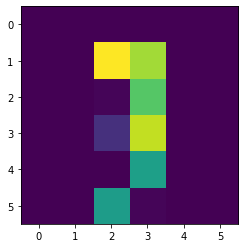

-1.0
Prediction: [0]


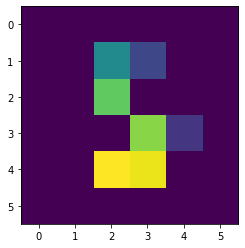

1.0
Prediction: [0]


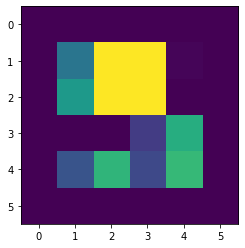

1.0
Prediction: [1]


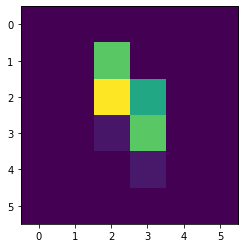

-1.0
Prediction: [0]


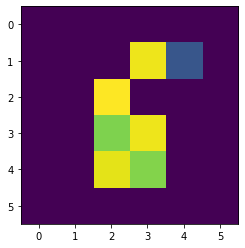

-1.0
Prediction: [0]


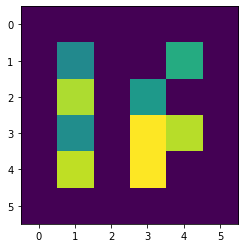

1.0
Prediction: [1]


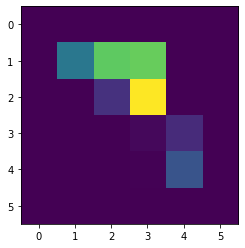

-1.0
Prediction: [0]


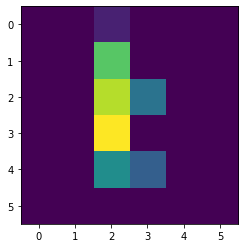

-1.0
Prediction: [0]


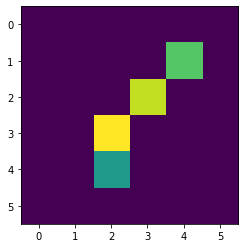

1.0
Prediction: [1]


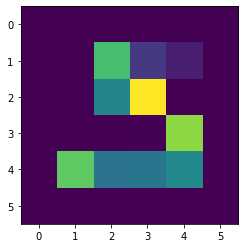

-1.0
Prediction: [1]


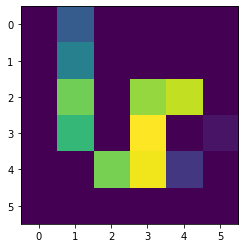

-1.0
Prediction: [1]


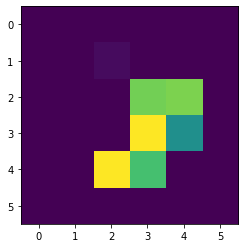

-1.0
Prediction: [0]


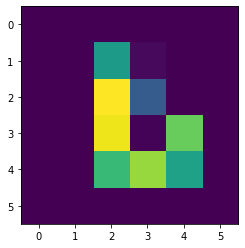

1.0
Prediction: [1]


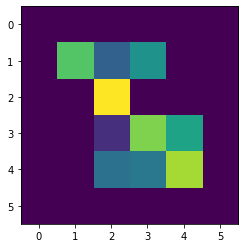

1.0
Prediction: [0]


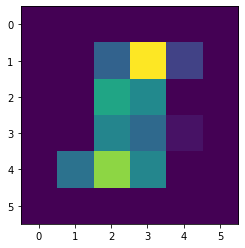

-1.0
Prediction: [0]


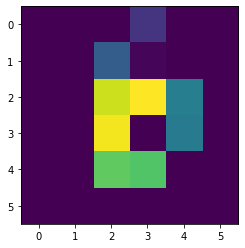

-1.0
Prediction: [0]


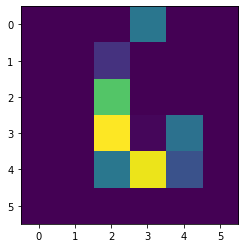

-1.0
Prediction: [0]


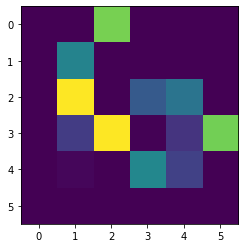

1.0
Prediction: [1]


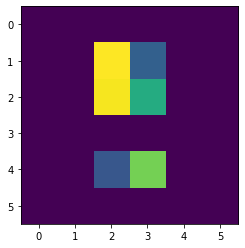

-1.0
Prediction: [0]


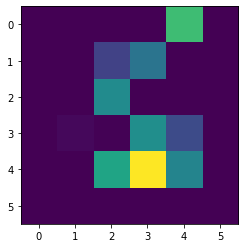

-1.0
Prediction: [0]


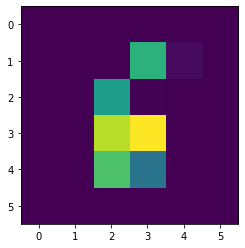

-1.0
Prediction: [1]


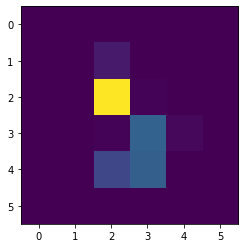

-1.0
Prediction: [0]


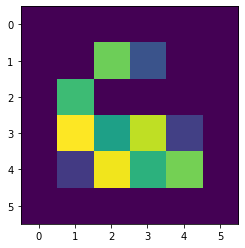

1.0
Prediction: [0]


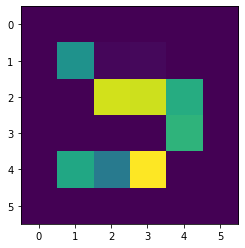

1.0
Prediction: [0]


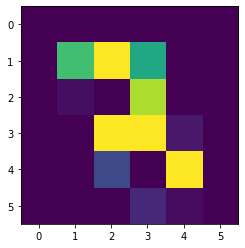

1.0
Prediction: [1]


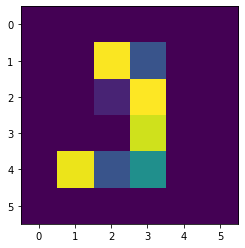

-1.0
Prediction: [0]


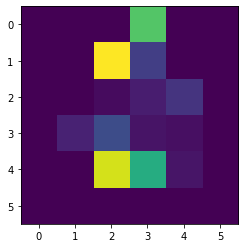

1.0
Prediction: [0]


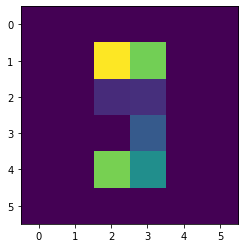

-1.0
Prediction: [0]


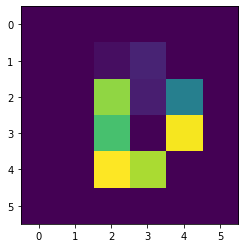

1.0
Prediction: [0]


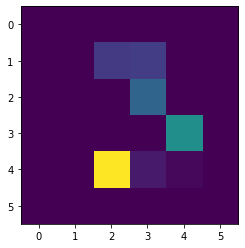

1.0
Prediction: [0]


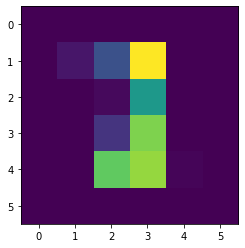

1.0
Prediction: [0]


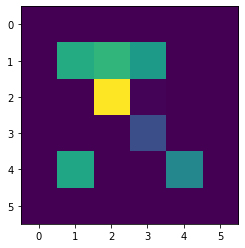

-1.0
Prediction: [1]


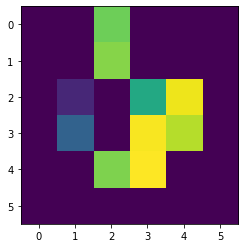

1.0
Prediction: [0]


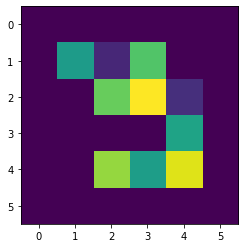

1.0
Prediction: [0]


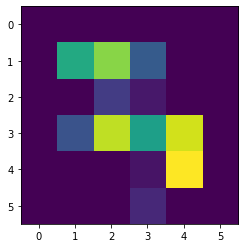

1.0
Prediction: [1]


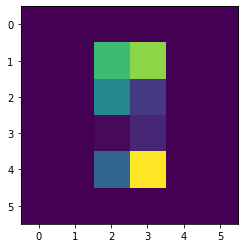

1.0
Prediction: [0]


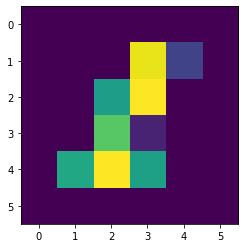

1.0
Prediction: [0]


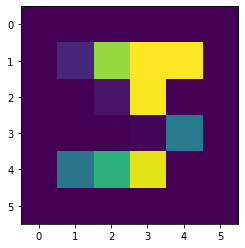

1.0
Prediction: [1]


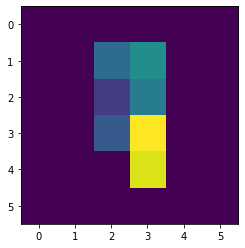

-1.0
Prediction: [0]


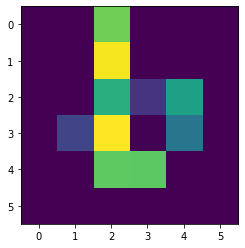

-1.0
Prediction: [0]


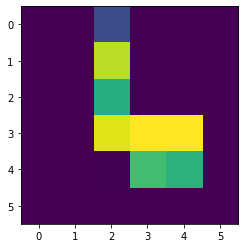

-1.0
Prediction: [0]


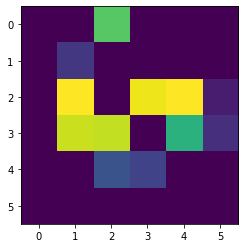

1.0
Prediction: [1]


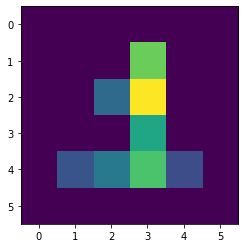

1.0
Prediction: [1]


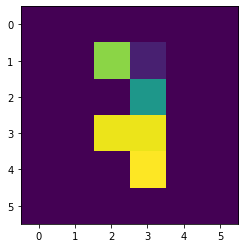

1.0
Prediction: [0]


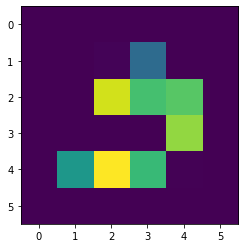

-1.0
Prediction: [0]


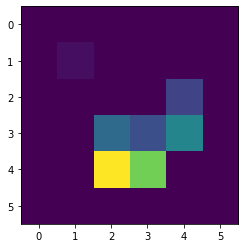

-1.0
Prediction: [0]


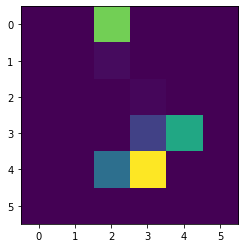

1.0
Prediction: [0]


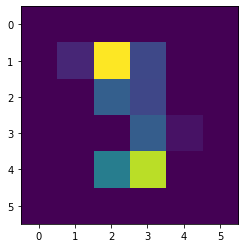

-1.0
Prediction: [0]


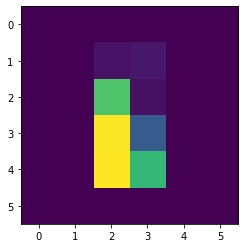

-1.0
Prediction: [0]


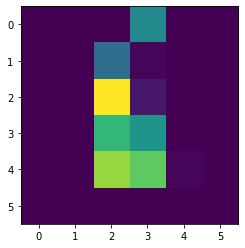

-1.0
Prediction: [0]


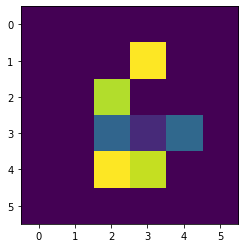

1.0
Prediction: [0]


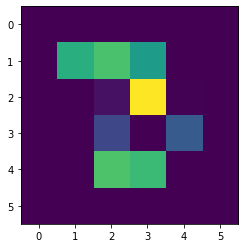

1.0
Prediction: [0]


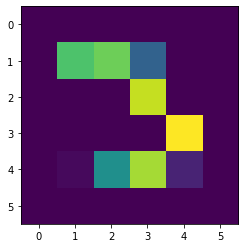

1.0
Prediction: [1]


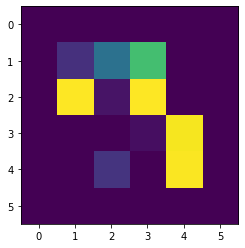

-1.0
Prediction: [0]


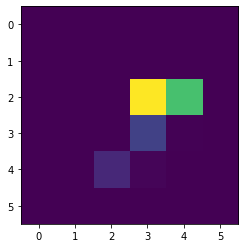

1.0
Prediction: [1]


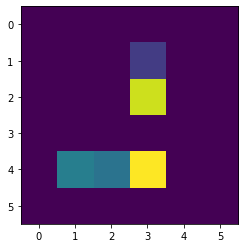

1.0
Prediction: [1]


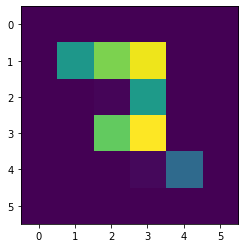

-1.0
Prediction: [0]


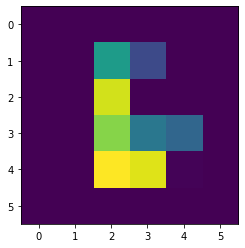

1.0
Prediction: [0]


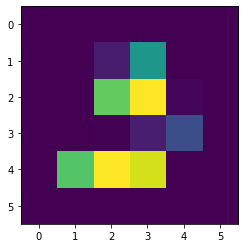

1.0
Prediction: [1]


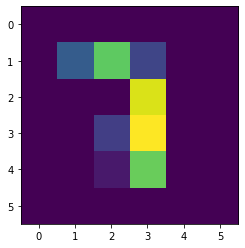

1.0
Prediction: [0]


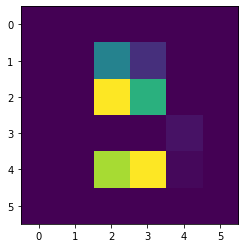

1.0
Prediction: [0]


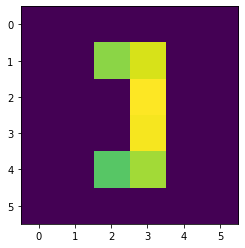

-1.0
Prediction: [0]


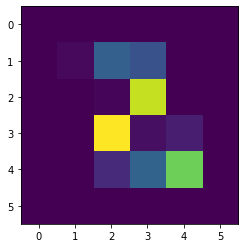

-1.0
Prediction: [0]


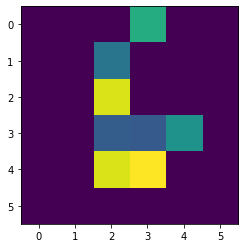

-1.0
Prediction: [0]


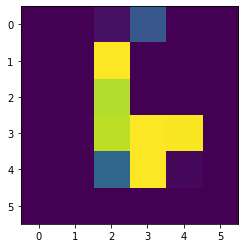

-1.0
Prediction: [1]


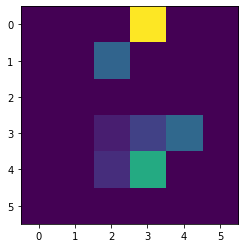

-1.0
Prediction: [0]


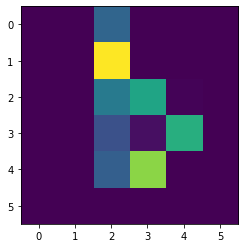

-1.0
Prediction: [0]


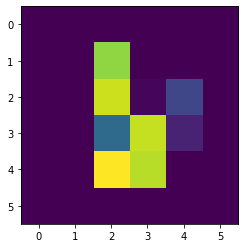

-1.0
Prediction: [0]


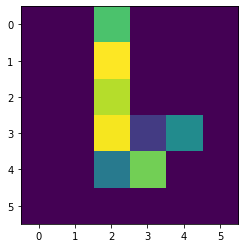

-1.0
Prediction: [0]


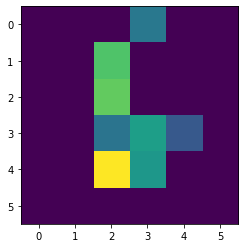

-1.0
Prediction: [0]


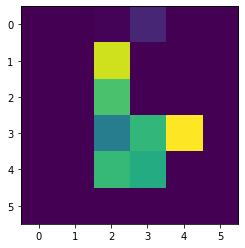

1.0
Prediction: [1]


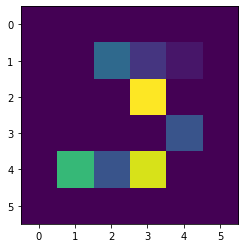

1.0
Prediction: [1]


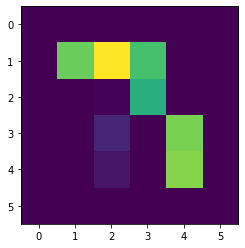

-1.0
Prediction: [0]


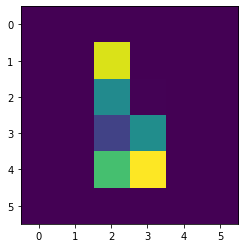

1.0
Prediction: [0]


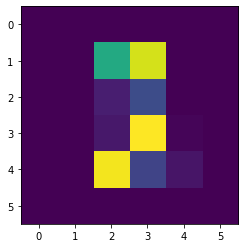

1.0
Prediction: [1]


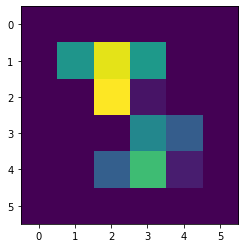

-1.0
Prediction: [1]


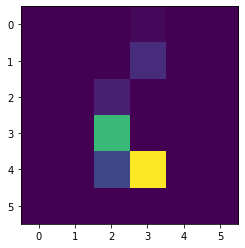

1.0
Prediction: [1]


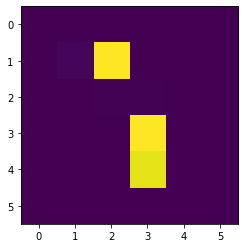

1.0
Prediction: [1]


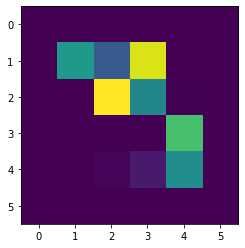

-1.0
Prediction: [0]


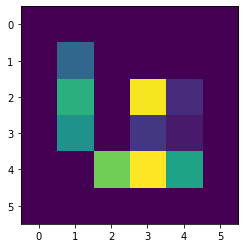

-1.0
Prediction: [0]


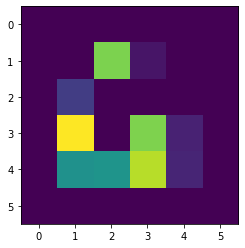

1.0
Prediction: [1]


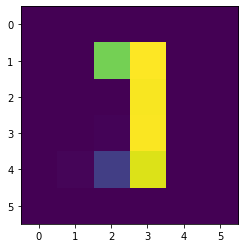

1.0
Prediction: [1]


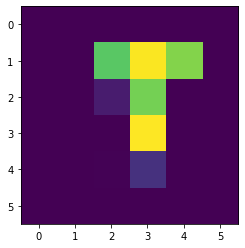

1.0
Prediction: [0]


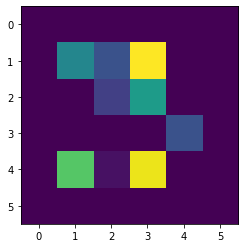

1.0
Prediction: [0]


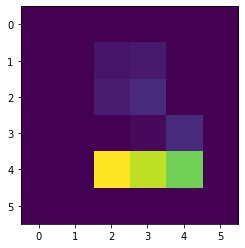

-1.0
Prediction: [0]


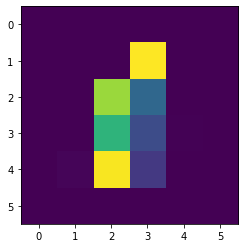

1.0
Prediction: [1]


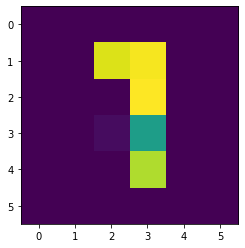

1.0
Prediction: [1]


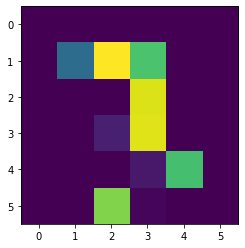

-1.0
Prediction: [0]


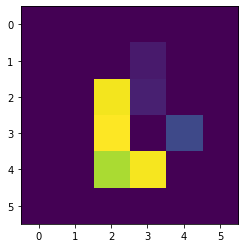

1.0
Prediction: [1]


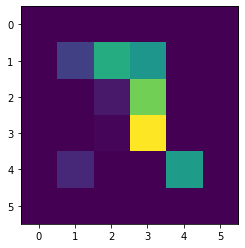

1.0
Prediction: [1]


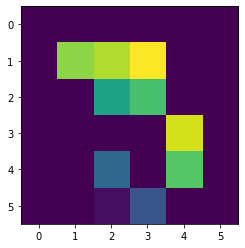

1.0
Prediction: [1]


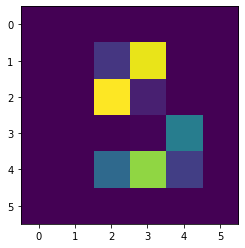

-1.0
Prediction: [0]


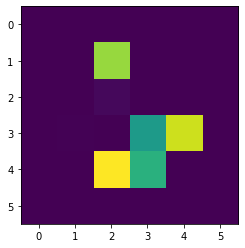

-1.0
Prediction: [0]


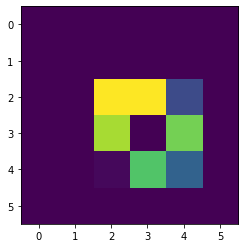

1.0
Prediction: [1]


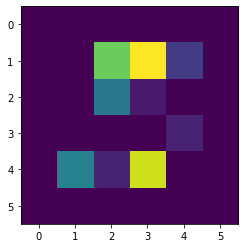

-1.0
Prediction: [0]


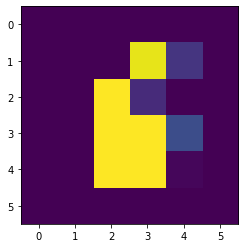

1.0
Prediction: [1]


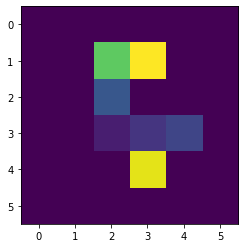

1.0
Prediction: [1]


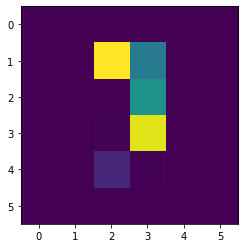

1.0
Prediction: [1]


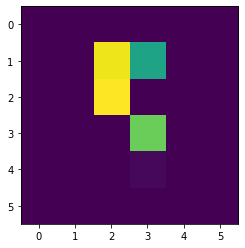

1.0
Prediction: [1]


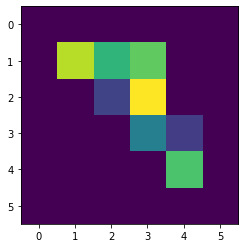

1.0
Prediction: [0]


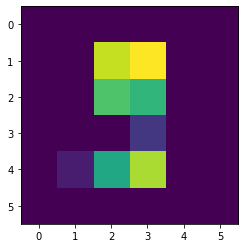

1.0
Prediction: [1]


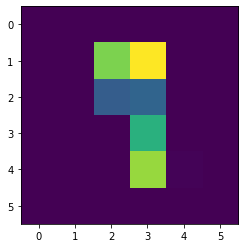

-1.0
Prediction: [0]


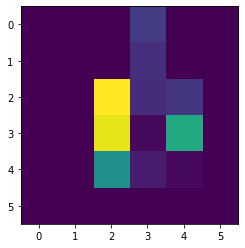

1.0
Prediction: [0]


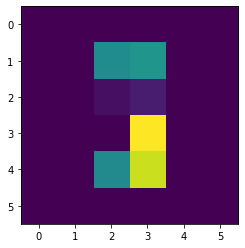

-1.0
Prediction: [0]


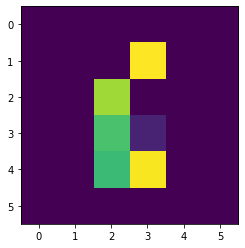

-1.0
Prediction: [0]


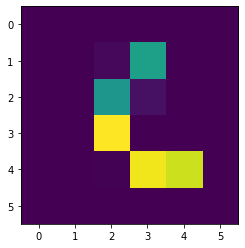

1.0
Prediction: [1]


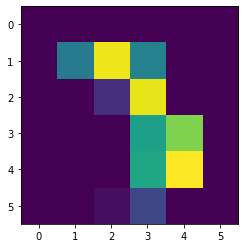

-1.0
Prediction: [0]


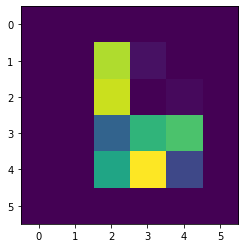

-1.0
Prediction: [0]


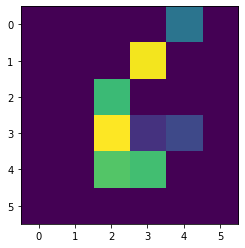

1.0
Prediction: [0]


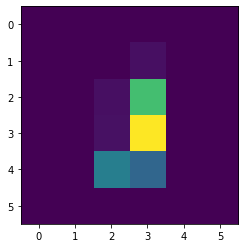

1.0
Prediction: [0]


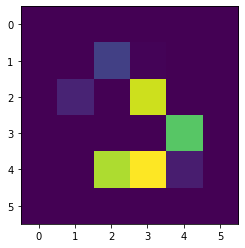

1.0
Prediction: [1]


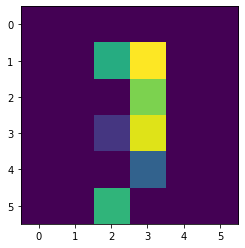

-1.0
Prediction: [1]


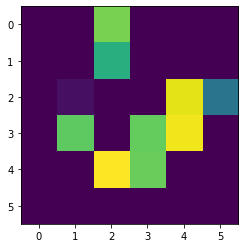

-1.0
Prediction: [1]


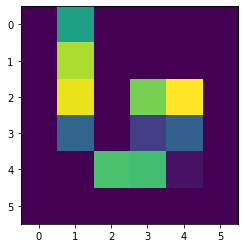

1.0
Prediction: [1]


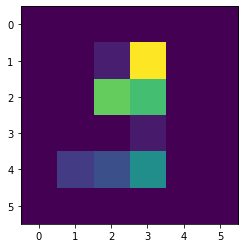

1.0
Prediction: [0]


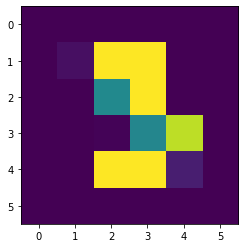

-1.0
Prediction: [1]


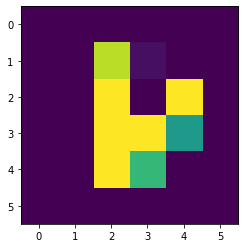

-1.0
Prediction: [0]


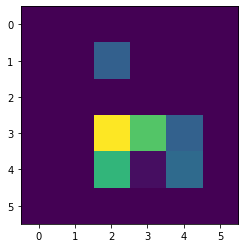

1.0
Prediction: [0]


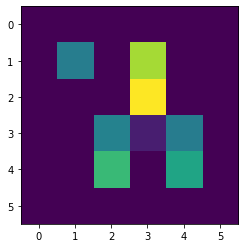

-1.0
Prediction: [0]


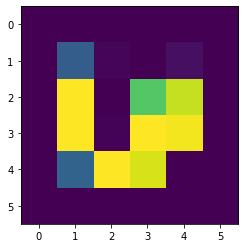

1.0
Prediction: [1]


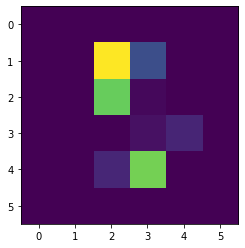

-1.0
Prediction: [0]


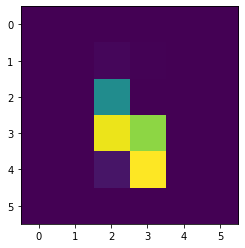

-1.0
Prediction: [0]


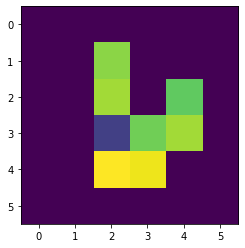

-1.0
Prediction: [1]


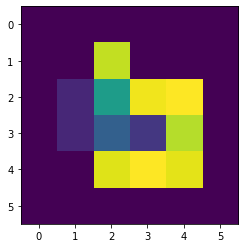

1.0
Prediction: [0]


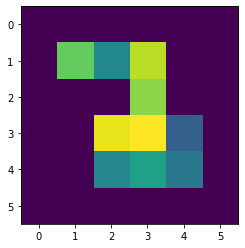

-1.0
Prediction: [0]


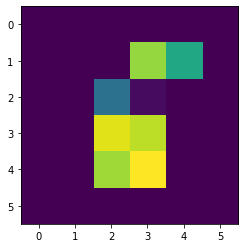

-1.0
Prediction: [0]


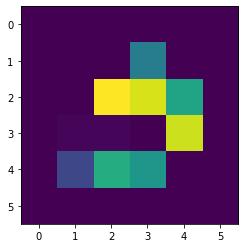

-1.0
Prediction: [1]


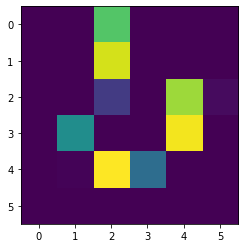

1.0
Prediction: [0]


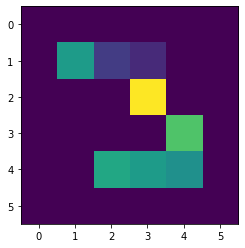

-1.0
Prediction: [0]


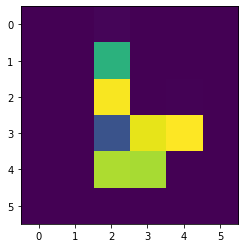

-1.0
Prediction: [0]


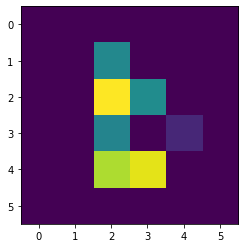

-1.0
Prediction: [1]


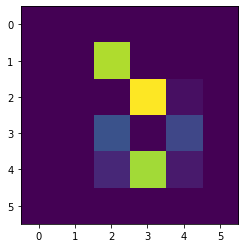

1.0
Prediction: [0]


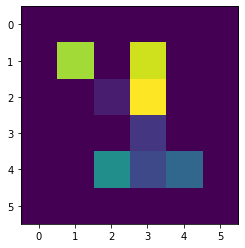

1.0
Prediction: [0]


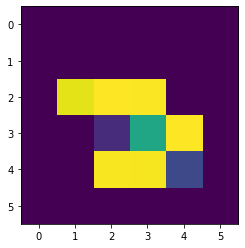

1.0
Prediction: [1]


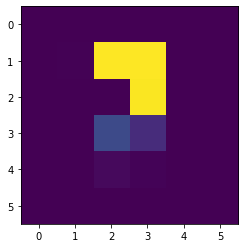

-1.0
Prediction: [0]


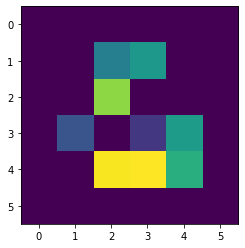

1.0
Prediction: [0]


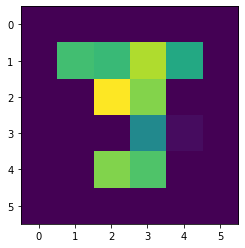

-1.0
Prediction: [0]


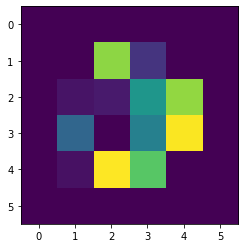

-1.0
Prediction: [0]


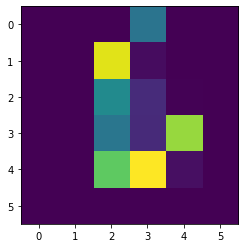

-1.0
Prediction: [0]


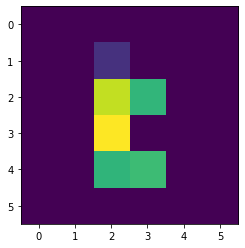

1.0
Prediction: [1]


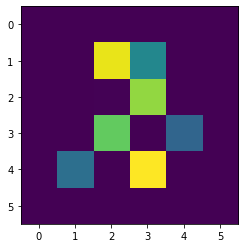

-1.0
Prediction: [1]


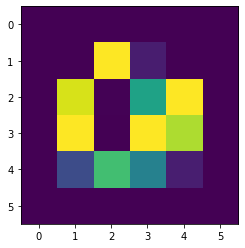

1.0
Prediction: [1]


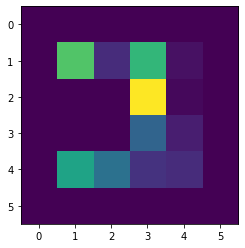

1.0
Prediction: [0]


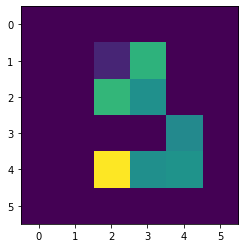

-1.0
Prediction: [0]


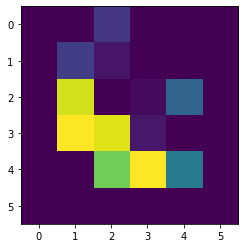

-1.0
Prediction: [0]


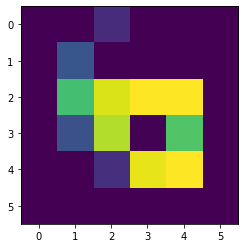

-1.0
Prediction: [0]


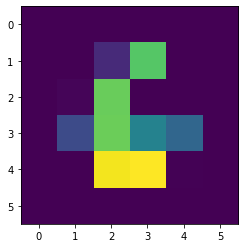

1.0
Prediction: [0]


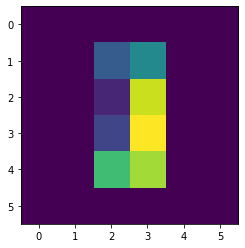

-1.0
Prediction: [0]


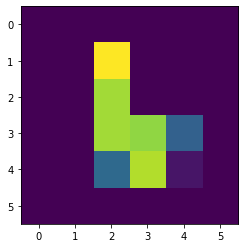

1.0
Prediction: [0]


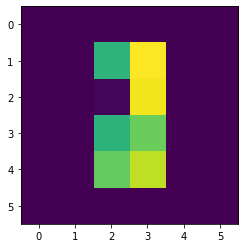

-1.0
Prediction: [0]


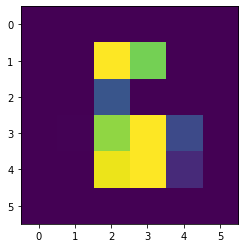

1.0
Prediction: [1]


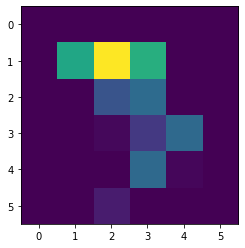

-1.0
Prediction: [1]


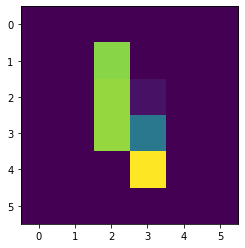

1.0
Prediction: [1]


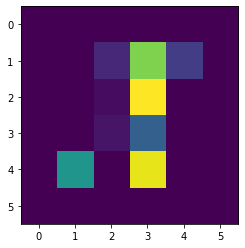

-1.0
Prediction: [0]


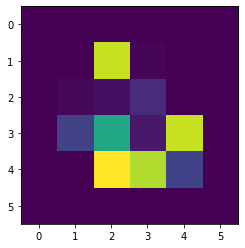

1.0
Prediction: [0]


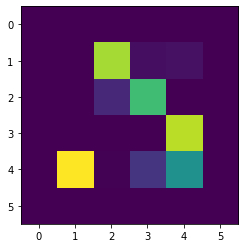

1.0
Prediction: [1]


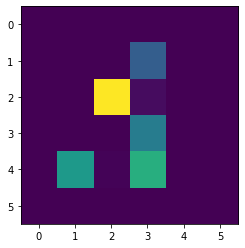

1.0
Prediction: [1]


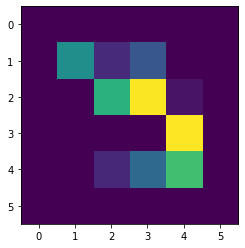

1.0
Prediction: [0]


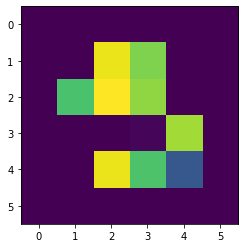

1.0
Prediction: [1]


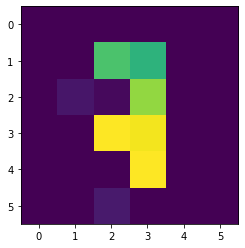

-1.0
Prediction: [0]


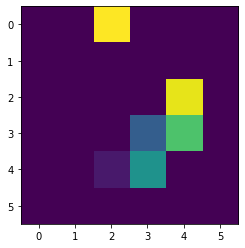

1.0
Prediction: [0]


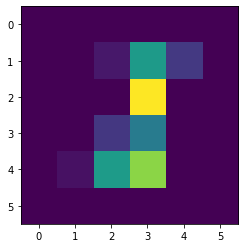

1.0
Prediction: [1]


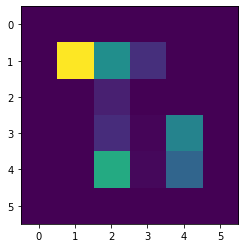

1.0
Prediction: [1]


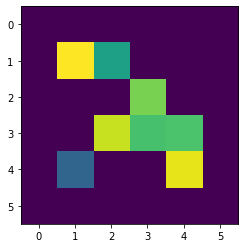

1.0
Prediction: [1]


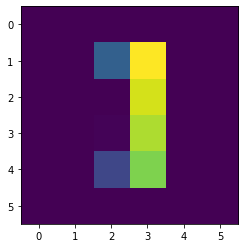

-1.0
Prediction: [0]


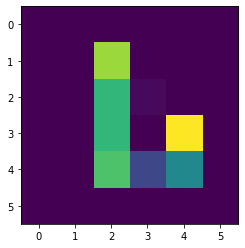

1.0
Prediction: [0]


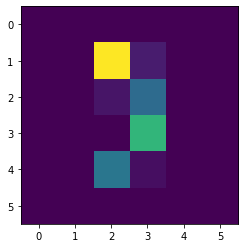

-1.0
Prediction: [0]


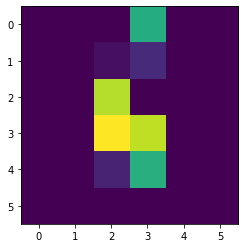

1.0
Prediction: [1]


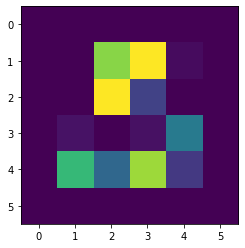

1.0
Prediction: [0]


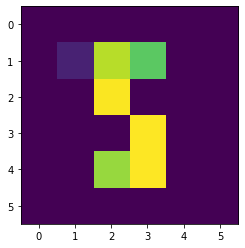

1.0
Prediction: [0]


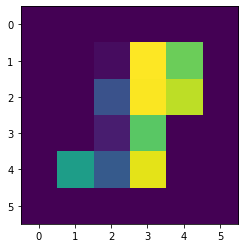

-1.0
Prediction: [0]


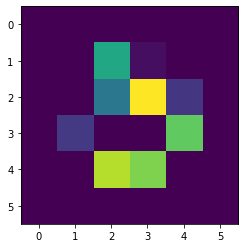

1.0
Prediction: [1]


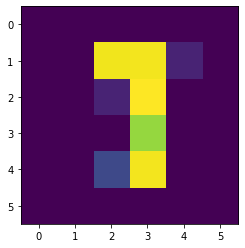

-1.0
Prediction: [0]


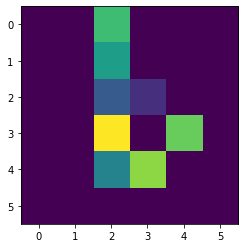

1.0
Prediction: [1]


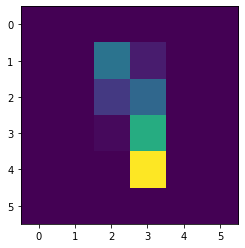

1.0
Prediction: [0]


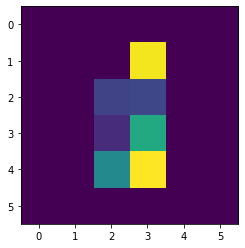

1.0
Prediction: [0]


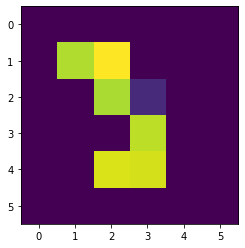

1.0
Prediction: [0]


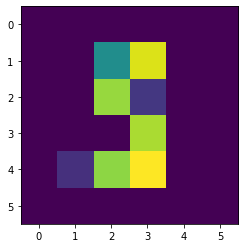

-1.0
Prediction: [1]


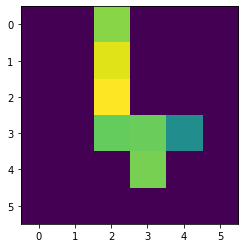

-1.0
Prediction: [0]


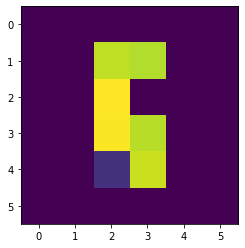

-1.0
Prediction: [0]


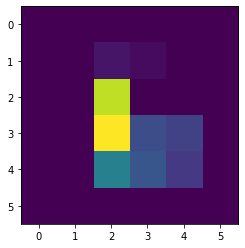

1.0
Prediction: [1]


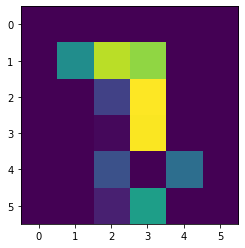

1.0
Prediction: [1]


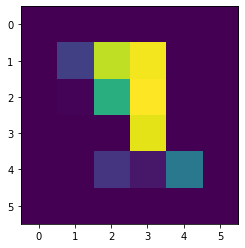

-1.0
Prediction: [0]


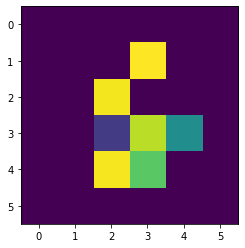

-1.0
Prediction: [0]


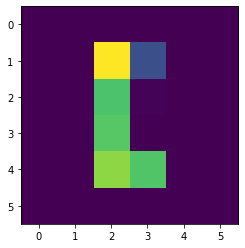

-1.0
Prediction: [0]


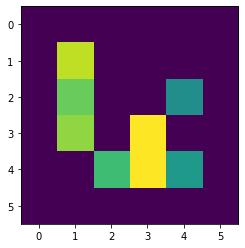

-1.0
Prediction: [0]


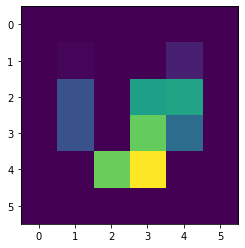

-1.0
Prediction: [0]


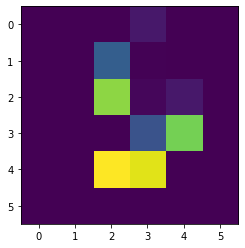

1.0
Prediction: [0]


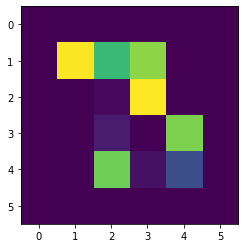

1.0
Prediction: [0]


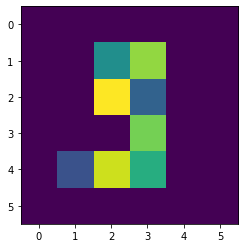

-1.0
Prediction: [0]


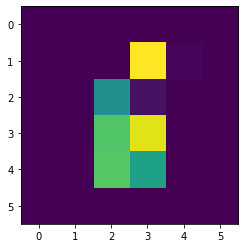

-1.0
Prediction: [0]


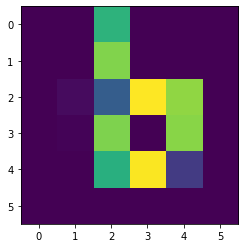

-1.0
Prediction: [0]


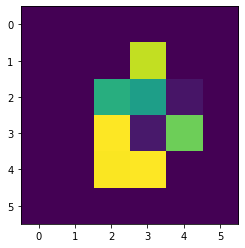

-1.0
Prediction: [0]


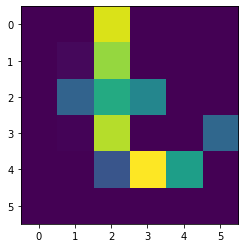

1.0
Prediction: [1]


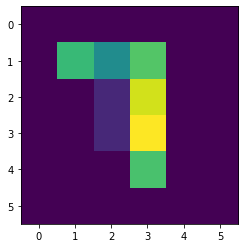

1.0
Prediction: [1]


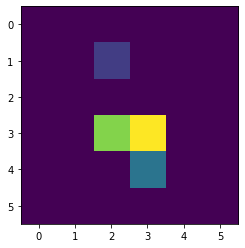

1.0
Prediction: [1]


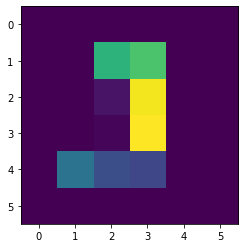

1.0
Prediction: [1]


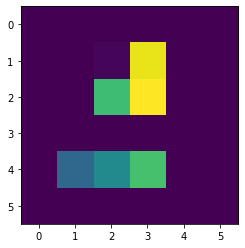

1.0
Prediction: [0]


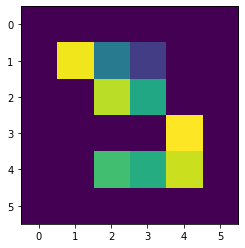

1.0
Prediction: [1]


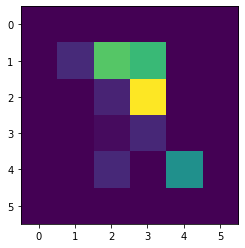

-1.0
Prediction: [0]


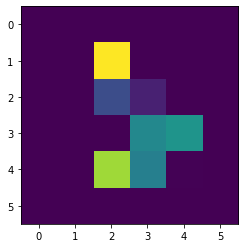

1.0
Prediction: [0]


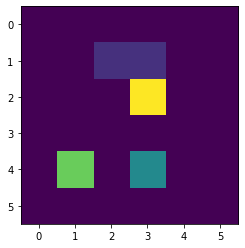

1.0
Prediction: [1]


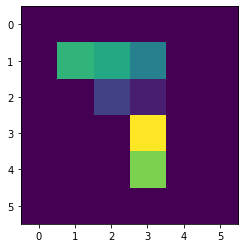

1.0
Prediction: [1]


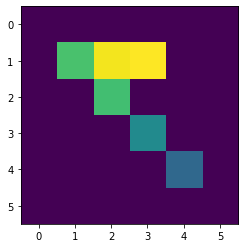

1.0
Prediction: [0]


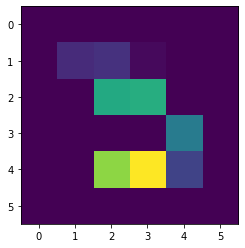

-1.0
Prediction: [0]


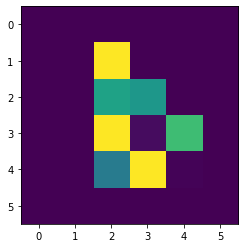

1.0
Prediction: [0]


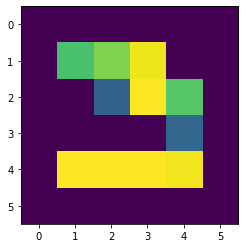

-1.0
Prediction: [1]


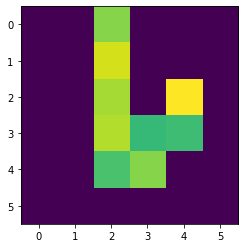

1.0
Prediction: [0]


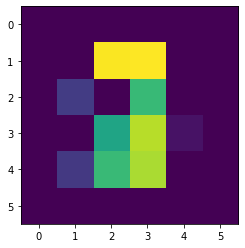

-1.0
Prediction: [0]


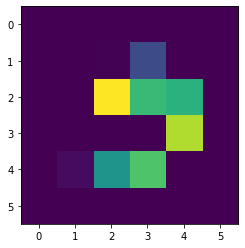

1.0
Prediction: [1]


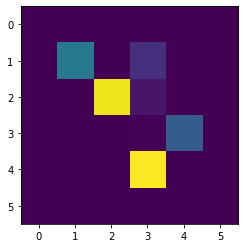

-1.0
Prediction: [0]


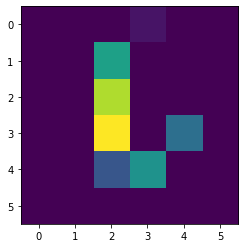

1.0
Prediction: [0]


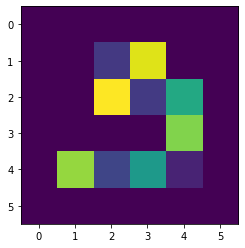

-1.0
Prediction: [0]


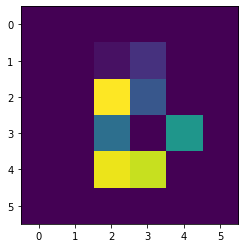

-1.0
Prediction: [1]


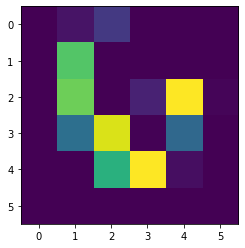

1.0
Prediction: [1]


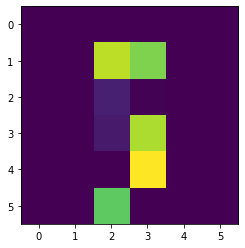

1.0
Prediction: [1]


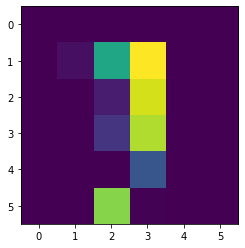

-1.0
Prediction: [0]


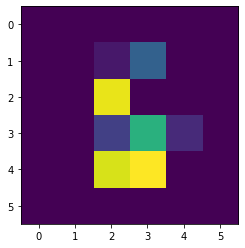

-1.0
Prediction: [0]


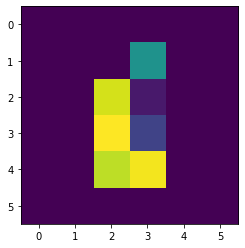

-1.0
Prediction: [0]


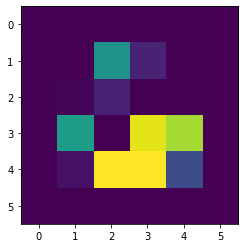

1.0
Prediction: [0]


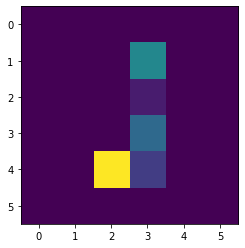

-1.0
Prediction: [0]


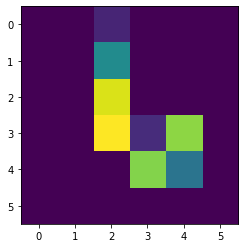

1.0
Prediction: [1]


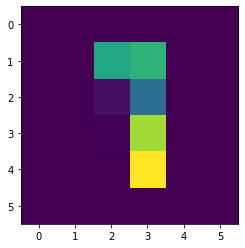

-1.0
Prediction: [1]


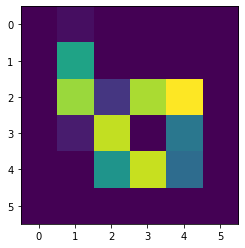

-1.0
Prediction: [0]


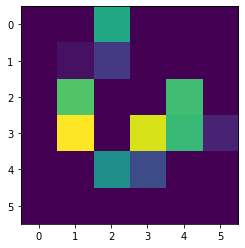

-1.0
Prediction: [0]


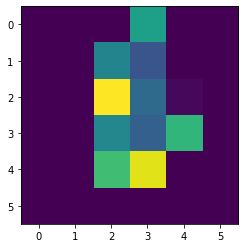

1.0
Prediction: [0]


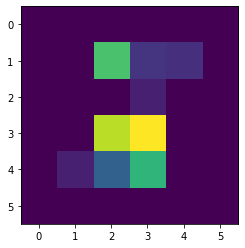

-1.0
Prediction: [0]


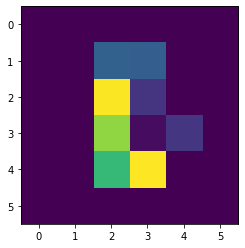

1.0
Prediction: [0]


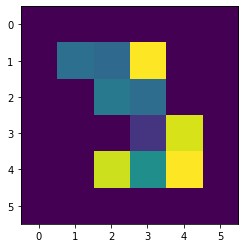

-1.0
Prediction: [0]


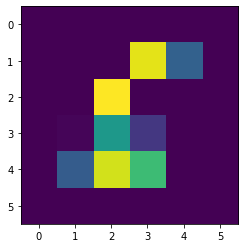

1.0
Prediction: [0]


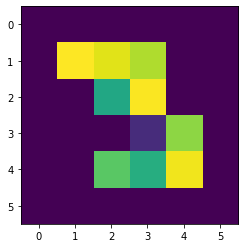

-1.0
Prediction: [0]


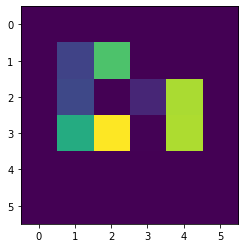

-1.0
Prediction: [0]


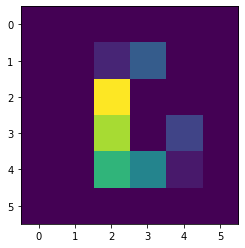

1.0
Prediction: [1]


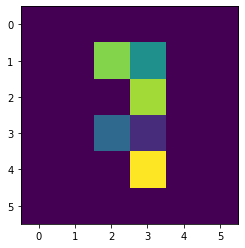

-1.0
Prediction: [0]


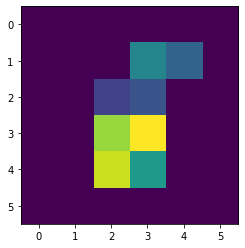

-1.0
Prediction: [0]


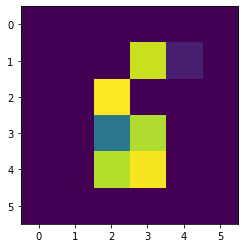

1.0
Prediction: [0]


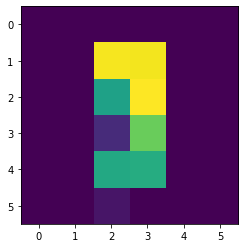

-1.0
Prediction: [0]


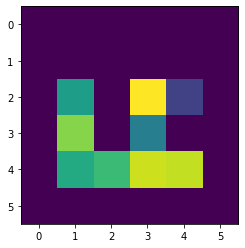

-1.0
Prediction: [0]


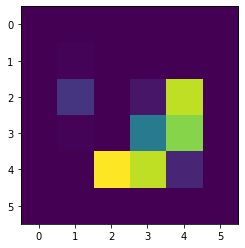

-1.0
Prediction: [0]


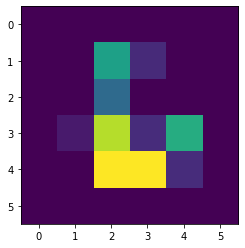

1.0
Prediction: [1]


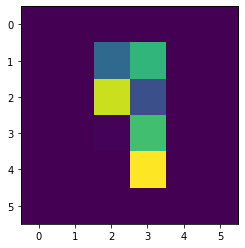

1.0
Prediction: [0]


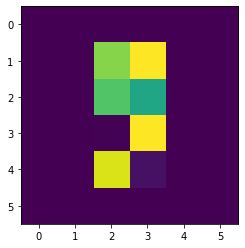

1.0
Prediction: [0]


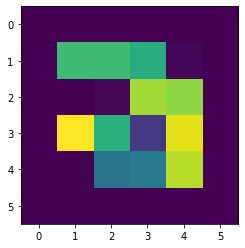

1.0
Prediction: [0]


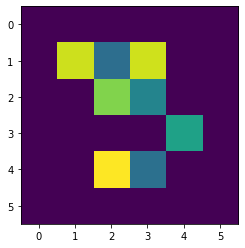

1.0
Prediction: [0]


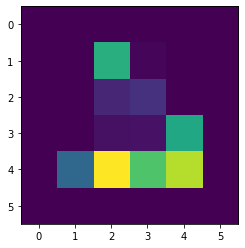

-1.0
Prediction: [1]


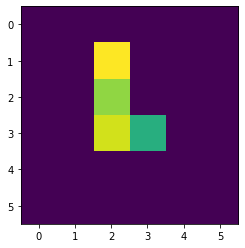

-1.0
Prediction: [0]


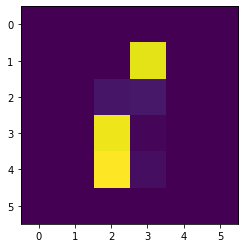

-1.0
Prediction: [0]


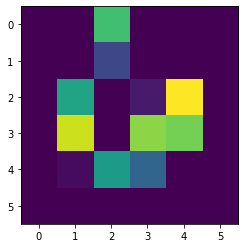

1.0
Prediction: [0]


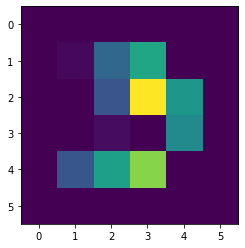

-1.0
Prediction: [0]


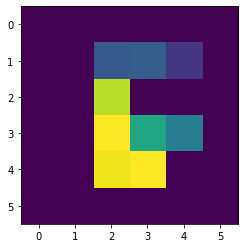

-1.0
Prediction: [0]


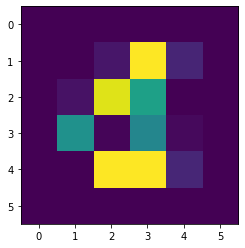

-1.0
Prediction: [0]


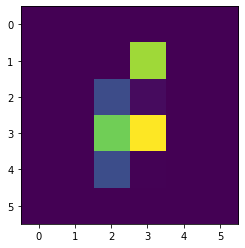

-1.0
Prediction: [0]


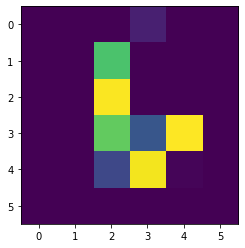

-1.0
Prediction: [0]


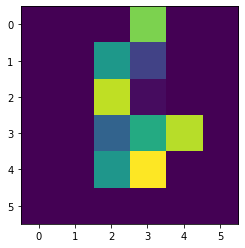

1.0
Prediction: [0]


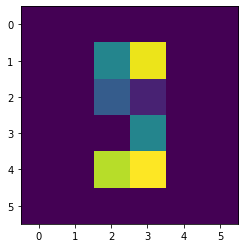

-1.0
Prediction: [0]


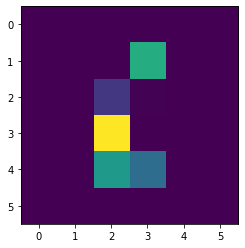

1.0
Prediction: [0]


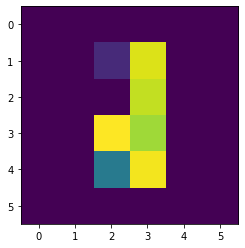

-1.0
Prediction: [0]


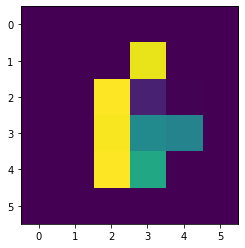

-1.0
Prediction: [0]


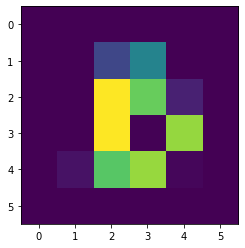

1.0
Prediction: [0]


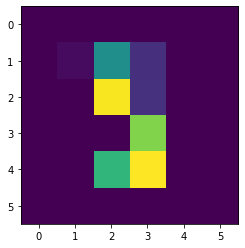

-1.0
Prediction: [0]


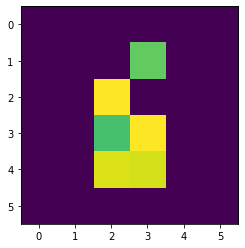

-1.0
Prediction: [0]


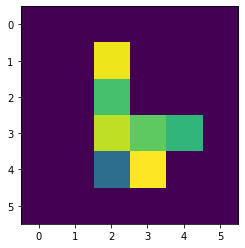

-1.0
Prediction: [0]


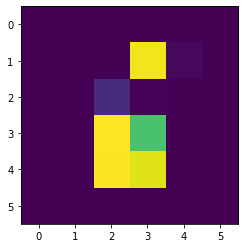

-1.0
Prediction: [0]


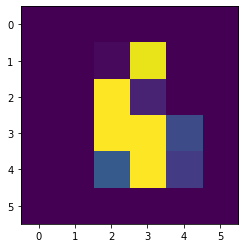

-1.0
Prediction: [0]


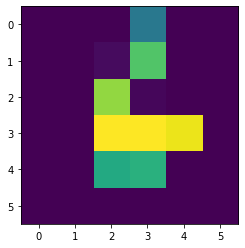

1.0
Prediction: [0]


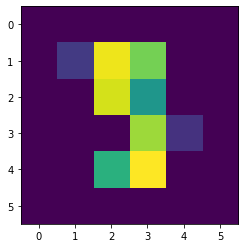

1.0
Prediction: [1]


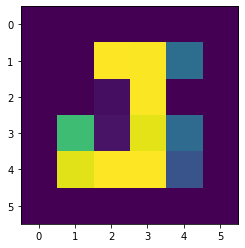

-1.0
Prediction: [0]


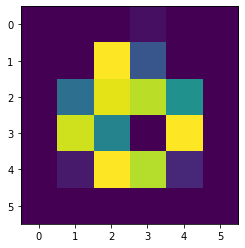

-1.0
Prediction: [0]


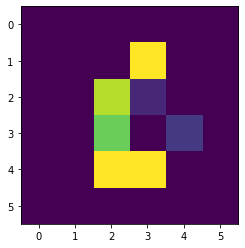

-1.0
Prediction: [0]


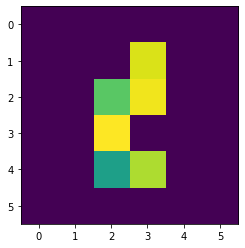

-1.0
Prediction: [0]


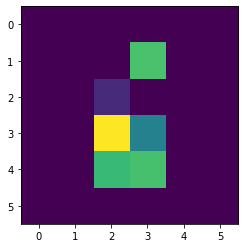

1.0
Prediction: [0]


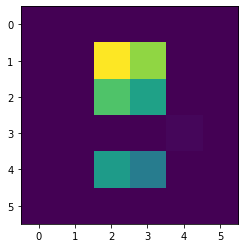

-1.0
Prediction: [0]


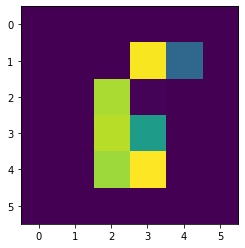

1.0
Prediction: [0]


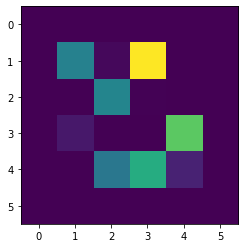

-1.0
Prediction: [0]


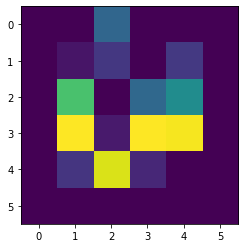

1.0
Prediction: [0]


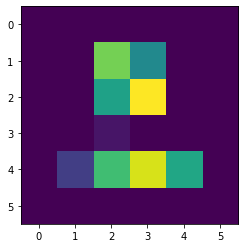

1.0
Prediction: [1]


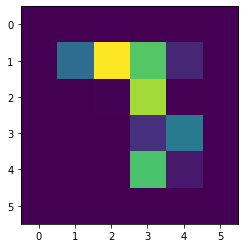

1.0
Prediction: [0]


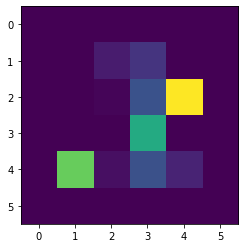

1.0
Prediction: [0]


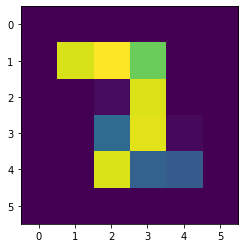

1.0
Prediction: [0]


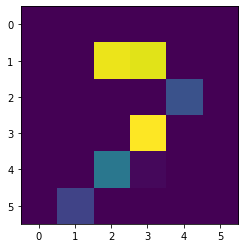

1.0
Prediction: [1]


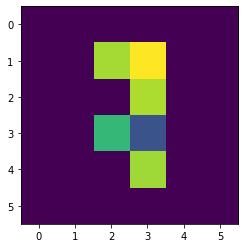

1.0
Prediction: [1]


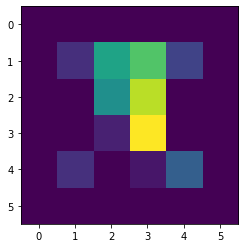

1.0
Prediction: [0]


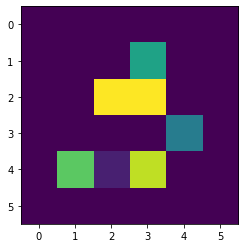

1.0
Prediction: [1]


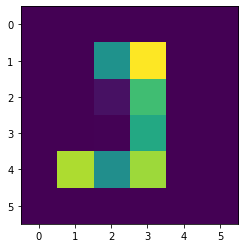

-1.0
Prediction: [0]


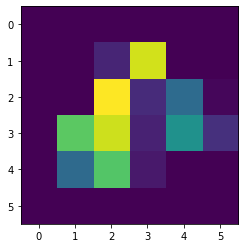

1.0
Prediction: [1]


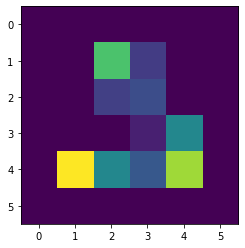

1.0
Prediction: [1]


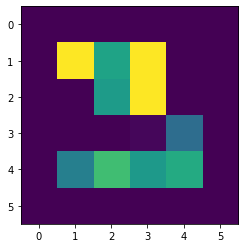

-1.0
Prediction: [0]


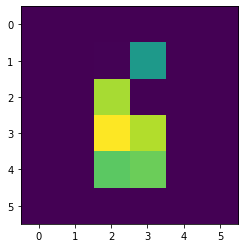

-1.0
Prediction: [0]


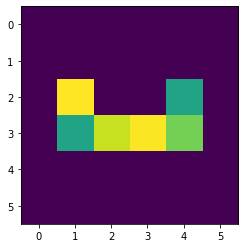

-1.0
Prediction: [1]


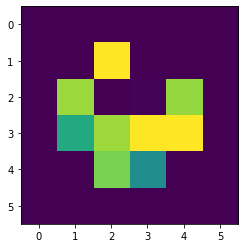

1.0
Prediction: [0]


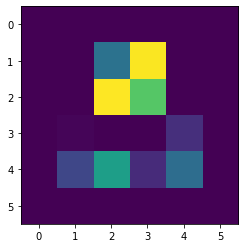

1.0
Prediction: [0]


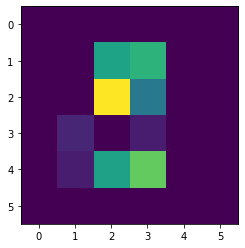

1.0
Prediction: [1]


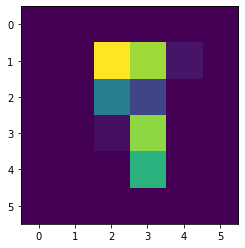

-1.0
Prediction: [0]


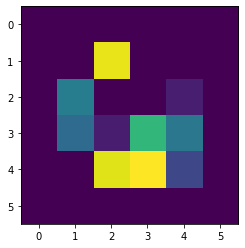

-1.0
Prediction: [1]


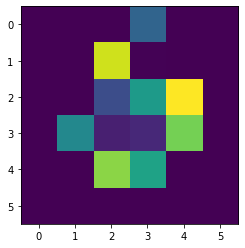

1.0
Prediction: [0]


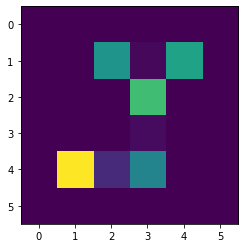

1.0
Prediction: [0]


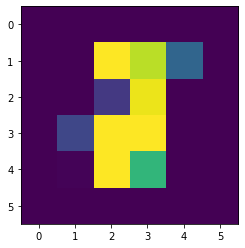

-1.0
Prediction: [0]


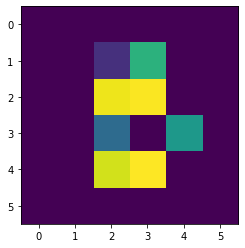

-1.0
Prediction: [0]


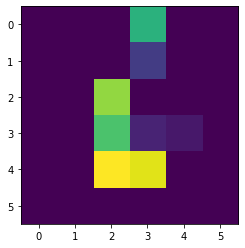

-1.0
Prediction: [0]


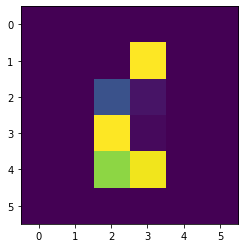

-1.0
Prediction: [0]


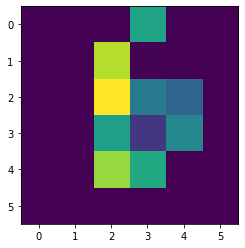

-1.0
Prediction: [0]


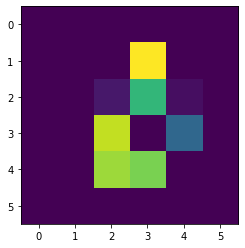

1.0
Prediction: [0]


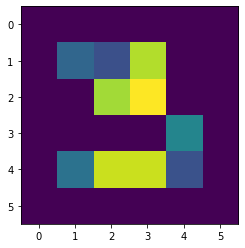

-1.0
Prediction: [0]


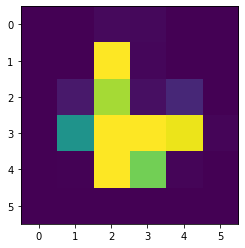

-1.0
Prediction: [0]


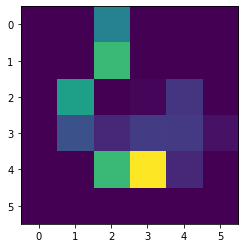

-1.0
Prediction: [0]


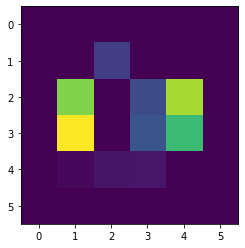

-1.0
Prediction: [0]


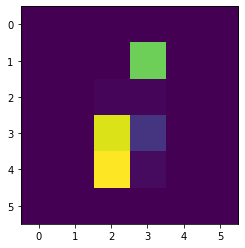

1.0
Prediction: [0]


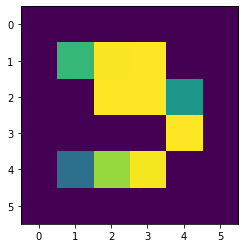

-1.0
Prediction: [0]


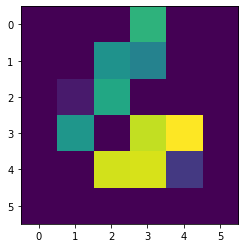

1.0
Prediction: [0]


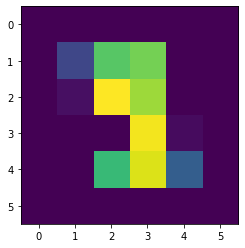

1.0
Prediction: [1]


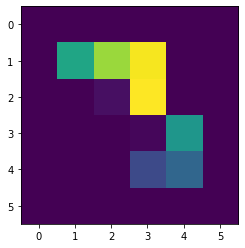

-1.0
Prediction: [1]


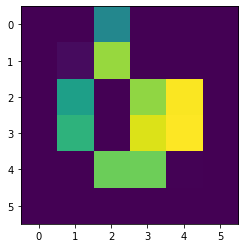

1.0
Prediction: [1]


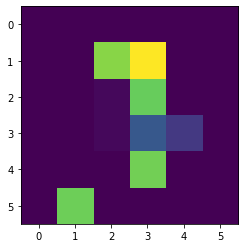

-1.0
Prediction: [0]


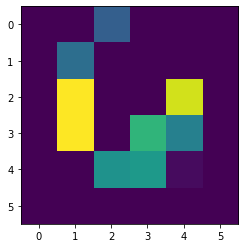

1.0
Prediction: [0]


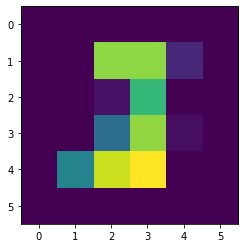

-1.0
Prediction: [0]


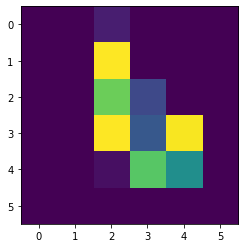

-1.0
Prediction: [1]


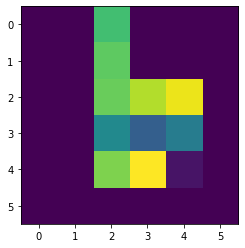

1.0
Prediction: [0]


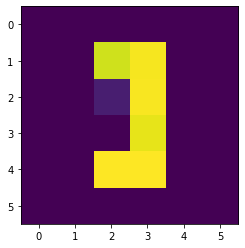

-1.0
Prediction: [1]


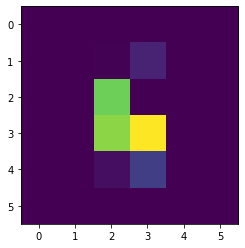

-1.0
Prediction: [1]


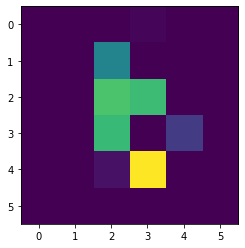

-1.0
Prediction: [0]


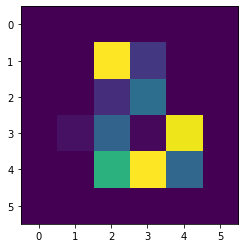

1.0
Prediction: [0]


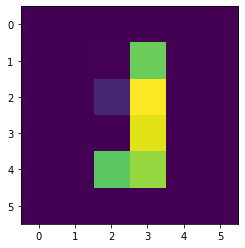

-1.0
Prediction: [0]


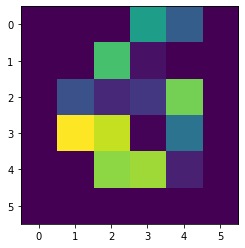

-1.0
Prediction: [0]


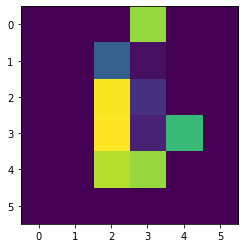

1.0
Prediction: [0]


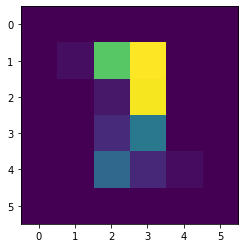

1.0
Prediction: [1]


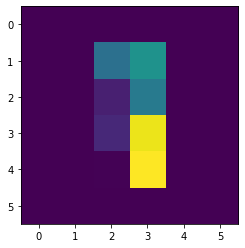

-1.0
Prediction: [1]


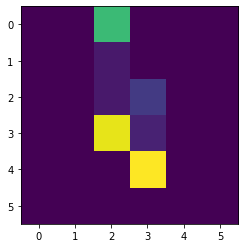

1.0
Prediction: [1]


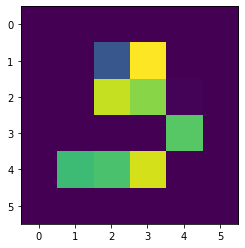

1.0
Prediction: [1]


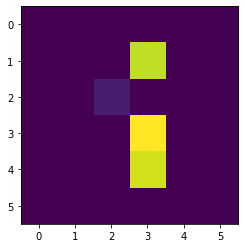

1.0
Prediction: [1]


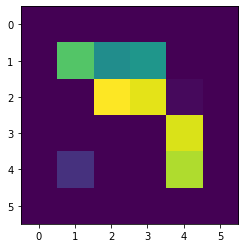

1.0
Prediction: [1]


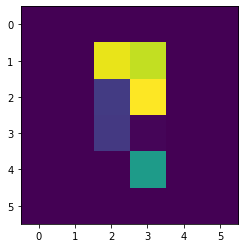

-1.0
Prediction: [1]


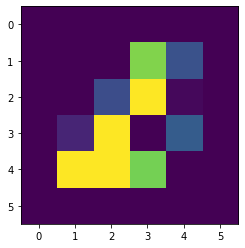

1.0
Prediction: [1]


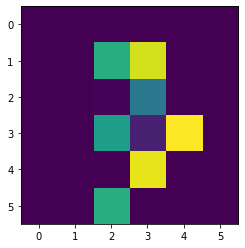

-1.0
Prediction: [1]


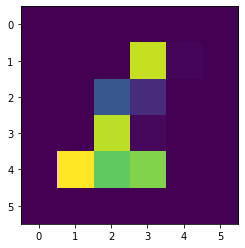

-1.0
Prediction: [0]


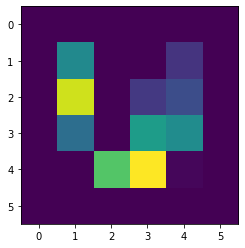

-1.0
Prediction: [0]


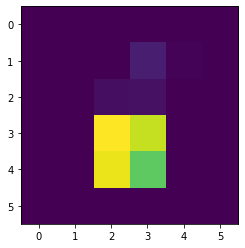

1.0
Prediction: [1]


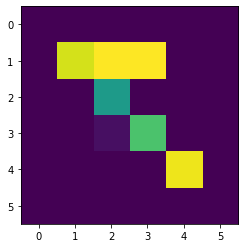

1.0
Prediction: [1]


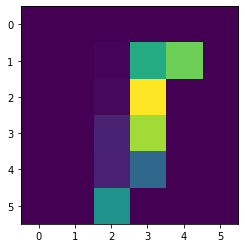

1.0
Prediction: [0]


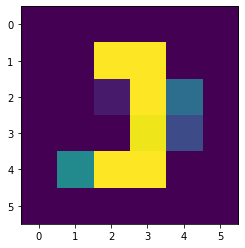

1.0
Prediction: [1]


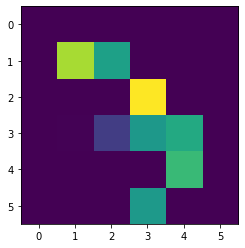

-1.0
Prediction: [0]


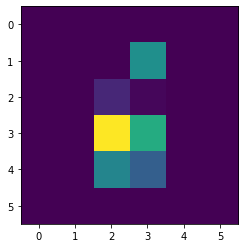

-1.0
Prediction: [0]


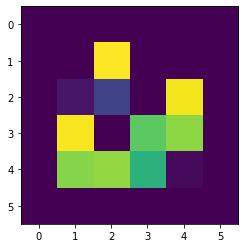

1.0
Prediction: [0]


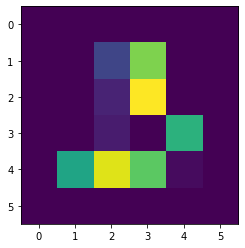

-1.0
Prediction: [0]


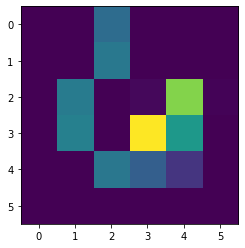

1.0
Prediction: [1]


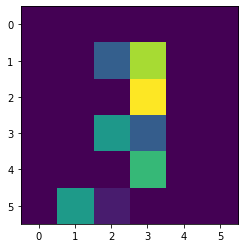

1.0
Prediction: [1]


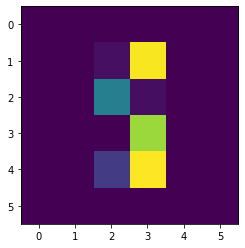

-1.0
Prediction: [1]


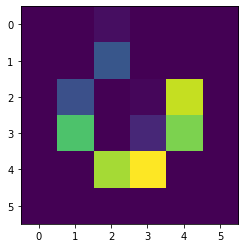

1.0
Prediction: [0]


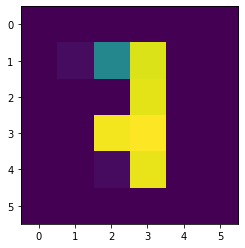

-1.0
Prediction: [0]


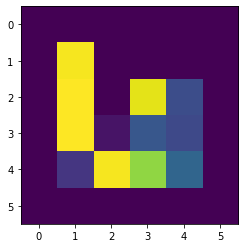

-1.0
Prediction: [0]


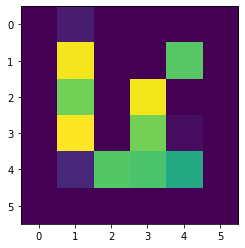

-1.0
Prediction: [1]


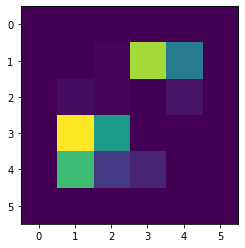

-1.0
Prediction: [0]


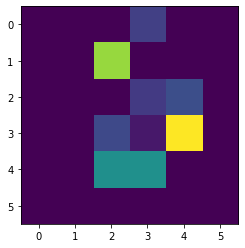

1.0
Prediction: [1]


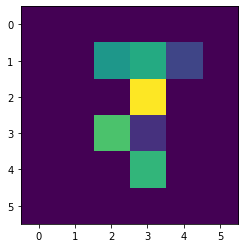

1.0
Prediction: [0]


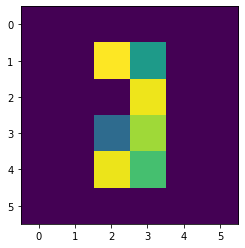

-1.0
Prediction: [0]


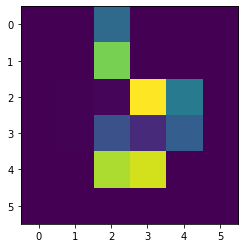

-1.0
Prediction: [0]


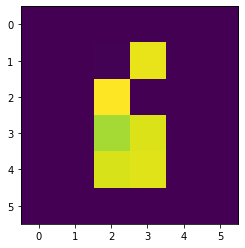

1.0
Prediction: [1]


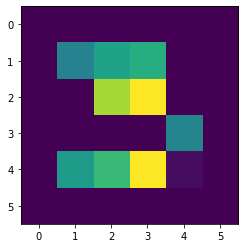

-1.0
Prediction: [0]


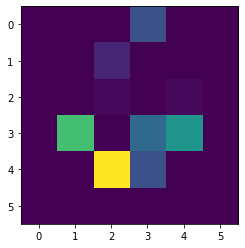

1.0
Prediction: [0]


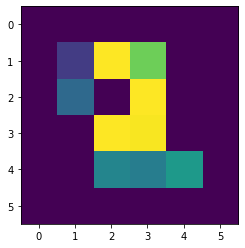

-1.0
Prediction: [0]


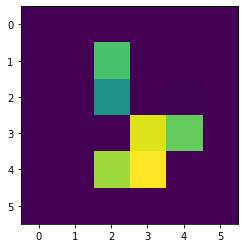

-1.0
Prediction: [0]


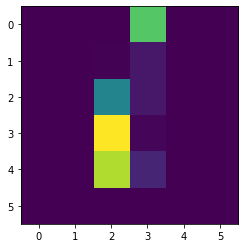

-1.0
Prediction: [0]


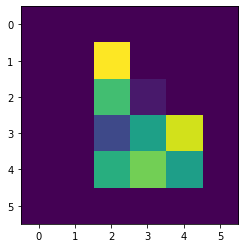

-1.0
Prediction: [0]


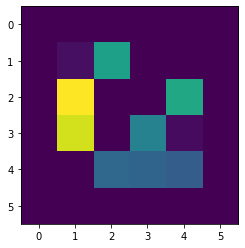

1.0
Prediction: [1]


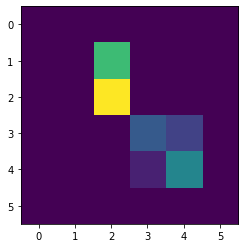

1.0
Prediction: [0]


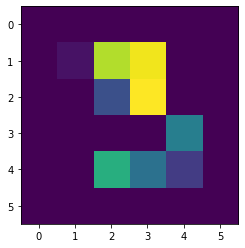

1.0
Prediction: [0]


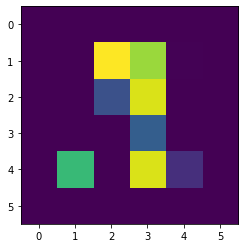

-1.0
Prediction: [0]


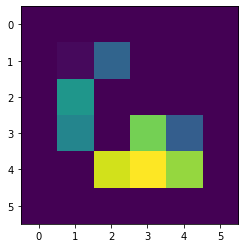

1.0
Prediction: [0]


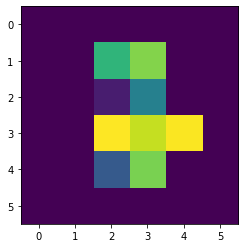

-1.0
Prediction: [0]


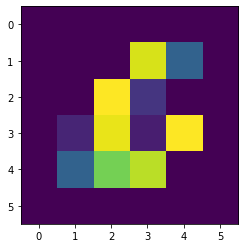

1.0
Prediction: [0]


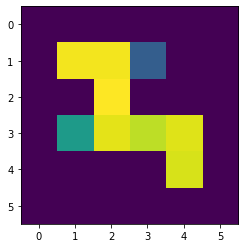

1.0
Prediction: [1]


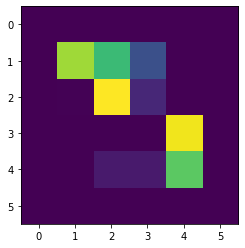

-1.0
Prediction: [0]


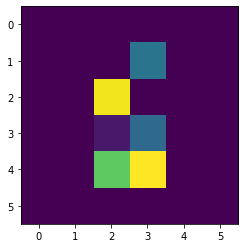

1.0
Prediction: [0]


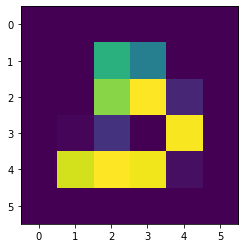

1.0
Prediction: [0]


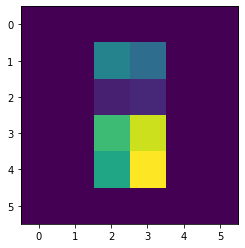

-1.0
Prediction: [0]


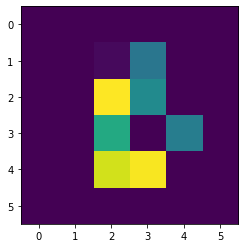

-1.0
Prediction: [0]


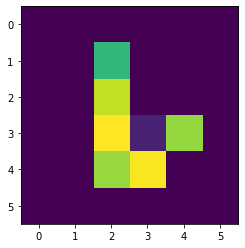

-1.0
Prediction: [0]


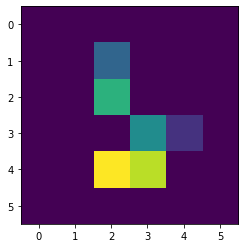

1.0
Prediction: [1]


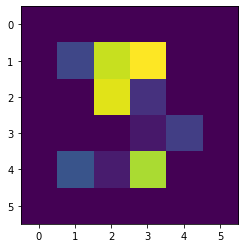

1.0
Prediction: [0]


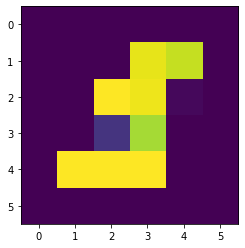

-1.0
Prediction: [0]


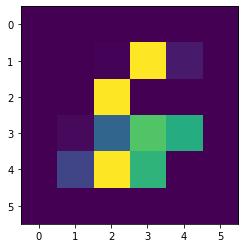

1.0
Prediction: [1]


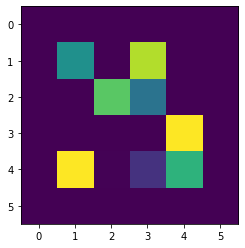

-1.0
Prediction: [0]


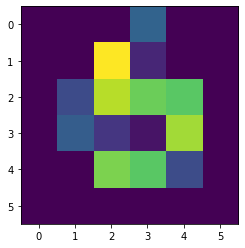

1.0
Prediction: [1]


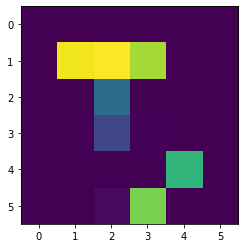

-1.0
Prediction: [0]


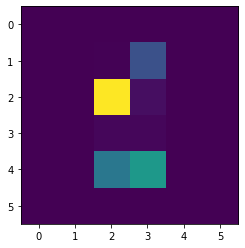

-1.0
Prediction: [0]


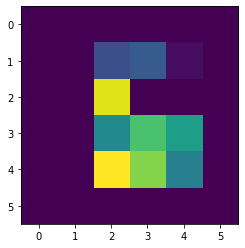

1.0
Prediction: [0]


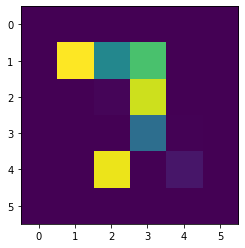

-1.0
Prediction: [0]


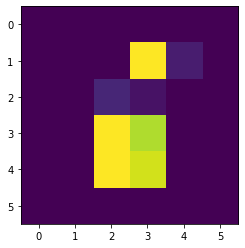

1.0
Prediction: [1]


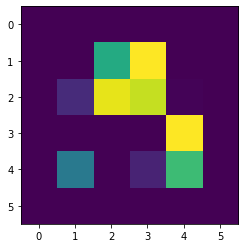

-1.0
Prediction: [0]


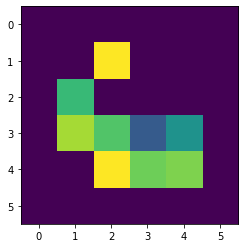

-1.0
Prediction: [0]


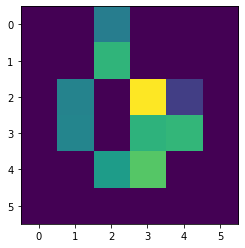

-1.0
Prediction: [1]


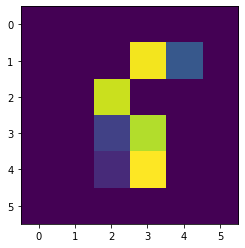

-1.0
Prediction: [0]


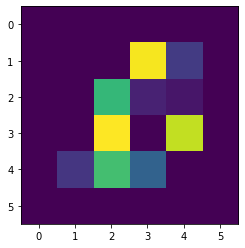

1.0
Prediction: [0]


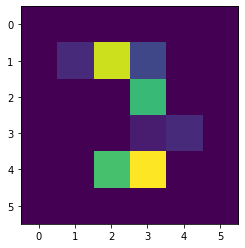

1.0
Prediction: [1]


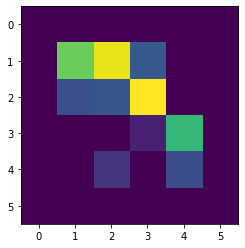

1.0
Prediction: [0]


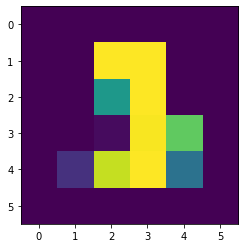

1.0
Prediction: [1]


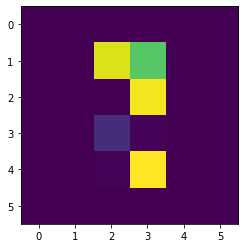

1.0
Prediction: [1]


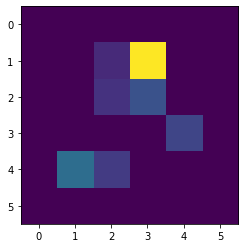

1.0
Prediction: [1]


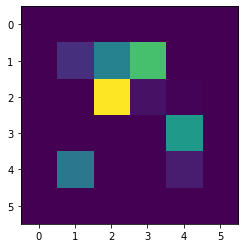

-1.0
Prediction: [0]


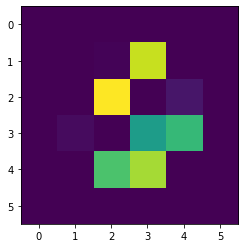

1.0
Prediction: [1]


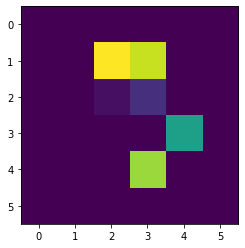

-1.0
Prediction: [0]


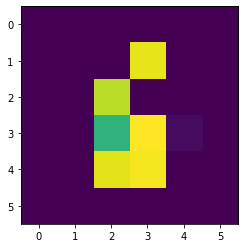

-1.0
Prediction: [0]


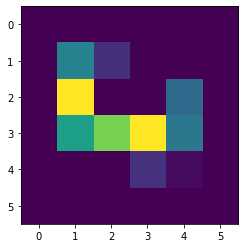

-1.0
Prediction: [0]


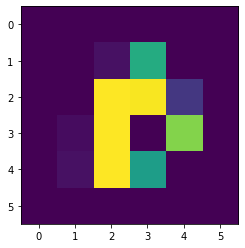

1.0
Prediction: [0]


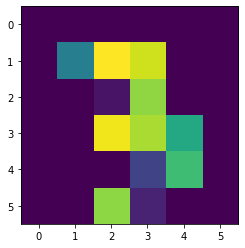

1.0
Prediction: [1]


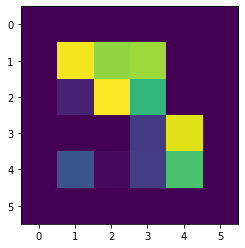

-1.0
Prediction: [0]


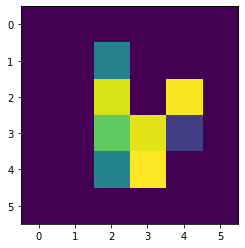

-1.0
Prediction: [0]


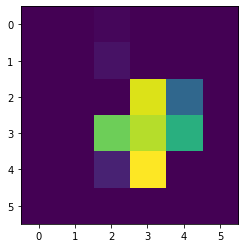

-1.0
Prediction: [0]


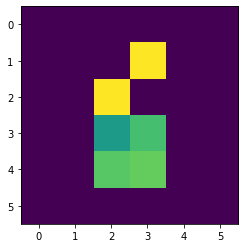

-1.0
Prediction: [0]


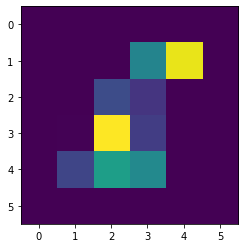

1.0
Prediction: [0]


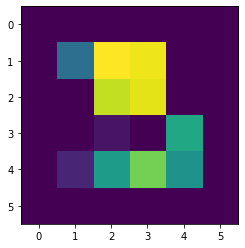

1.0
Prediction: [0]


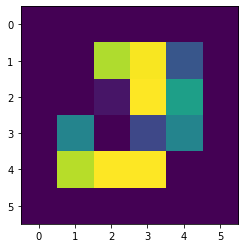

1.0
Prediction: [0]


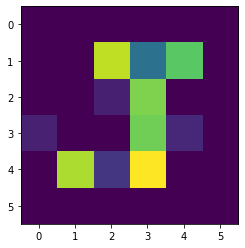

-1.0
Prediction: [0]


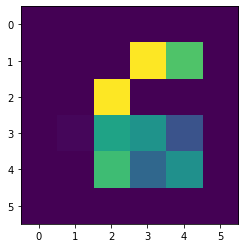

1.0
Prediction: [1]


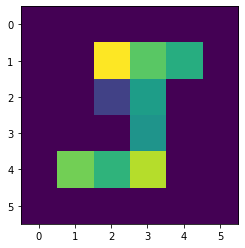

-1.0
Prediction: [0]


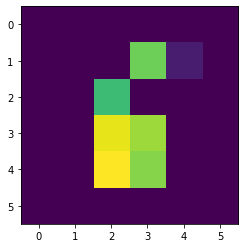

1.0
Prediction: [1]


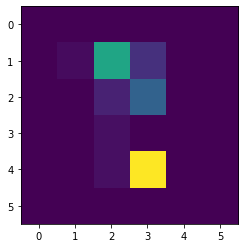

-1.0
Prediction: [0]


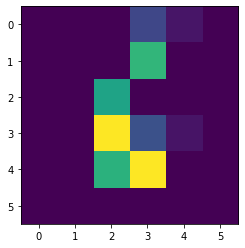

1.0
Prediction: [0]


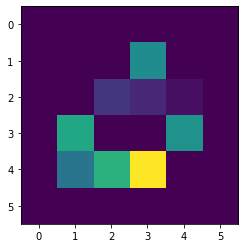

1.0
Prediction: [1]


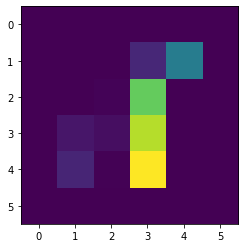

1.0
Prediction: [1]


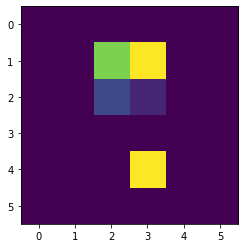

1.0
Prediction: [0]


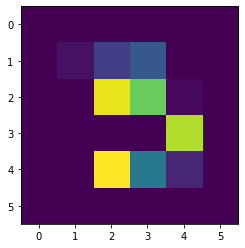

-1.0
Prediction: [0]


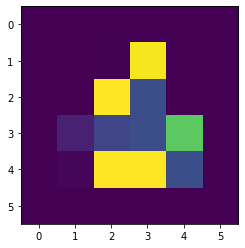

1.0
Prediction: [1]


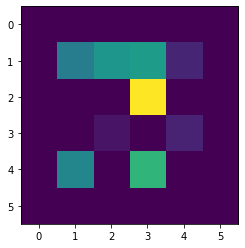

1.0
Prediction: [0]


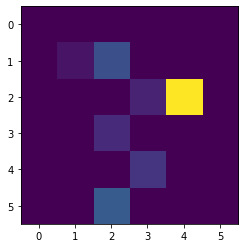

1.0
Prediction: [1]


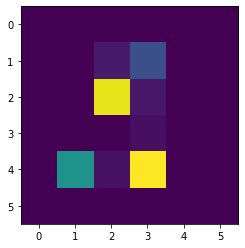

1.0
Prediction: [1]


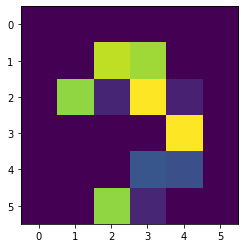

1.0
Prediction: [1]


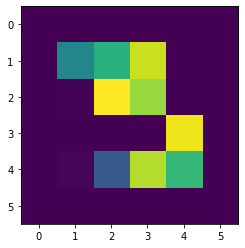

1.0
Prediction: [1]


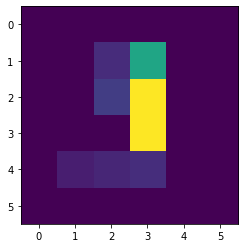

-1.0
Prediction: [0]


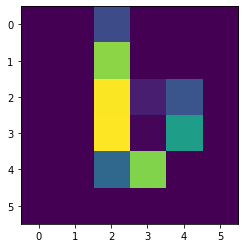

-1.0
Prediction: [0]


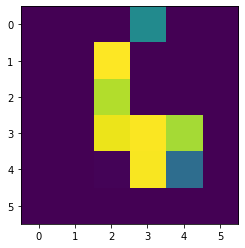

-1.0
Prediction: [0]


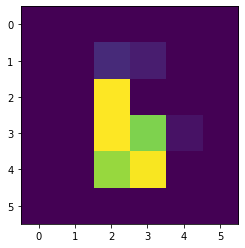

1.0
Prediction: [1]


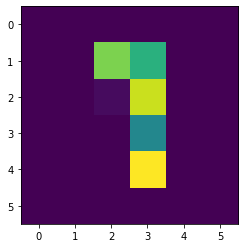

1.0
Prediction: [1]


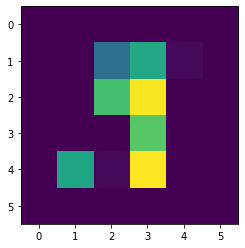

-1.0
Prediction: [0]


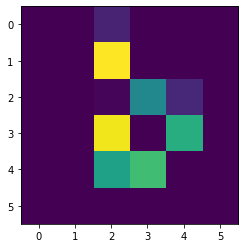

1.0
Prediction: [1]


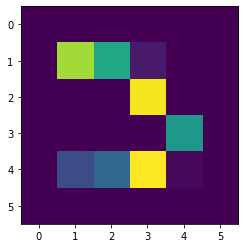

-1.0
Prediction: [0]


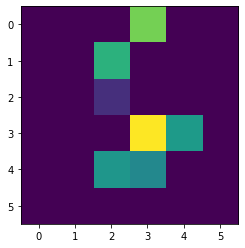

-1.0
Prediction: [0]


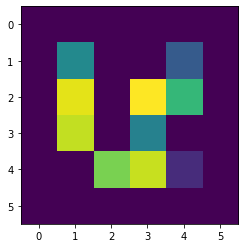

1.0
Prediction: [1]


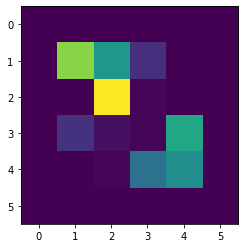

1.0
Prediction: [0]


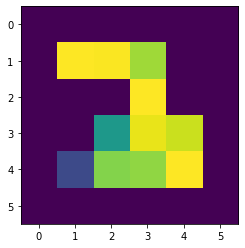

-1.0
Prediction: [0]


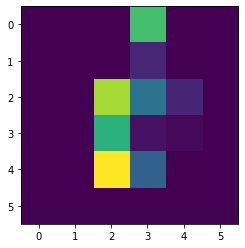

-1.0
Prediction: [0]


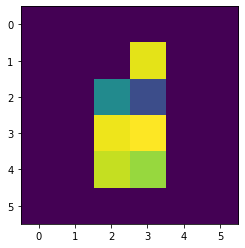

-1.0
Prediction: [0]


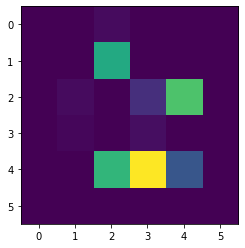

1.0
Prediction: [1]


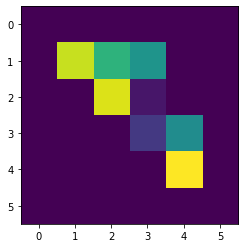

1.0
Prediction: [1]


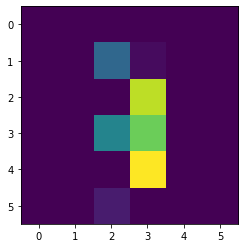

1.0
Prediction: [0]


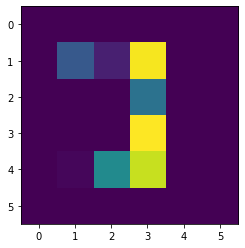

-1.0
Prediction: [0]


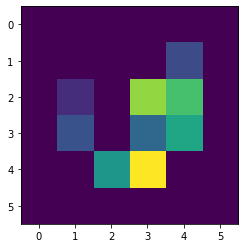

-1.0
Prediction: [0]


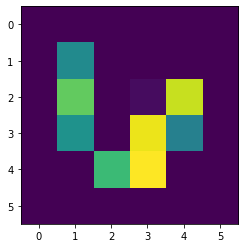

1.0
Prediction: [0]


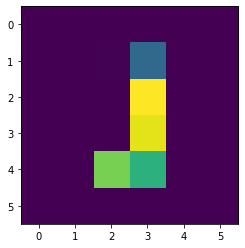

-1.0
Prediction: [1]


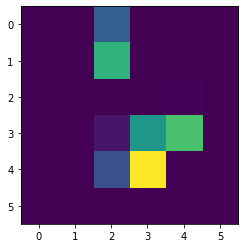

-1.0
Prediction: [0]


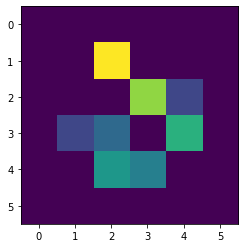

-1.0
Prediction: [1]


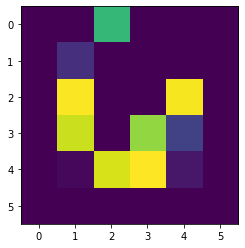

-1.0
Prediction: [0]


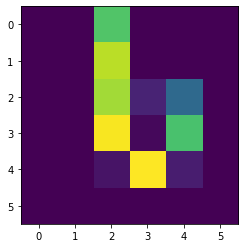

1.0
Prediction: [0]


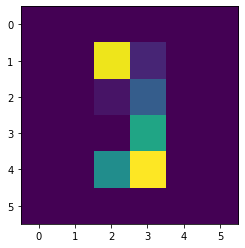

-1.0
Prediction: [0]


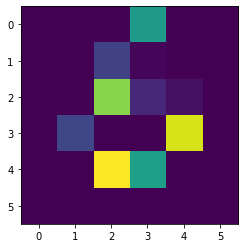

-1.0
Prediction: [0]


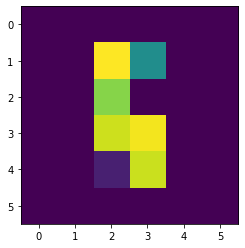

1.0
Prediction: [1]


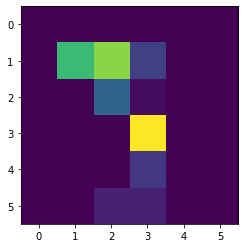

1.0
Prediction: [0]


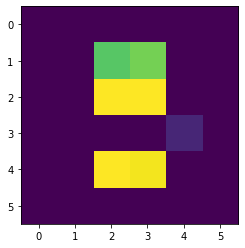

-1.0
Prediction: [1]


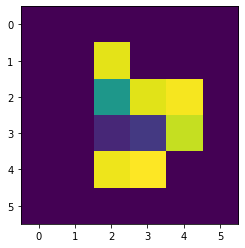

1.0
Prediction: [0]


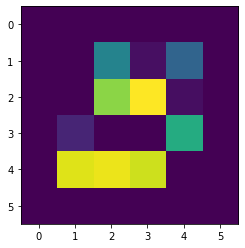

1.0
Prediction: [1]


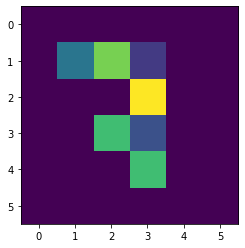

-1.0
Prediction: [0]


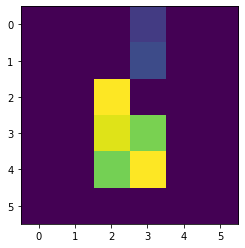

1.0
Prediction: [1]


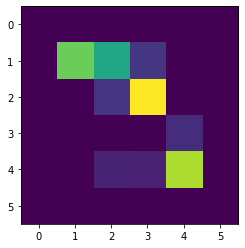

1.0
Prediction: [1]


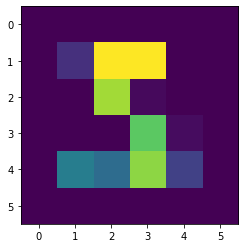

1.0
Prediction: [1]


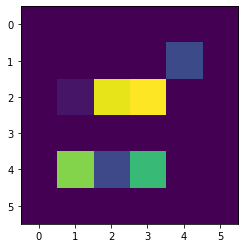

1.0
Prediction: [1]


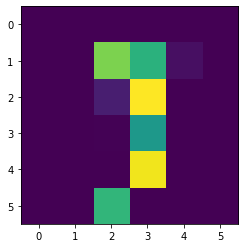

-1.0
Prediction: [0]


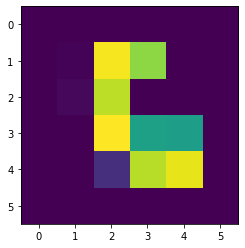

1.0
Prediction: [1]


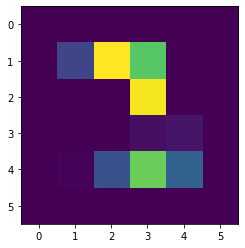

1.0
Prediction: [0]


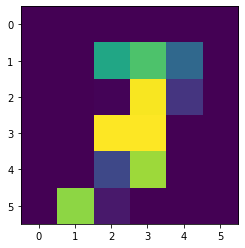

-1.0
Prediction: [1]


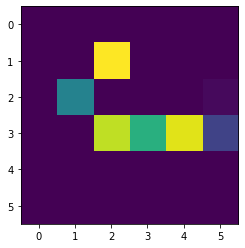

1.0
Prediction: [0]


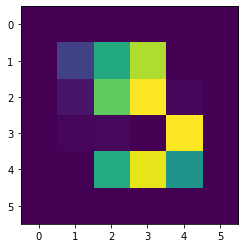

-1.0
Prediction: [1]


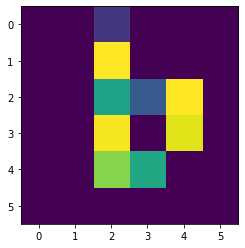

-1.0
Prediction: [0]


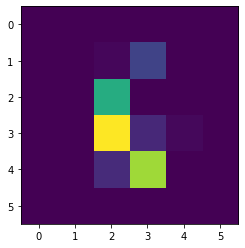

-1.0
Prediction: [0]


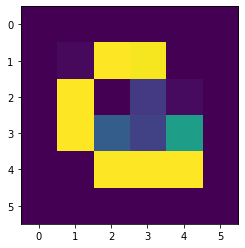

-1.0
Prediction: [0]


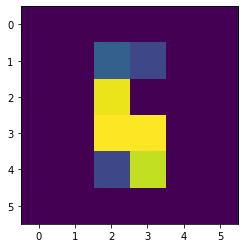

1.0
Prediction: [1]


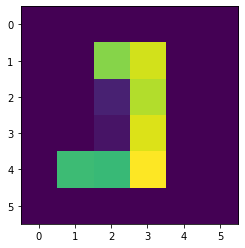

1.0
Prediction: [1]


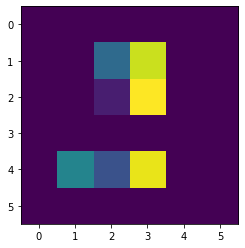

-1.0
Prediction: [0]


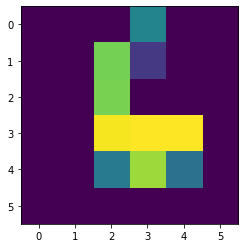

-1.0
Prediction: [0]


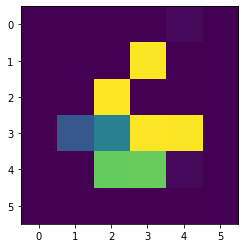

-1.0
Prediction: [0]


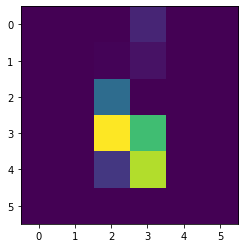

1.0
Prediction: [1]


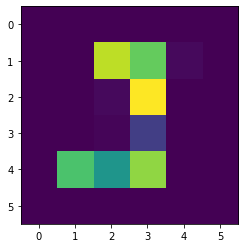

1.0
Prediction: [0]


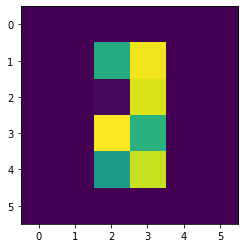

-1.0
Prediction: [0]


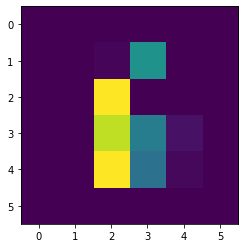

1.0
Prediction: [0]


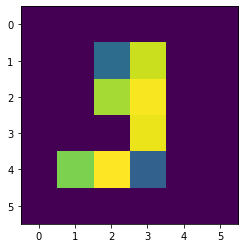

-1.0
Prediction: [0]


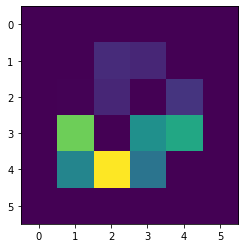

-1.0
Prediction: [0]


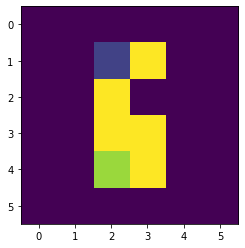

-1.0
Prediction: [0]


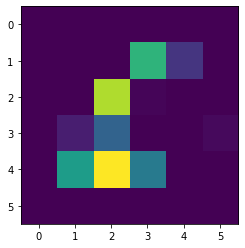

1.0
Prediction: [1]


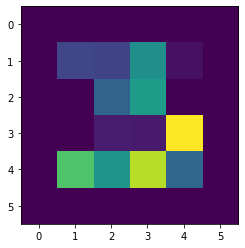

-1.0
Prediction: [0]


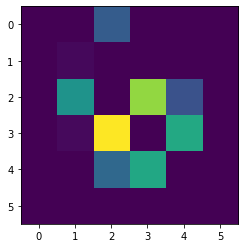

-1.0
Prediction: [0]


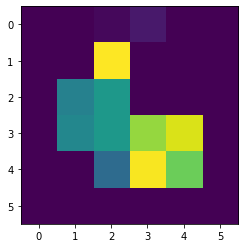

1.0
Prediction: [1]


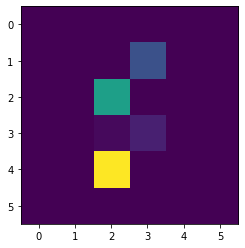

1.0
Prediction: [0]


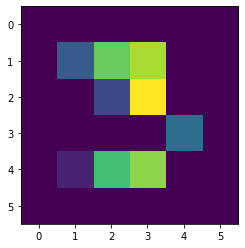

1.0
Prediction: [1]


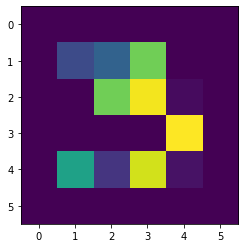

1.0
Prediction: [1]


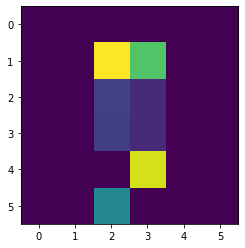

-1.0
Prediction: [0]


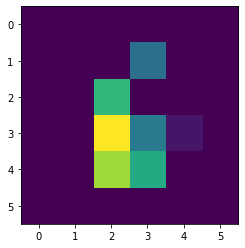

1.0
Prediction: [0]


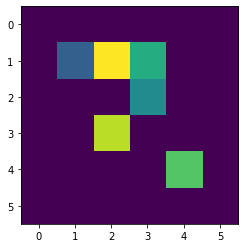

1.0
Prediction: [1]


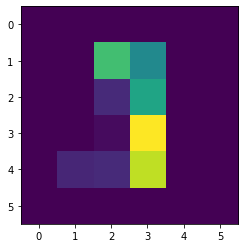

-1.0
Prediction: [0]


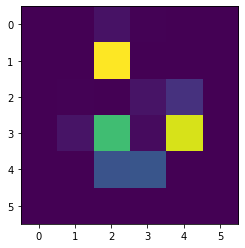

-1.0
Prediction: [0]


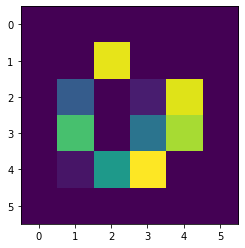

1.0
Prediction: [1]


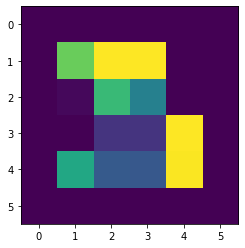

-1.0
Prediction: [0]


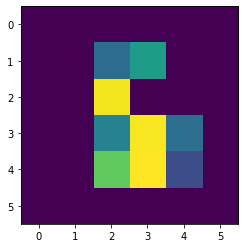

-1.0
Prediction: [1]


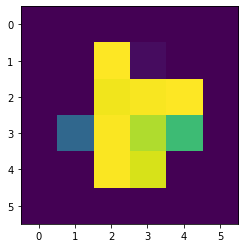

-1.0
Prediction: [0]


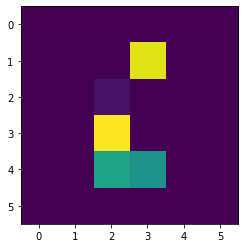

-1.0
Prediction: [0]


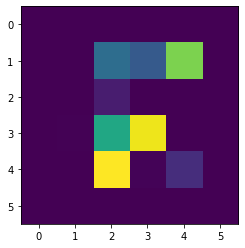

1.0
Prediction: [1]


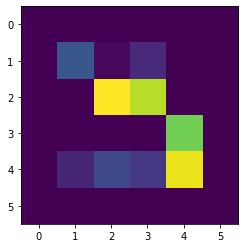

-1.0
Prediction: [0]


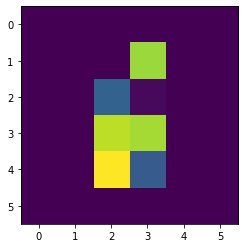

1.0
Prediction: [1]


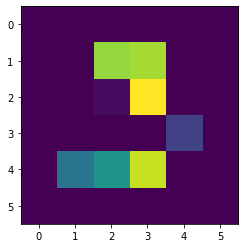

1.0
Prediction: [1]


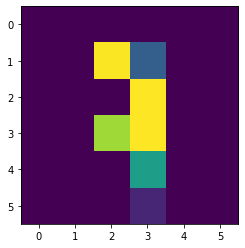

1.0
Prediction: [1]


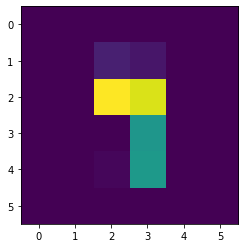

1.0
Prediction: [1]


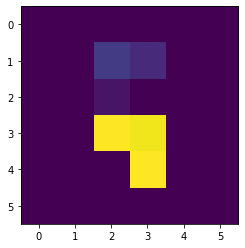

1.0
Prediction: [1]


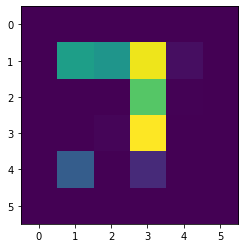

-1.0
Prediction: [0]


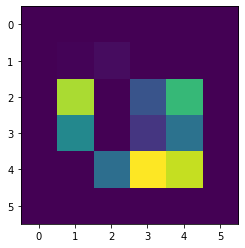

1.0
Prediction: [1]


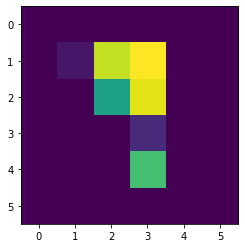

-1.0
Prediction: [0]


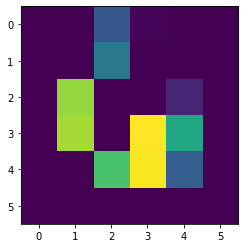

1.0
Prediction: [1]


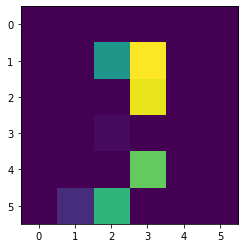

1.0
Prediction: [0]


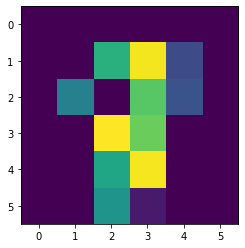

-1.0
Prediction: [0]


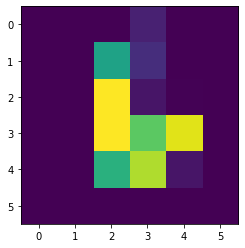

-1.0
Prediction: [0]


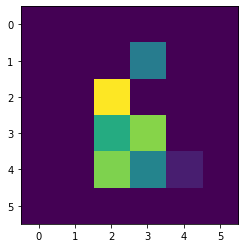

1.0
Prediction: [1]


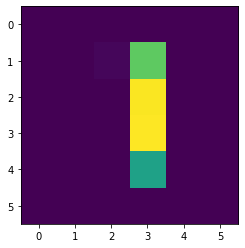

-1.0
Prediction: [0]


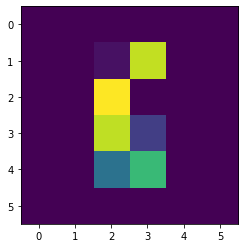

1.0
Prediction: [1]


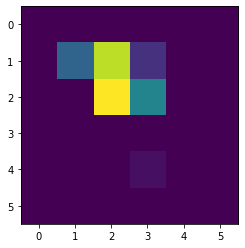

1.0
Prediction: [1]


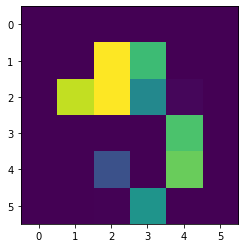

-1.0
Prediction: [0]


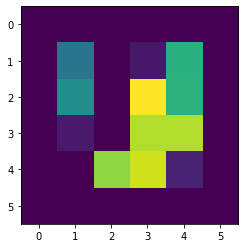

1.0
Prediction: [1]


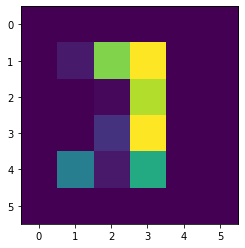

-1.0
Prediction: [1]


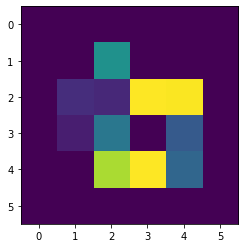

-1.0
Prediction: [0]


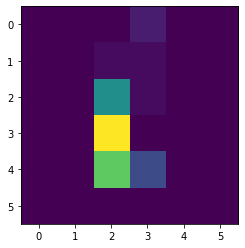

1.0
Prediction: [0]


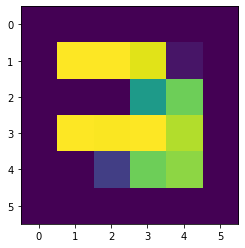

1.0
Prediction: [1]


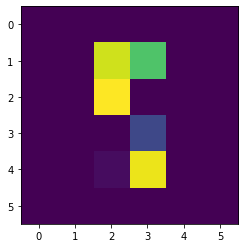

-1.0
Prediction: [0]


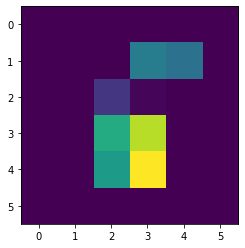

1.0
Prediction: [0]


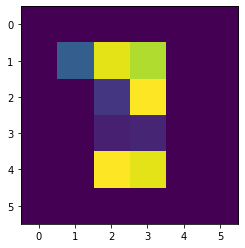

-1.0
Prediction: [0]


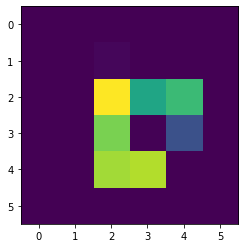

1.0
Prediction: [1]


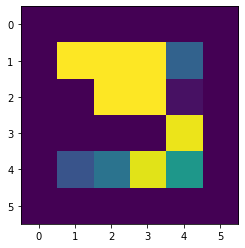

1.0
Prediction: [0]


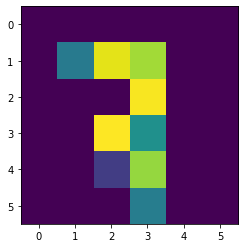

-1.0
Prediction: [1]


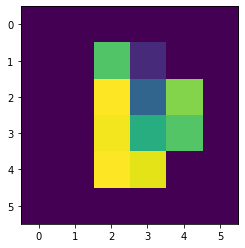

-1.0
Prediction: [0]


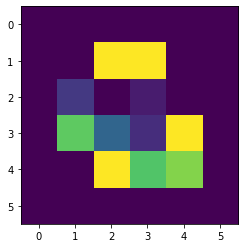

-1.0
Prediction: [0]


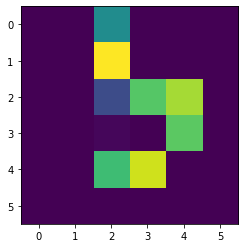

1.0
Prediction: [1]


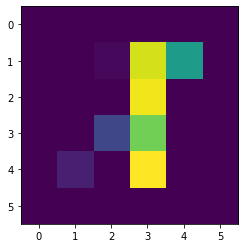

1.0
Prediction: [0]


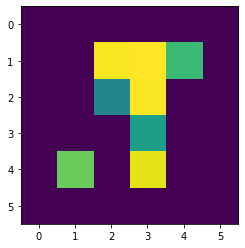

-1.0
Prediction: [0]


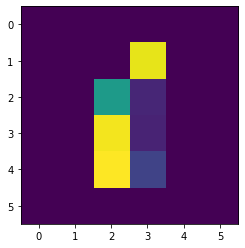

-1.0
Prediction: [0]


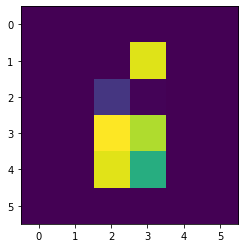

1.0
Prediction: [1]


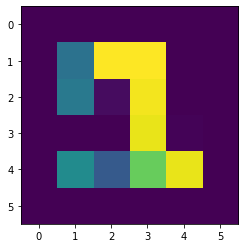

1.0
Prediction: [1]


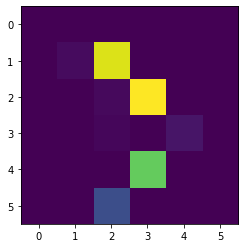

-1.0
Prediction: [0]


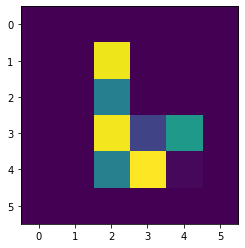

-1.0
Prediction: [0]


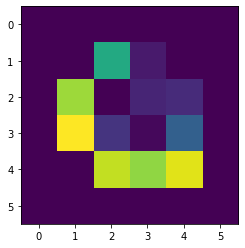

1.0
Prediction: [1]


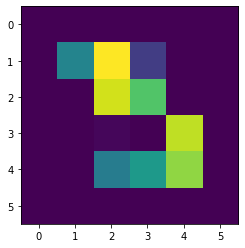

-1.0
Prediction: [1]


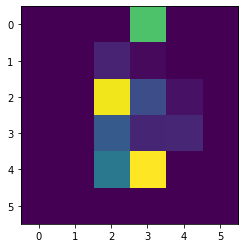

1.0
Prediction: [1]


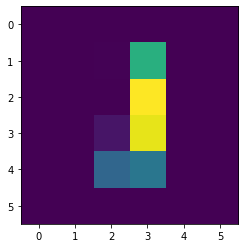

-1.0
Prediction: [0]


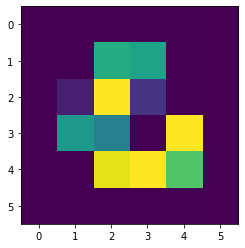

1.0
Prediction: [0]


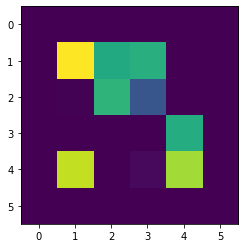

-1.0
Prediction: [0]


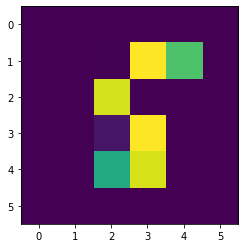

1.0
Prediction: [1]


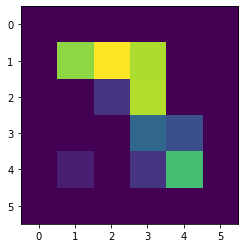

-1.0
Prediction: [1]


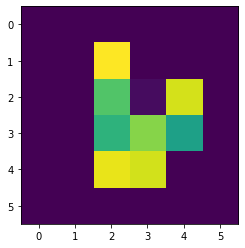

1.0
Prediction: [0]


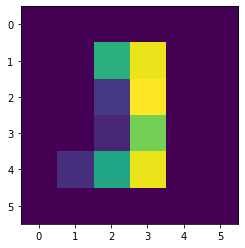

1.0
Prediction: [1]


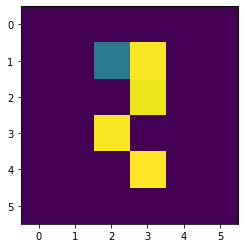

1.0
Prediction: [0]


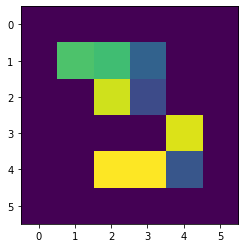

1.0
Prediction: [1]


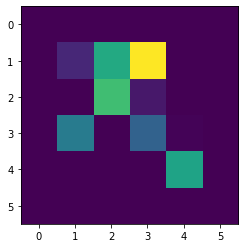

-1.0
Prediction: [0]


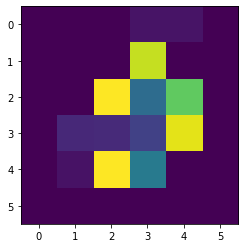

-1.0
Prediction: [0]


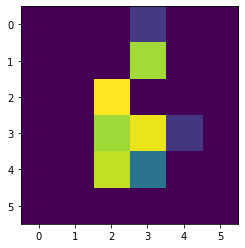

-1.0
Prediction: [0]


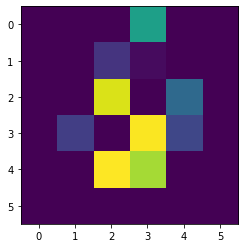

1.0
Prediction: [1]


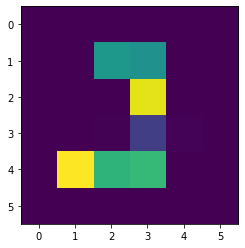

1.0
Prediction: [0]


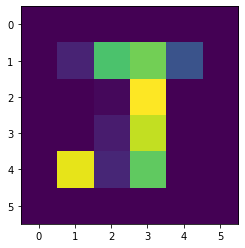

-1.0
Prediction: [0]


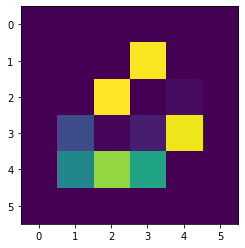

-1.0
Prediction: [0]


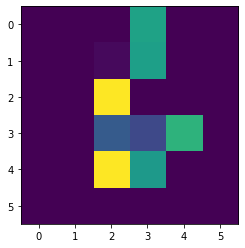

1.0
Prediction: [1]


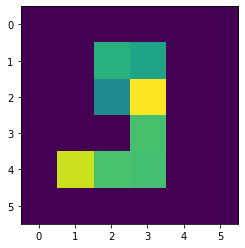

1.0
Prediction: [1]


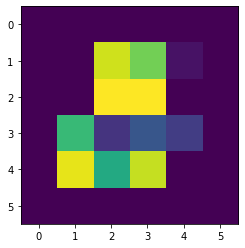

1.0
Prediction: [0]


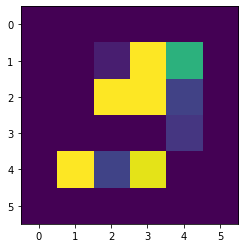

-1.0
Prediction: [1]


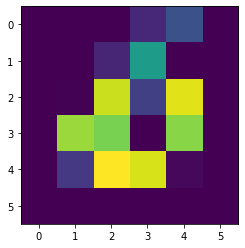

1.0
Prediction: [0]


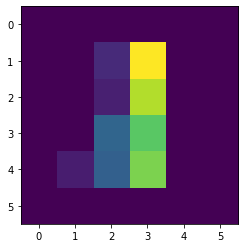

-1.0
Prediction: [0]


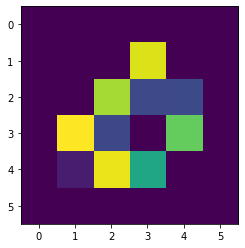

1.0
Prediction: [0]


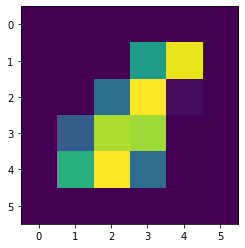

1.0
Prediction: [1]


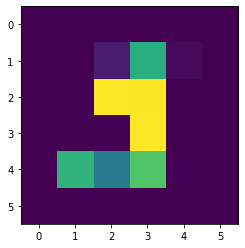

1.0
Prediction: [1]


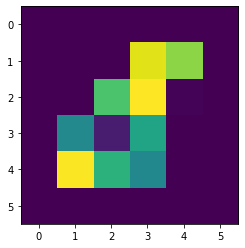

-1.0
Prediction: [0]


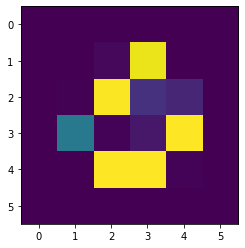

-1.0
Prediction: [1]


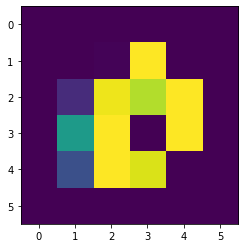

-1.0
Prediction: [0]


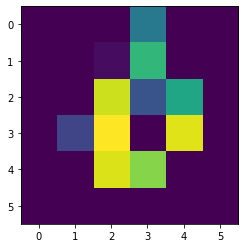

-1.0
Prediction: [0]


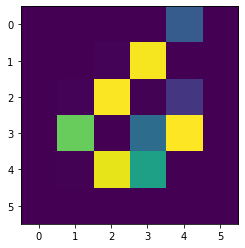

-1.0
Prediction: [0]


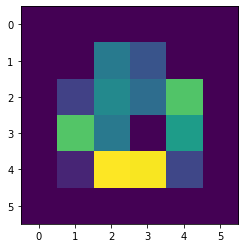

-1.0
Prediction: [0]


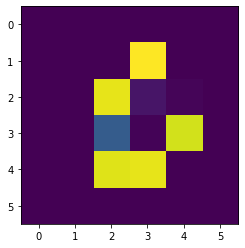

-1.0
Prediction: [0]


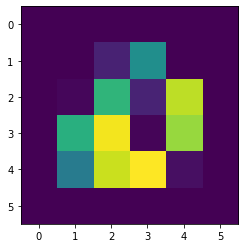

1.0
Prediction: [0]


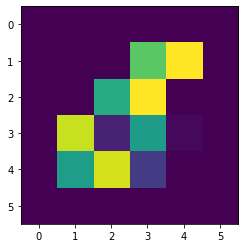

1.0
Prediction: [0]


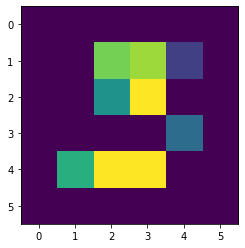

-1.0
Prediction: [1]


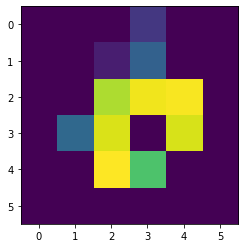

1.0
Prediction: [0]


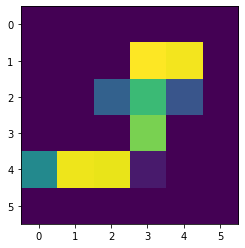

1.0
Prediction: [1]


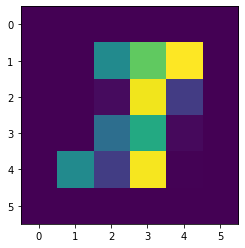

-1.0
Prediction: [1]


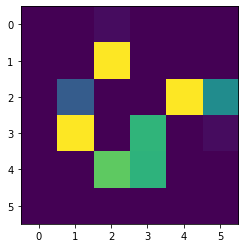

1.0
Prediction: [1]


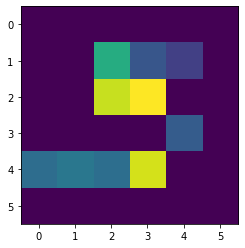

-1.0
Prediction: [0]


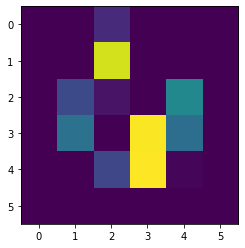

1.0
Prediction: [0]


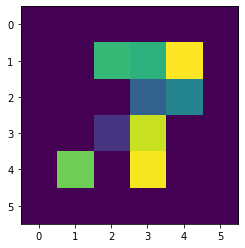

-1.0
Prediction: [1]


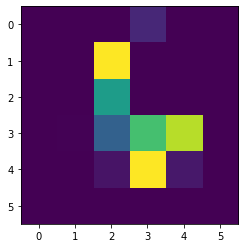

1.0
Prediction: [1]


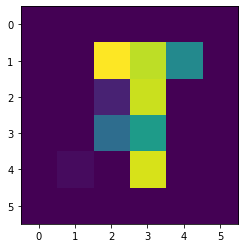

1.0
Prediction: [1]


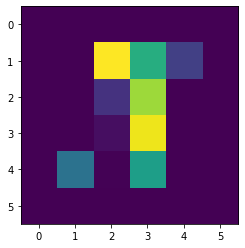

-1.0
Prediction: [1]


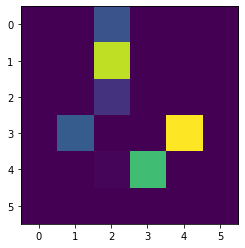

1.0
Prediction: [1]


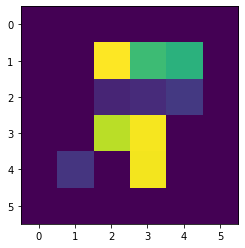

-1.0
Prediction: [1]


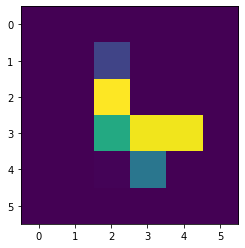

1.0
Prediction: [1]


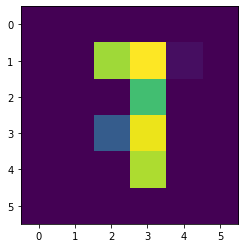

1.0
Prediction: [1]


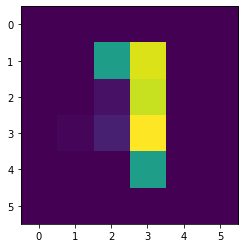

-1.0
Prediction: [1]


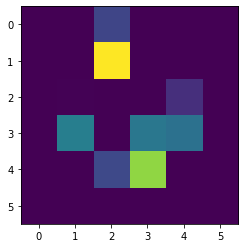

-1.0
Prediction: [0]


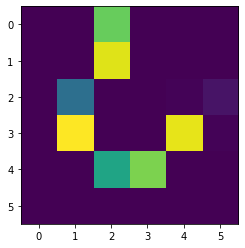

1.0
Prediction: [1]


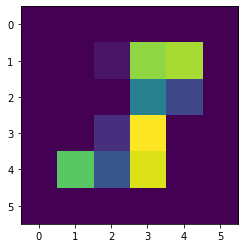

1.0
Prediction: [0]


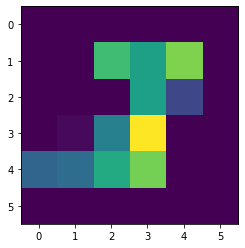

-1.0
Prediction: [1]


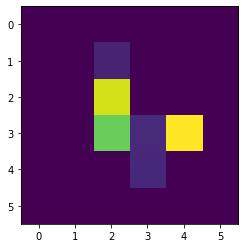

-1.0
Prediction: [0]


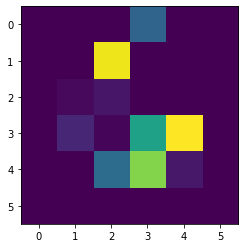

-1.0
Prediction: [1]


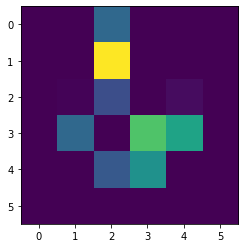

1.0
Prediction: [1]


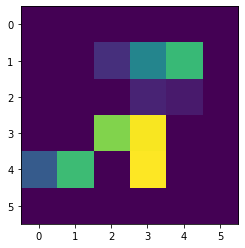

1.0
Prediction: [1]


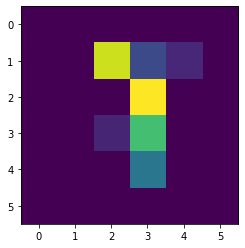

1.0
Prediction: [0]


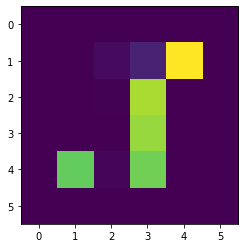

-1.0
Prediction: [0]


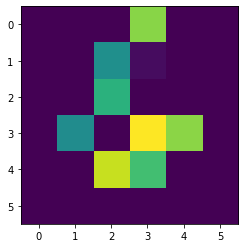

-1.0
Prediction: [1]


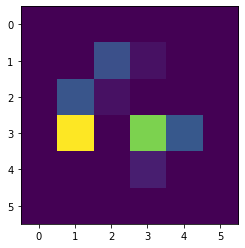

1.0
Prediction: [0]


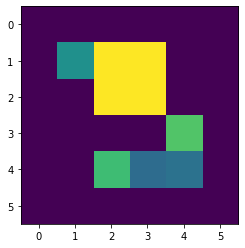

-1.0
Prediction: [0]


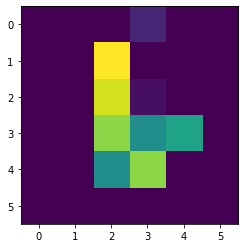

1.0
Prediction: [0]


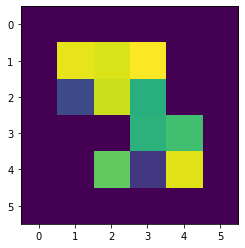

-1.0
Prediction: [0]


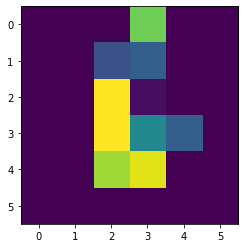

1.0
Prediction: [1]


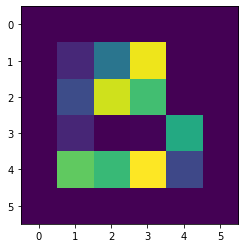

-1.0
Prediction: [0]


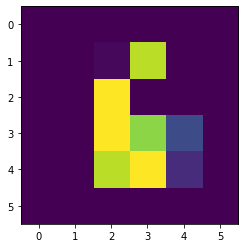

-1.0
Prediction: [0]


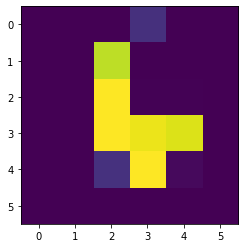

-1.0
Prediction: [0]


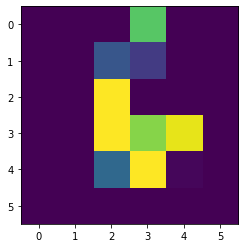

1.0
Prediction: [1]


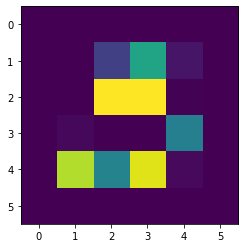

1.0
Prediction: [1]


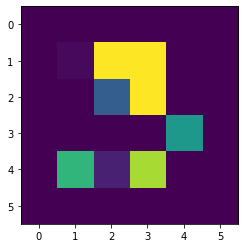

1.0
Prediction: [1]


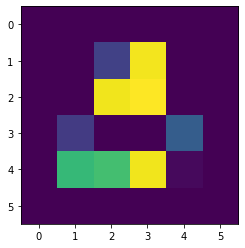

1.0
Prediction: [0]


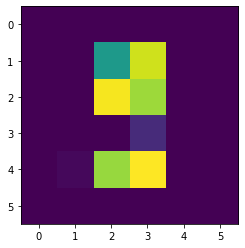

-1.0
Prediction: [0]


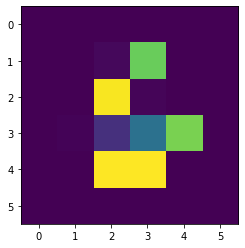

1.0
Prediction: [1]


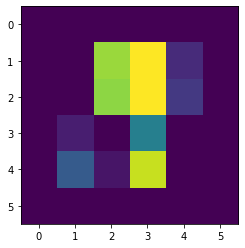

-1.0
Prediction: [0]


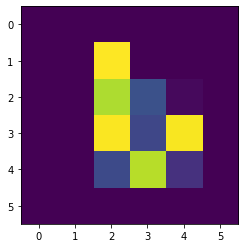

1.0
Prediction: [1]


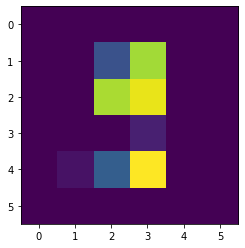

-1.0
Prediction: [0]


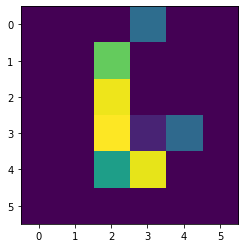

1.0
Prediction: [0]


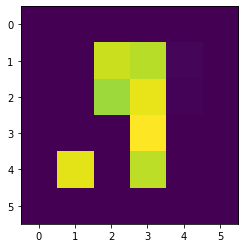

-1.0
Prediction: [0]


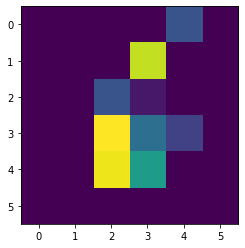

1.0
Prediction: [1]


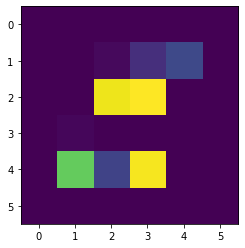

1.0
Prediction: [1]


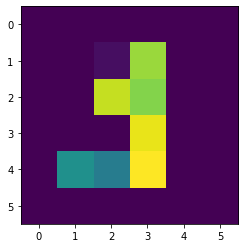

-1.0
Prediction: [0]


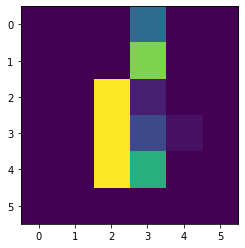

1.0
Prediction: [0]


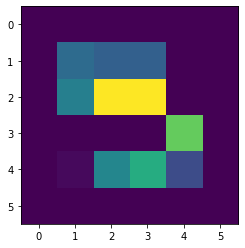

-1.0
Prediction: [0]


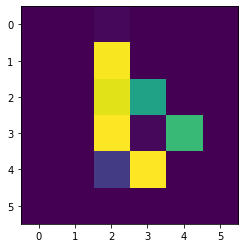

-1.0
Prediction: [0]


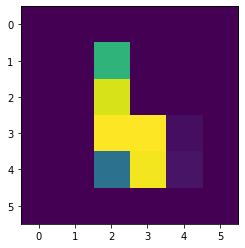

-1.0
Prediction: [0]


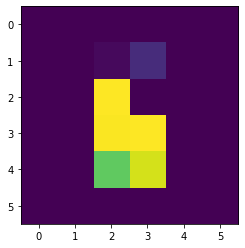

-1.0
Prediction: [0]


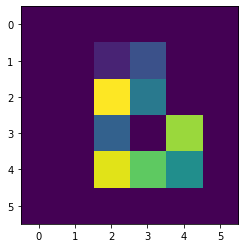

1.0
Prediction: [1]


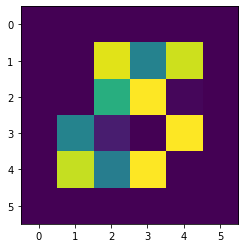

-1.0
Prediction: [0]


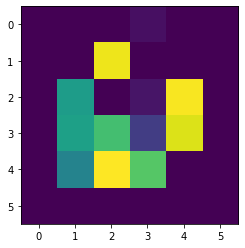

1.0
Prediction: [0]


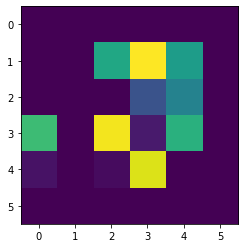

-1.0
Prediction: [1]


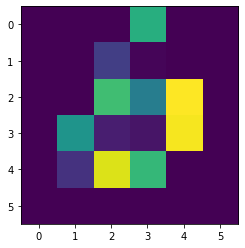

-1.0
Prediction: [0]


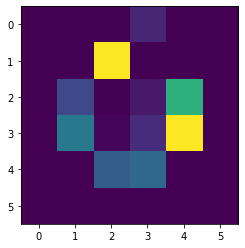

1.0
Prediction: [1]


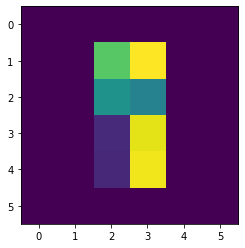

1.0
Prediction: [1]


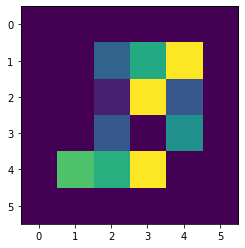

-1.0
Prediction: [1]


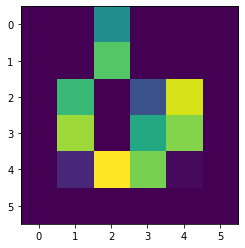

-1.0
Prediction: [1]


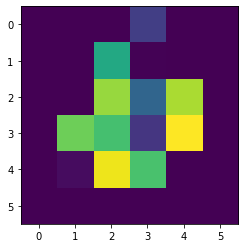

1.0
Prediction: [0]


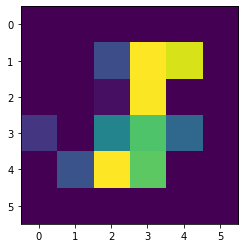

-1.0
Prediction: [1]


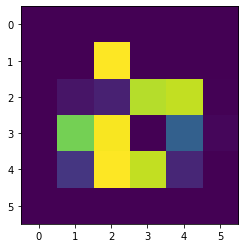

1.0
Prediction: [0]


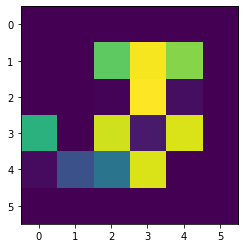

1.0
Prediction: [1]


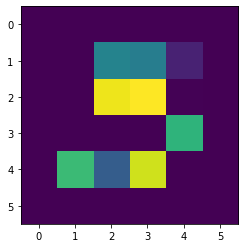

-1.0
Prediction: [0]


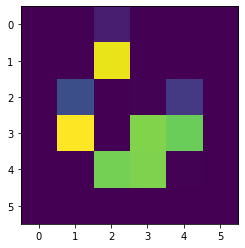

-1.0
Prediction: [0]


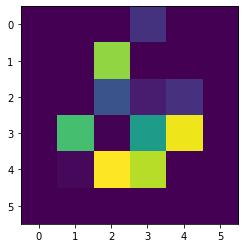

1.0
Prediction: [1]


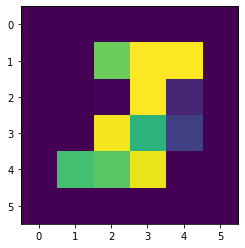

-1.0
Prediction: [0]


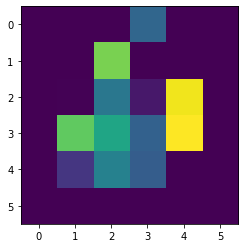

-1.0
Prediction: [1]


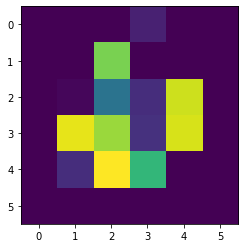

1.0
Prediction: [0]


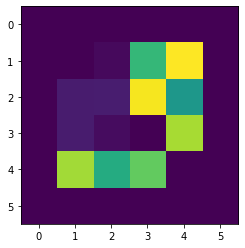

1.0
Prediction: [0]


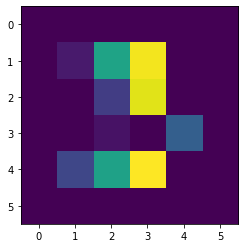

-1.0
Prediction: [0]


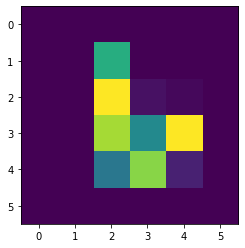

1.0
Prediction: [0]


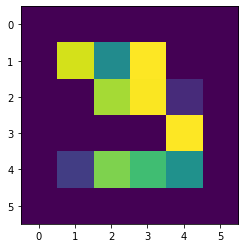

1.0
Prediction: [1]


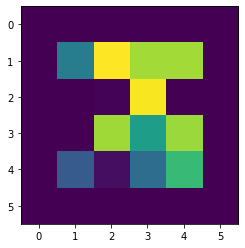

-1.0
Prediction: [1]


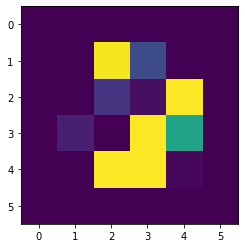

1.0
Prediction: [0]


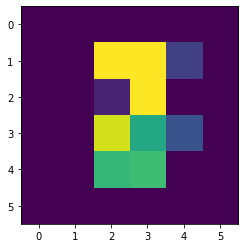

1.0
Prediction: [1]


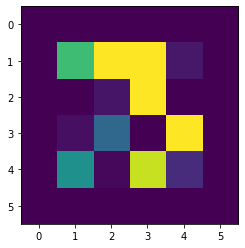

-1.0
Prediction: [1]


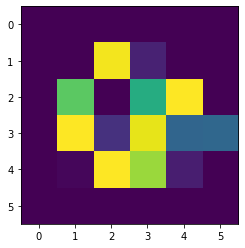

-1.0
Prediction: [1]


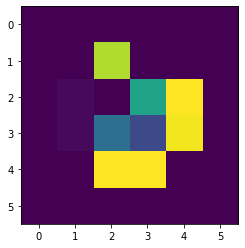

1.0
Prediction: [1]


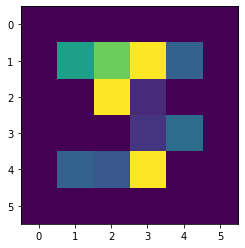

-1.0
Prediction: [1]


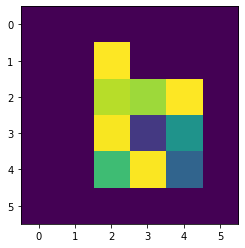

1.0
Prediction: [0]


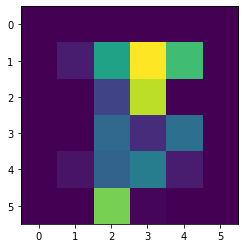

1.0
Prediction: [1]


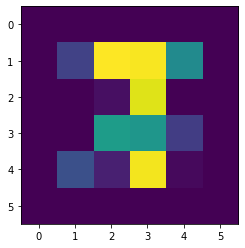

-1.0
Prediction: [0]


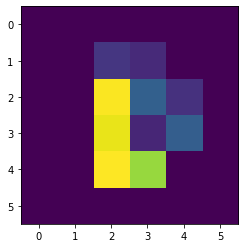

1.0
Prediction: [0]


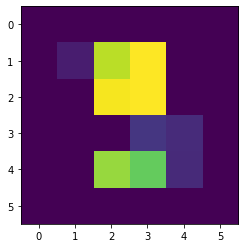

-1.0
Prediction: [1]


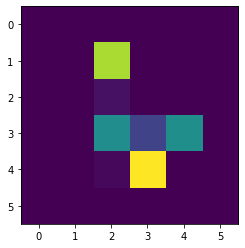

1.0
Prediction: [1]


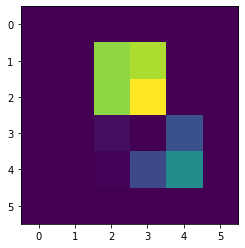

-1.0
Prediction: [0]


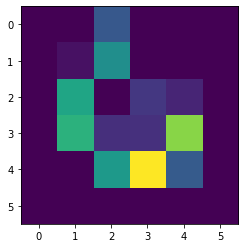

1.0
Prediction: [1]


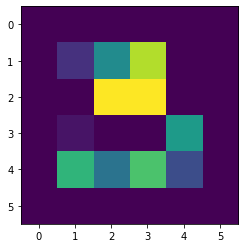

-1.0
Prediction: [0]


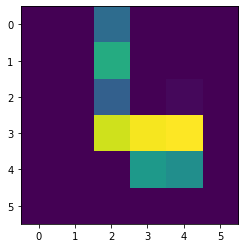

1.0
Prediction: [0]


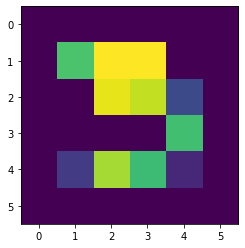

1.0
Prediction: [1]


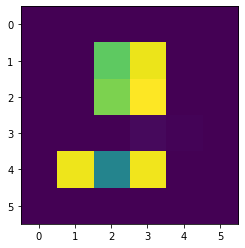

1.0
Prediction: [1]


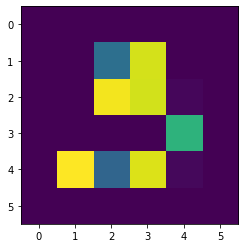

1.0
Prediction: [0]


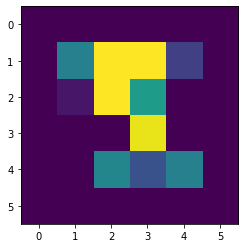

1.0
Prediction: [0]


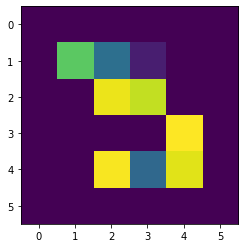

-1.0
Prediction: [0]


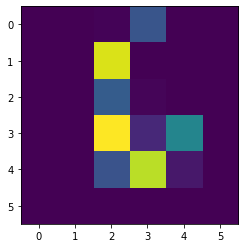

-1.0
Prediction: [0]


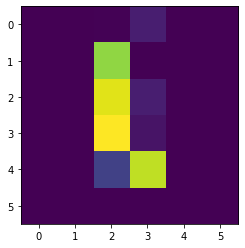

1.0
Prediction: [0]


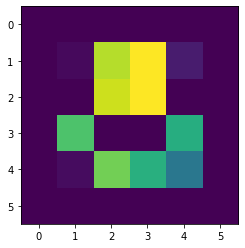

-1.0
Prediction: [0]


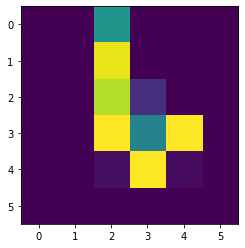

1.0
Prediction: [0]


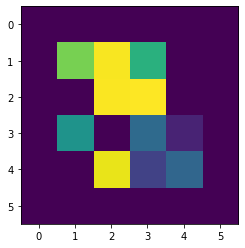

-1.0
Prediction: [1]


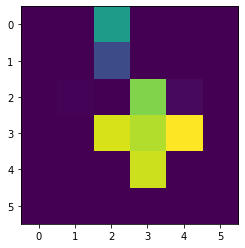

-1.0
Prediction: [0]


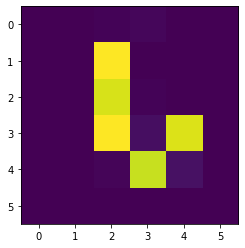

-1.0
Prediction: [1]


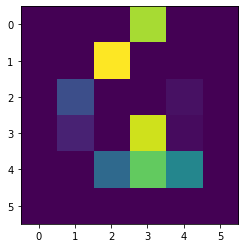

1.0
Prediction: [1]


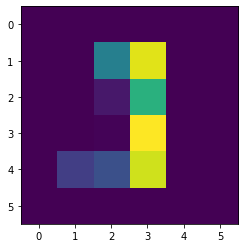

-1.0
Prediction: [1]


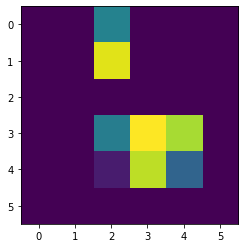

1.0
Prediction: [0]


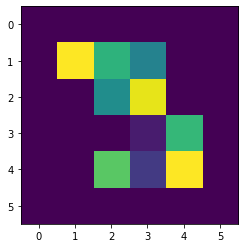

1.0
Prediction: [0]


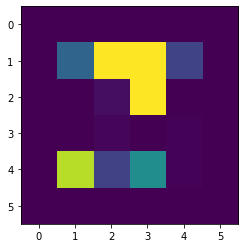

-1.0
Prediction: [1]


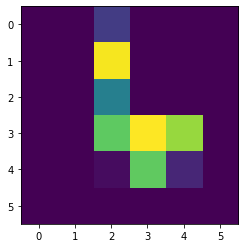

-1.0
Prediction: [0]


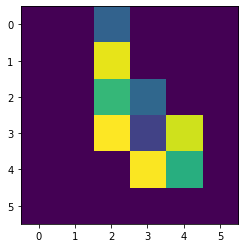

1.0
Prediction: [1]


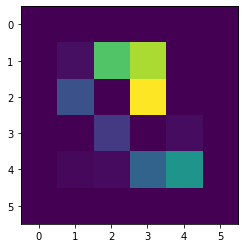

-1.0
Prediction: [0]


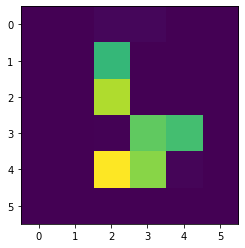

1.0
Prediction: [1]


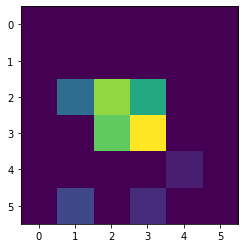

-1.0
Prediction: [0]


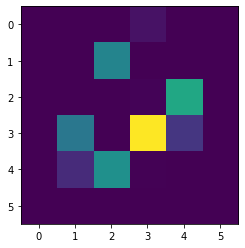

1.0
Prediction: [0]


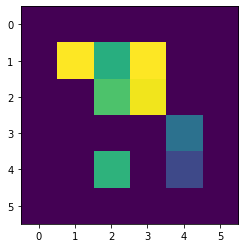

-1.0
Prediction: [0]


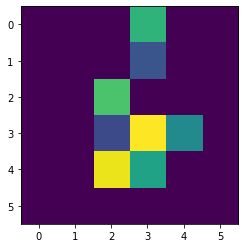

1.0
Prediction: [1]


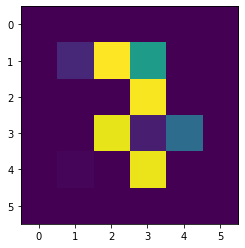

-1.0
Prediction: [0]


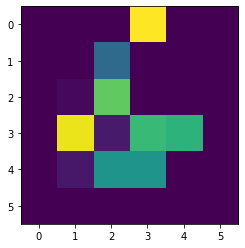

1.0
Prediction: [0]


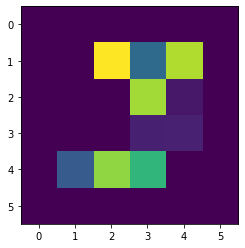

1.0
Prediction: [1]


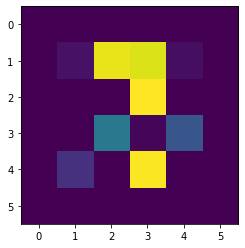

1.0
Prediction: [0]


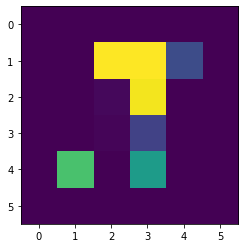

-1.0
Prediction: [0]


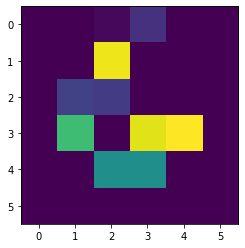

-1.0
Prediction: [0]


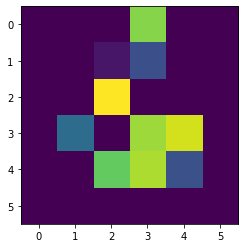

1.0
Prediction: [0]


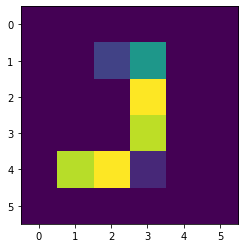

-1.0
Prediction: [0]


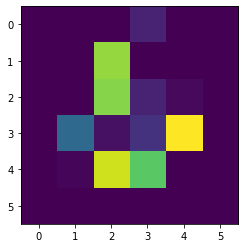

-1.0
Prediction: [0]


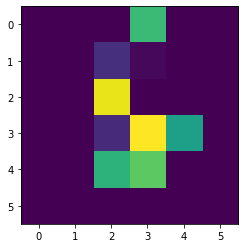

1.0
Prediction: [0]


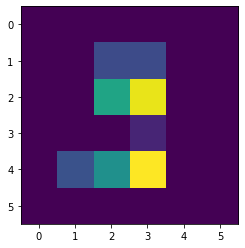

-1.0
Prediction: [0]


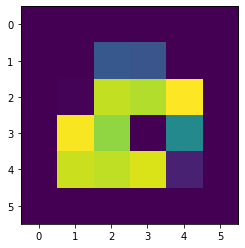

1.0
Prediction: [1]


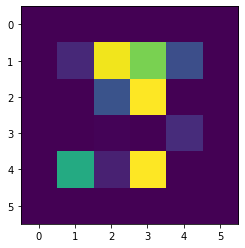

-1.0
Prediction: [0]


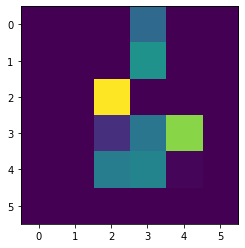

1.0
Prediction: [0]


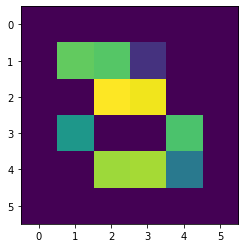

1.0
Prediction: [0]


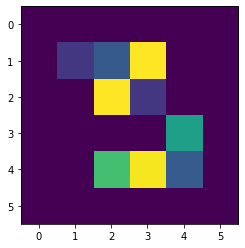

-1.0
Prediction: [0]


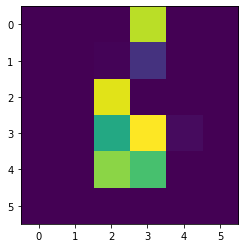

1.0
Prediction: [1]


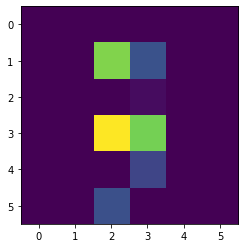

-1.0
Prediction: [0]


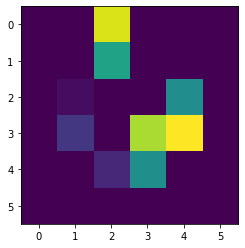

-1.0
Prediction: [0]


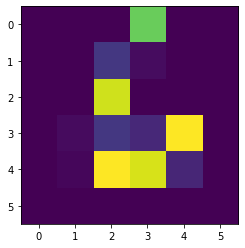

1.0
Prediction: [0]


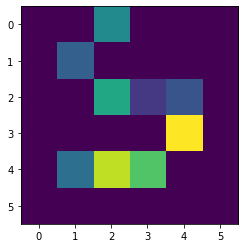

-1.0
Prediction: [0]


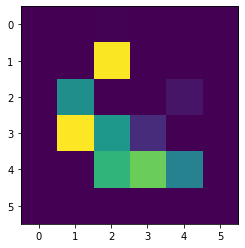

1.0
Prediction: [1]


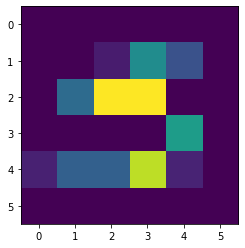

-1.0
Prediction: [0]


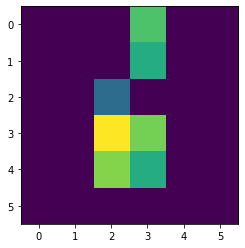

1.0
Prediction: [1]


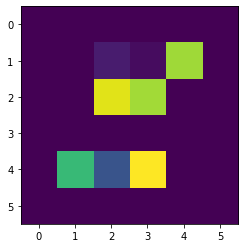

-1.0
Prediction: [0]


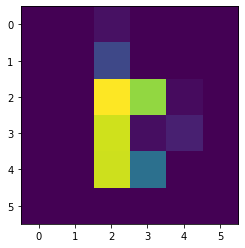

1.0
Prediction: [0]


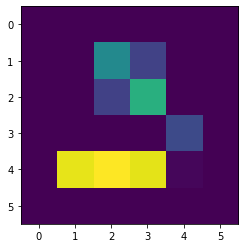

1.0
Prediction: [0]


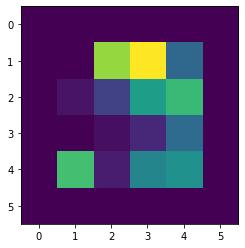

-1.0
Prediction: [0]


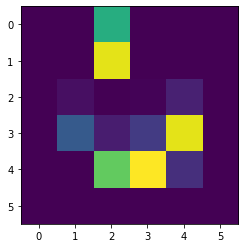

-1.0
Prediction: [0]


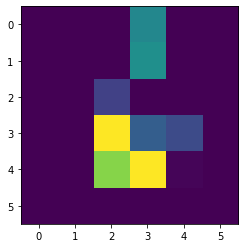

1.0
Prediction: [0]


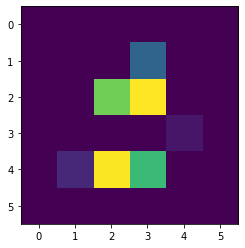

-1.0
Prediction: [0]


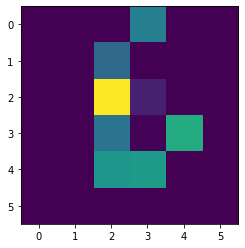

-1.0
Prediction: [0]


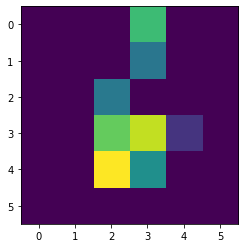

1.0
Prediction: [1]


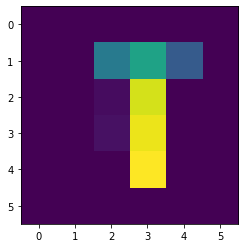

-1.0
Prediction: [0]


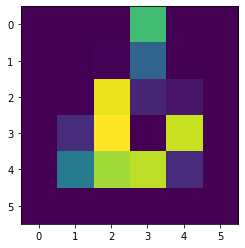

1.0
Prediction: [0]


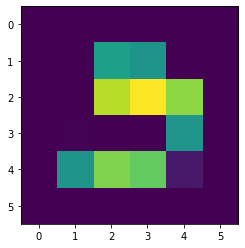

-1.0
Prediction: [1]


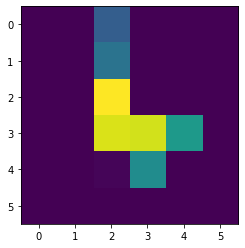

-1.0
Prediction: [0]


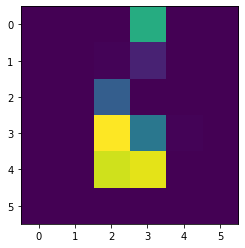

1.0
Prediction: [0]


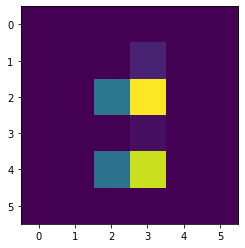

-1.0
Prediction: [0]


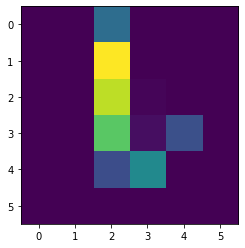

1.0
Prediction: [0]


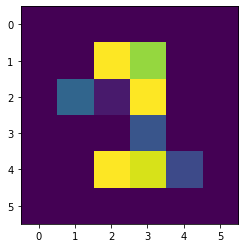

-1.0
Prediction: [0]


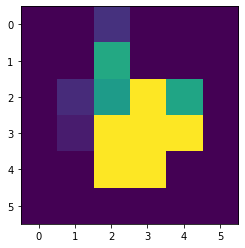

1.0
Prediction: [0]


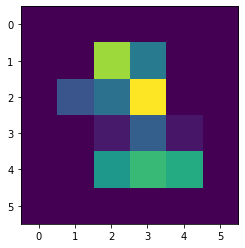

-1.0
Prediction: [0]


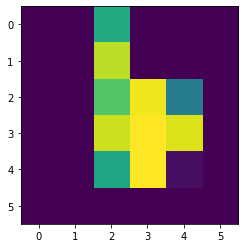

1.0
Prediction: [0]


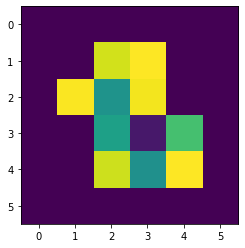

-1.0
Prediction: [0]


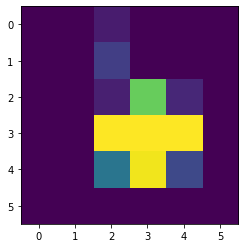

-1.0
Prediction: [0]


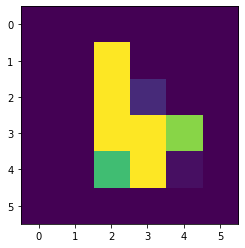

-1.0
Prediction: [0]


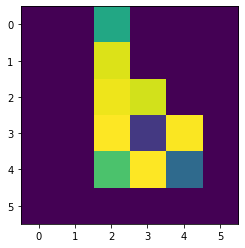

1.0
Prediction: [0]


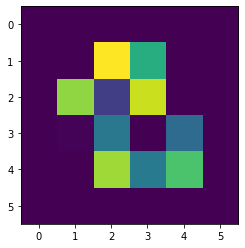

-1.0
Prediction: [0]


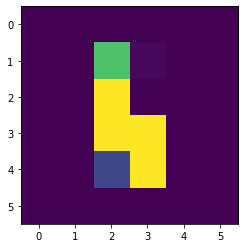

-1.0
Prediction: [0]


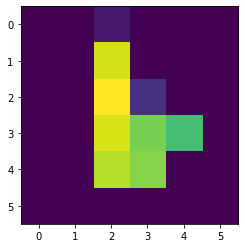

-1.0
Prediction: [0]


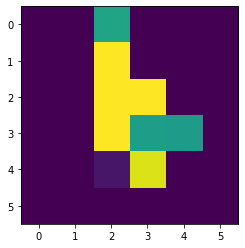

1.0
Prediction: [0]


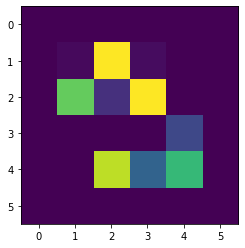

1.0
Prediction: [0]


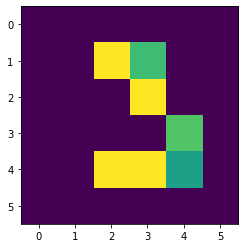

-1.0
Prediction: [0]


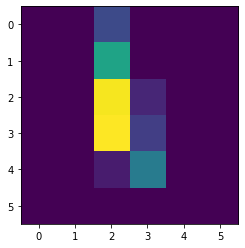

1.0
Prediction: [0]


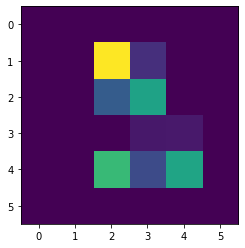

-1.0
Prediction: [1]


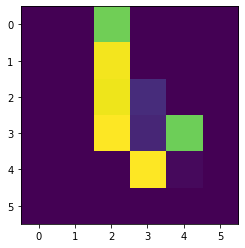

1.0
Prediction: [0]


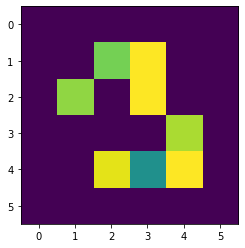

-1.0
Prediction: [0]


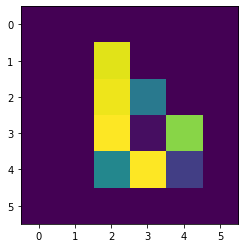

-1.0
Prediction: [0]


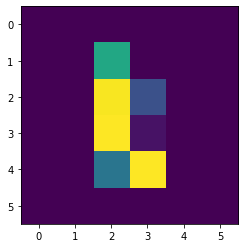

1.0
Prediction: [0]


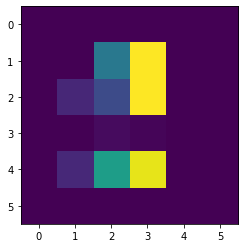

-1.0
Prediction: [1]


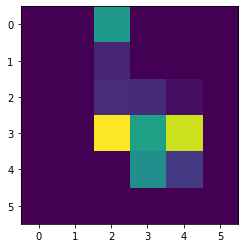

1.0
Prediction: [0]


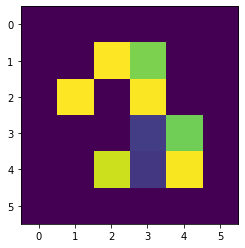

1.0
Prediction: [0]


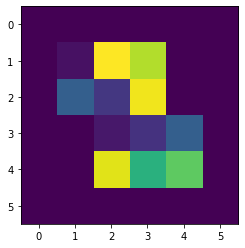

1.0
Prediction: [0]


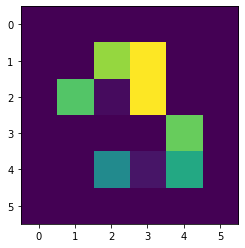

1.0
Prediction: [0]


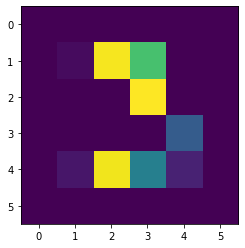

1.0
Prediction: [0]


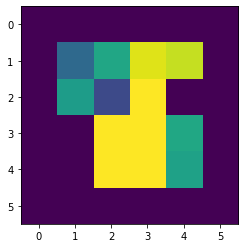

-1.0
Prediction: [0]


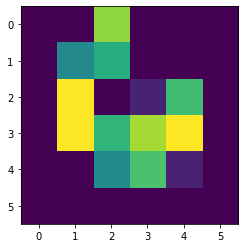

1.0
Prediction: [0]


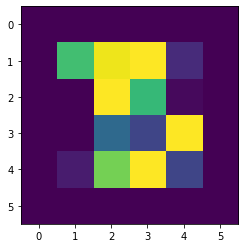

-1.0
Prediction: [0]


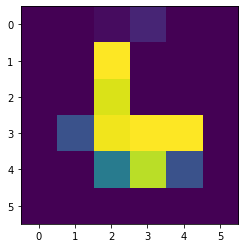

1.0
Prediction: [0]


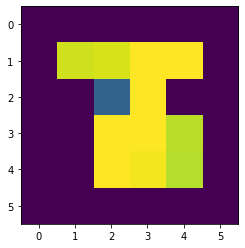

-1.0
Prediction: [0]


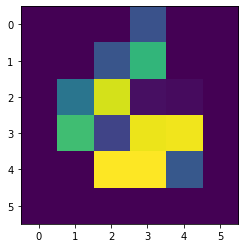

-1.0
Prediction: [0]


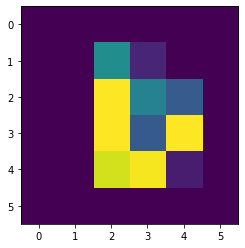

1.0
Prediction: [0]


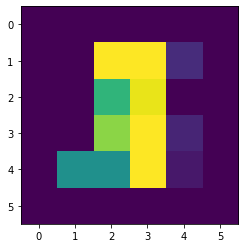

1.0
Prediction: [0]


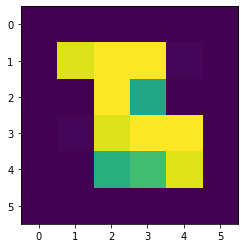

-1.0
Prediction: [0]


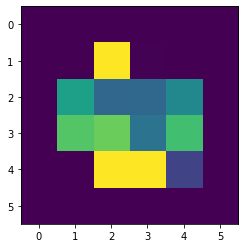

1.0
Prediction: [0]


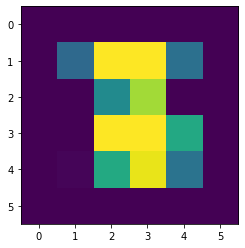

-1.0
Prediction: [1]


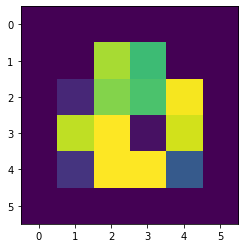

1.0
Prediction: [0]


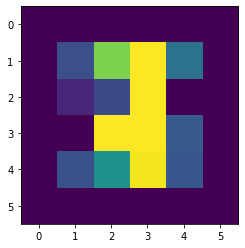

-1.0
Prediction: [0]


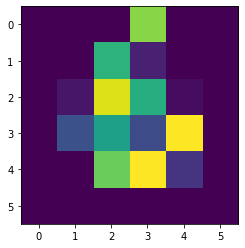

-1.0
Prediction: [0]


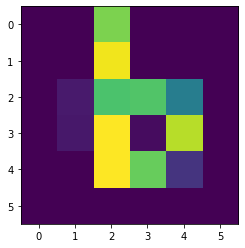

-1.0
Prediction: [1]


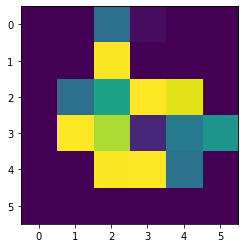

-1.0
Prediction: [0]


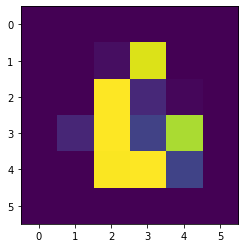

1.0
Prediction: [1]


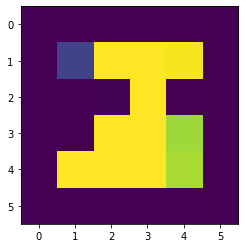

1.0
Prediction: [1]


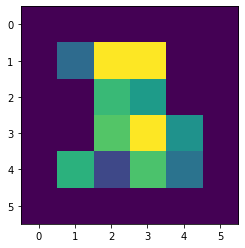

1.0
Prediction: [0]


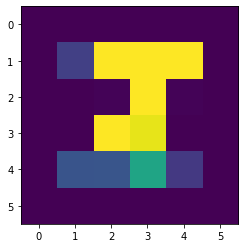

-1.0
Prediction: [0]


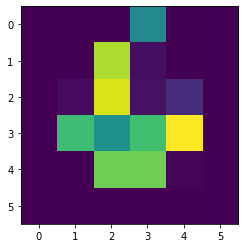

1.0
Prediction: [0]


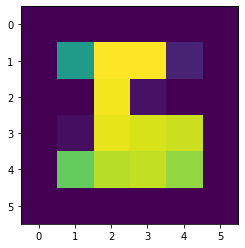

1.0
Prediction: [0]


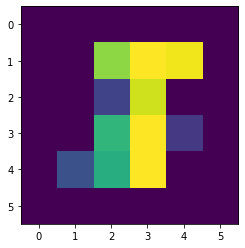

-1.0
Prediction: [0]


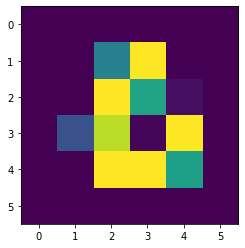

1.0
Prediction: [0]


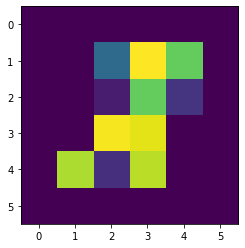

-1.0
Prediction: [0]


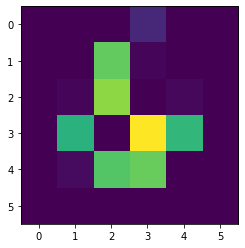

1.0
Prediction: [0]


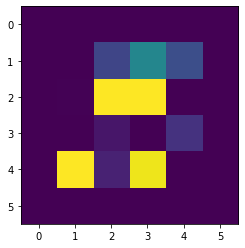

-1.0
Prediction: [0]


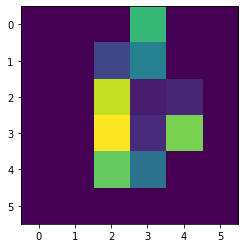

1.0
Prediction: [0]


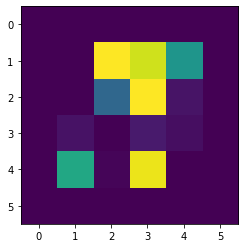

-1.0
Prediction: [0]


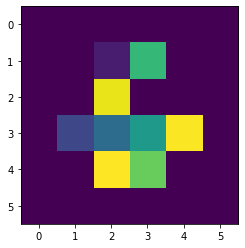

1.0
Prediction: [0]


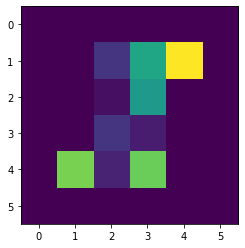

-1.0
Prediction: [0]


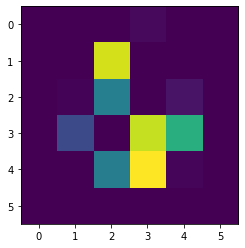

1.0
Prediction: [0]


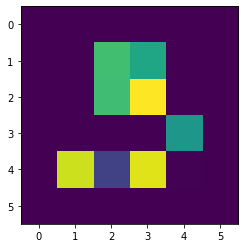

-1.0
Prediction: [0]


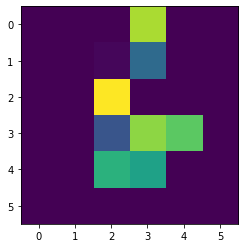

-1.0
Prediction: [0]


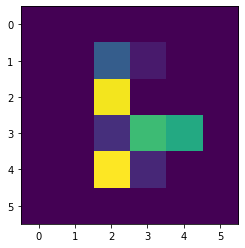

-1.0
Prediction: [0]


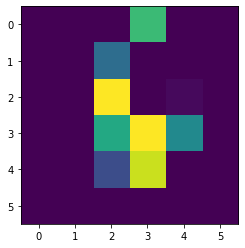

1.0
Prediction: [1]


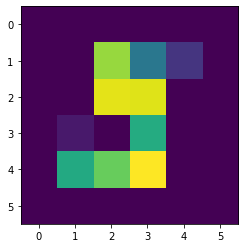

-1.0
Prediction: [0]


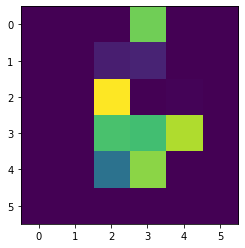

1.0
Prediction: [0]


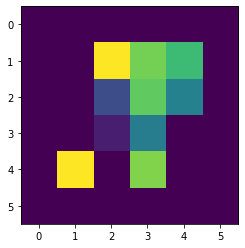

-1.0
Prediction: [0]


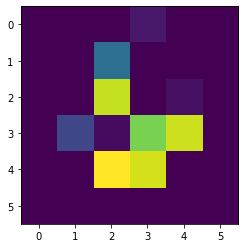

1.0
Prediction: [1]


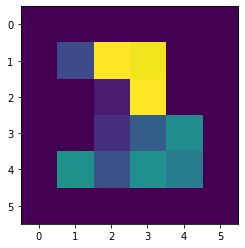

-1.0
Prediction: [0]


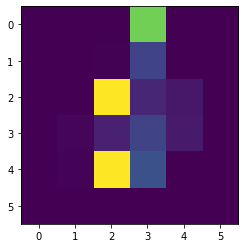

1.0
Prediction: [1]


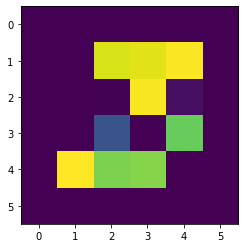

1.0
Prediction: [1]


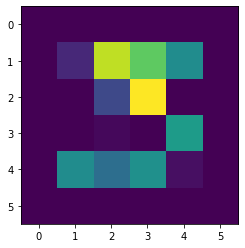

1.0
Prediction: [0]


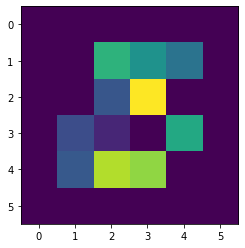

-1.0
Prediction: [0]


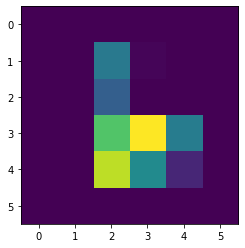

-1.0
Prediction: [0]


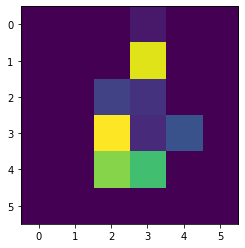

1.0
Prediction: [1]


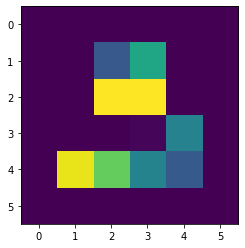

-1.0
Prediction: [1]


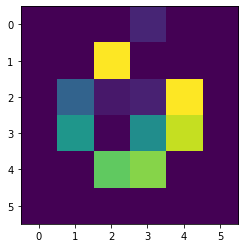

1.0
Prediction: [1]


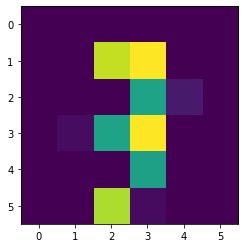

-1.0
Prediction: [1]


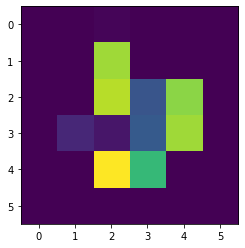

1.0
Prediction: [0]


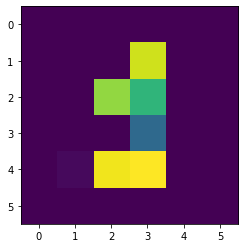

-1.0
Prediction: [1]


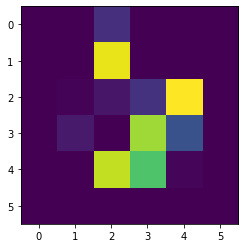

1.0
Prediction: [0]


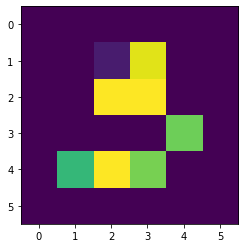

-1.0
Prediction: [0]


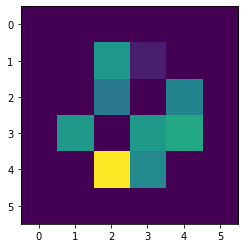

1.0
Prediction: [0]


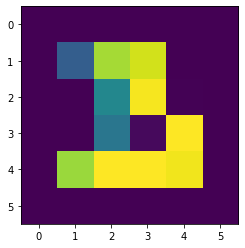

-1.0
Prediction: [0]


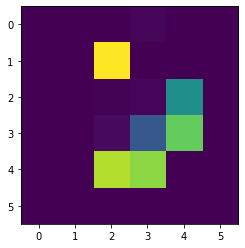

-1.0
Prediction: [0]


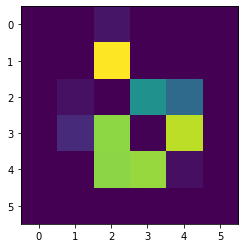

-1.0
Prediction: [0]


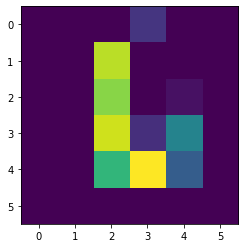

1.0
Prediction: [0]


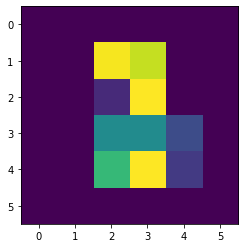

1.0
Prediction: [0]


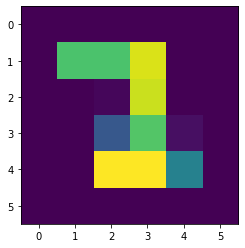

1.0
Prediction: [0]


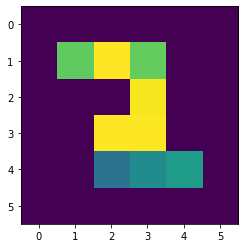

1.0
Prediction: [1]


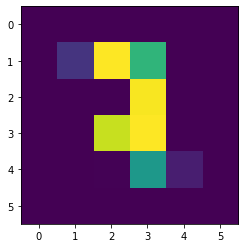

1.0
Prediction: [0]


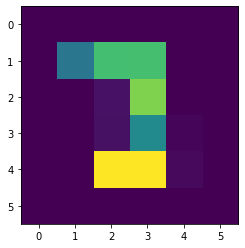

1.0
Prediction: [0]


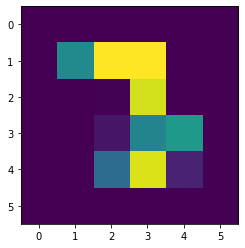

-1.0
Prediction: [1]


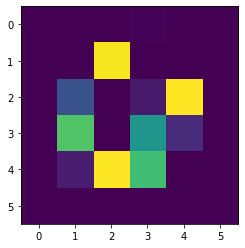

-1.0
Prediction: [0]


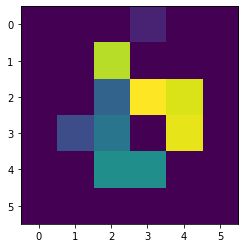

1.0
Prediction: [0]


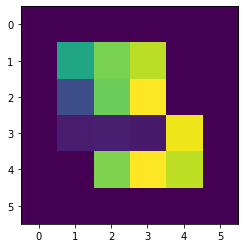

-1.0
Prediction: [0]


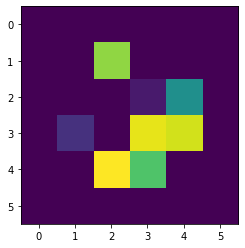

-1.0
Prediction: [1]


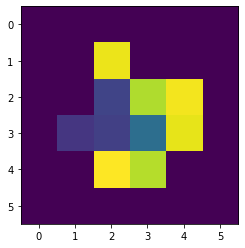

-1.0
Prediction: [0]


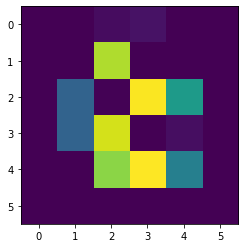

1.0
Prediction: [1]


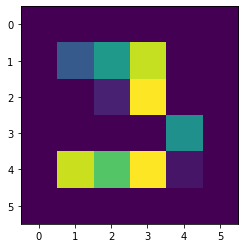

1.0
Prediction: [0]


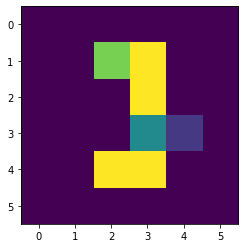

-1.0
Prediction: [0]


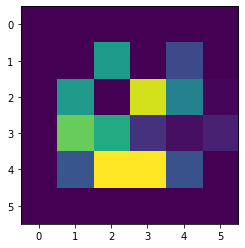

1.0
Prediction: [1]


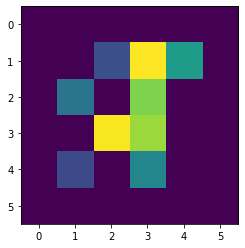

1.0
Prediction: [0]


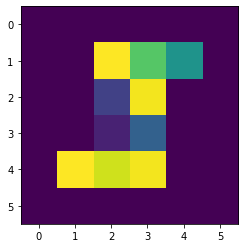

1.0
Prediction: [1]


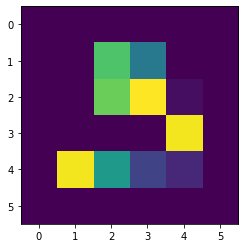

1.0
Prediction: [0]


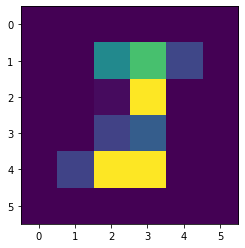

1.0
Prediction: [0]


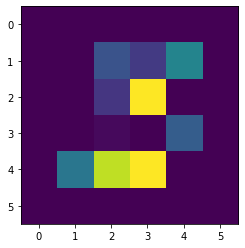

-1.0
Prediction: [0]


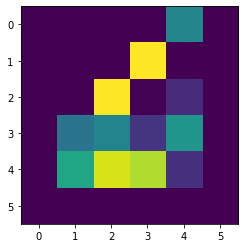

-1.0
Prediction: [0]


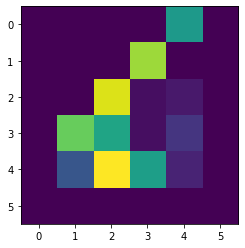

1.0
Prediction: [0]


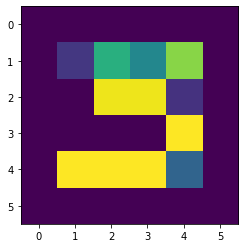

-1.0
Prediction: [0]


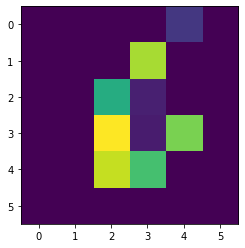

1.0
Prediction: [0]


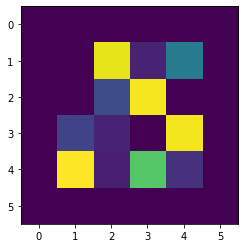

1.0
Prediction: [1]


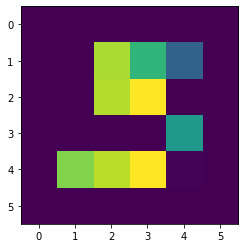

-1.0
Prediction: [0]


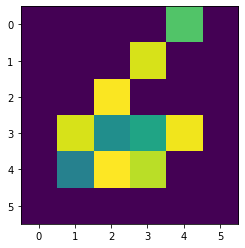

1.0
Prediction: [0]


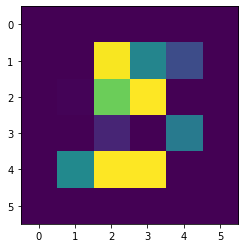

1.0
Prediction: [1]


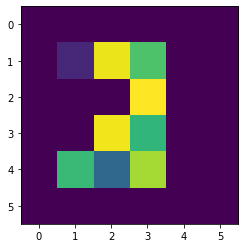

-1.0
Prediction: [0]


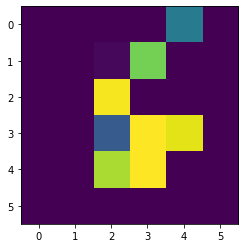

1.0
Prediction: [0]


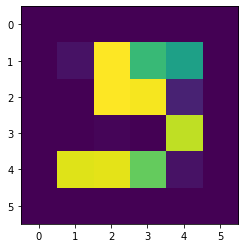

1.0
Prediction: [0]


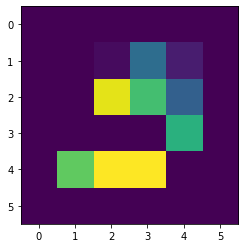

-1.0
Prediction: [0]


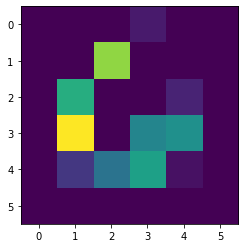

1.0
Prediction: [1]


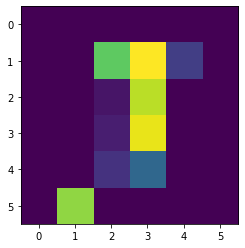

-1.0
Prediction: [0]


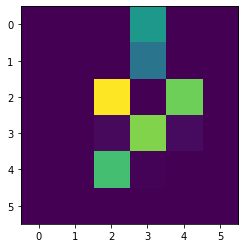

1.0
Prediction: [1]


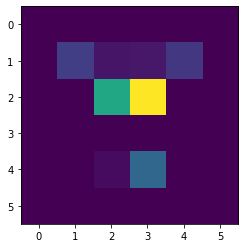

-1.0
Prediction: [1]


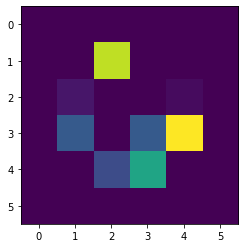

-1.0
Prediction: [0]


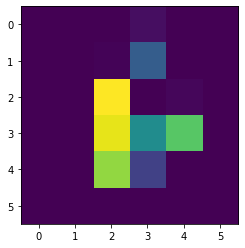

1.0
Prediction: [1]


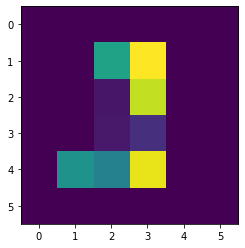

-1.0
Prediction: [0]


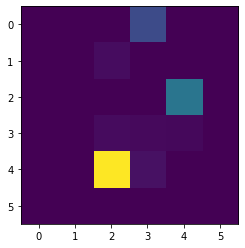

1.0
Prediction: [1]


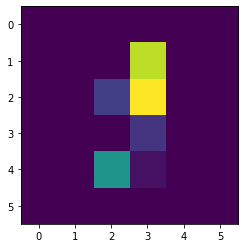

1.0
Prediction: [1]


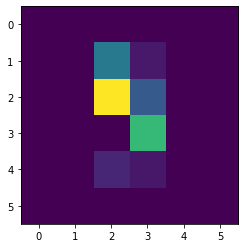

1.0
Prediction: [1]


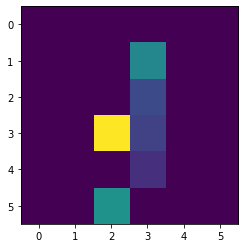

1.0
Prediction: [1]


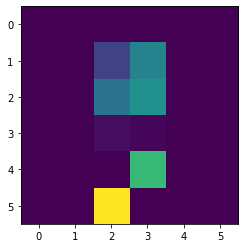

1.0
Prediction: [1]


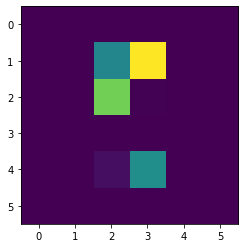

-1.0
Prediction: [0]


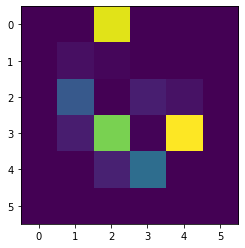

1.0
Prediction: [1]


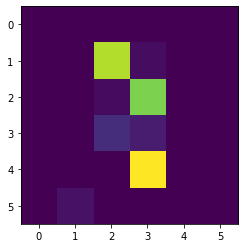

-1.0
Prediction: [1]


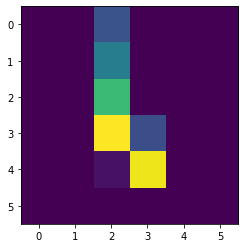

-1.0
Prediction: [1]


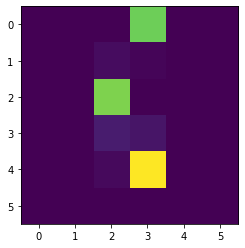

-1.0
Prediction: [0]


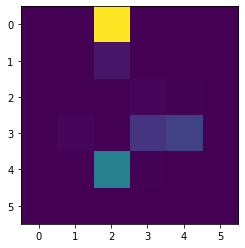

-1.0
Prediction: [0]


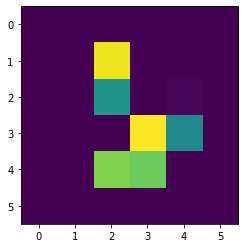

1.0
Prediction: [1]


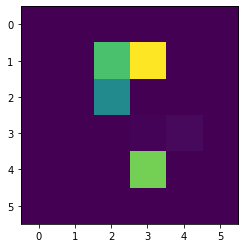

-1.0
Prediction: [0]


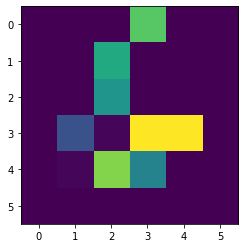

1.0
Prediction: [0]


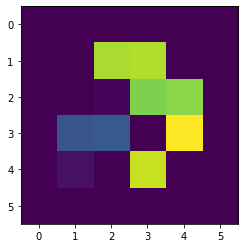

-1.0
Prediction: [0]


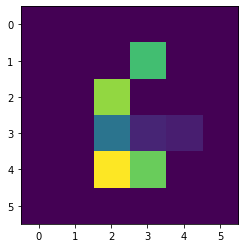

1.0
Prediction: [0]


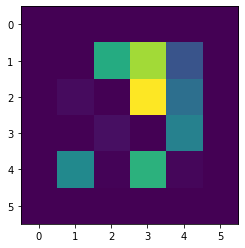

1.0
Prediction: [1]


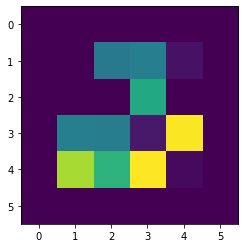

1.0
Prediction: [0]


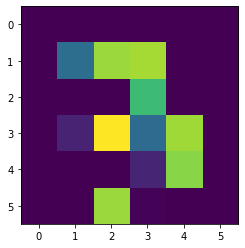

-1.0
Prediction: [0]


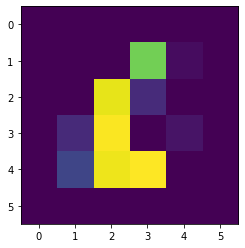

-1.0
Prediction: [1]


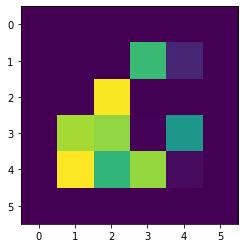

-1.0
Prediction: [0]


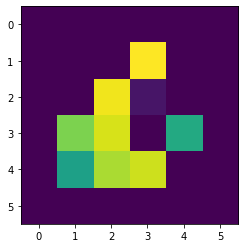

-1.0
Prediction: [0]


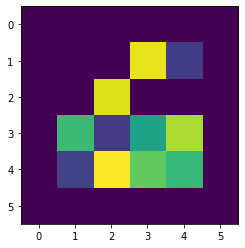

1.0
Prediction: [1]


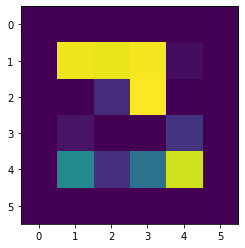

1.0
Prediction: [0]


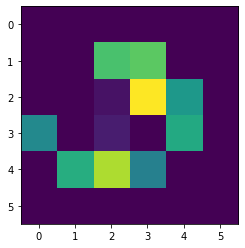

-1.0
Prediction: [0]


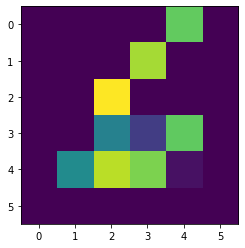

1.0
Prediction: [1]


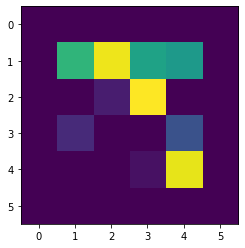

-1.0
Prediction: [0]


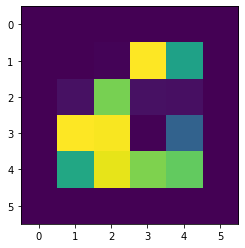

-1.0
Prediction: [0]


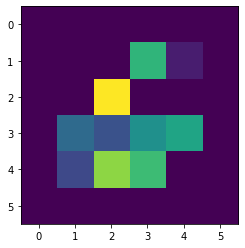

1.0
Prediction: [0]


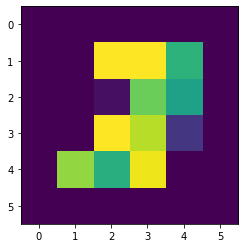

-1.0
Prediction: [0]


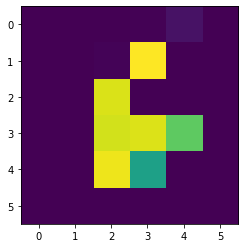

1.0
Prediction: [1]


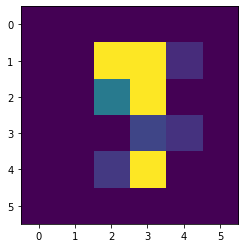

-1.0
Prediction: [0]


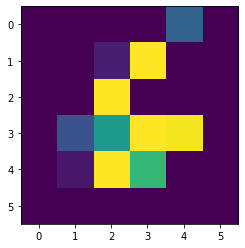

1.0
Prediction: [0]


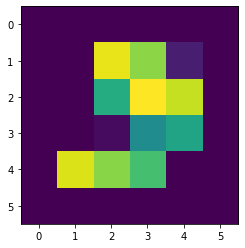

1.0
Prediction: [1]


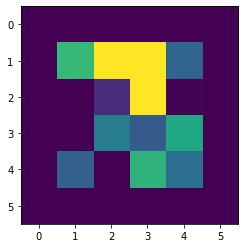

1.0
Prediction: [0]


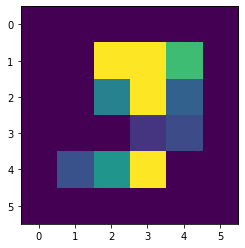

1.0
Prediction: [0]


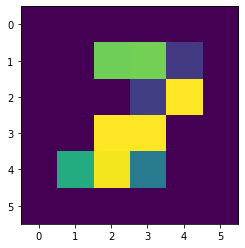

1.0
Prediction: [1]


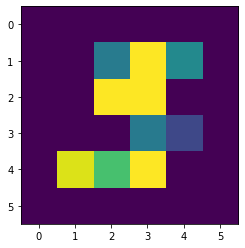

-1.0
Prediction: [0]


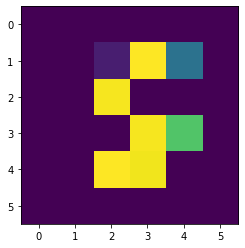

1.0
Prediction: [0]


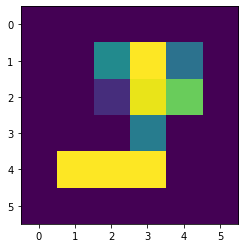

-1.0
Prediction: [1]


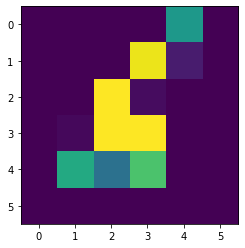

1.0
Prediction: [0]


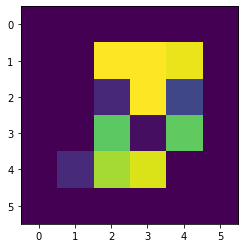

-1.0
Prediction: [0]


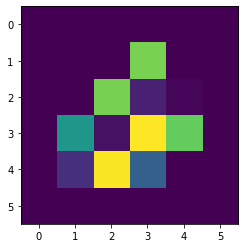

-1.0
Prediction: [0]


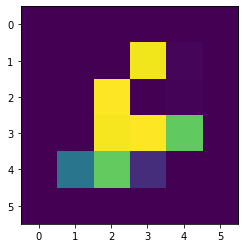

-1.0
Prediction: [0]


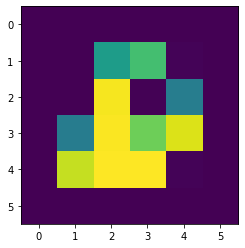

-1.0
Prediction: [0]


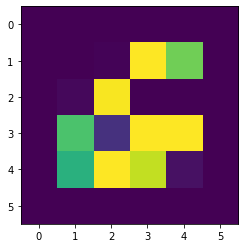

1.0
Prediction: [0]


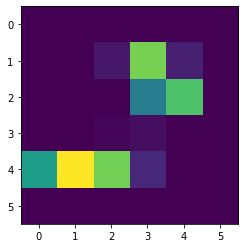

-1.0
Prediction: [0]


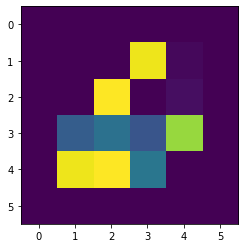

1.0
Prediction: [0]


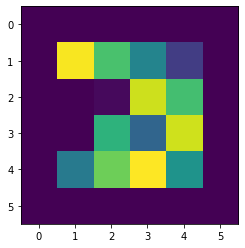

1.0
Prediction: [0]


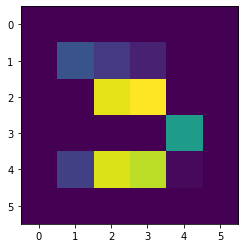

-1.0
Prediction: [0]


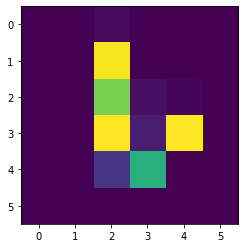

1.0
Prediction: [1]


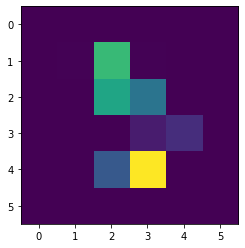

-1.0
Prediction: [0]


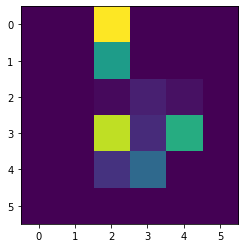

1.0
Prediction: [0]


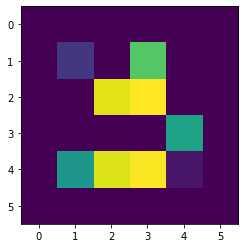

-1.0
Prediction: [0]


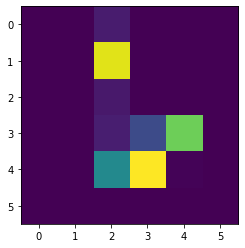

1.0
Prediction: [0]


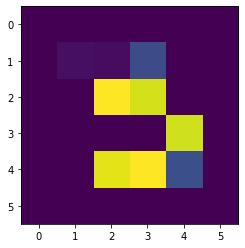

-1.0
Prediction: [0]


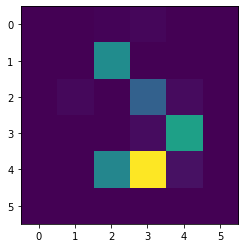

-1.0
Prediction: [0]


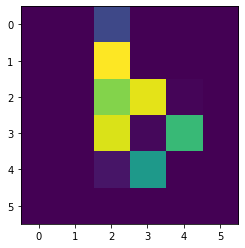

-1.0
Prediction: [1]


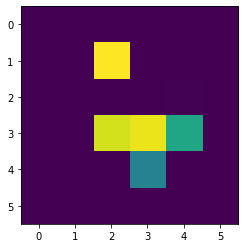

1.0
Prediction: [0]


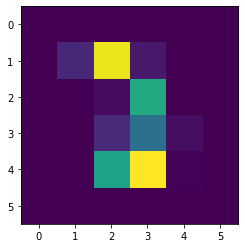

1.0
Prediction: [1]


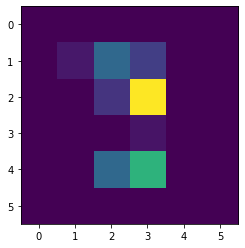

1.0
Prediction: [1]


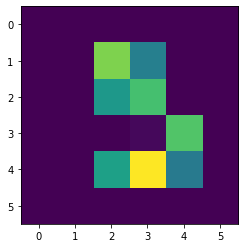

1.0
Prediction: [0]


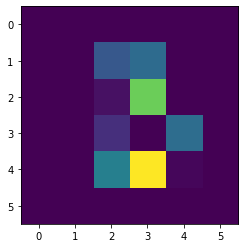

1.0
Prediction: [0]


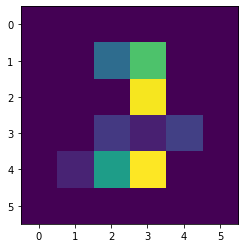

1.0
Prediction: [0]


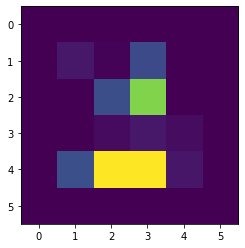

-1.0
Prediction: [0]


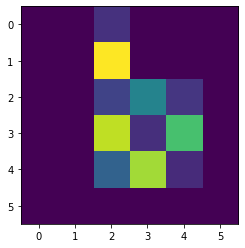

1.0
Prediction: [1]


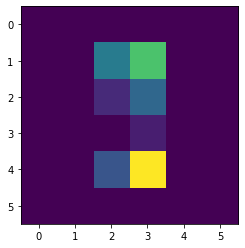

-1.0
Prediction: [0]


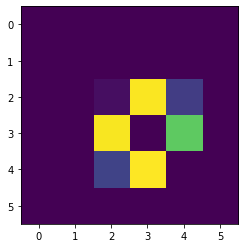

-1.0
Prediction: [0]


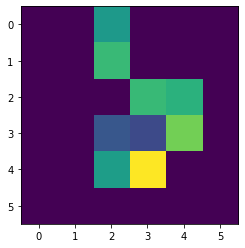

-1.0
Prediction: [0]


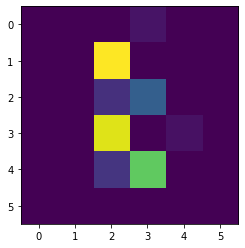

1.0
Prediction: [0]


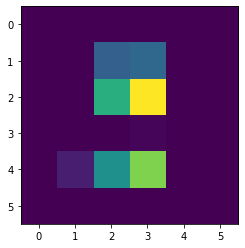

1.0
Prediction: [0]


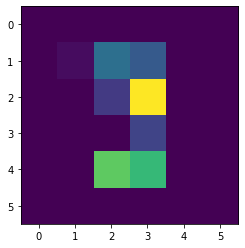

-1.0
Prediction: [0]


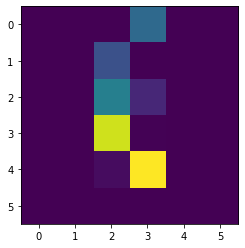

-1.0
Prediction: [1]


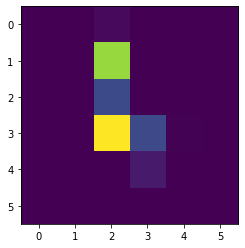

1.0
Prediction: [0]


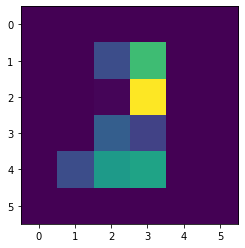

-1.0
Prediction: [0]


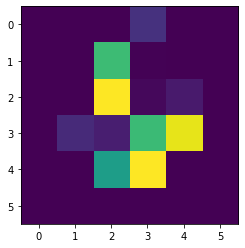

1.0
Prediction: [0]


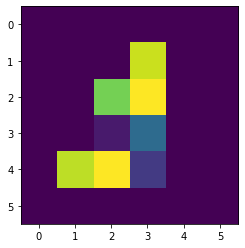

-1.0
Prediction: [0]


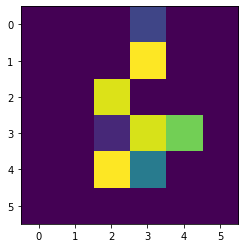

1.0
Prediction: [0]


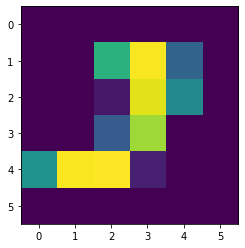

-1.0
Prediction: [1]


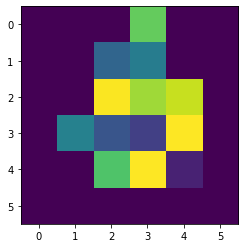

1.0
Prediction: [1]


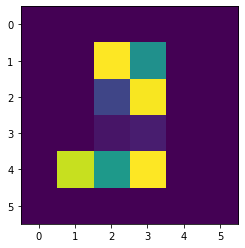

-1.0
Prediction: [0]


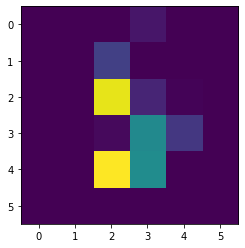

1.0
Prediction: [0]


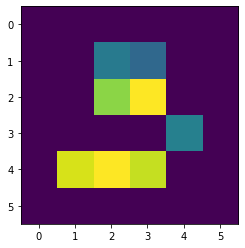

1.0
Prediction: [0]


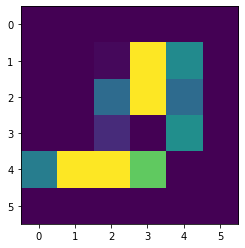

1.0
Prediction: [1]


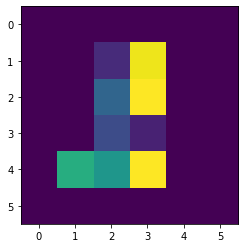

1.0
Prediction: [0]


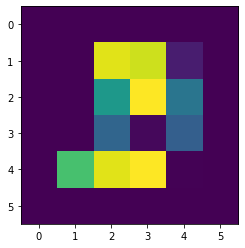

-1.0
Prediction: [0]


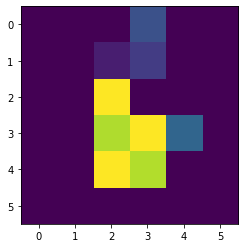

-1.0
Prediction: [0]


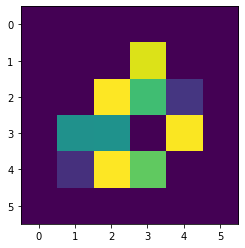

1.0
Prediction: [0]


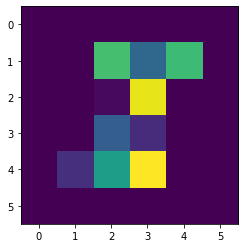

1.0
Prediction: [0]


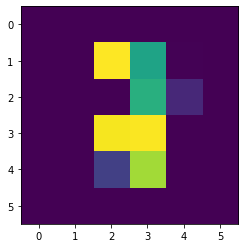

-1.0
Prediction: [0]


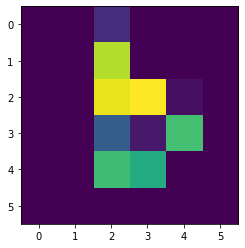

-1.0
Prediction: [0]


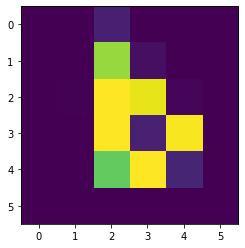

1.0
Prediction: [0]


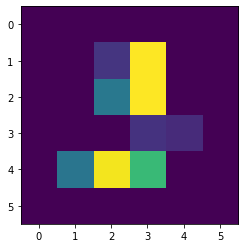

1.0
Prediction: [1]


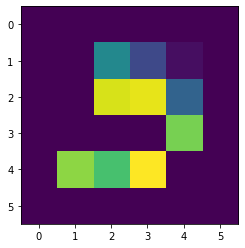

-1.0
Prediction: [0]


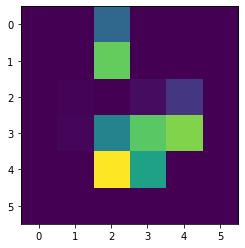

-1.0
Prediction: [0]


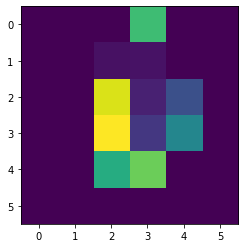

1.0
Prediction: [1]


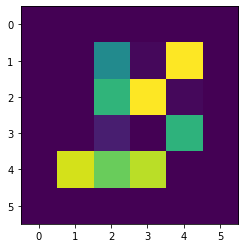

-1.0
Prediction: [0]


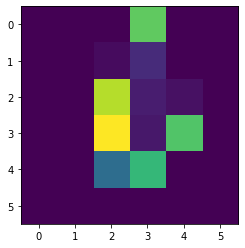

-1.0
Prediction: [1]


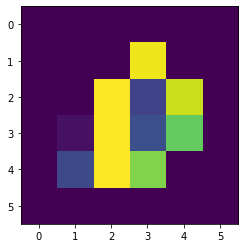

-1.0
Prediction: [0]


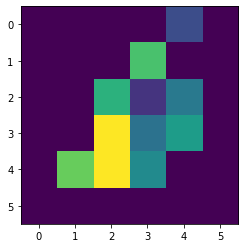

1.0
Prediction: [1]


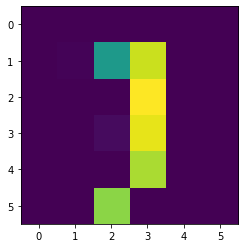

-1.0
Prediction: [0]


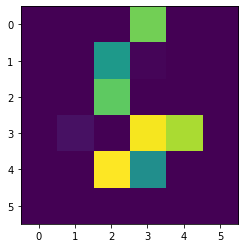

1.0
Prediction: [1]


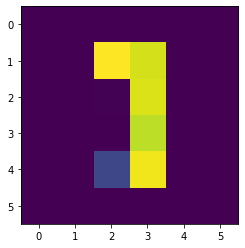

-1.0
Prediction: [0]


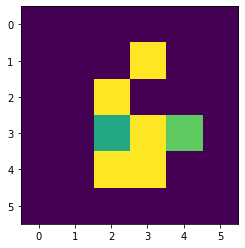

1.0
Prediction: [0]


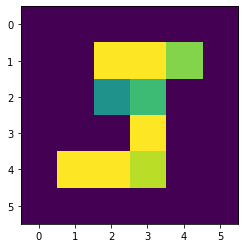

-1.0
Prediction: [0]


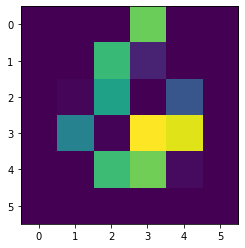

1.0
Prediction: [0]


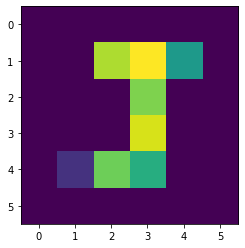

1.0
Prediction: [1]


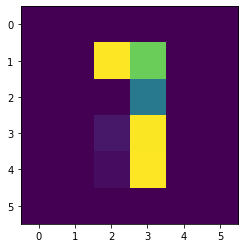

1.0
Prediction: [0]


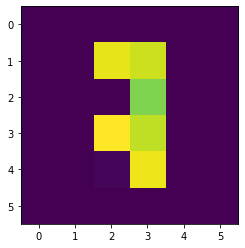

-1.0
Prediction: [0]


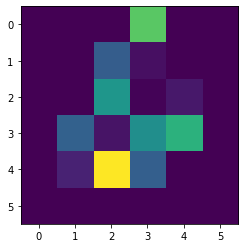

-1.0
Prediction: [0]


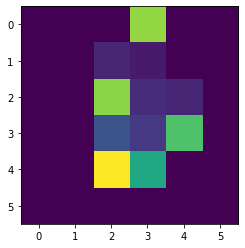

-1.0
Prediction: [0]


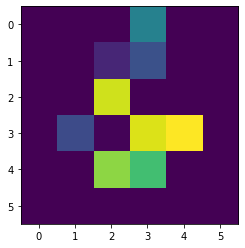

-1.0
Prediction: [0]


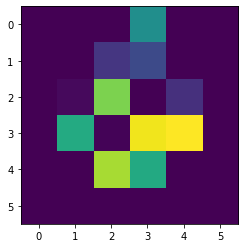

1.0
Prediction: [0]


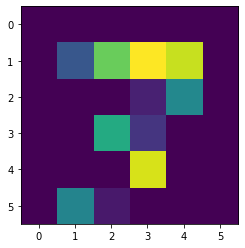

1.0
Prediction: [1]


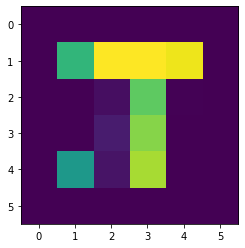

-1.0
Prediction: [0]


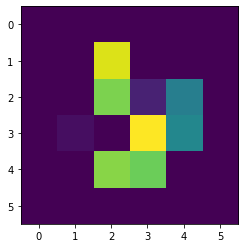

1.0
Prediction: [1]


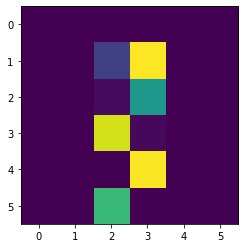

1.0
Prediction: [1]


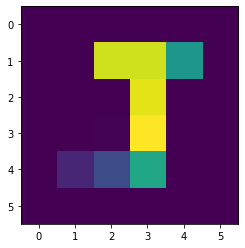

1.0
Prediction: [1]


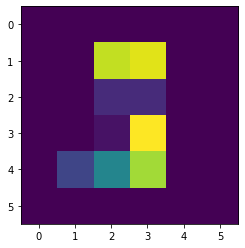

-1.0
Prediction: [0]


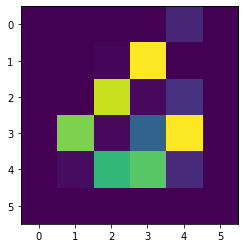

1.0
Prediction: [1]


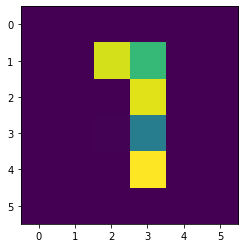

-1.0
Prediction: [0]


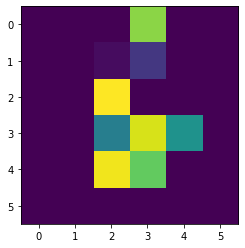

-1.0
Prediction: [0]


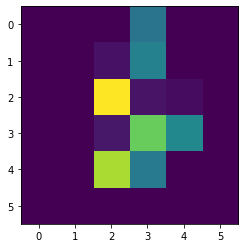

-1.0
Prediction: [0]


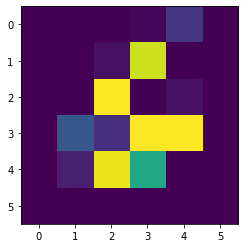

1.0
Prediction: [0]


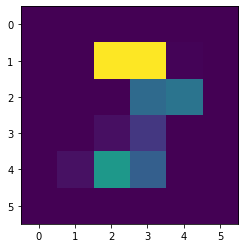

-1.0
Prediction: [0]


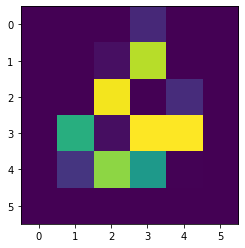

-1.0
Prediction: [0]


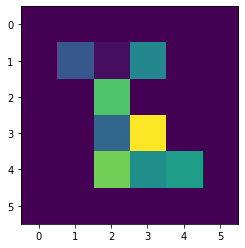

1.0
Prediction: [1]


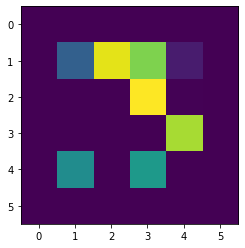

-1.0
Prediction: [0]


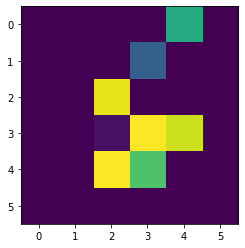

1.0
Prediction: [0]


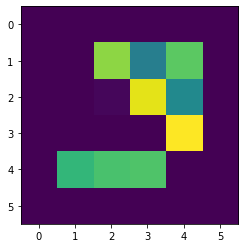

-1.0
Prediction: [0]


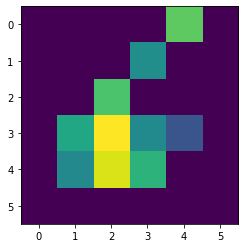

1.0
Prediction: [0]


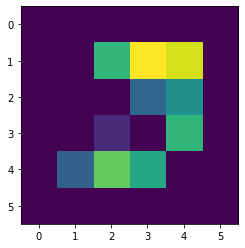

-1.0
Prediction: [0]


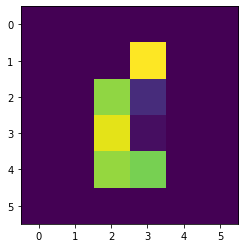

-1.0
Prediction: [0]


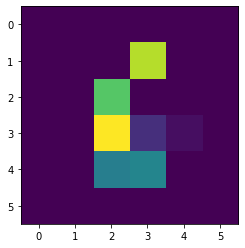

1.0
Prediction: [1]


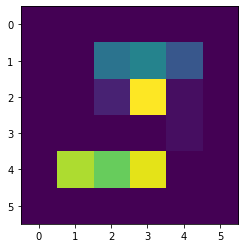

-1.0
Prediction: [1]


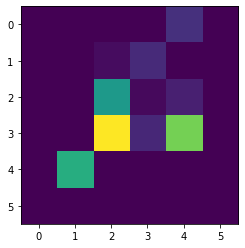

1.0
Prediction: [1]


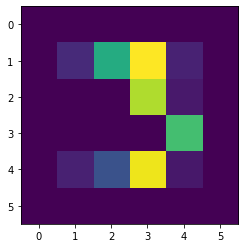

1.0
Prediction: [1]


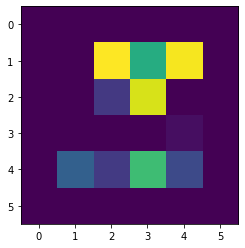

1.0
Prediction: [0]


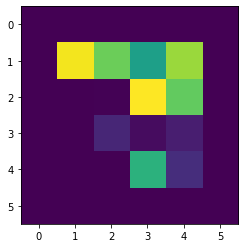

1.0
Prediction: [1]


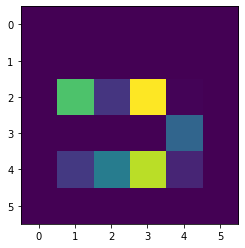

-1.0
Prediction: [0]


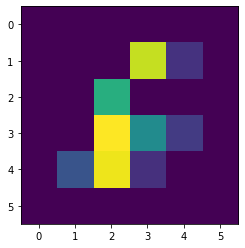

1.0
Prediction: [0]


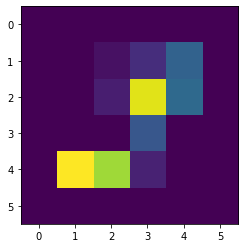

1.0
Prediction: [1]


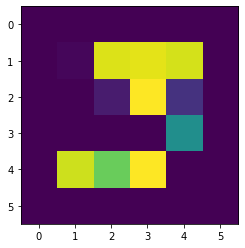

1.0
Prediction: [1]


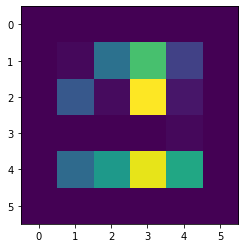

1.0
Prediction: [0]


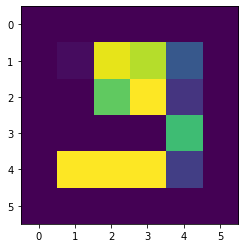

-1.0
Prediction: [0]


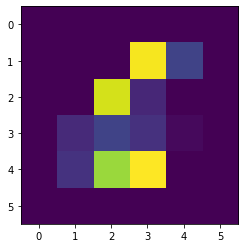

1.0
Prediction: [1]


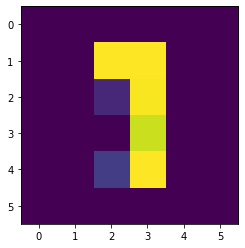

-1.0
Prediction: [0]


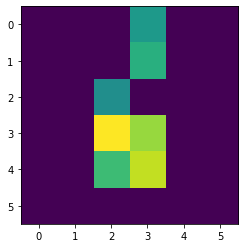

1.0
Prediction: [0]


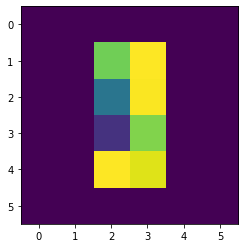

-1.0
Prediction: [0]


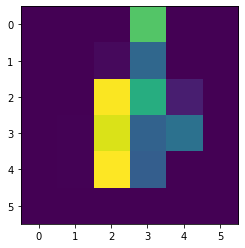

1.0
Prediction: [0]


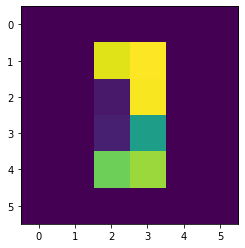

-1.0
Prediction: [0]


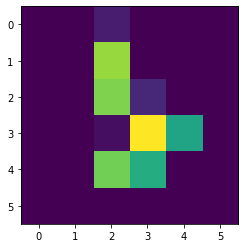

-1.0
Prediction: [0]


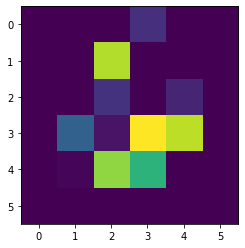

-1.0
Prediction: [0]


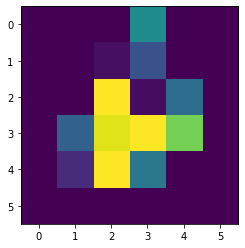

1.0
Prediction: [0]


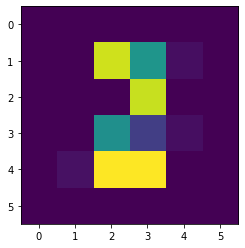

1.0
Prediction: [0]


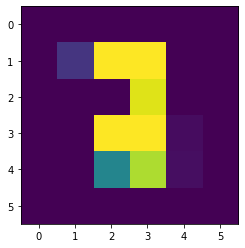

-1.0
Prediction: [0]


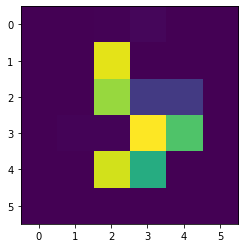

1.0
Prediction: [0]


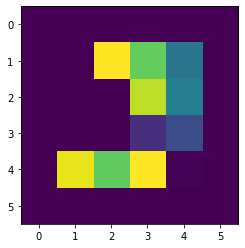

1.0
Prediction: [0]


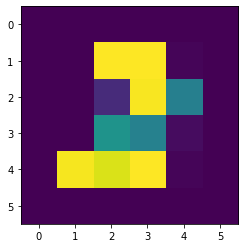

-1.0
Prediction: [0]


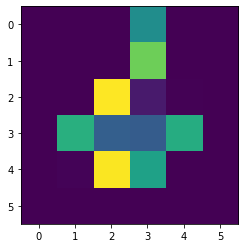

1.0
Prediction: [0]


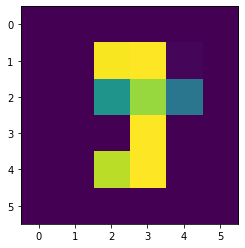

-1.0
Prediction: [0]


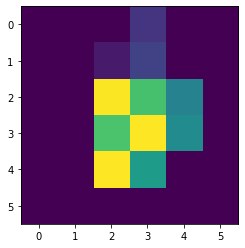

-1.0
Prediction: [0]


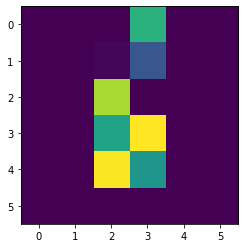

-1.0
Prediction: [0]


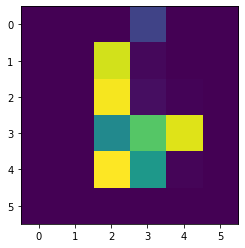

1.0
Prediction: [1]


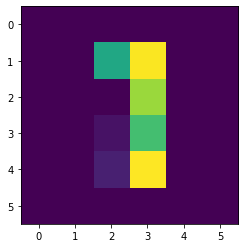

-1.0
Prediction: [0]


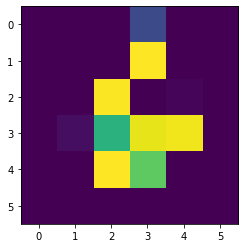

1.0
Prediction: [0]


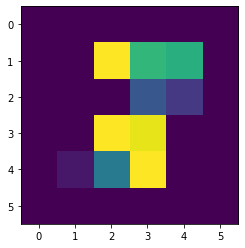

1.0
Prediction: [1]


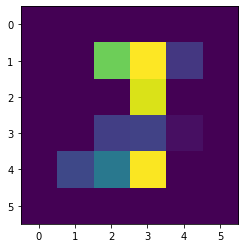

-1.0
Prediction: [0]


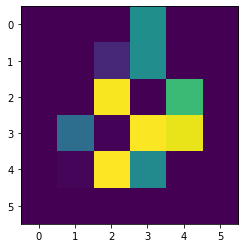

-1.0
Prediction: [0]


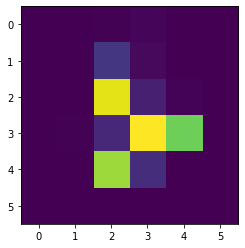

1.0
Prediction: [1]


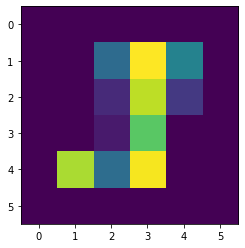

1.0
Prediction: [0]


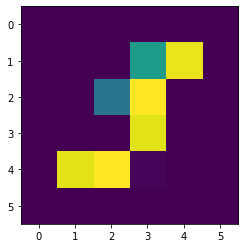

1.0
Prediction: [0]


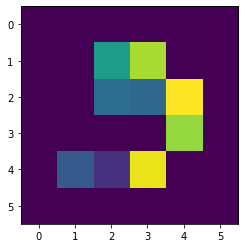

-1.0
Prediction: [0]


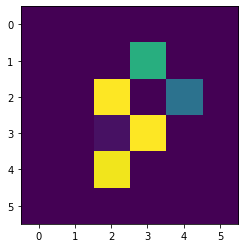

1.0
Prediction: [0]


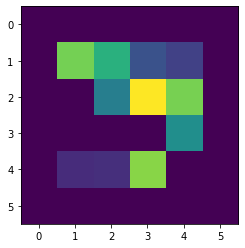

-1.0
Prediction: [0]


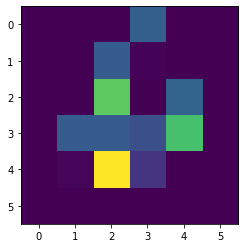

-1.0
Prediction: [0]


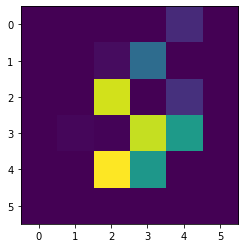

-1.0
Prediction: [0]


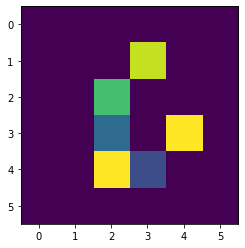

1.0
Prediction: [1]


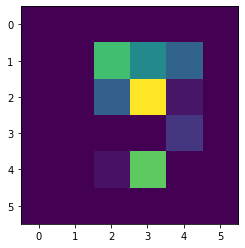

1.0
Prediction: [1]


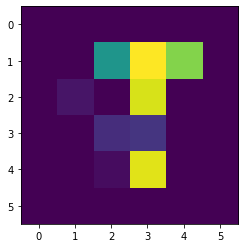

1.0
Prediction: [0]


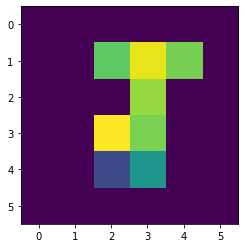

-1.0
Prediction: [0]


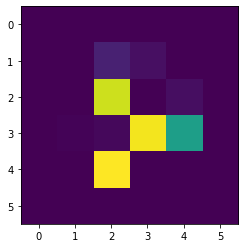

-1.0
Prediction: [0]


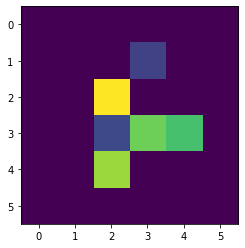

-1.0
Prediction: [0]


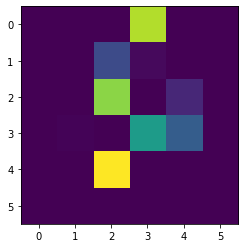

1.0
Prediction: [1]


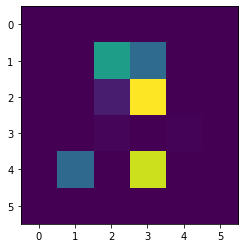

-1.0
Prediction: [0]


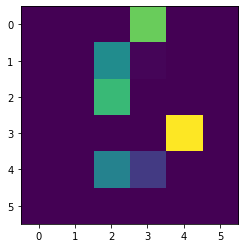

-1.0
Prediction: [0]


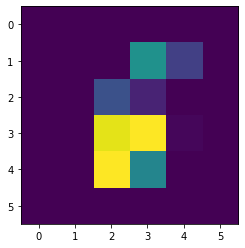

1.0
Prediction: [1]


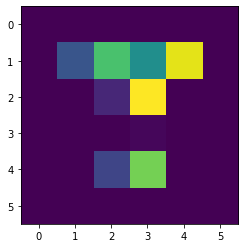

1.0
Prediction: [1]


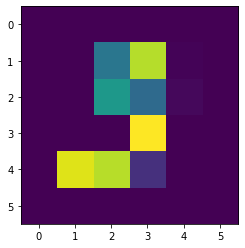

1.0
Prediction: [0]


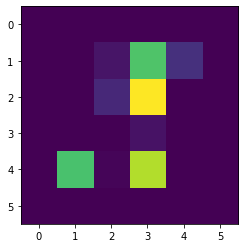

1.0
Prediction: [0]


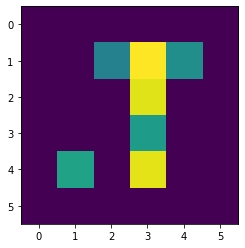

1.0
Prediction: [1]


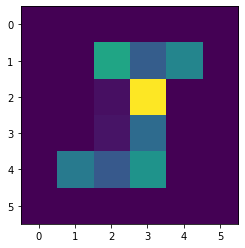

-1.0
Prediction: [0]


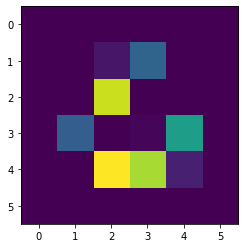

1.0
Prediction: [0]


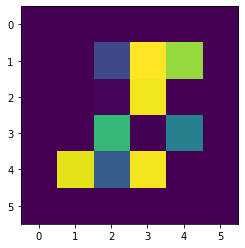

-1.0
Prediction: [0]


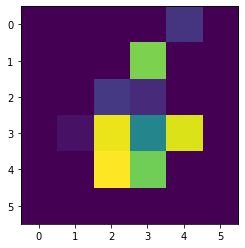

1.0
Prediction: [1]


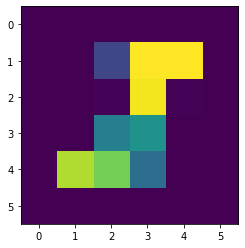

-1.0
Prediction: [0]


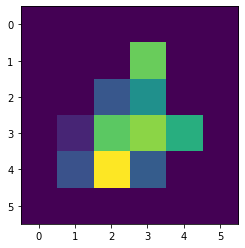

1.0
Prediction: [1]


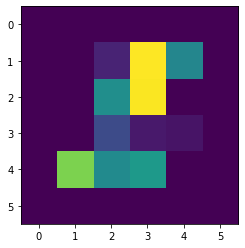

-1.0
Prediction: [0]


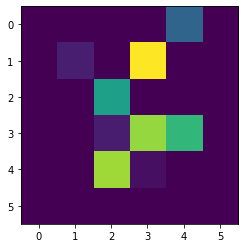

-1.0
Prediction: [0]


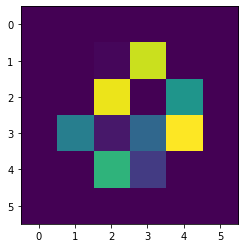

1.0
Prediction: [1]


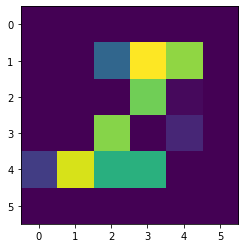

-1.0
Prediction: [0]


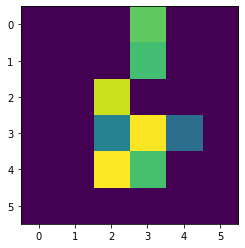

-1.0
Prediction: [0]


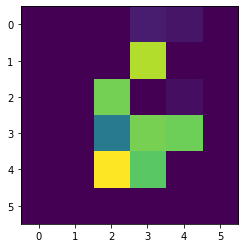

-1.0
Prediction: [0]


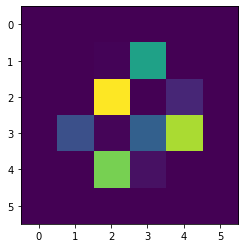

-1.0
Prediction: [0]


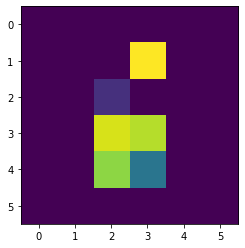

1.0
Prediction: [1]


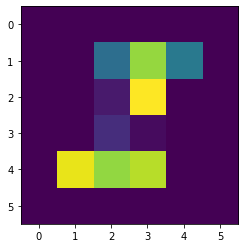

1.0
Prediction: [1]


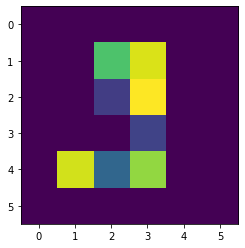

1.0
Prediction: [1]


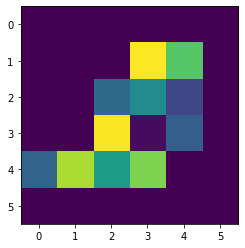

-1.0
Prediction: [0]


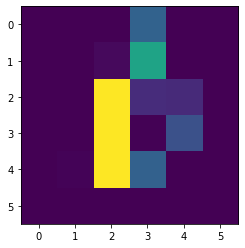

-1.0
Prediction: [0]


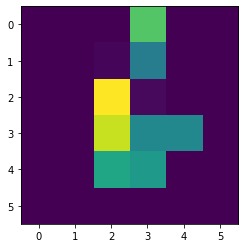

1.0
Prediction: [1]


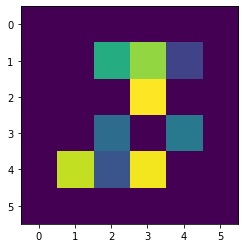

1.0
Prediction: [0]


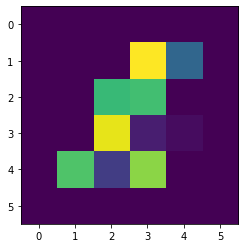

-1.0
Prediction: [0]


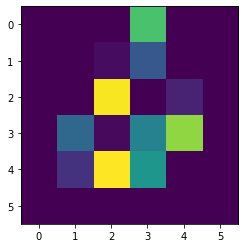

1.0
Prediction: [1]


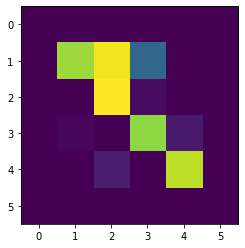

-1.0
Prediction: [1]


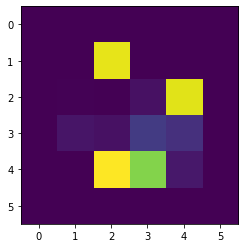

1.0
Prediction: [1]


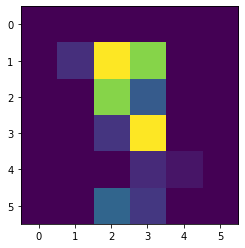

1.0
Prediction: [1]


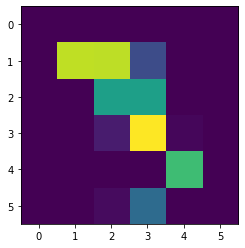

-1.0
Prediction: [0]


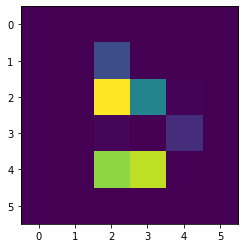

1.0
Prediction: [1]


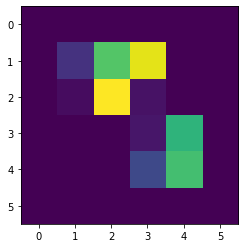

1.0
Prediction: [1]


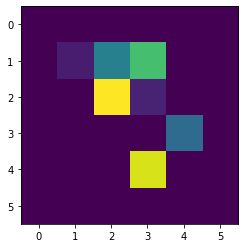

1.0
Prediction: [1]


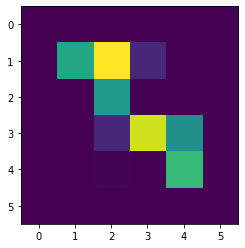

-1.0
Prediction: [1]


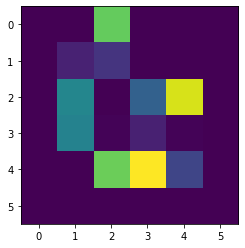

-1.0
Prediction: [0]


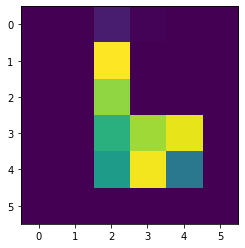

-1.0
Prediction: [0]


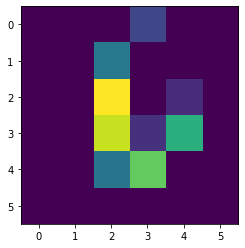

1.0
Prediction: [1]


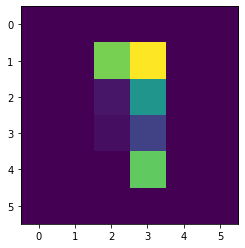

1.0
Prediction: [1]


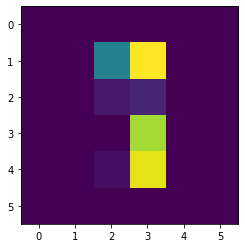

-1.0
Prediction: [0]


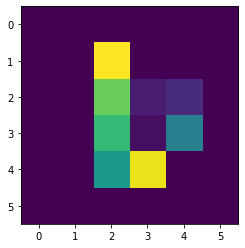

-1.0
Prediction: [0]


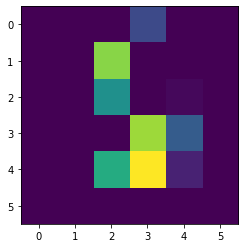

1.0
Prediction: [1]


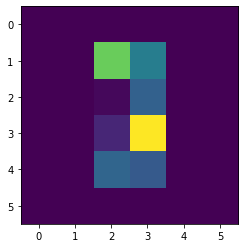

1.0
Prediction: [0]


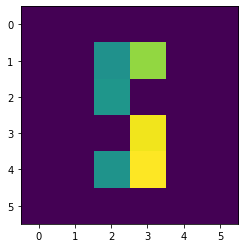

-1.0
Prediction: [0]


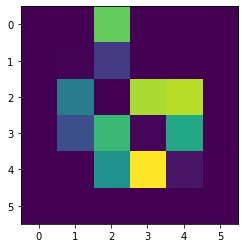

-1.0
Prediction: [1]


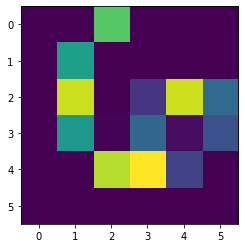

-1.0
Prediction: [0]


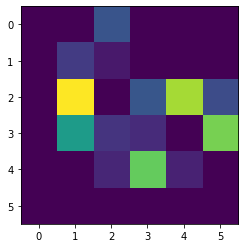

1.0
Prediction: [1]


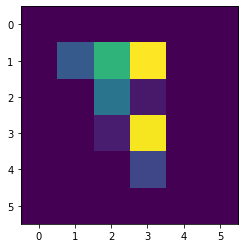

1.0
Prediction: [1]


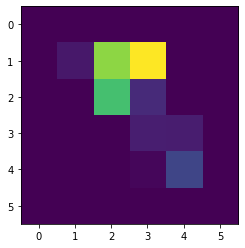

-1.0
Prediction: [0]


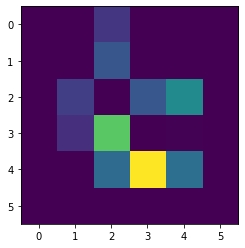

1.0
Prediction: [0]


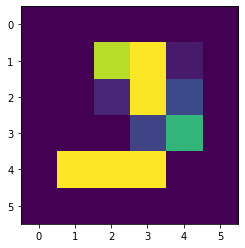

-1.0
Prediction: [0]


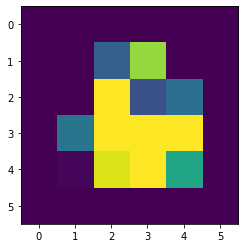

1.0
Prediction: [0]


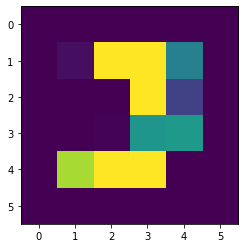

-1.0
Prediction: [0]


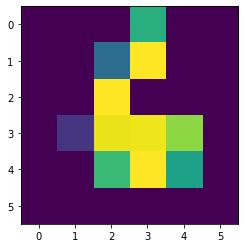

1.0
Prediction: [0]


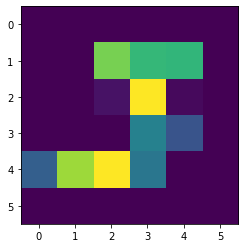

-1.0
Prediction: [0]


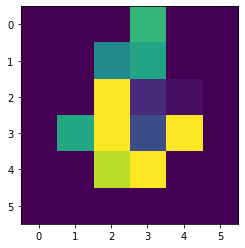

-1.0
Prediction: [0]


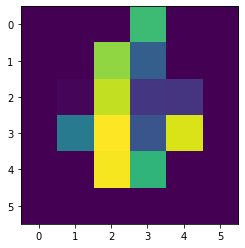

-1.0
Prediction: [0]


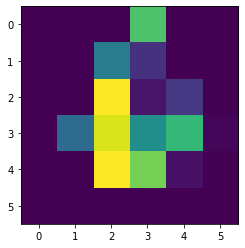

1.0
Prediction: [0]


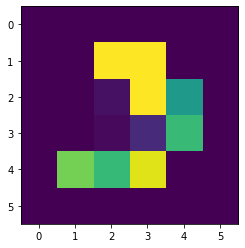

-1.0
Prediction: [0]


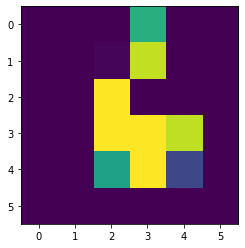

1.0
Prediction: [0]


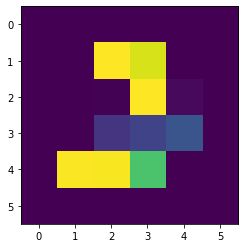

-1.0
Prediction: [0]


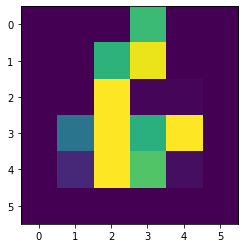

-1.0
Prediction: [0]


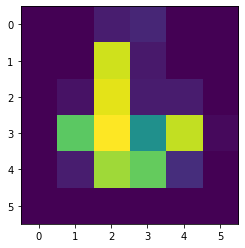

-1.0
Prediction: [0]


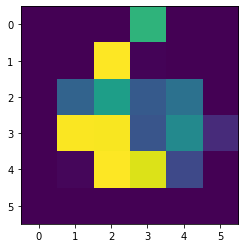

1.0
Prediction: [0]


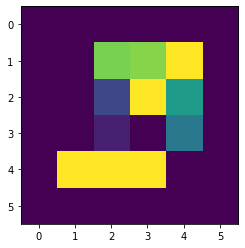

1.0
Prediction: [0]


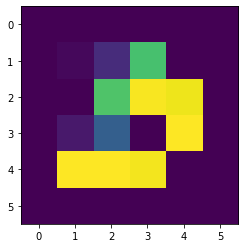

1.0
Prediction: [0]


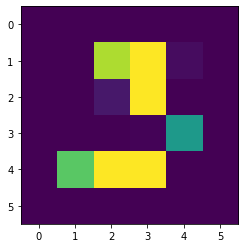

-1.0
Prediction: [0]


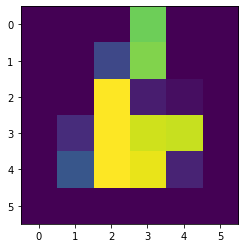

1.0
Prediction: [0]


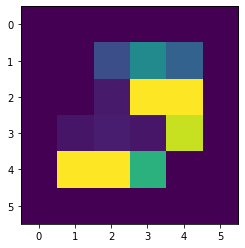

-1.0
Prediction: [0]


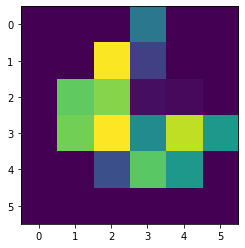

1.0
Prediction: [0]


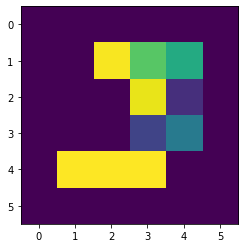

1.0
Prediction: [0]


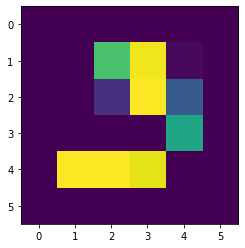

1.0
Prediction: [0]


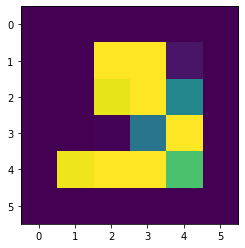

-1.0
Prediction: [0]


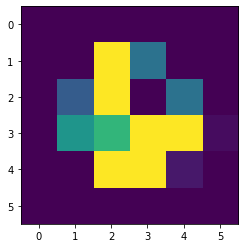

1.0
Prediction: [0]


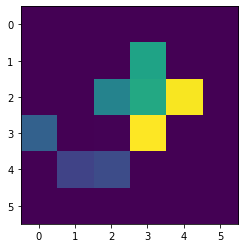

-1.0
Prediction: [0]


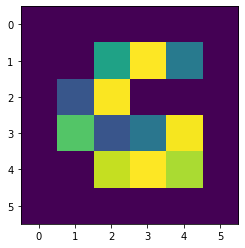

1.0
Prediction: [0]


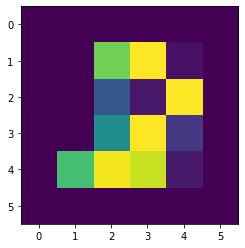

-1.0
Prediction: [0]


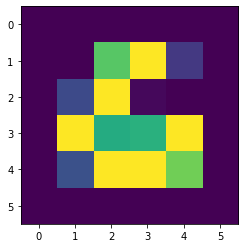

1.0
Prediction: [0]


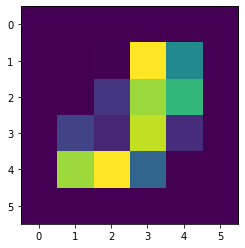

-1.0
Prediction: [0]


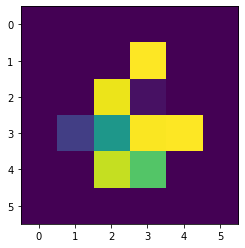

-1.0
Prediction: [0]


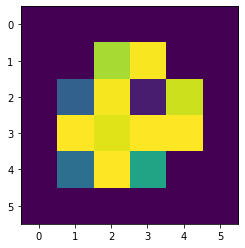

1.0
Prediction: [0]


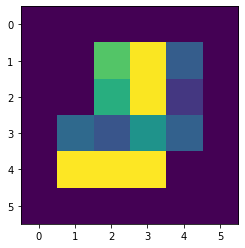

-1.0
Prediction: [0]


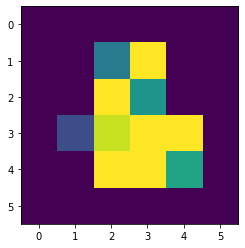

-1.0
Prediction: [0]


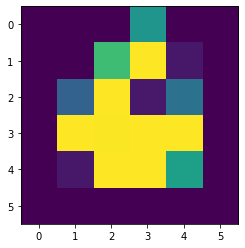

1.0
Prediction: [1]


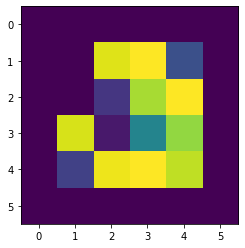

-1.0
Prediction: [0]


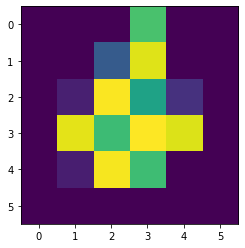

-1.0
Prediction: [0]


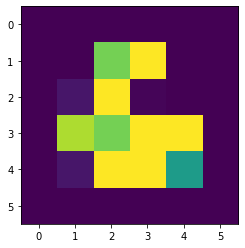

-1.0
Prediction: [0]


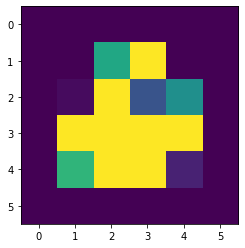

-1.0
Prediction: [1]


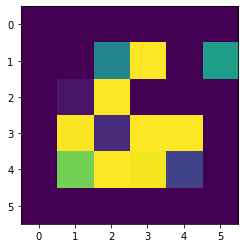

1.0
Prediction: [0]


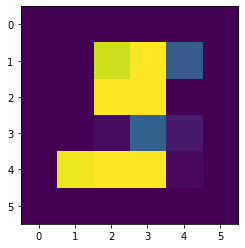

1.0
Prediction: [0]


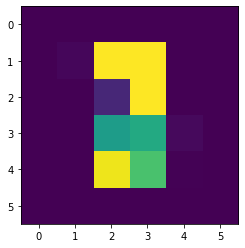

-1.0
Prediction: [0]


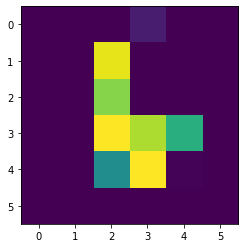

1.0
Prediction: [0]


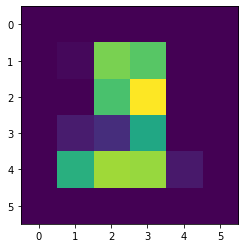

-1.0
Prediction: [0]


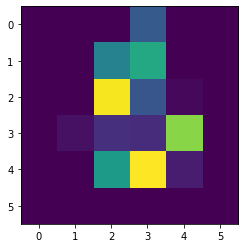

1.0
Prediction: [1]


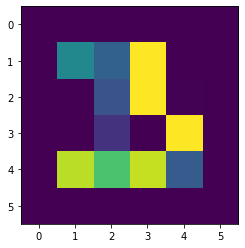

-1.0
Prediction: [0]


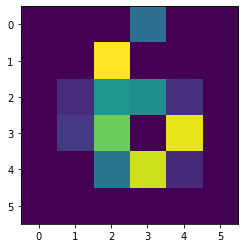

1.0
Prediction: [1]


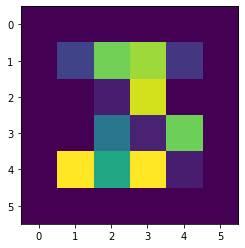

-1.0
Prediction: [0]


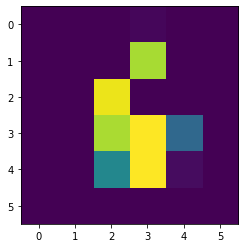

-1.0
Prediction: [0]


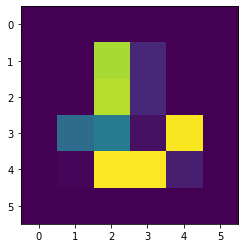

1.0
Prediction: [0]


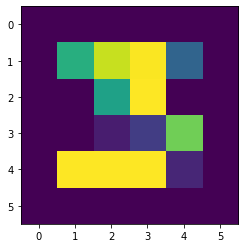

1.0
Prediction: [0]


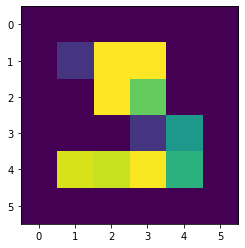

1.0
Prediction: [0]


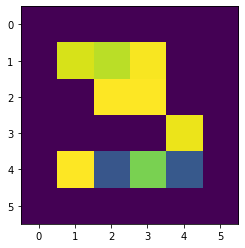

1.0
Prediction: [1]


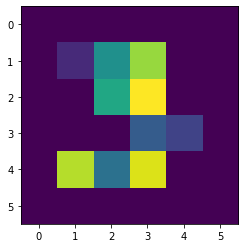

1.0
Prediction: [0]


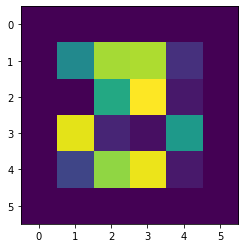

-1.0
Prediction: [1]


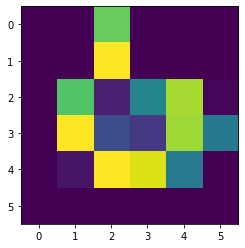

1.0
Prediction: [0]


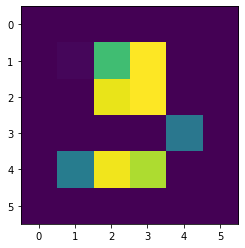

-1.0
Prediction: [0]


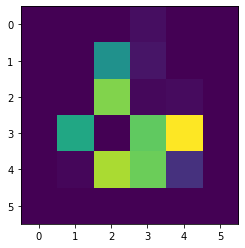

-1.0
Prediction: [0]


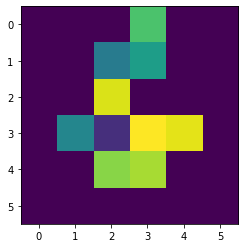

1.0
Prediction: [0]


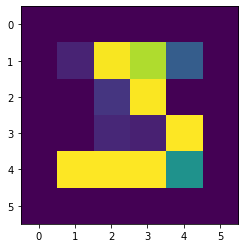

1.0
Prediction: [0]


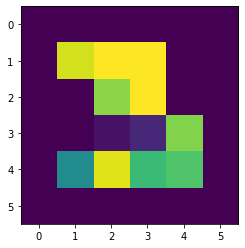

-1.0
Prediction: [0]


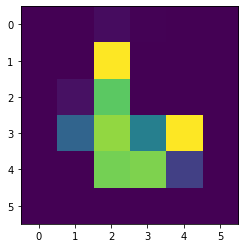

-1.0
Prediction: [0]


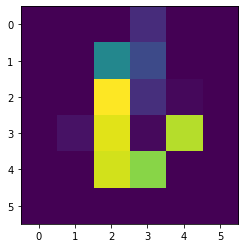

-1.0
Prediction: [0]


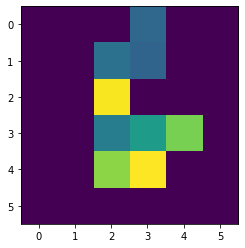

1.0
Prediction: [0]


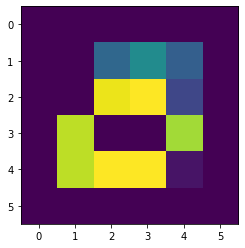

1.0
Prediction: [0]


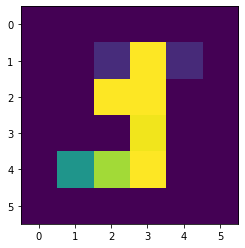

-1.0
Prediction: [0]


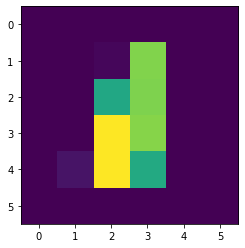

1.0
Prediction: [0]


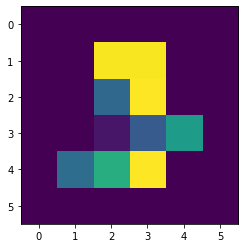

-1.0
Prediction: [0]


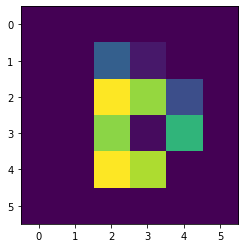

1.0
Prediction: [0]


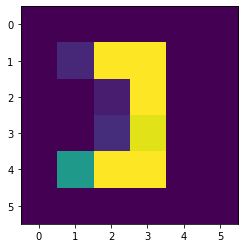

-1.0
Prediction: [0]


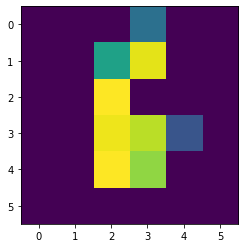

1.0
Prediction: [0]


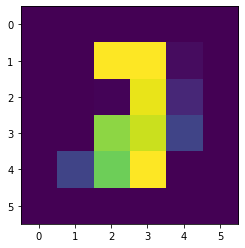

-1.0
Prediction: [0]


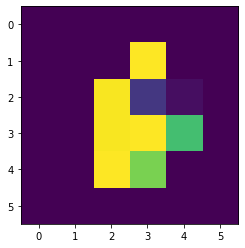

-1.0
Prediction: [0]


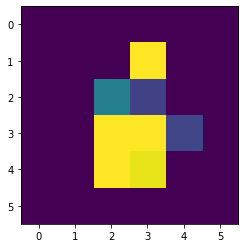

-1.0
Prediction: [0]


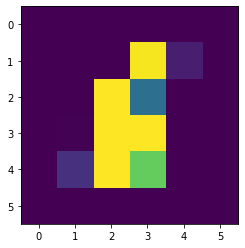

1.0
Prediction: [0]


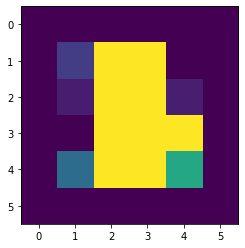

-1.0
Prediction: [0]


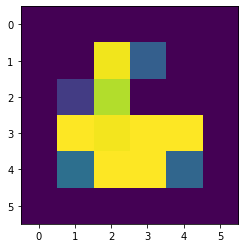

1.0
Prediction: [0]


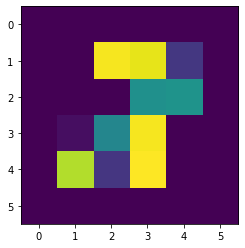

-1.0
Prediction: [1]


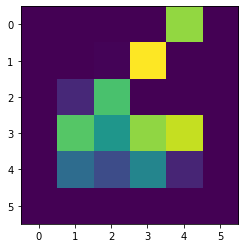

1.0
Prediction: [1]


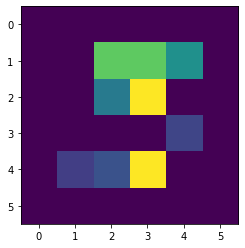

-1.0
Prediction: [0]


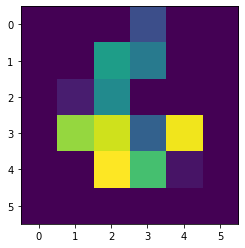

1.0
Prediction: [0]


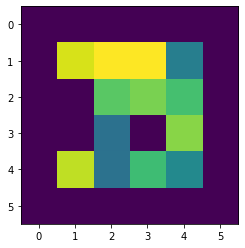

-1.0
Prediction: [0]


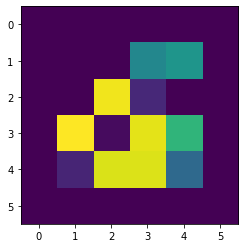

-1.0
Prediction: [0]


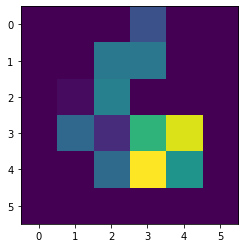

1.0
Prediction: [1]


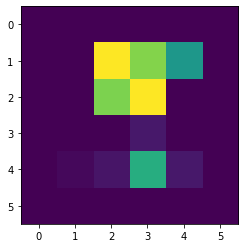

1.0
Prediction: [0]


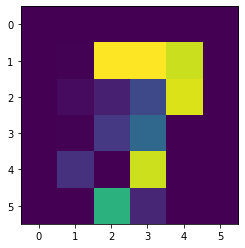

1.0
Prediction: [0]


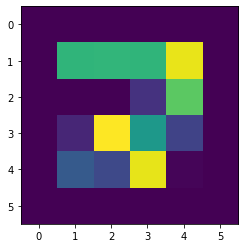

1.0
Prediction: [0]


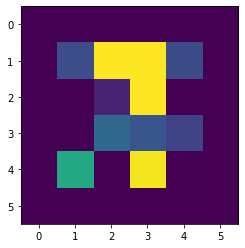

-1.0
Prediction: [0]


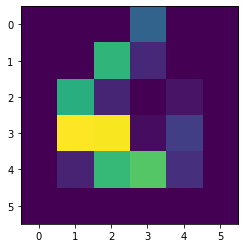

1.0
Prediction: [0]


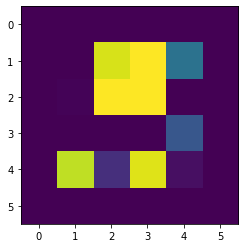

-1.0
Prediction: [0]


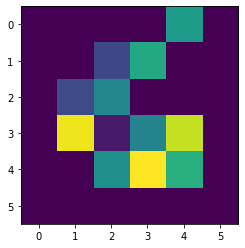

1.0
Prediction: [0]


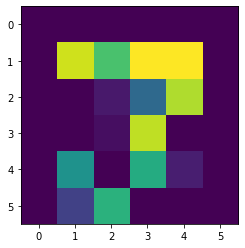

-1.0
Prediction: [0]


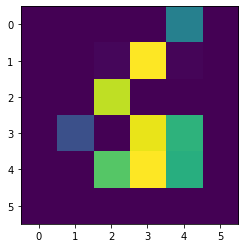

-1.0
Prediction: [0]


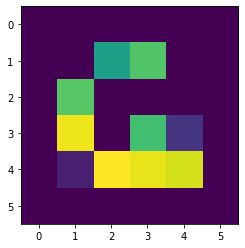

-1.0
Prediction: [0]


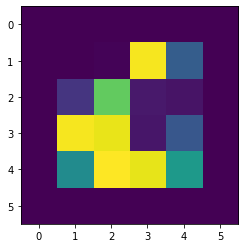

-1.0
Prediction: [0]


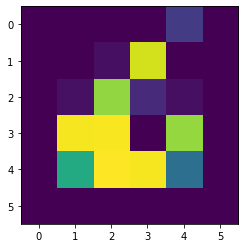

1.0
Prediction: [0]


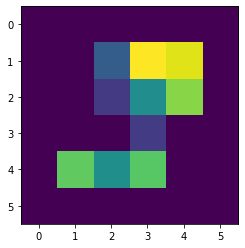

1.0
Prediction: [0]


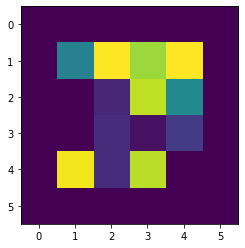

-1.0
Prediction: [0]


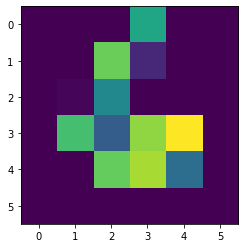

1.0
Prediction: [0]


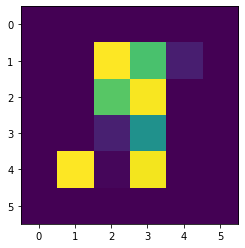

1.0
Prediction: [0]


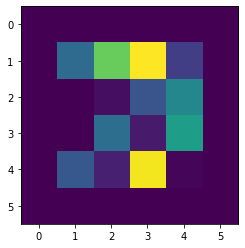

-1.0
Prediction: [0]


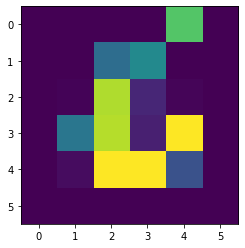

-1.0
Prediction: [0]


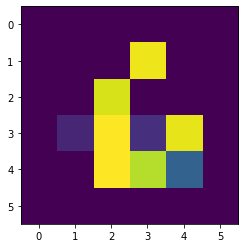

1.0
Prediction: [0]


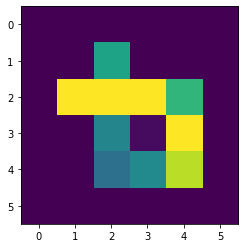

1.0
Prediction: [0]


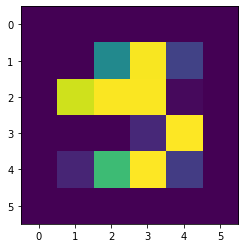

-1.0
Prediction: [0]


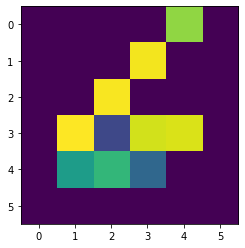

1.0
Prediction: [1]


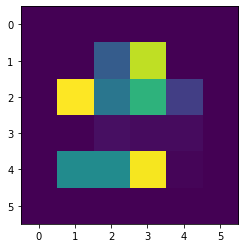

1.0
Prediction: [1]


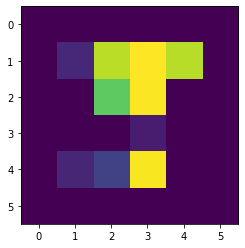

1.0
Prediction: [0]


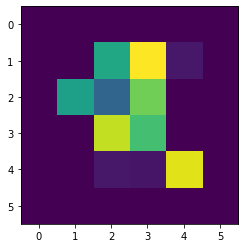

1.0
Prediction: [1]


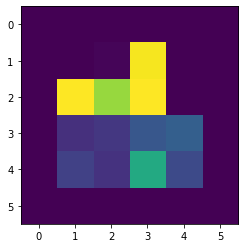

-1.0
Prediction: [0]


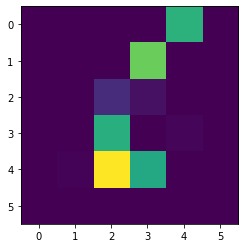

-1.0
Prediction: [0]


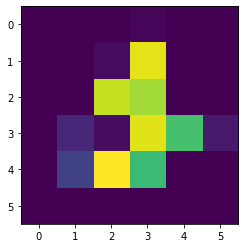

1.0
Prediction: [0]


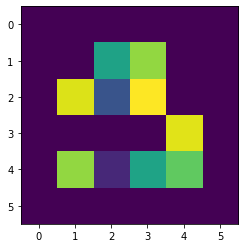

-1.0
Prediction: [0]


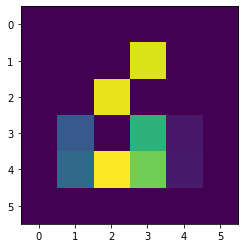

1.0
Prediction: [1]


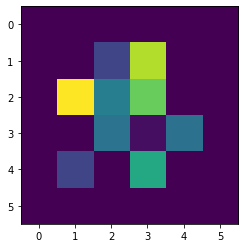

1.0
Prediction: [0]


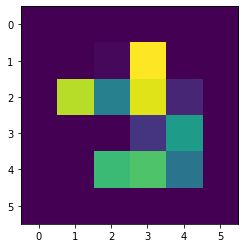

1.0
Prediction: [1]


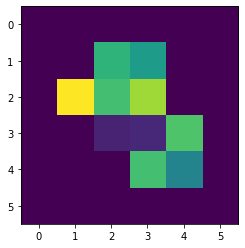

-1.0
Prediction: [1]


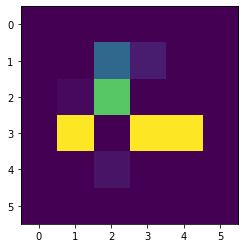

-1.0
Prediction: [1]


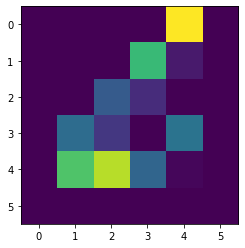

1.0
Prediction: [1]


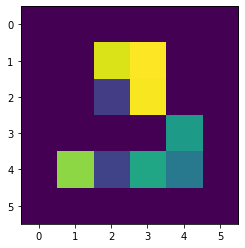

-1.0
Prediction: [0]


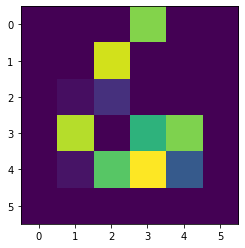

-1.0
Prediction: [0]


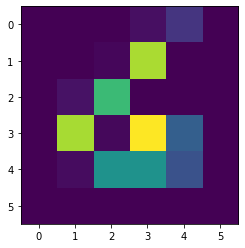

1.0
Prediction: [1]


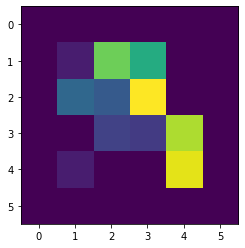

-1.0
Prediction: [0]


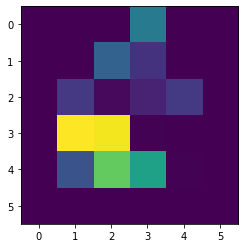

1.0
Prediction: [1]


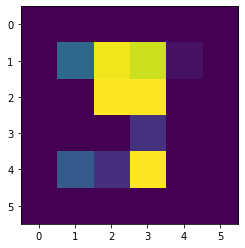

-1.0
Prediction: [0]


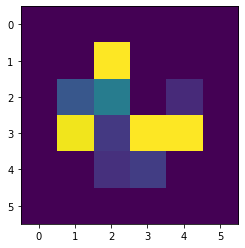

1.0
Prediction: [0]


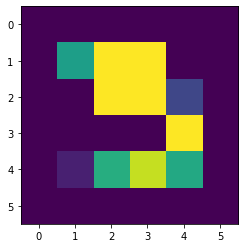

1.0
Prediction: [1]


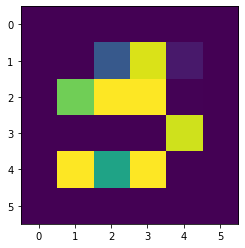

-1.0
Prediction: [0]


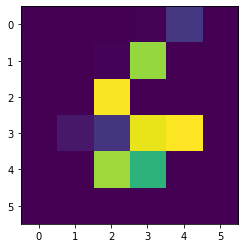

1.0
Prediction: [1]


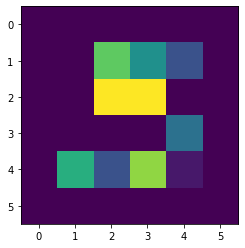

-1.0
Prediction: [0]


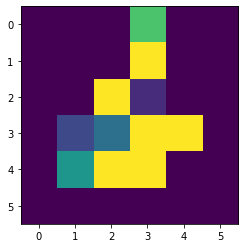

1.0
Prediction: [0]


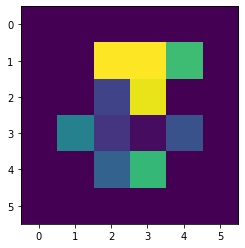

-1.0
Prediction: [0]


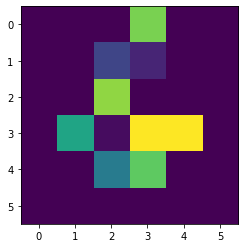

-1.0
Prediction: [0]


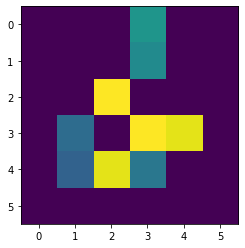

1.0
Prediction: [1]


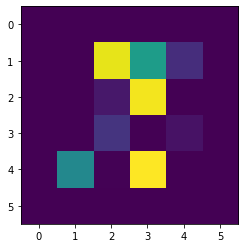

1.0
Prediction: [0]


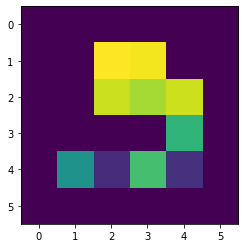

-1.0
Prediction: [0]


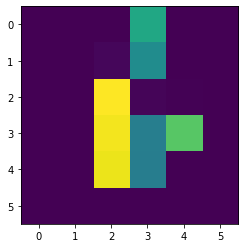

1.0
Prediction: [0]


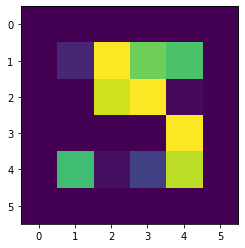

1.0
Prediction: [0]


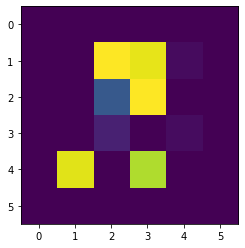

1.0
Prediction: [1]


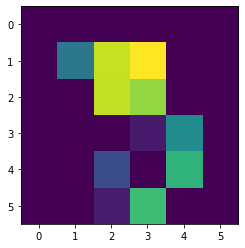

-1.0
Prediction: [0]


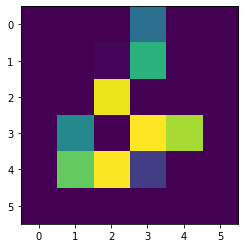

1.0
Prediction: [1]


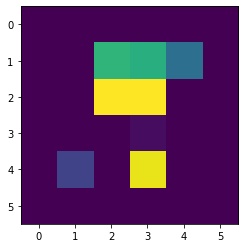

1.0
Prediction: [1]


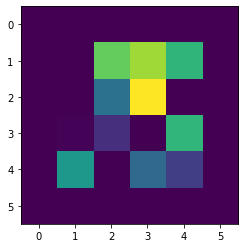

-1.0
Prediction: [0]


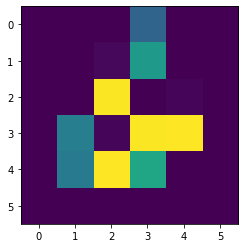

1.0
Prediction: [0]


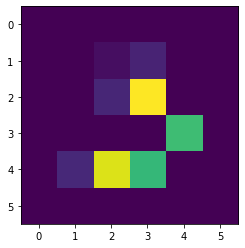

-1.0
Prediction: [0]


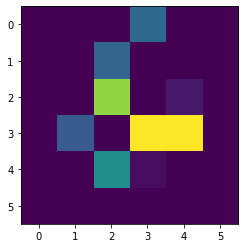

-1.0
Prediction: [0]


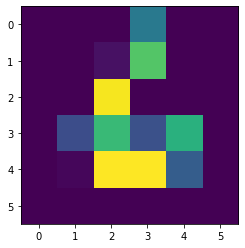

1.0
Prediction: [0]


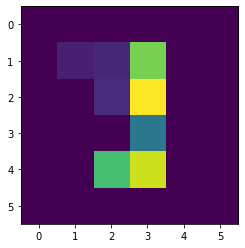

-1.0
Prediction: [0]


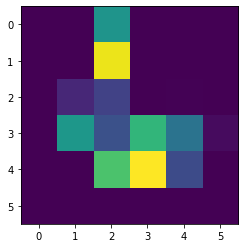

1.0
Prediction: [1]


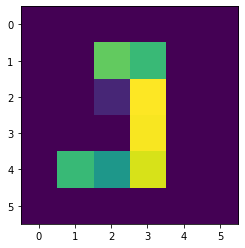

-1.0
Prediction: [1]


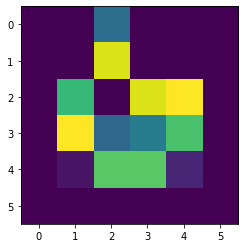

1.0
Prediction: [0]


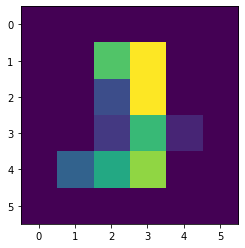

-1.0
Prediction: [0]


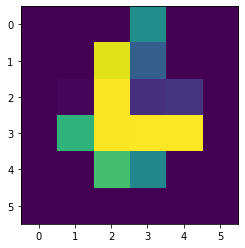

-1.0
Prediction: [0]


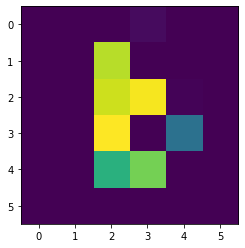

1.0
Prediction: [0]


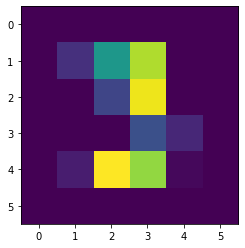

1.0
Prediction: [0]


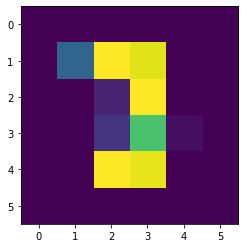

1.0
Prediction: [0]


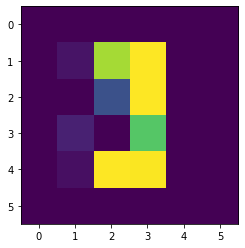

1.0
Prediction: [0]


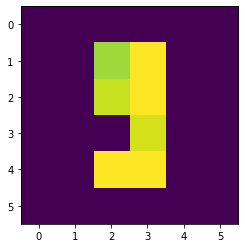

-1.0
Prediction: [0]


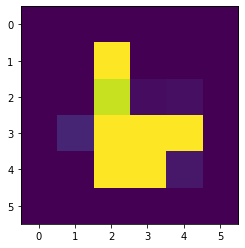

1.0
Prediction: [1]


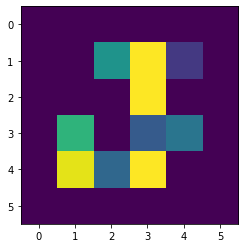

-1.0
Prediction: [0]


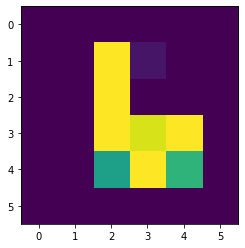

-1.0
Prediction: [0]


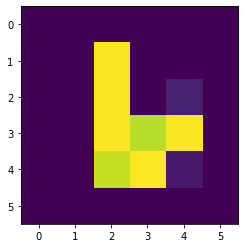

-1.0
Prediction: [0]


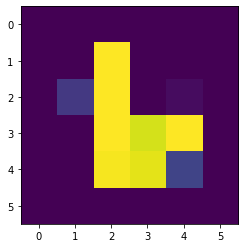

1.0
Prediction: [1]


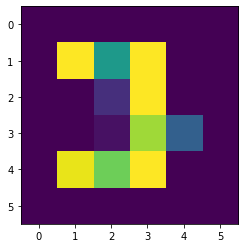

1.0
Prediction: [0]


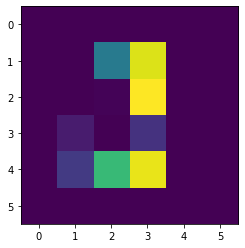

-1.0
Prediction: [0]


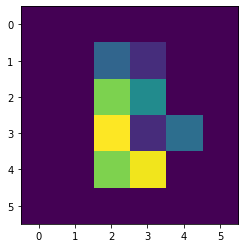

-1.0
Prediction: [0]


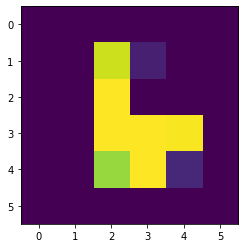

1.0
Prediction: [1]


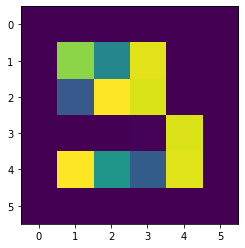

-1.0
Prediction: [1]


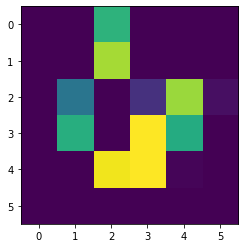

1.0
Prediction: [1]


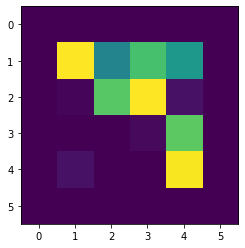

-1.0
Prediction: [0]


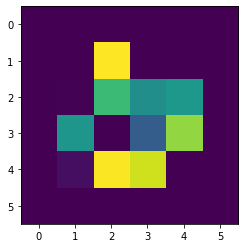

1.0
Prediction: [0]


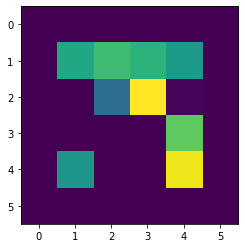

-1.0
Prediction: [0]


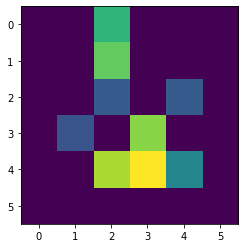

-1.0
Prediction: [1]


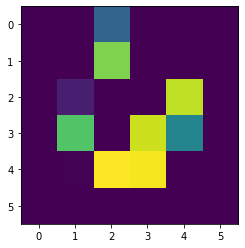

-1.0
Prediction: [1]


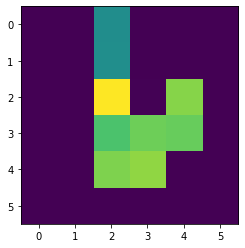

1.0
Prediction: [0]


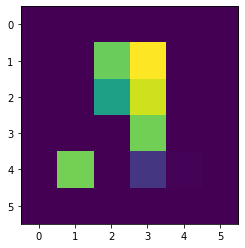

-1.0
Prediction: [0]


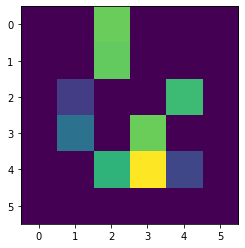

1.0
Prediction: [1]


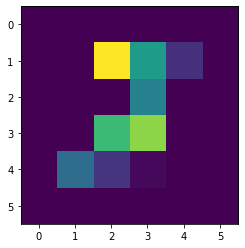

1.0
Prediction: [1]


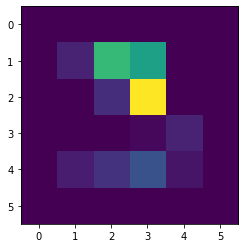

1.0
Prediction: [1]


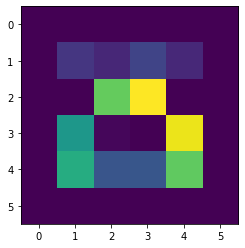

-1.0
Prediction: [0]


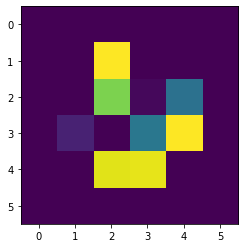

1.0
Prediction: [1]


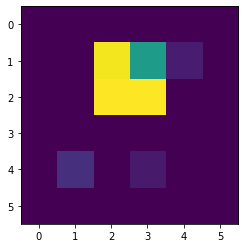

-1.0
Prediction: [1]


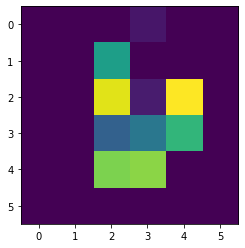

1.0
Prediction: [0]


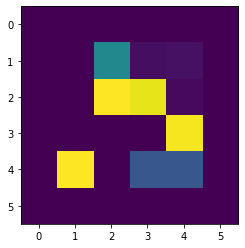

-1.0
Prediction: [1]


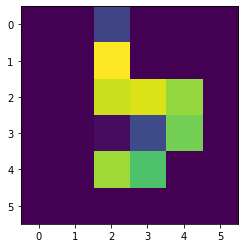

-1.0
Prediction: [1]


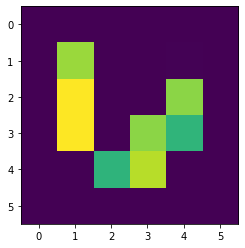

-1.0
Prediction: [0]


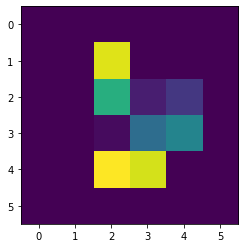

-1.0
Prediction: [0]


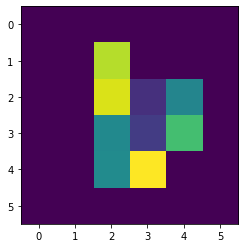

1.0
Prediction: [0]


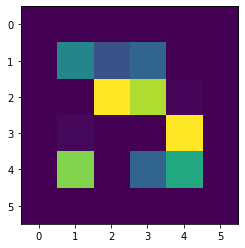

1.0
Prediction: [1]


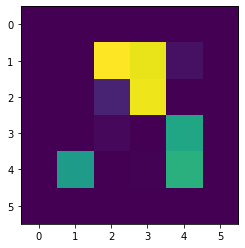

-1.0
Prediction: [0]


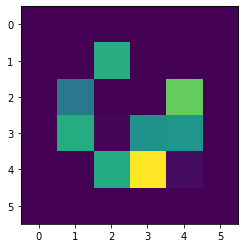

1.0
Prediction: [0]


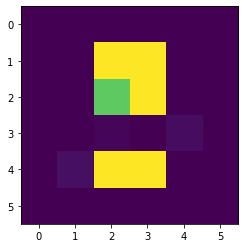

-1.0
Prediction: [0]


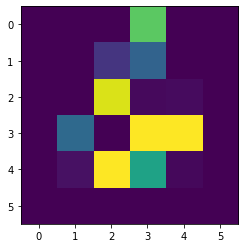

1.0
Prediction: [0]


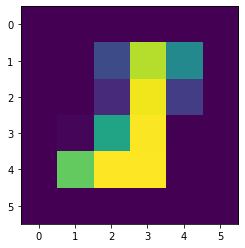

-1.0
Prediction: [0]


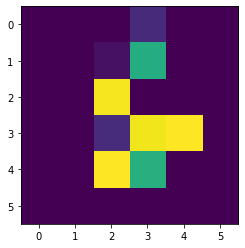

1.0
Prediction: [0]


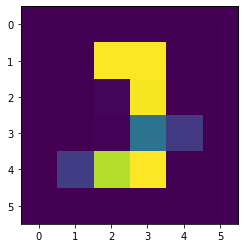

-1.0
Prediction: [0]


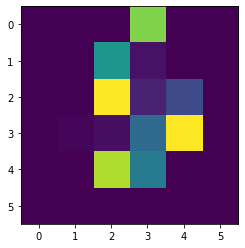

1.0
Prediction: [0]


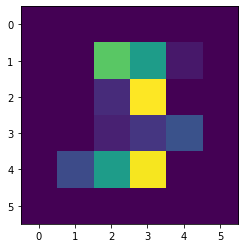

1.0
Prediction: [1]


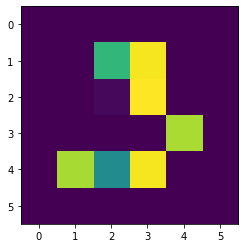

1.0
Prediction: [0]


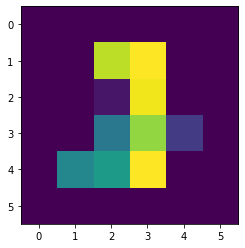

1.0
Prediction: [0]


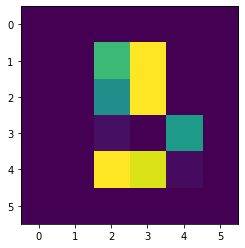

1.0
Prediction: [1]


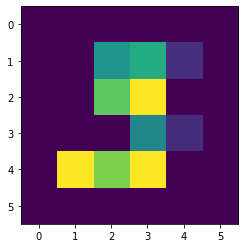

-1.0
Prediction: [0]


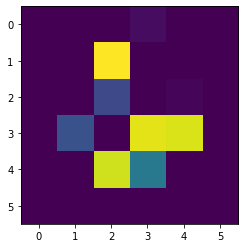

-1.0
Prediction: [1]


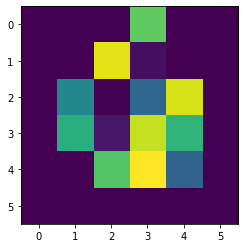

-1.0
Prediction: [0]


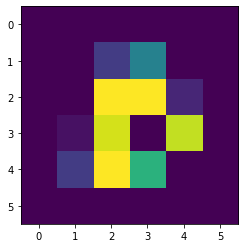

1.0
Prediction: [0]


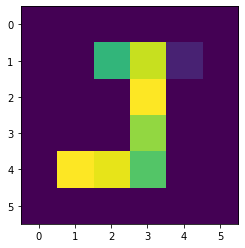

-1.0
Prediction: [0]


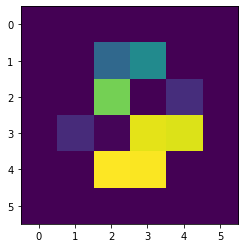

1.0
Prediction: [0]


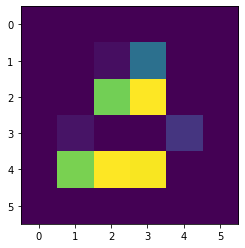

-1.0
Prediction: [0]


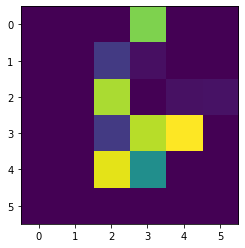

-1.0
Prediction: [0]


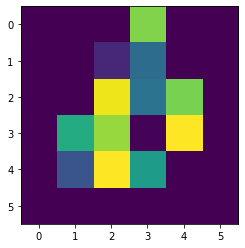

1.0
Prediction: [1]


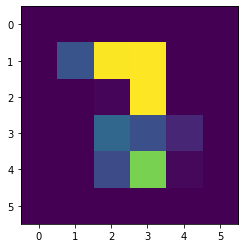

-1.0
Prediction: [0]


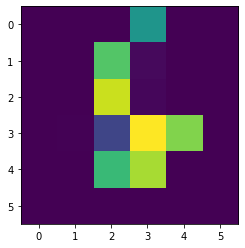

1.0
Prediction: [1]


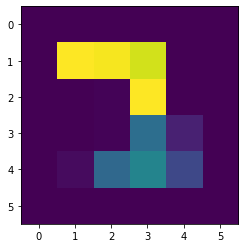

1.0
Prediction: [0]


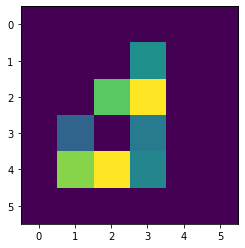

-1.0
Prediction: [0]


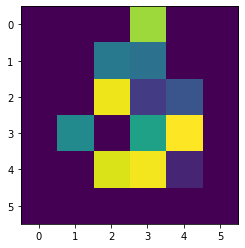

-1.0
Prediction: [0]


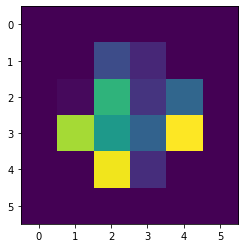

1.0
Prediction: [1]


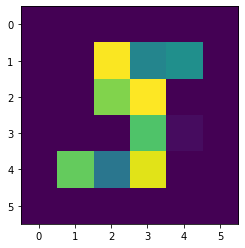

-1.0
Prediction: [0]


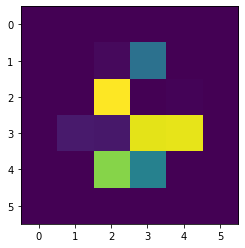

1.0
Prediction: [0]


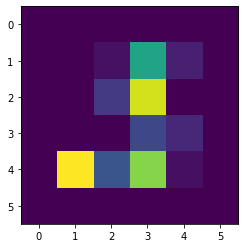

-1.0
Prediction: [0]


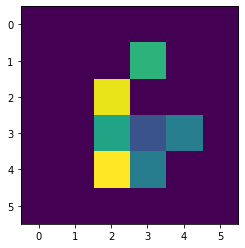

1.0
Prediction: [1]


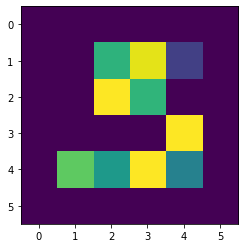

-1.0
Prediction: [0]


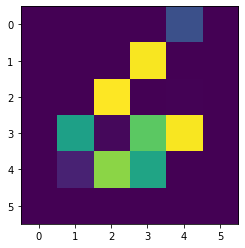

-1.0
Prediction: [0]


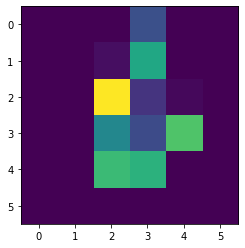

-1.0
Prediction: [0]


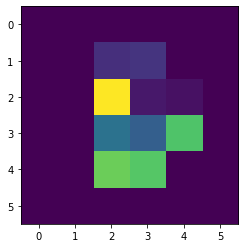

1.0
Prediction: [0]


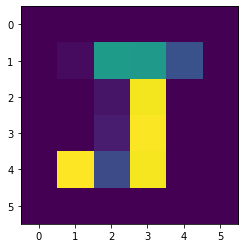

1.0
Prediction: [1]


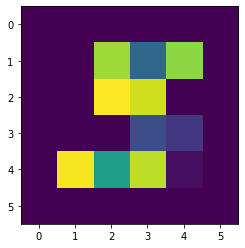

-1.0
Prediction: [0]


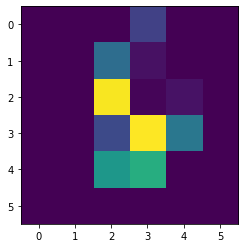

-1.0
Prediction: [0]


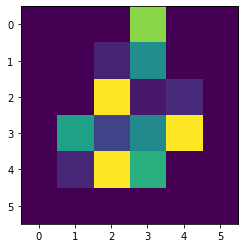

1.0
Prediction: [1]


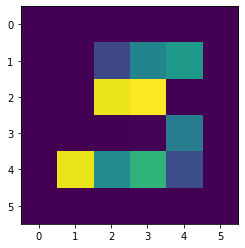

1.0
Prediction: [1]


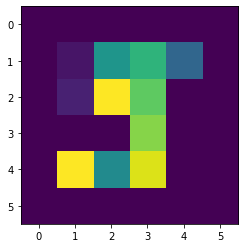

1.0
Prediction: [0]


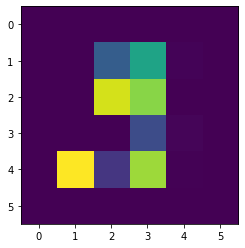

1.0
Prediction: [1]


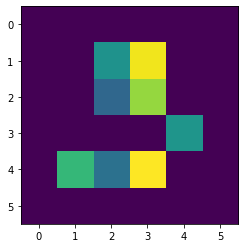

1.0
Prediction: [1]


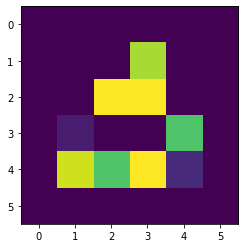

-1.0
Prediction: [1]


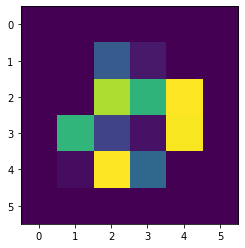

1.0
Prediction: [0]


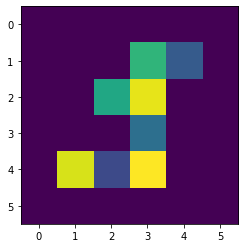

-1.0
Prediction: [0]


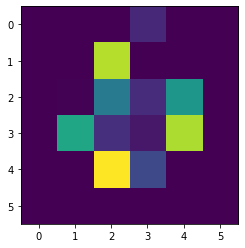

-1.0
Prediction: [0]


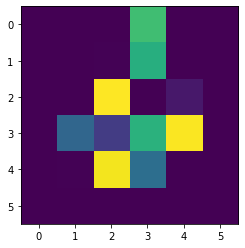

-1.0
Prediction: [0]


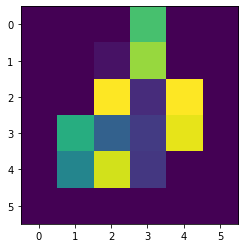

-1.0
Prediction: [0]


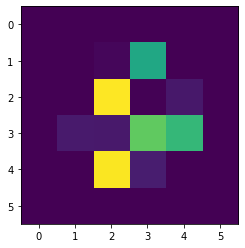

-1.0
Prediction: [0]


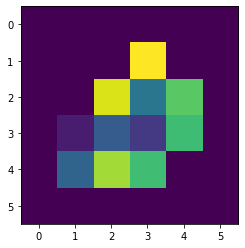

1.0
Prediction: [1]


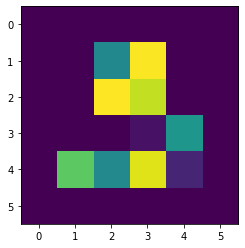

1.0
Prediction: [1]


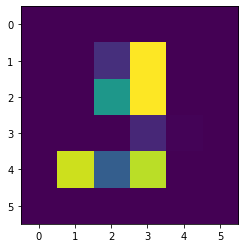

1.0
Prediction: [1]


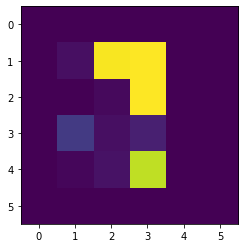

1.0
Prediction: [1]


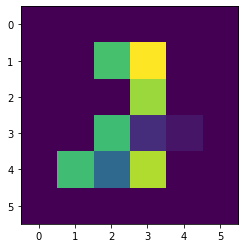

-1.0
Prediction: [0]


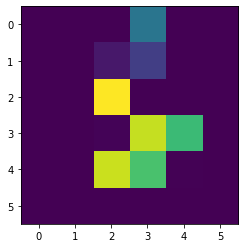

1.0
Prediction: [1]


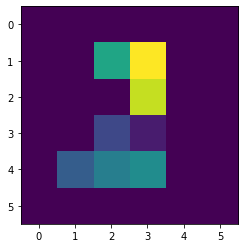

-1.0
Prediction: [0]


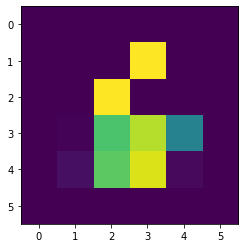

1.0
Prediction: [1]


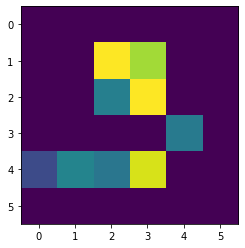

1.0
Prediction: [1]


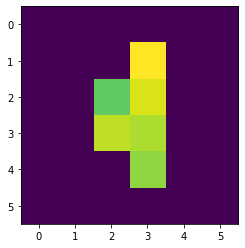

1.0
Prediction: [0]


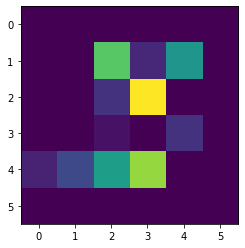

-1.0
Prediction: [0]


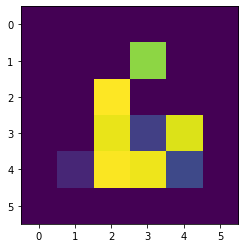

-1.0
Prediction: [0]


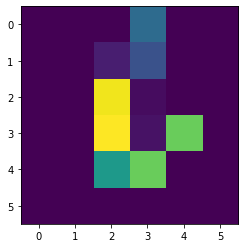

1.0
Prediction: [0]


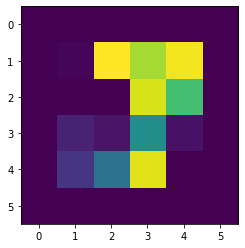

1.0
Prediction: [1]


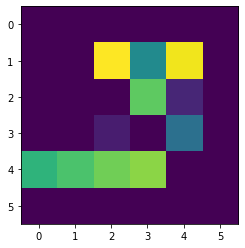

1.0
Prediction: [0]


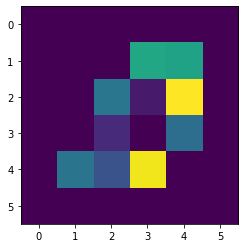

1.0
Prediction: [0]


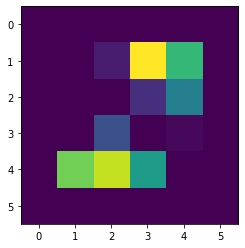

-1.0
Prediction: [0]


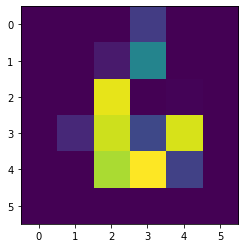

-1.0
Prediction: [0]


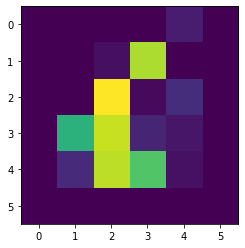

-1.0
Prediction: [0]


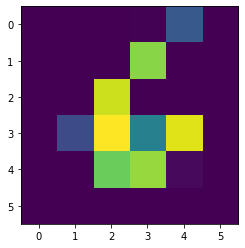

-1.0
Prediction: [0]


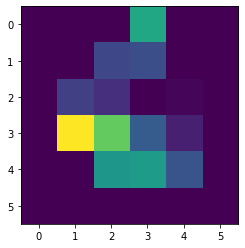

1.0
Prediction: [0]


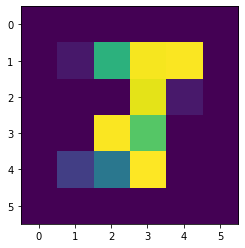

1.0
Prediction: [0]


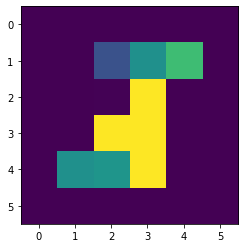

-1.0
Prediction: [0]


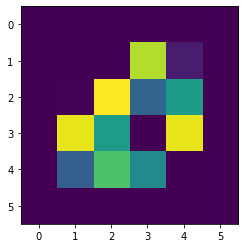

-1.0
Prediction: [0]


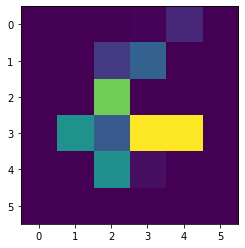

1.0
Prediction: [0]


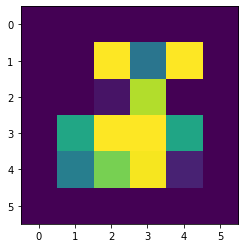

1.0
Prediction: [0]


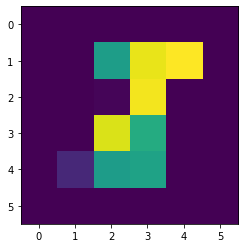

-1.0
Prediction: [1]


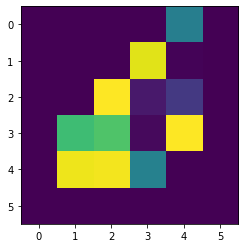

-1.0
Prediction: [0]


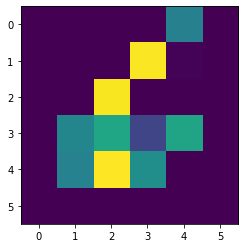

-1.0
Prediction: [0]


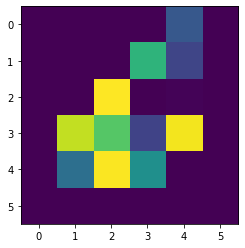

-1.0
Prediction: [0]


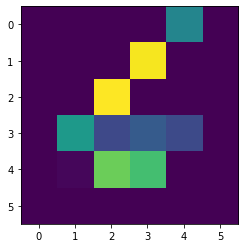

-1.0
Prediction: [0]


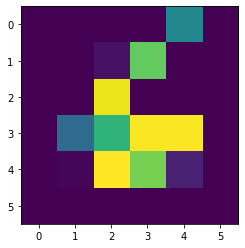

1.0
Prediction: [1]


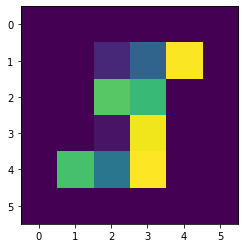

-1.0
Prediction: [0]


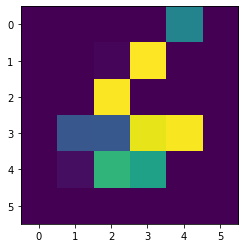

1.0
Prediction: [1]


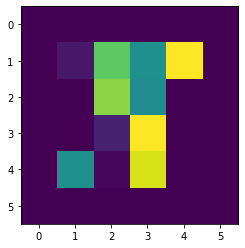

1.0
Prediction: [0]


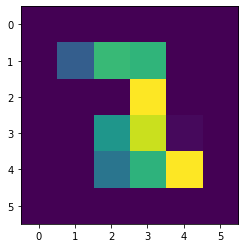

-1.0
Prediction: [0]


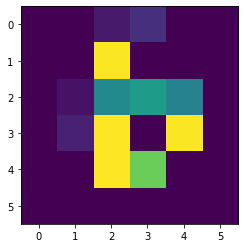

1.0
Prediction: [0]


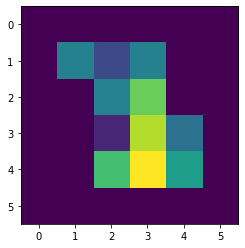

-1.0
Prediction: [0]


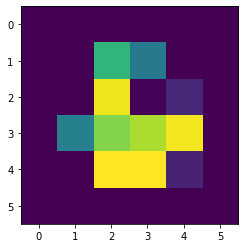

1.0
Prediction: [0]


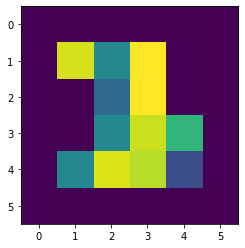

-1.0
Prediction: [0]


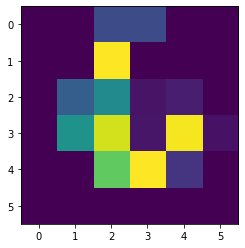

-1.0
Prediction: [0]


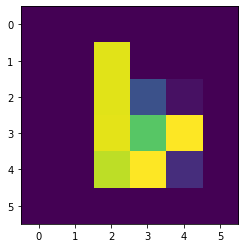

1.0
Prediction: [0]


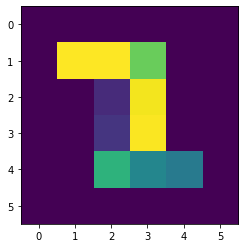

1.0
Prediction: [1]


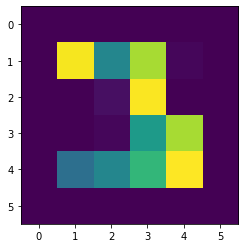

1.0
Prediction: [0]


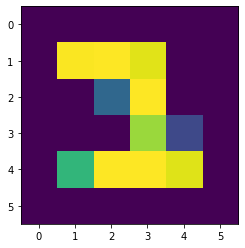

-1.0
Prediction: [0]


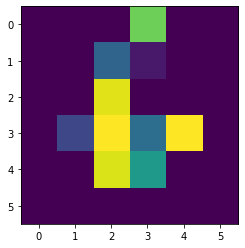

1.0
Prediction: [0]


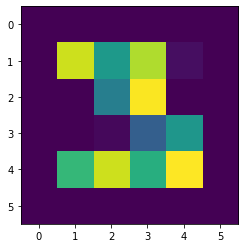

-1.0
Prediction: [0]


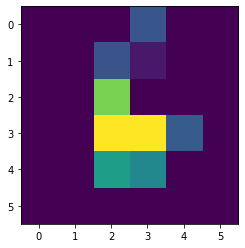

-1.0
Prediction: [0]


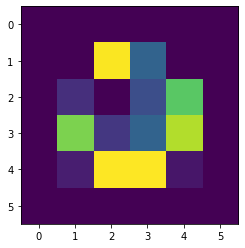

-1.0
Prediction: [0]


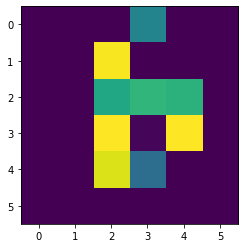

-1.0
Prediction: [0]


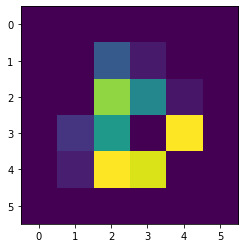

-1.0
Prediction: [0]


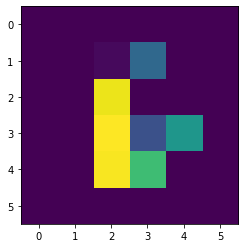

-1.0
Prediction: [0]


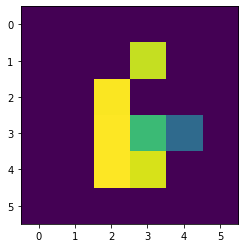

1.0
Prediction: [0]


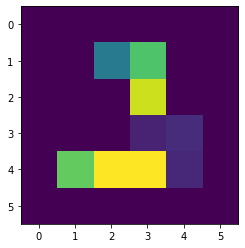

1.0
Prediction: [0]


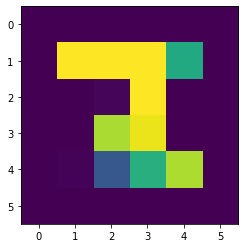

1.0
Prediction: [0]


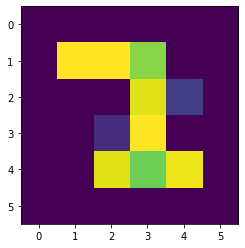

1.0
Prediction: [0]


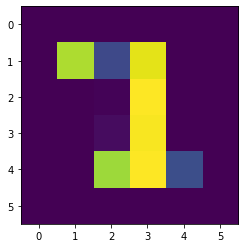

1.0
Prediction: [0]


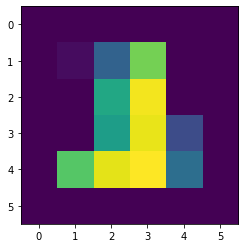

-1.0
Prediction: [0]


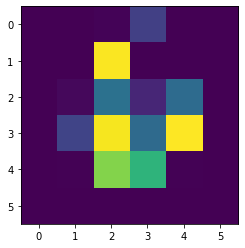

1.0
Prediction: [1]


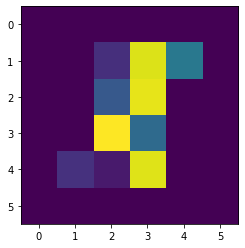

-1.0
Prediction: [0]


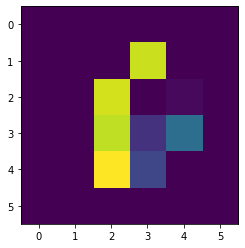

1.0
Prediction: [1]


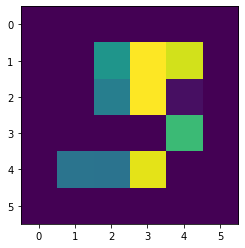

-1.0
Prediction: [0]


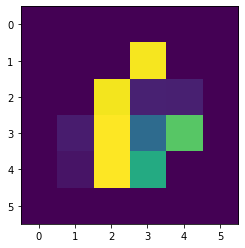

1.0
Prediction: [0]


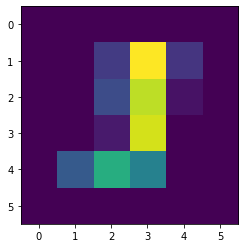

-1.0
Prediction: [0]


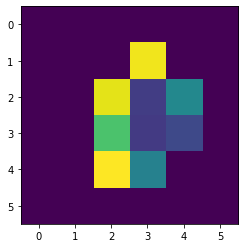

-1.0
Prediction: [0]


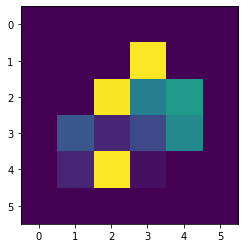

1.0
Prediction: [0]


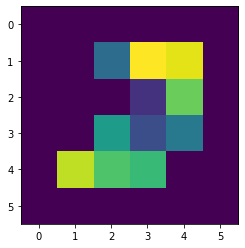

1.0
Prediction: [1]


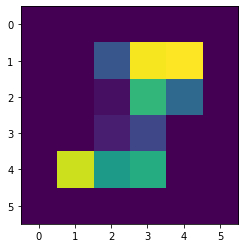

-1.0
Prediction: [0]


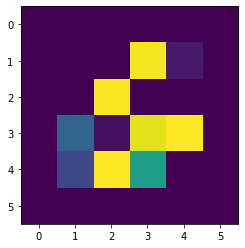

1.0
Prediction: [0]


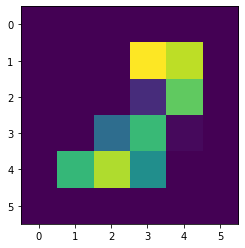

1.0
Prediction: [0]


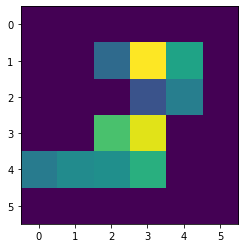

1.0
Prediction: [1]


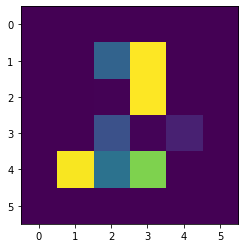

1.0
Prediction: [1]


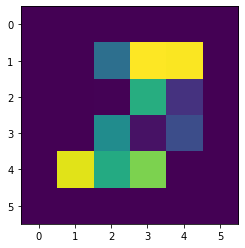

1.0
Prediction: [0]


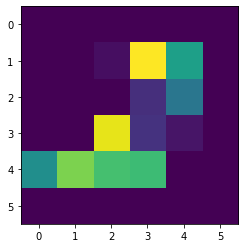

-1.0
Prediction: [0]


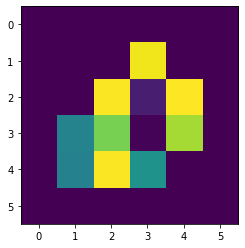

-1.0
Prediction: [0]


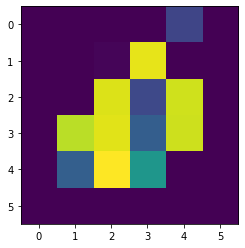

-1.0
Prediction: [0]


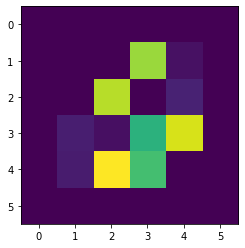

-1.0
Prediction: [0]


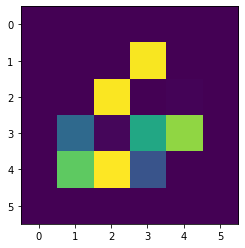

1.0
Prediction: [1]


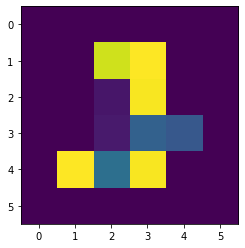

-1.0
Prediction: [0]


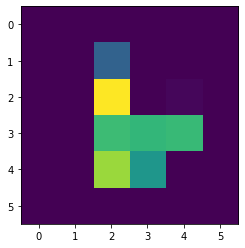

1.0
Prediction: [0]


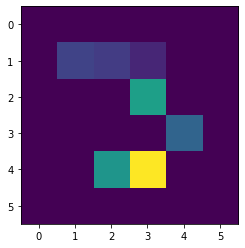

-1.0
Prediction: [0]


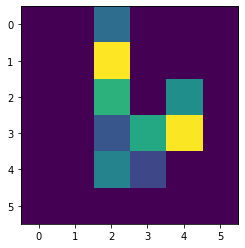

1.0
Prediction: [1]


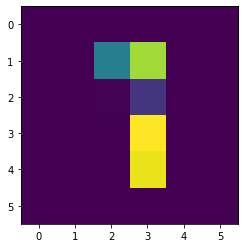

1.0
Prediction: [0]


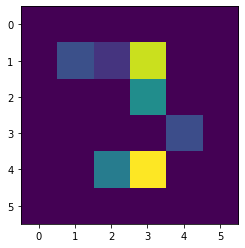

-1.0
Prediction: [0]


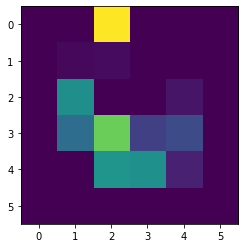

1.0
Prediction: [1]


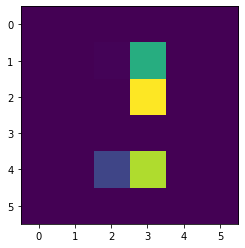

-1.0
Prediction: [0]


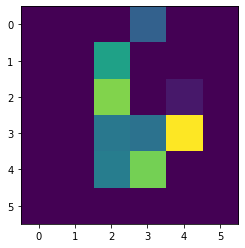

-1.0
Prediction: [1]


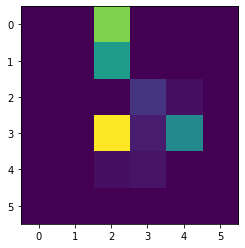

1.0
Prediction: [0]


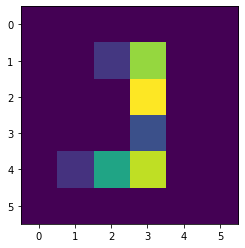

-1.0
Prediction: [0]


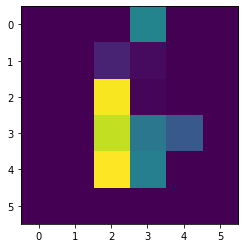

1.0
Prediction: [0]


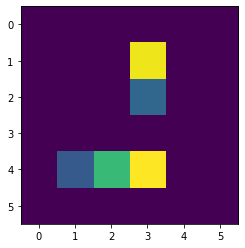

-1.0
Prediction: [0]


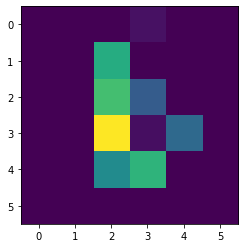

-1.0
Prediction: [0]


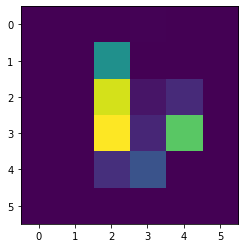

-1.0
Prediction: [0]


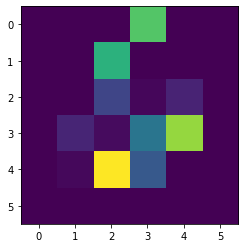

1.0
Prediction: [1]


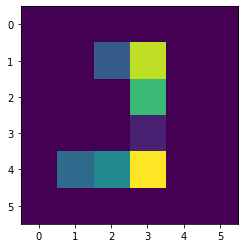

-1.0
Prediction: [0]


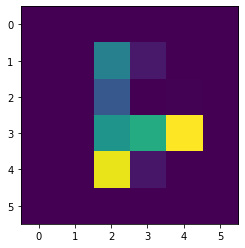

1.0
Prediction: [0]


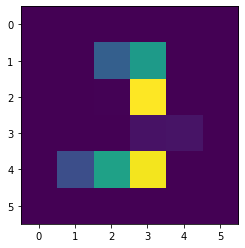

-1.0
Prediction: [1]


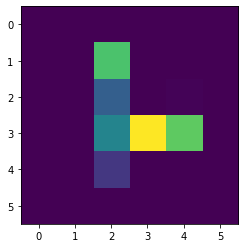

1.0
Prediction: [0]


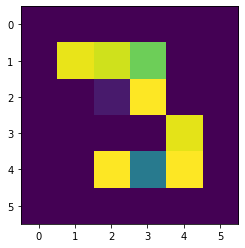

-1.0
Prediction: [0]


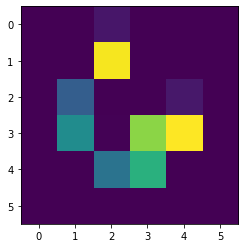

1.0
Prediction: [0]


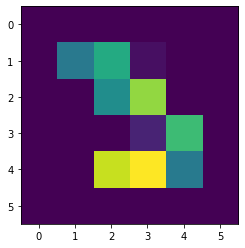

-1.0
Prediction: [0]


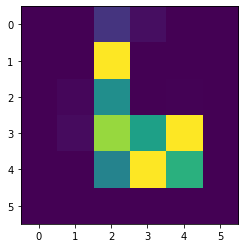

1.0
Prediction: [0]


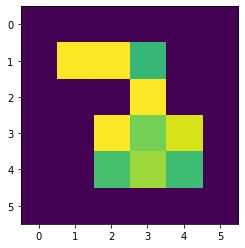

-1.0
Prediction: [1]


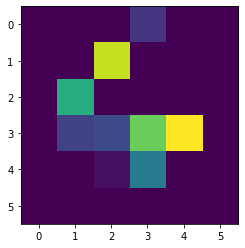

-1.0
Prediction: [0]


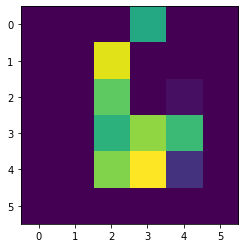

1.0
Prediction: [0]


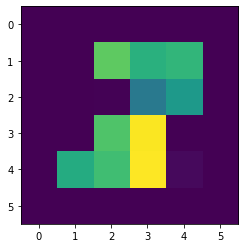

-1.0
Prediction: [0]


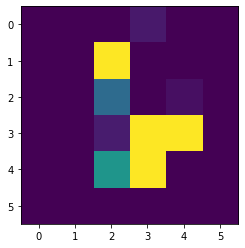

-1.0
Prediction: [0]


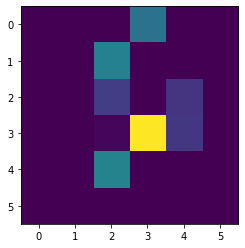

1.0
Prediction: [1]


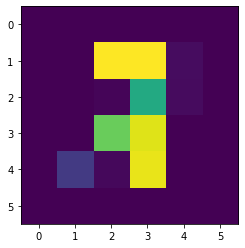

1.0
Prediction: [0]


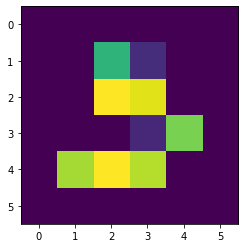

1.0
Prediction: [1]


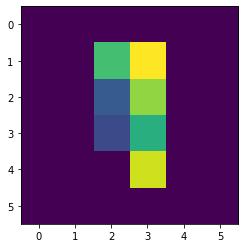

-1.0
Prediction: [0]


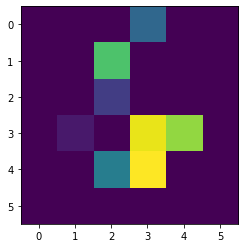

-1.0
Prediction: [0]


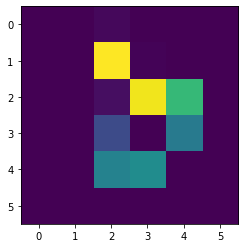

1.0
Prediction: [1]


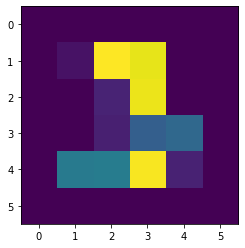

-1.0
Prediction: [0]


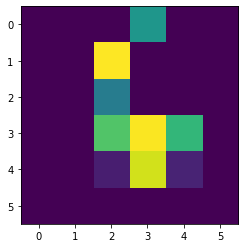

1.0
Prediction: [1]


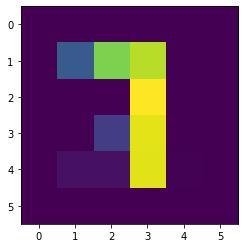

-1.0
Prediction: [0]


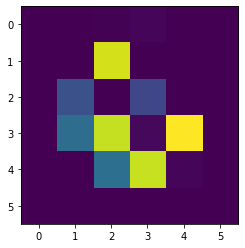

1.0
Prediction: [0]


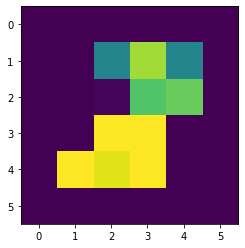

1.0
Prediction: [1]


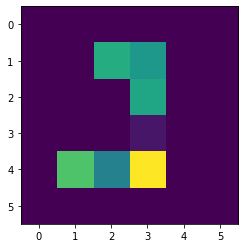

-1.0
Prediction: [1]


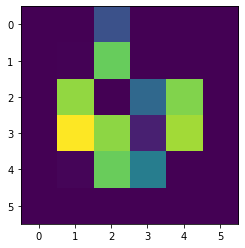

1.0
Prediction: [0]


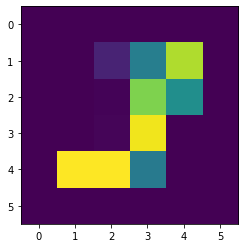

1.0
Prediction: [1]


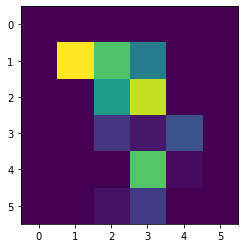

-1.0
Prediction: [0]


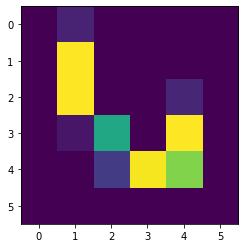

1.0
Prediction: [1]


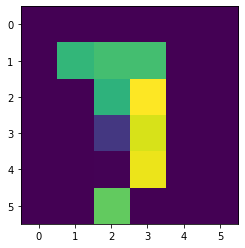

-1.0
Prediction: [0]


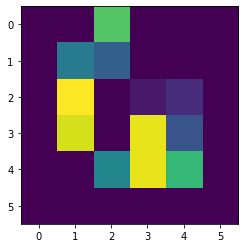

1.0
Prediction: [1]


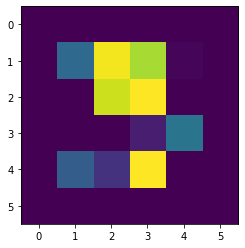

-1.0
Prediction: [0]


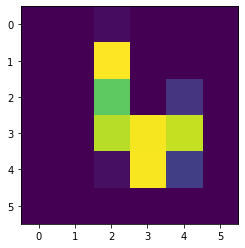

1.0
Prediction: [0]


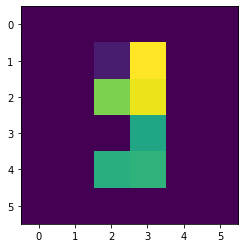

-1.0
Prediction: [0]


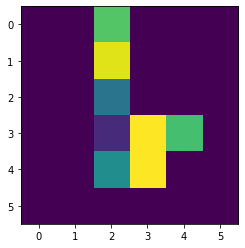

-1.0
Prediction: [0]


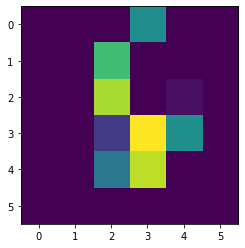

-1.0
Prediction: [1]


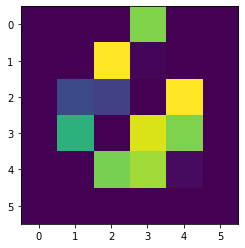

1.0
Prediction: [1]


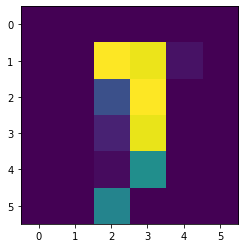

1.0
Prediction: [1]


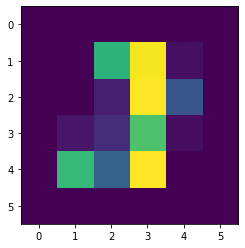

-1.0
Prediction: [0]


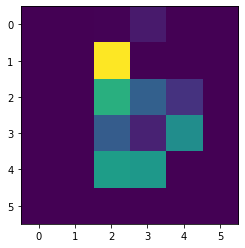

1.0
Prediction: [1]


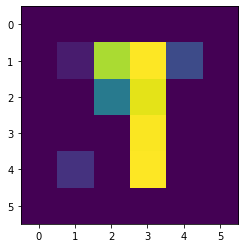

1.0
Prediction: [1]


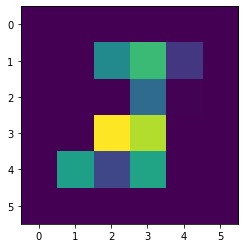

1.0
Prediction: [1]


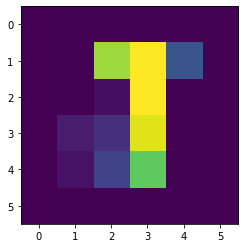

-1.0
Prediction: [0]


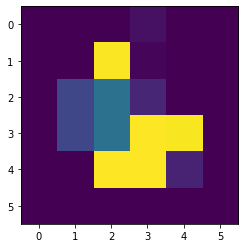

1.0
Prediction: [1]


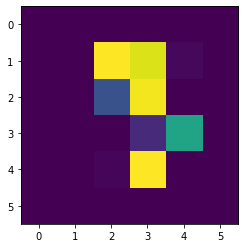

1.0
Prediction: [1]


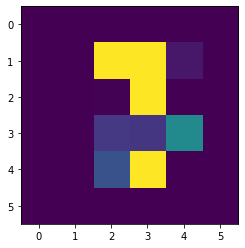

1.0
Prediction: [1]


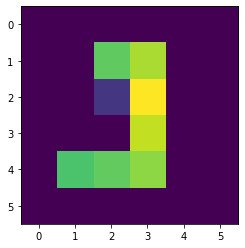

-1.0
Prediction: [0]


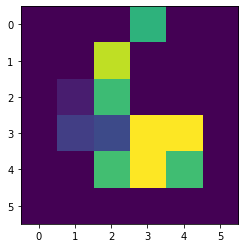

-1.0
Prediction: [0]


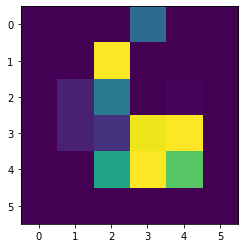

1.0
Prediction: [1]


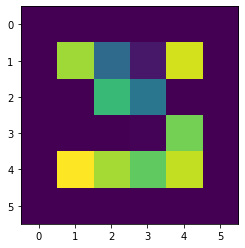

-1.0
Prediction: [0]


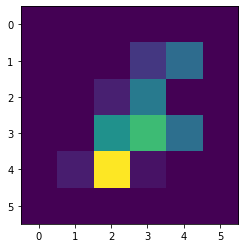

1.0
Prediction: [0]


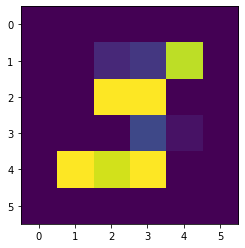

-1.0
Prediction: [1]


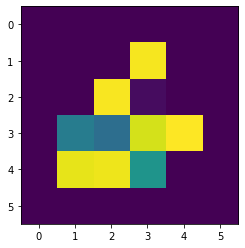

1.0
Prediction: [0]


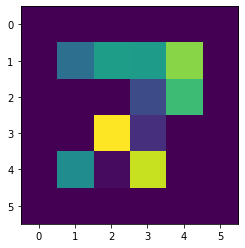

-1.0
Prediction: [0]


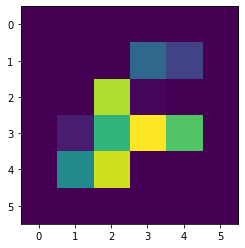

-1.0
Prediction: [0]


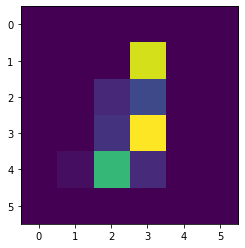

1.0
Prediction: [0]


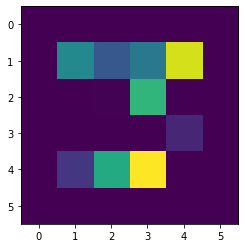

1.0
Prediction: [1]


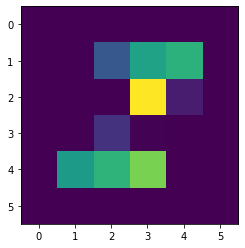

1.0
Prediction: [0]


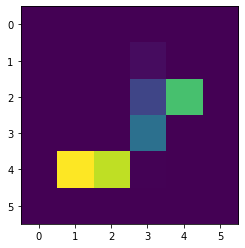

1.0
Prediction: [1]


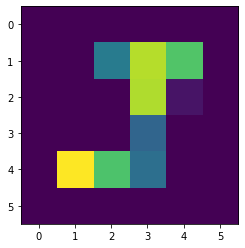

-1.0
Prediction: [0]


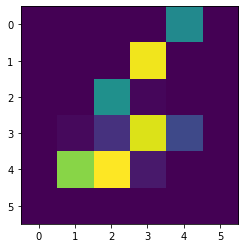

1.0
Prediction: [0]


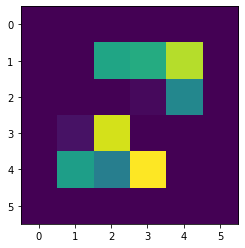

-1.0
Prediction: [0]


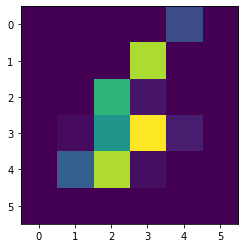

1.0
Prediction: [1]


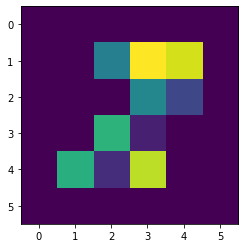

-1.0
Prediction: [0]


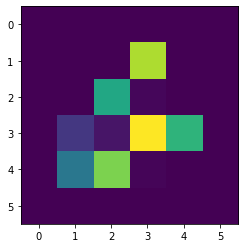

-1.0
Prediction: [0]


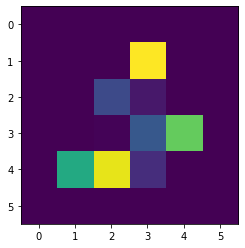

1.0
Prediction: [1]


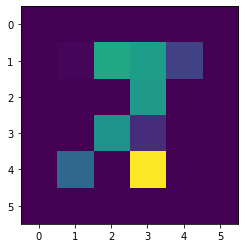

-1.0
Prediction: [0]


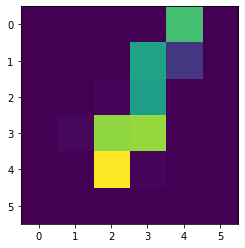

1.0
Prediction: [1]


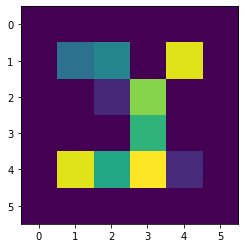

-1.0
Prediction: [1]


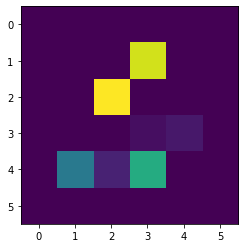

1.0
Prediction: [1]


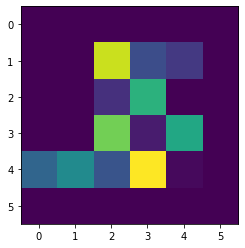

-1.0
Prediction: [0]


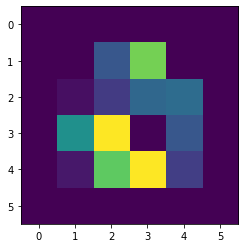

1.0
Prediction: [1]


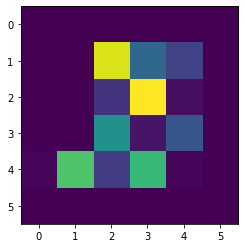

-1.0
Prediction: [1]


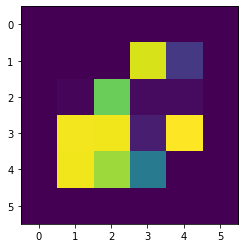

1.0
Prediction: [0]


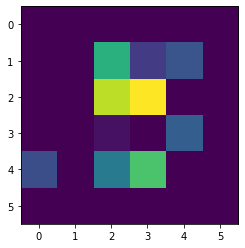

-1.0
Prediction: [1]


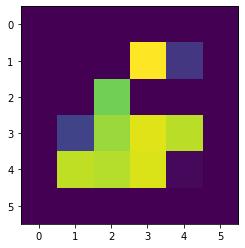

-1.0
Prediction: [0]


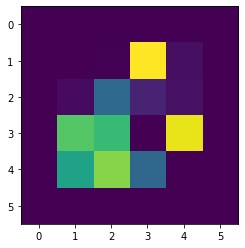

1.0
Prediction: [0]


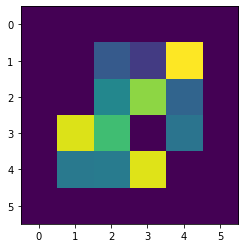

1.0
Prediction: [1]


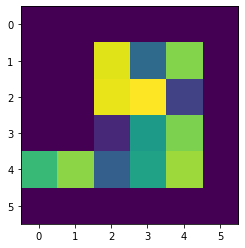

-1.0
Prediction: [1]


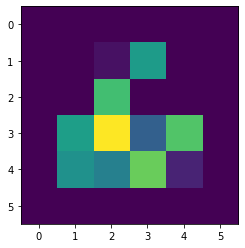

1.0
Prediction: [1]


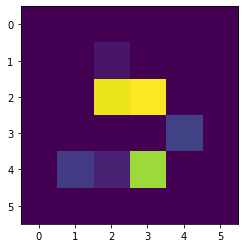

1.0
Prediction: [1]


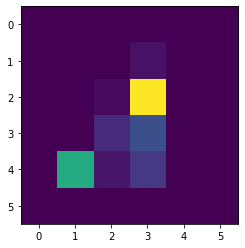

-1.0
Prediction: [1]


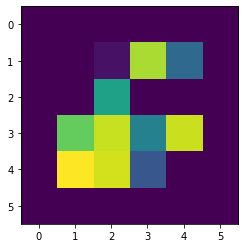

-1.0
Prediction: [0]


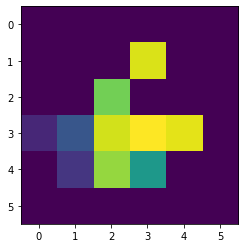

-1.0
Prediction: [0]


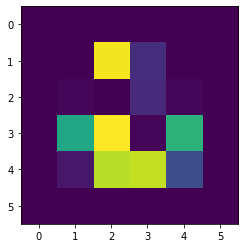

-1.0
Prediction: [0]


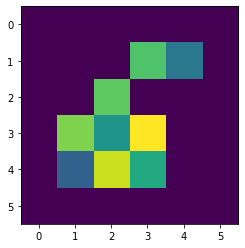

1.0
Prediction: [1]


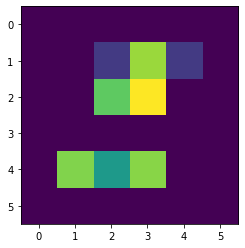

1.0
Prediction: [0]


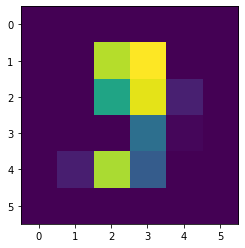

-1.0
Prediction: [0]


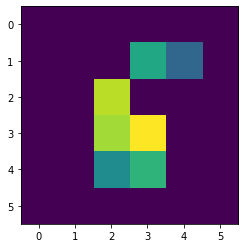

-1.0
Prediction: [1]


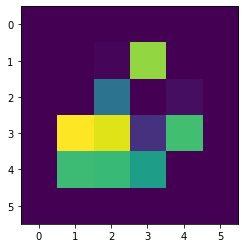

1.0
Prediction: [1]


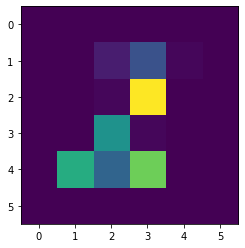

1.0
Prediction: [0]


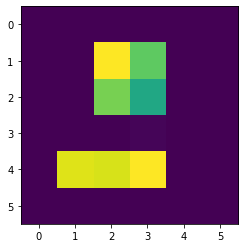

1.0
Prediction: [1]


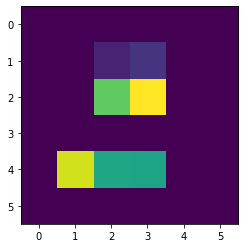

-1.0
Prediction: [0]


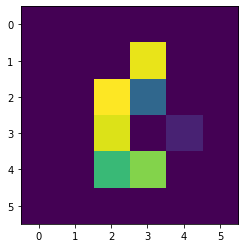

1.0
Prediction: [1]


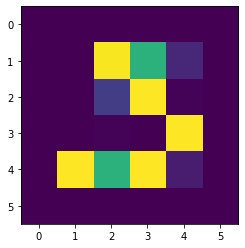

1.0
Prediction: [1]


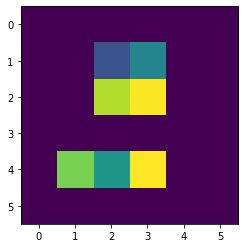

-1.0
Prediction: [0]


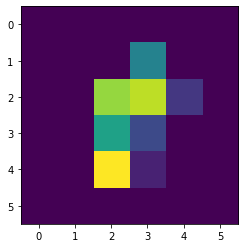

1.0
Prediction: [0]


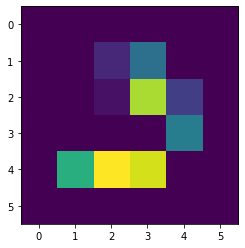

-1.0
Prediction: [0]


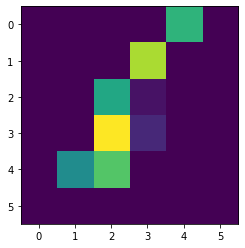

-1.0
Prediction: [0]


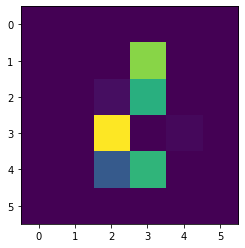

1.0
Prediction: [0]


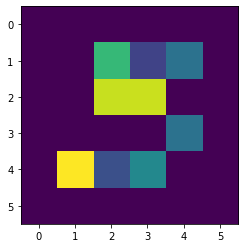

-1.0
Prediction: [0]


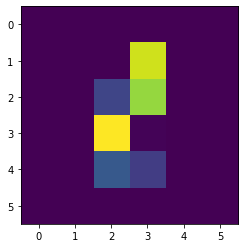

1.0
Prediction: [0]


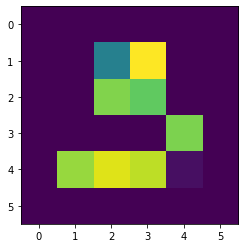

1.0
Prediction: [0]


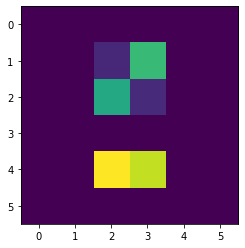

1.0
Prediction: [0]


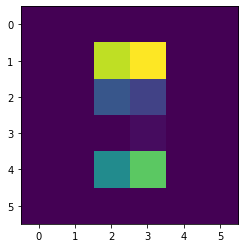

-1.0
Prediction: [0]


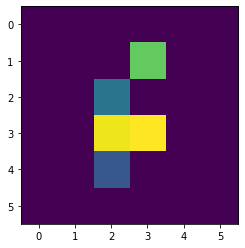

-1.0
Prediction: [0]


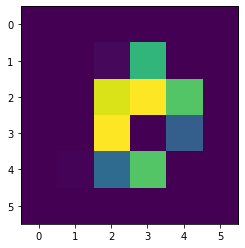

1.0
Prediction: [1]


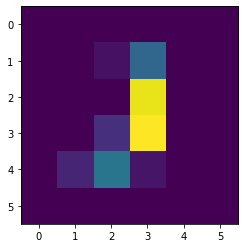

1.0
Prediction: [0]


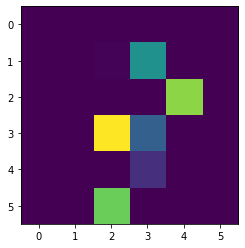

-1.0
Prediction: [0]


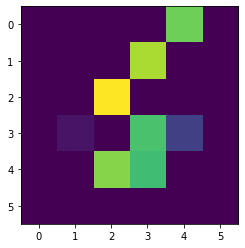

1.0
Prediction: [0]


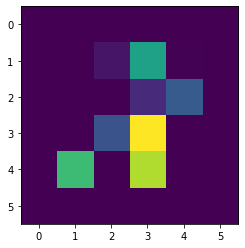

-1.0
Prediction: [1]


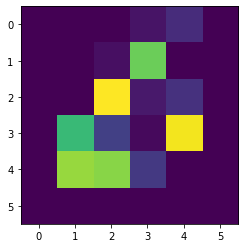

1.0
Prediction: [0]


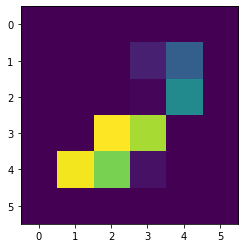

-1.0
Prediction: [0]


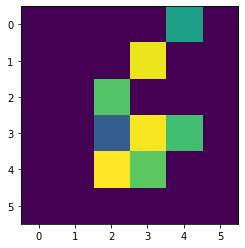

-1.0
Prediction: [0]


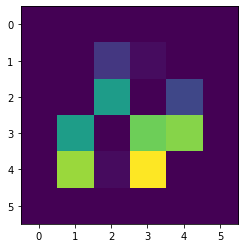

1.0
Prediction: [0]


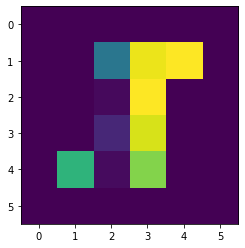

1.0
Prediction: [1]


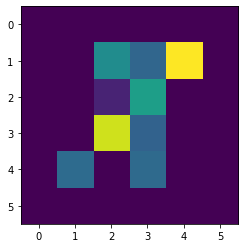

1.0
Prediction: [0]


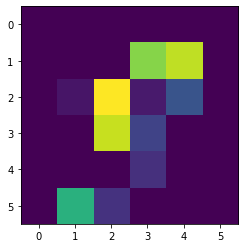

-1.0
Prediction: [1]


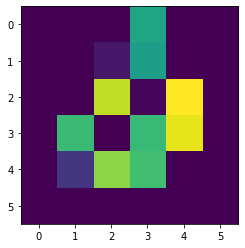

-1.0
Prediction: [1]


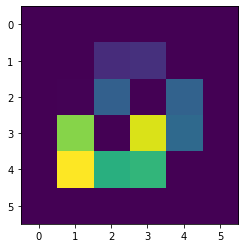

-1.0
Prediction: [0]


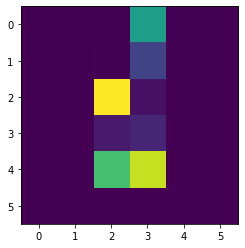

1.0
Prediction: [1]


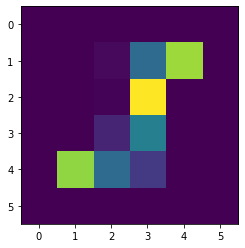

-1.0
Prediction: [0]


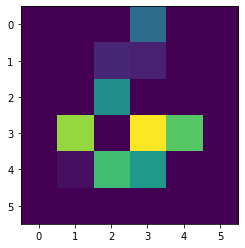

1.0
Prediction: [1]


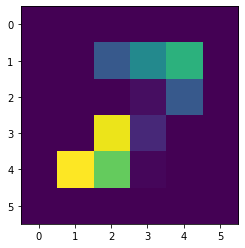

-1.0
Prediction: [0]


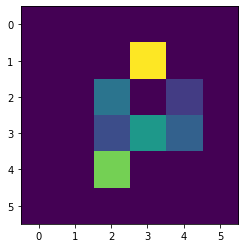

-1.0
Prediction: [0]


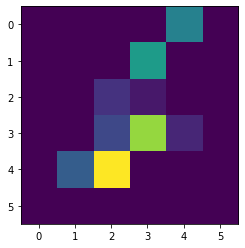

1.0
Prediction: [0]


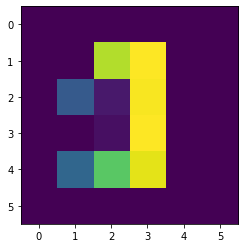

-1.0
Prediction: [0]


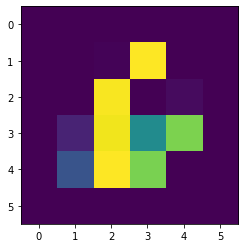

1.0
Prediction: [1]


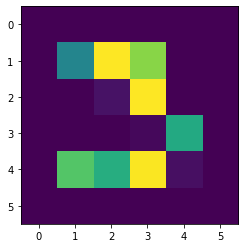

-1.0
Prediction: [0]


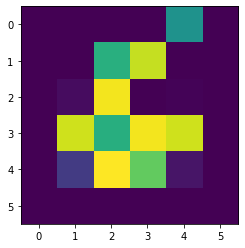

In [15]:
for i in range(len(X_test)):
  print(Y_test[i])
  print('Prediction:', preds[i])
  plt.imshow(X_test[i,:,:,0])
  plt.show()

In [16]:
preds

array([[1],
       [0],
       [0],
       ...,
       [0],
       [1],
       [0]], dtype=int32)

In [17]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 pqc (PQC)                   (None, 1)                 135       
                                                                 
Total params: 135
Trainable params: 135
Non-trainable params: 0
_________________________________________________________________


In [18]:
preds2=model.predict(x_test_16)

In [ ]:
def convert_preds(y):
  if y>0.0:
    return 1.0
  else: 
    return 0.0  #changed from -1.0

In [20]:
preds_out = [convert_preds(y) for y in preds2]

In [21]:
Y_test_ = [convert_preds(y) for y in Y_test]

In [22]:
tf.math.confusion_matrix(Y_test_, preds_out)

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[625, 333],
       [268, 742]], dtype=int32)>

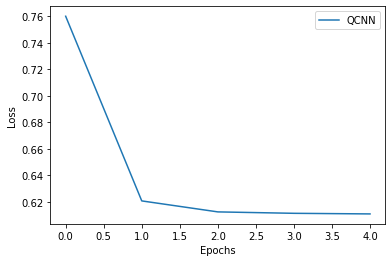

In [23]:
plt.plot(history.history['loss'], label='QCNN')
#plt.plot(hybrid_history.history['val_custom_accuracy'], label='Hybrid CNN')
#plt.title('Quantum vs Hybrid CNN performance')
plt.xlabel('Epochs')
plt.legend()
plt.ylabel('Loss')
plt.show()

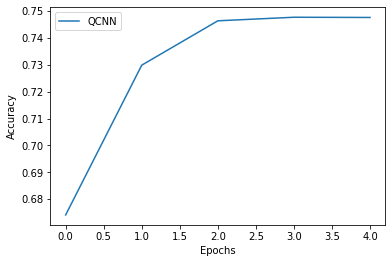

In [24]:
plt.plot(history.history['hinge_accuracy'], label='QCNN')
#plt.plot(hybrid_history.history['val_custom_accuracy'], label='Hybrid CNN')
#plt.title('Quantum vs Hybrid CNN performance')
plt.xlabel('Epochs')
plt.legend()
plt.ylabel('Accuracy')
plt.show()

In [ ]:
plt.plot(history.history['val_hinge_accuracy'], label='QCNN')
#plt.plot(hybrid_history.history['val_custom_accuracy'], label='Hybrid CNN')
#plt.title('Quantum vs Hybrid CNN performance')
plt.xlabel('Epochs')
plt.legend()
plt.ylabel('Validation Accuracy')
plt.show()

In [26]:
X_test_2 = x_test_small [50:100]

Y_test_2 = y_test[50:100]

#x_train_16 = tfq.convert_to_tensor([encode_circuit(x) for x in X_train])
x_test_2 = tfq.convert_to_tensor([encode_circuit(x) for x in X_test_2])